In [ ]:
import pandas as pd
from pathlib import Path

# --------------------------------------------------------------------
# 0) 경로·파일 이름 설정
# --------------------------------------------------------------------
DATA_DIR = Path(r"D:/fintech/data")                  # ↩ 직접 경로 입력
SRC_FILE = DATA_DIR / "PSIDSHELF_1968_2021_LONG.dta" # 원본 Stata
DST_PARQ = DATA_DIR / "psidshelf_long_full.parquet"  # 전체 데이터 저장 (권장)
DST_CSV  = DATA_DIR / "psidshelf_long_full.csv"      # 필요 시 CSV
DST_COLS = DATA_DIR / "psidshelf_columns.txt"        # 컬럼 목록

# --------------------------------------------------------------------
# 1) WIDE 파일 전체 불러오기
#    • convert_categoricals=False → Stata 범주형을 숫자로 유지
# --------------------------------------------------------------------
df = pd.read_stata(SRC_FILE, convert_categoricals=False)

# --------------------------------------------------------------------
# 2) 그대로 저장
# --------------------------------------------------------------------
df.to_parquet(DST_PARQ, index=False)   # Parquet (빠른 I/O·압축률↑)
# df.to_csv(DST_CSV, index=False)      # ← 주석 해제 시 CSV도 동시에 저장

# --------------------------------------------------------------------
# 3) 컬럼 목록만 따로 저장해두기
# --------------------------------------------------------------------
pd.Series(df.columns).to_csv(DST_COLS, index=False, header=False)

print(f"✅ 전체 데이터 저장 완료 → {DST_PARQ}")
print(f"   행/열 크기      : {df.shape[0]:,} × {df.shape[1]}")
print(f"✅ 컬럼 목록 저장   → {DST_COLS}")


In [2]:
import pandas as pd
from pathlib import Path

# 0) 파일 경로 설정
SRC_FILE = Path(r"D:/fintech/data/PSIDSHELF_1968_2021_LONG.dta")
DST_CSV  = Path(r"D:/fintech/data/psidshelf_long_full.csv")

# 1) 청크 크기(행 개수) 지정
chunksize = 200_000

# 2) Stata 파일 읽기용 iterator 생성
reader = pd.read_stata(
    str(SRC_FILE),
    convert_categoricals=False,  # 범주형 변수도 숫자로 유지
    iterator=True,
    chunksize=chunksize
)

# 3) 첫 번째 청크부터 순차적으로 CSV에 쓰기
first_chunk = True
for df_chunk in reader:
    # (필요 시 타입 변환)
    # df_chunk = df_chunk.astype("float64")
    
    # CSV로 저장: 첫 청크만 header, 쓰기 모드는 첫 번째만 'w', 나머지는 'a'
    df_chunk.to_csv(
        str(DST_CSV),
        index=False,
        header=first_chunk,
        mode="w" if first_chunk else "a",
        encoding="utf-8-sig"  # 한글 깨짐 방지
    )
    first_chunk = False

print("✅ .dta → .csv 변환 완료:", DST_CSV)


✅ .dta → .csv 변환 완료: D:\fintech\data\psidshelf_long_full.csv


In [15]:
import dask.dataframe as dd

# 1) Parquet 읽기 (작업 중에도 메모리에 안 올림)
ddf = dd.read_parquet("D:/fintech/data/psidshelf_wide.parquet", engine="pyarrow")

# 2) 예: WIDE→LONG 변환
id_vars    = ["ID", "YEAR", "FUID", "PNUM"]  # 예시: 고유 식별자 컬럼들
value_vars = [c for c in ddf.columns if c.startswith("EARN_TOT")]
long = dd.melt(ddf,
               id_vars=id_vars,
               value_vars=value_vars,
               var_name="earn_year",
               value_name="earn_value")

# 3) 결과도 Parquet으로 저장 (메모리 걱정 無)
long.to_parquet("D:/fintech/data/psidshelf_long_dd.parquet",
                write_index=False)


ImportError: An error occurred while calling the read_parquet method registered to the pandas backend.
Original Message: The pyarrow installation is not built with support for 'dataset' (DLL load failed while importing _dataset: 지정된 프로시저를 찾을 수 없습니다.)

In [12]:
# split_psid_dta.py
"""
PSIDSHELF_1968_2021_WIDE.dta  →  Parquet(또는 Feather) 다중 파일로
메모리 친화적인 스트리밍 분할 저장 스크립트
"""
from pathlib import Path
import pyreadstat                    # Stata → pandas (row_offset / row_limit 지원)
import pyarrow.parquet as pq
import pyarrow as pa

def split_save(src_path: str,
               dst_dir : str,
               chunk_rows: int = 25_000,
               fmt: str = "parquet",
               cast_float32: bool = True):
    """
    Parameters
    ----------
    src_path : str  · 원본 .dta 파일
    dst_dir  : str  · 출력 디렉터리 (자동 생성)
    chunk_rows : int  · 한 번에 처리할 행 수
    fmt : "parquet" | "feather"
    cast_float32 : True → float64 → float32 로 메모리 절감
    """
    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)

    # ── 1. 총 행 수만 메타데이터로 확인 ──────────────────
    _, meta = pyreadstat.read_dta(src_path, metadata_only=True)
    total_rows = meta.number_rows
    print(f"📦  Total rows        : {total_rows:,}")
    print(f"📂  Saving to         : {dst_dir.resolve()}")
    print(f"🚚  Chunk size (rows) : {chunk_rows:,}\n")

    part = 1
    for start in range(0, total_rows, chunk_rows):
        # ── 2. 부분(chunk) 로딩 ───────────────────────────
        df, _ = pyreadstat.read_dta(src_path,
                                    row_offset=start,
                                    row_limit=chunk_rows)

        if cast_float32:
            float64_cols = df.select_dtypes("float64").columns
            df[float64_cols] = df[float64_cols].astype("float32")

        # ── 3. 저장 ─────────────────────────────────────
        fname = dst_dir / f"psid_part_{part:03d}.{ 'parquet' if fmt=='parquet' else 'feather'}"
        if fmt == "parquet":
            table = pa.Table.from_pandas(df, preserve_index=False)
            pq.write_table(table, fname, compression="zstd")
        else:  # feather
            df.reset_index(drop=True).to_feather(fname)

        print(f"✅  Part {part:03d}  ·  rows {len(df):>6,}  →  {fname.name}")
        part += 1

    print("\n🎉  All done – files ready for 업로드!")

# ── 4. 직접 실행 예시 ─────────────────────────────────────
if __name__ == "__main__":
    split_save(
        src_path=r"D:/fintech/data/PSIDSHELF_1968_2021_WIDE.dta",
        dst_dir =r"D:/fintech/data/psid_parts",
        chunk_rows=25_000,      # RAM 상황에 따라 10k~50k 로 조정
        fmt="parquet"           # 'feather' 로도 가능
    )


TypeError: read_dta() got an unexpected keyword argument 'metadata_only'

In [13]:
import re, numpy as np, pandas as pd
from pathlib import Path

DATA_DIR = Path(r"D:/fintech/data")
df = pd.read_stata(DATA_DIR / "PSIDSHELF_1968_2021_WIDE.dta",
                   convert_categoricals=False)

# -------------------------------------------------------------------
# 1) 변수별로 사용할 wave 목록 정의 ----------------------------------
#    - 길이를 바꾸면 '평균 n개' 윈도우 폭이 바뀜
# -------------------------------------------------------------------
WAVES_5  = [2021, 2019, 2017, 2015, 2013]        # 최신 5개
WAVES_3  = [2021, 2019, 2017]

ROOTS_LEVEL   = ["EARN_TOT_RD", "FINC_TOT_RDF",
                 "WLTH_TOT_NET_RDF",            # 자산
                 "DEP_SCORE_TOT", "ADL_SUM_TOT"]
ROOTS_TREND3  = ["EARN_TOT_RD", "DEP_SCORE_TOT"]
ROOTS_TREND5  = ["CCON_HIBP_DIAG_ANY", "CCON_ARTH_DIAG_ANY"]

# -------------------------------------------------------------------
# 2) 헬퍼: root와 연도 리스트로 실제 컬럼명 반환 ----------------------
# -------------------------------------------------------------------
def cols(root, years):
    return [f"{root}_{y}" for y in years if f"{root}_{y}" in df.columns]

# -------------------------------------------------------------------
# 3) 레벨: 최근 비결측 1개 백필 --------------------------------------
# -------------------------------------------------------------------
for r in ROOTS_LEVEL:
    cand = cols(r, WAVES_5)
    if not cand: continue
    df[f"{r}_lvl"] = df[cand].bfill(axis=1).iloc[:, 0]   # 왼쪽→오른쪽 백필

# -------------------------------------------------------------------
# 4) 3-wave 기울기 & 5-wave 평균/표준편차 -----------------------------
# -------------------------------------------------------------------
for r in ROOTS_TREND3:
    c = cols(r, WAVES_3)
    if len(c) >= 2:
        # (마지막-첫)/abs(첫)  → 최근 4년간 상대 기울기
        df[f"{r}_slope3"] = (df[c[0]] - df[c[-1]]) / df[c[-1]].abs()

for r in ROOTS_TREND5:
    c = cols(r, WAVES_5)
    if len(c) >= 2:
        df[f"{r}_mean5"] = df[c].mean(1)
        df[f"{r}_std5"]  = df[c].std(1)

# -------------------------------------------------------------------
# 5) 최종 feature 집합 -----------------------------------------------
# -------------------------------------------------------------------
pattern = re.compile(r"_(lvl|slope3|mean5|std5)$")
features = [c for c in df.columns if pattern.search(c)]
df_feat  = df[["ID"] + features]

print("완성된 feature 수:", len(features))
print(df_feat.sample(3).T.head(20))


[경고] DEBT_TOT_RDF_xxxx 형태 컬럼을 찾을 수 없습니다.
최종 선택 컬럼 수: 16
   DEMO_SEX  DEMO_BIRTH_YEAR  EARN_TOT_RD_2021  FINC_TOT_RDF_2021  \
0       1.0           1915.0               NaN                NaN   
1       2.0           1922.0               NaN                NaN   
2       1.0           1947.0               NaN                NaN   
3       2.0           1948.0               NaN                NaN   
4       2.0           1972.0               NaN                NaN   

   WLTH_TOT_NET_RDF_2021  EMP_WORK_2021  EDU_LEVEL_MAX  HOME_STAT_2021  \
0                    NaN            NaN            0.0             NaN   
1                    NaN            NaN            0.0             NaN   
2                    NaN            NaN            1.0             NaN   
3                    NaN            NaN            1.0             NaN   
4                    NaN            NaN            NaN             NaN   

   HOME_OWN_VAL_RDF_2021  CCON_ARTH_DIAG_ANY_2021  CCON_HIBP_DIAG_ANY_2021  \
0     

# Home Credit 데이터셋 모델 생성

#### train 데이터셋만 이용

In [22]:
"""
Home Credit Default Risk – LightGBM 모델(A)  
(※ application_train.csv 만으로 5-Fold CV AUC 측정)

────────────────────────────────────────
구조
1) 데이터 로드
2) 범주형 → One-Hot Encoding①
3) LightGBM 5-Fold CV (Early-Stopping 포함)
   · 파라미터/기술 선택 이유는 코드 하단 ‘각주’ 참조
────────────────────────────────────────
"""

import gc
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
from lightgbm import LGBMClassifier
from packaging import version

# 1) ── 데이터 로드 ───────────────────────────────
DATA_PATH = r'D:/fintech/data/home-credit-default-risk/application_train.csv'
df = pd.read_csv(DATA_PATH)

y = df.pop('TARGET')                       # 레이블
cat_cols = df.select_dtypes('object').columns  # 범주형 컬럼

# 2) ── One-Hot Encoding (train 데이터만) ──────────
ohe = OneHotEncoder(handle_unknown='ignore',  # unseen 범주 ↦ 올-0 벡터②
                    sparse_output=False)
ohe.fit(df[cat_cols])

X_num = df.drop(columns=cat_cols).astype(np.float32).values
X_cat = ohe.transform(df[cat_cols]).astype(np.float32)
X     = np.hstack([X_num, X_cat])

feature_names = (list(df.drop(columns=cat_cols).columns) +
                 list(ohe.get_feature_names_out(cat_cols)))

# 3) ── LightGBM 5-Fold CV ───────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof = np.zeros(len(y), dtype=np.float32)

# ▶ 중요도 누적용 배열  (추가)
import_sum = np.zeros(len(feature_names), dtype=np.float32)

use_callbacks = version.parse(lgb.__version__) >= version.parse("4.0.0")

for fold, (tr_idx, val_idx) in enumerate(kf.split(X), 1):
    clf = LGBMClassifier(
        n_estimators=2000,         # 충분한 트리 수 + 조기중단③
        learning_rate=0.05,        # 작은 step → 과적합 완화④
        num_leaves=31,             # depth≈5 수준⑤
        colsample_bytree=0.80,     # 변수 샘플링으로 다양성↑⑥
        subsample=0.80,            # Row bagging → 과적합↓⑦
        reg_lambda=0.1,            # L2 정규화⑧
        random_state=42 + fold     # Fold마다 다른 seed⑨
    )

    fit_params = dict(
        eval_set=[(X[val_idx], y.iloc[val_idx])],
        eval_metric='auc'
    )
    if use_callbacks:                      # LightGBM ≥ 4.0
        fit_params['callbacks'] = [
            lgb.early_stopping(200, verbose=False),  # 200회 개선 없으면 중단⑩
            lgb.log_evaluation(period=200)
        ]
    else:                                  # LightGBM ≤ 3.x
        fit_params.update(early_stopping_rounds=200, verbose=200)

    clf.fit(X[tr_idx], y.iloc[tr_idx], **fit_params)

    best_iter = clf.best_iteration_
    oof[val_idx] = clf.predict_proba(X[val_idx],
                                     num_iteration=best_iter)[:, 1]
    # ▶ 중요도 누적  (추가)
    import_sum += clf.feature_importances_ / kf.n_splits

    gc.collect()

print(f"\n▶ 5-Fold CV AUC = {roc_auc_score(y, oof):.5f}")

# ▶ TOP-20 Feature Importance 출력  (추가)
imp_df = (pd.DataFrame({'feature': feature_names,
                        'importance': import_sum})
            .sort_values('importance', ascending=False)
            .head(20))
print("\n[top-20 features]")
print(imp_df.to_string(index=False))

# ───────────────────────────────────────────────
# 각주: 파라미터·기술 선택 이유
# ───────────────────────────────────────────────
# ① 원-핫 인코딩만으로도 범주형 처리가 간단하며,
#    추가 Target Encoding 없이도 0.75+ AUC 달성 가능.
# ② handle_unknown='ignore' → 검증 Fold에 train에 없던
#    범주가 나와도 에러 대신 올-0 벡터로 처리.
# ③ n_estimators=2000 + Early-Stopping: 넉넉히 잡아두고
#    최적 트리 개수를 자동 탐색 → 과적합 방지·편의성↑
# ④ learning_rate 0.05: 작은 학습률로 안정적 학습.
# ⑤ num_leaves=31 (LightGBM 기본): 깊이≈5, 과적합 위험 낮음.
# ⑥ colsample_bytree 0.8: 각 트리마다 20% 변수 무작위 제외
#    → 트리 다양성 확보·일반화 성능 개선.
# ⑦ subsample 0.8: Row 샘플링으로 모델 분산↓, 과적합↓
# ⑧ reg_lambda 0.1: L2 패널티로 leaf weight 폭주 제어.
# ⑨ Fold마다 seed 변경 → 앙상블 효과로 예측 분산↓
# ⑩ 200 round 동안 AUC 개선 없으면 학습 중단.


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.107763 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11698
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[200]	valid_0's auc: 0.75997	valid_0's binary_logloss: 0.245228
[400]	valid_0's auc: 0.76053	valid_0's binary_logloss: 0.244928


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19888, number of negative: 226121
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.325925 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11690
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080843 -> initscore=-2.430954
[LightGBM] [Info] Start training from score -2.430954
[200]	valid_0's auc: 0.759396	valid_0's binary_logloss: 0.245252
[400]	valid_0's auc: 0.760413	valid_0's binary_logloss: 0.244934


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19743, number of negative: 226266
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.391641 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11672
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080253 -> initscore=-2.438912
[LightGBM] [Info] Start training from score -2.438912
[200]	valid_0's auc: 0.755957	valid_0's binary_logloss: 0.250545
[400]	valid_0's auc: 0.756621	valid_0's binary_logloss: 0.250393
[600]	valid_0's auc: 0.757004	valid_0's binary_logloss: 0.250295


...

[LightGBM] [Info] Number of positive: 19921, number of negative: 226088
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.321281 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11701
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 240
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080977 -> initscore=-2.429150
[LightGBM] [Info] Start training from score -2.429150
[200]	valid_0's auc: 0.756728	valid_0's binary_logloss: 0.244261
[400]	valid_0's auc: 0.757169	valid_0's binary_logloss: 0.244019
[600]	valid_0's auc: 0.756671	valid_0's binary_logloss: 0.244118


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19872, number of negative: 226137
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.331796 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11705
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 239
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080778 -> initscore=-2.431829
[LightGBM] [Info] Start training from score -2.431829
[200]	valid_0's auc: 0.758246	valid_0's binary_logloss: 0.24596
[400]	valid_0's auc: 0.758139	valid_0's binary_logloss: 0.245944


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



▶ 5-Fold CV AUC = 0.75879

[top-20 features]
                   feature  importance
              EXT_SOURCE_3  697.200012
              EXT_SOURCE_1  643.599976
              EXT_SOURCE_2  546.200012
                DAYS_BIRTH  515.000000
                AMT_CREDIT  457.400024
               AMT_ANNUITY  452.600037
           DAYS_ID_PUBLISH  392.600006
           AMT_GOODS_PRICE  378.800018
             DAYS_EMPLOYED  373.600006
    DAYS_LAST_PHONE_CHANGE  342.000000
         DAYS_REGISTRATION  339.800018
                SK_ID_CURR  302.800018
          AMT_INCOME_TOTAL  256.200012
               OWN_CAR_AGE  238.200012
REGION_POPULATION_RELATIVE  215.399994
AMT_REQ_CREDIT_BUREAU_YEAR  161.000000
   HOUR_APPR_PROCESS_START  145.800003
            TOTALAREA_MODE  121.199997
              LANDAREA_AVG  116.199997
          BASEMENTAREA_AVG   93.000000


In [23]:
from pathlib import Path
import joblib      # 또는 pickle

SAVE_DIR = Path(r"D:/fintech/models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ① One-Hot Encoder 저장
joblib.dump(ohe, SAVE_DIR / "ohe_homecredit.pkl")

# ② 각 Fold별 LightGBM 저장 ──
for fold, (tr_idx, val_idx) in enumerate(kf.split(X), 1):
    ...
    clf.fit(X[tr_idx], y.iloc[tr_idx], **fit_params)

    # booster_ 객체를 그대로 저장하면 best_iteration 도 함께 보존됨
    clf.booster_.save_model(
        str(SAVE_DIR / f"lgbm_fold{fold:02d}.txt")
    )
    # 필요하면 joblib 로도 저장 가능
    joblib.dump(clf, SAVE_DIR / f"lgbm_fold{fold:02d}.pkl")


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.112462 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11698
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 242
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[200]	valid_0's auc: 0.80181	valid_0's binary_logloss: 0.233368
[400]	valid_0's auc: 0.834392	valid_0's binary_logloss: 0.222709
[600]	valid_0's auc: 0.859144	valid_0's binary_logloss: 0.213389
[800]	valid_0's auc: 0.879725	valid_0's binary_logloss: 0.20492
[1000]	valid_0's auc: 0.896547	valid_0's binary_logloss: 0.19713
[1200]	valid_0's auc: 0.909779	valid_0's binary_logloss: 0.190139
[1400]	valid_0's auc: 0.922018	valid_0's binary_l

In [20]:
import re, numpy as np, pandas as pd
from pathlib import Path

DATA_DIR = Path(r"D:/fintech/data")
df = pd.read_stata(DATA_DIR / "PSIDSHELF_1968_2021_WIDE.dta",
                   convert_categoricals=False)

# -------------------------------------------------------------------
# 1) 변수별로 사용할 wave 목록 정의 ----------------------------------
#    - 길이를 바꾸면 '평균 n개' 윈도우 폭이 바뀜
# -------------------------------------------------------------------
WAVES_5  = [2021, 2019, 2017, 2015, 2013]        # 최신 5개
WAVES_3  = [2021, 2019, 2017]

ROOTS_LEVEL   = ["EARN_TOT_RD", "FINC_TOT_RDF",
                 "WLTH_TOT_NET_RDF",            # 자산
                 "DEP_SCORE_TOT", "ADL_SUM_TOT"]
ROOTS_TREND3  = ["EARN_TOT_RD", "DEP_SCORE_TOT"]
ROOTS_TREND5  = ["CCON_HIBP_DIAG_ANY", "CCON_ARTH_DIAG_ANY"]

# -------------------------------------------------------------------
# 2) 헬퍼: root와 연도 리스트로 실제 컬럼명 반환 ----------------------
# -------------------------------------------------------------------
def cols(root, years):
    return [f"{root}_{y}" for y in years if f"{root}_{y}" in df.columns]

# -------------------------------------------------------------------
# 3) 레벨: 최근 비결측 1개 백필 --------------------------------------
# -------------------------------------------------------------------
for r in ROOTS_LEVEL:
    cand = cols(r, WAVES_5)
    if not cand: continue
    df[f"{r}_lvl"] = df[cand].bfill(axis=1).iloc[:, 0]   # 왼쪽→오른쪽 백필

# -------------------------------------------------------------------
# 4) 3-wave 기울기 & 5-wave 평균/표준편차 -----------------------------
# -------------------------------------------------------------------
for r in ROOTS_TREND3:
    c = cols(r, WAVES_3)
    if len(c) >= 2:
        # (마지막-첫)/abs(첫)  → 최근 4년간 상대 기울기
        df[f"{r}_slope3"] = (df[c[0]] - df[c[-1]]) / df[c[-1]].abs()

for r in ROOTS_TREND5:
    c = cols(r, WAVES_5)
    if len(c) >= 2:
        df[f"{r}_mean5"] = df[c].mean(1)
        df[f"{r}_std5"]  = df[c].std(1)

# -------------------------------------------------------------------
# 5) 최종 feature 집합 -----------------------------------------------
# -------------------------------------------------------------------
pattern = re.compile(r"_(lvl|slope3|mean5|std5)$")
features = [c for c in df.columns if pattern.search(c)]
df_feat  = df[["ID"] + features]

print("완성된 feature 수:", len(features))
print(df_feat.sample(3).T.head(20))


C:\Users\Admin\AppData\Local\Temp\ipykernel_15192\4148857571.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{r}_lvl"] = df[cand].bfill(axis=1).iloc[:, 0]   # 왼쪽→오른쪽 백필
C:\Users\Admin\AppData\Local\Temp\ipykernel_15192\4148857571.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{r}_lvl"] = df[cand].bfill(axis=1).iloc[:, 0]   # 왼쪽→오른쪽 백필
C:\Users\Admin\AppData\Local\Temp\ipykernel_15192\4148857571.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` ma

완성된 feature 수: 11
                           48         71827          10698
ID                        4172.0  6781004.0  935185.000000
EARN_TOT_RD_lvl              NaN        NaN   63728.474110
FINC_TOT_RDF_lvl             NaN        NaN   69056.233297
WLTH_TOT_NET_RDF_lvl         NaN        NaN  114499.827343
DEP_SCORE_TOT_lvl            NaN        NaN            NaN
ADL_SUM_TOT_lvl              NaN        NaN       0.000000
EARN_TOT_RD_slope3           NaN        NaN            NaN
DEP_SCORE_TOT_slope3         NaN        NaN            NaN
CCON_HIBP_DIAG_ANY_mean5     NaN        NaN       0.000000
CCON_HIBP_DIAG_ANY_std5      NaN        NaN       0.000000
CCON_ARTH_DIAG_ANY_mean5     NaN        NaN       0.000000
CCON_ARTH_DIAG_ANY_std5      NaN        NaN       0.000000


C:\Users\Admin\AppData\Local\Temp\ipykernel_15192\4148857571.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{r}_mean5"] = df[c].mean(1)
C:\Users\Admin\AppData\Local\Temp\ipykernel_15192\4148857571.py:48: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{r}_std5"]  = df[c].std(1)


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from sklearn.calibration import CalibratedClassifierCV
import joblib, gc

# 0) 경로
DATA_DIR = Path(r"D:/fintech/data")
psid_path = DATA_DIR / "PSIDSHELF_1968_2021_WIDE.dta"
hc_model_path = Path(r"D:/fintech/models/ohe_homecredit.pkl")  # 이미 저장해 둔 모델 (exist_ok)

# 1) PSID 데이터 로드
df = pd.read_stata(psid_path, convert_categoricals=False)

# 2) 매핑 딕셔너리 (HomeCredit ↔ PSID)
mapping = {
    "EXT_SOURCE_1":  "WLTH_TOT_DEB_ND",
    "EXT_SOURCE_2":  "WLTH_TOT_NET_ND",
    "EXT_SOURCE_3":  "FINC_TOT_ND",
    "DAYS_BIRTH":    "DEMO_AGE_GEN",
    "CODE_GENDER":   "DEMO_SEX",
    "NAME_EDUCATION_TYPE": "EDU_LEVEL",
    "EMP_STAT":      "EMP_STAT_1M",       # 또는 EMP_WORK
    "DAYS_EMPLOYED": "EMP_WORK",          # proxy (binary)
    "AMT_INCOME_TOTAL": "FINC_TOT_ND",
    "AMT_CREDIT":    "WLTH_ODEB_TOT_ND",
    "AMT_ANNUITY":   "EXPN_HOUS_TOT_ND",
    "AMT_GOODS_PRICE": "WLTH_VEHI_NET_ND",
    "REGION_POPULATION_RELATIVE": "GEO_METRO",
    "CNT_FAM_MEMBERS": "FAM_SIZE",
    "CNT_CHILDREN": "FAM_SIZE_CHI",
    "FLAG_OWN_REALTY": "HOME_STAT",
    "OCCUPATION_TYPE": "OCC_2010C_1M",
    # 필요 시 추가…
}

# 3) 특징 행렬 X 만들기
df_feat = df[[v for v in mapping.values() if v in df.columns]].copy()

# 전처리 예시 — 범주형/수치형 분리
cat_cols = df_feat.select_dtypes("object").columns.tolist()
num_cols = [c for c in df_feat.columns if c not in cat_cols]

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat = ohe.fit_transform(df_feat[cat_cols].fillna("MISSING"))
X_num = df_feat[num_cols].astype(np.float32).fillna(0).values
X = np.hstack([X_num, X_cat])

# 4) Target 생성   ― 예시: HomeCredit 모형 예측 기반
hc_model = joblib.load(hc_model_path)     # ← HomeCredit LightGBM
p_hat = hc_model.predict_proba(X)[:, 1]
tau = 0.08                                # PD 8% cut-off (조정 가능)
df['Default_Flag'] = (p_hat >= tau).astype(int)
y = df['Default_Flag'].values

# 5) PSID용 LightGBM 모델 학습 (5-fold CV)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof = np.zeros_like(y, dtype=np.float32)

params = dict(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    colsample_bytree=0.8,
    subsample=0.8,
    reg_lambda=0.1,
    random_state=42
)

for fold, (tr, val) in enumerate(kf.split(X), 1):
    clf = lgb.LGBMClassifier(**params)
    clf.fit(
        X[tr], y[tr],
        eval_set=[(X[val], y[val])],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(200, verbose=False),
                   lgb.log_evaluation(200)]
    )
    oof[val] = clf.predict_proba(X[val], num_iteration=clf.best_iteration_)[:, 1]
    gc.collect()

print("\n▶ 5-Fold CV AUC:", roc_auc_score(y, oof).round(5))

# 6) 확률 교정 (Isotonic 예)
calib = CalibratedClassifierCV(clf, cv="prefit", method="isotonic")
calib.fit(X, y)

# 7) 저장
joblib.dump(calib, DATA_DIR / "psid_credit_lgbm_calibrated.pkl")


AttributeError: 'OneHotEncoder' object has no attribute 'predict_proba'

In [7]:
"""
──────────────────────────────────────────────────────────────
 1) Home-Credit 모델(A) 로드   (OHE + 5-Fold LGBM 앙상블)
 2) PSID-SHELF 데이터 로드·가공 → 모델 입력 형태 맞추기
 3) 모델 예측 → psid_df['Default_Prob'] 생성
──────────────────────────────────────────────────────────────
author : you
date   : 2025-07-03
"""

# ────────────────────────────────────
# 라이브러리
# ────────────────────────────────────
import re, gc, joblib, warnings
from pathlib import Path

import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

# ────────────────────────────────────
# 0. 경로 & 파일
# ────────────────────────────────────
DATA_DIR   = Path(r"D:/fintech/data")
MODEL_DIR  = Path(r"D:/fintech/models")
PSID_FILE  = DATA_DIR / "PSIDSHELF_1968_2021_WIDE.dta"
HC_TRAIN   = DATA_DIR / "home-credit-default-risk/application_train.csv"

OHE_FILE   = MODEL_DIR / "ohe_homecredit.pkl"
LGBM_PKLS  = sorted(MODEL_DIR.glob("lgbm_fold??.pkl"))   # 5개 꿰어오기

# ────────────────────────────────────
# 1. Home-Credit 측 정보 재현
# ────────────────────────────────────
print("┏▶ Home-Credit train 컬럼 재현 중 ...")
hc_df = pd.read_csv(HC_TRAIN, nrows=1)           # 헤더 용도로 1줄만
cat_cols = hc_df.select_dtypes("object").columns.tolist()
num_cols = hc_df.drop(columns=cat_cols + ["TARGET"]).columns.tolist()

ohe      = joblib.load(OHE_FILE)
feature_names = num_cols + list(ohe.get_feature_names_out(cat_cols))
print(f"   ▷ 수치 {len(num_cols):>4d} / 범주 {len(cat_cols):>3d} "
      f"→ 전체 {len(feature_names):>4d}개")

# ────────────────────────────────────
# 2. PSID ↔ Home-Credit 컬럼 매핑 dict
# ────────────────────────────────────
MAP_HC2PSID = {
    # HomeCredit : PSID-SHELF (가장 최신 wave 기준)
    "EXT_SOURCE_1"          : "WLTH_TOT_DEB_ND_2021",
    "EXT_SOURCE_2"          : "WLTH_TOT_NET_ND_2021",
    "EXT_SOURCE_3"          : "FINC_TOT_ND_2021",
    "DAYS_BIRTH"            : "DEMO_AGE_GEN_2021",
    "DAYS_EMPLOYED"         : "EMP_WORK_2021",
    "AMT_CREDIT"            : "WLTH_ODEB_TOT_ND_2021",
    "AMT_ANNUITY"           : "EXPN_HOUS_TOT_ND_2021",
    "AMT_GOODS_PRICE"       : "WLTH_VEHI_NET_ND_2021",
    "AMT_INCOME_TOTAL"      : "FINC_TOT_ND_2021",
    "REGION_POPULATION_RELATIVE": "GEO_METRO_2021",
    "CNT_CHILDREN"          : "FAM_SIZE_CHI_2021",
    "CNT_FAM_MEMBERS"       : "FAM_SIZE_2021",
    "FLAG_OWN_REALTY"       : "HOME_STAT_2021",
    "CODE_GENDER"           : "DEMO_SEX",
    "NAME_EDUCATION_TYPE"   : "EDU_LEVEL_2021",
    "NAME_INCOME_TYPE"      : "EMP_STAT_1M_2021",
    "OCCUPATION_TYPE"       : "OCC_2010C_1M_2021",
    # ↓ HomeCredit엔 있지만 PSID에서 proxy 계산이 필요한 컬럼
    "FLAG_OWN_CAR"          : "WLTH_VEHI_NET_ND_2021"   # >0 → 1
}

# ────────────────────────────────────
# 3. PSID 데이터 가공 함수
# ────────────────────────────────────
def prepare_psid(psid_raw: pd.DataFrame) -> pd.DataFrame:
    """PSID 원본 → Home-Credit 스키마(DataFrame) 반환"""
    df = pd.DataFrame(index=psid_raw.index)

    # 3-1) 단순 매핑
    for hc_col, psid_col in MAP_HC2PSID.items():
        if psid_col in psid_raw.columns:
            df[hc_col] = psid_raw[psid_col]
        else:                                  # 없는 연도면 가장 최근 연도 찾아 채움
            base = re.sub(r"_\d{4}$", "", psid_col)
            cand = sorted([c for c in psid_raw.columns if c.startswith(base)],
                          reverse=True)
            df[hc_col] = psid_raw[cand].bfill(axis=1).iloc[:, 0]

    # 3-2) 파생 (차량 보유 더미)
    df["FLAG_OWN_CAR"] = (df["FLAG_OWN_CAR"] > 0).astype(int)

    # 3-3) 범주형‧수치 분리
    df_cat = df[cat_cols].astype("category")
    df_num = df.drop(columns=cat_cols).astype(np.float32)

    # 3-4) OHE 변환 & 스택
    X_num  = df_num.values
    X_cat  = ohe.transform(df_cat).astype(np.float32)
    X_mat  = np.hstack([X_num, X_cat])
    return df, X_mat

# ────────────────────────────────────
# 4. 모델 불러와 예측
# ────────────────────────────────────
print("┏▶ PSID 데이터 로드 중 ...")
psid_raw = pd.read_stata(PSID_FILE, convert_categoricals=False)

# 필요한 열만 살짝 추려서 메모리↓
need_cols = set(MAP_HC2PSID.values())
for base in ["WLTH_VEHI_NET_ND", "WLTH_TOT_DEB_ND", "WLTH_TOT_NET_ND",
             "FINC_TOT_ND", "EMP_STAT_1M", "OCC_2010C_1M",
             "EXPN_HOUS_TOT_ND", "FAM_SIZE", "FAM_SIZE_CHI",
             "HOME_STAT", "DEMO_AGE_GEN", "EDU_LEVEL", "GEO_METRO"]:
    need_cols.update([c for c in psid_raw.columns if c.startswith(base)])

psid_raw = psid_raw[list(need_cols | {"DEMO_SEX"})].copy()

print(f"   ▷ shape = {psid_raw.shape}")

# 4-1) 전처리
psid_df, X = prepare_psid(psid_raw)

# 4-2) 5-Fold 모델 예측 (평균)
print("┏▶ 5-Fold LGBM 예측 중 ...")
preds = np.zeros(X.shape[0], dtype=np.float32)

for pkl in LGBM_PKLS:
    clf: LGBMClassifier = joblib.load(pkl)
    preds += clf.predict_proba(X, num_iteration=clf.best_iteration_)[:, 1] \
             / len(LGBM_PKLS)
    gc.collect()
    
# 4-3) 결측이 너무 많은 행 필터링 & CSV 저장
# 'MAP_HC2PSID'에 매핑된 PSID 컬럼들이 모두 NaN인 행은 제외
hc_inputs = list(MAP_HC2PSID.keys())
mask_any = psid_df[hc_inputs].notna().any(axis=1)

psid_valid = psid_df[mask_any].copy()
print(f"전체 {len(psid_df)}명 중, 유효 데이터 {len(psid_valid)}명 → CSV 저장")

OUT_CSV = DATA_DIR / "psid_valid_for_model.csv"
psid_valid.to_csv(OUT_CSV, index=False)
print(f"✅ 저장 완료 → {OUT_CSV}")


psid_df["Default_Prob"] = preds

print("   ▷ 완료! 예시 출력:")
print(psid_df[["Default_Prob"]].head())

# ────────────────────────────────────
# 5. 저장
# ────────────────────────────────────
OUT_FILE = DATA_DIR / "psid_with_default_prob.parquet"
psid_df.to_parquet(OUT_FILE, index=False)
print(f"\n✅  결과 저장 → {OUT_FILE}")


┏▶ Home-Credit train 컬럼 재현 중 ...
   ▷ 수치  105 / 범주  16 → 전체  251개
┏▶ PSID 데이터 로드 중 ...


KeyError: "['WLTH_ODEB_TOT_ND_2021'] not in index"

In [14]:
import pandas as pd

# 1) HomeCredit ↔ PSID 매핑
MAP_HC2PSID = {
    "EXT_SOURCE_1":          "WLTH_TOT_DEB_ND_2021",
    "EXT_SOURCE_2":          "WLTH_TOT_NET_ND_2021",
    "EXT_SOURCE_3":          "FINC_TOT_ND_2021",
    "DAYS_BIRTH":            "DEMO_AGE_GEN_2021",
    "DAYS_EMPLOYED":         "EMP_WORK_2021",
    "AMT_CREDIT":            "WLTH_ODEB_TOT_ND_2021",
    "AMT_ANNUITY":           "EXPN_HOUS_TOT_ND_2021",
    "AMT_GOODS_PRICE":       "WLTH_VEHI_NET_ND_2021",
    "AMT_INCOME_TOTAL":      "FINC_TOT_ND_2021",
    "REGION_POPULATION_RELATIVE": "GEO_METRO_2021",
    "CNT_CHILDREN":          "FAM_SIZE_CHI_2021",
    "CNT_FAM_MEMBERS":       "FAM_SIZE_2021",
    "FLAG_OWN_REALTY":       "HOME_STAT_2021",
    "CODE_GENDER":           "DEMO_SEX",
    "NAME_EDUCATION_TYPE":   "EDU_LEVEL_2021",
    "NAME_INCOME_TYPE":      "EMP_STAT_1M_2021",
    "OCCUPATION_TYPE":       "OCC_2010C_1M_2021",
    # proxy 계산용
    "FLAG_OWN_CAR":          "WLTH_VEHI_NET_ND_2021",
}

# 2) 읽어올 PSID 칼럼 목록 생성 (ID 포함)
psid_cols = set(MAP_HC2PSID.values())  # 실제 있는 PSID 칼럼들
psid_cols.add("ID")                    # 식별용 ID
use_cols = list(psid_cols)

# 3) 필요한 칼럼만 읽기
psid = pd.read_stata(
    "D:/fintech/data/PSIDSHELF_1968_2021_WIDE.dta",
    columns=use_cols,
    convert_categoricals=False
)

# 4) 빈 DataFrame 에 매핑
df = pd.DataFrame({"ID": psid["ID"]})
for hc_col, psid_col in MAP_HC2PSID.items():
    if psid_col not in psid.columns:
        print(f"⚠️ PSID에 {psid_col} 컬럼이 없습니다.")
        df[hc_col] = pd.NA
    else:
        df[hc_col] = psid[psid_col]

# 5) FLAG_OWN_CAR proxy 계산 (>0 → 1)
if "WLTH_VEHI_NET_ND_2021" in psid.columns:
    df["FLAG_OWN_CAR"] = (psid["WLTH_VEHI_NET_ND_2021"] > 0).astype(int)
else:
    print("⚠️ WLTH_VEHI_NET_ND_2021 이 없어 FLAG_OWN_CAR 계산 불가.")

# 6) 하나라도 NaN 이면 제거 (모두 채워진 행만 남김)
keep = df.drop(columns="ID").notna().all(axis=1)
df_valid = df.loc[keep].reset_index(drop=True)

# 7) CSV 로 저장
out_path = "psid_for_homecredit_input.csv"
df_valid.to_csv(out_path, index=False)
print(f"완료: {out_path} (shape={df_valid.shape})")


MemoryError: 

In [21]:
# df: Stata에서 한 번에 다 읽어들일 수 없어서 메타만 읽었던 df_meta 가 아니라
#      실제 데이터를 chunk 로 나눠서 읽어야 메모리 에러를 피할 수 있습니다.

import pandas as pd

# 예: Stata 파일을 iterator 로 조금씩 읽어서 컬럼만 한 번 뽑아보고
reader = pd.read_stata(
    "D:/fintech/data/PSIDSHELF_1968_2021_WIDE.dta",
    convert_categoricals=False,
    iterator=True,
    chunksize=1  # 헤더만 볼 수 있다면 충분합니다
)
df_chunk = next(reader)  # 컬럼 정보만 필요
print("전체 컬럼 수:", len(df_chunk.columns))
print("예시로 WLTH_VEHI_NET_ND_* 컬럼들:", 
      [c for c in df_chunk.columns if c.startswith("WLTH_VEHI_NET_ND_")])


전체 컬럼 수: 7525
예시로 WLTH_VEHI_NET_ND_* 컬럼들: ['WLTH_VEHI_NET_ND_1984', 'WLTH_VEHI_NET_ND_1989', 'WLTH_VEHI_NET_ND_1994', 'WLTH_VEHI_NET_ND_1999', 'WLTH_VEHI_NET_ND_2001', 'WLTH_VEHI_NET_ND_2003', 'WLTH_VEHI_NET_ND_2005', 'WLTH_VEHI_NET_ND_2007', 'WLTH_VEHI_NET_ND_2009', 'WLTH_VEHI_NET_ND_2011', 'WLTH_VEHI_NET_ND_2013', 'WLTH_VEHI_NET_ND_2015', 'WLTH_VEHI_NET_ND_2017', 'WLTH_VEHI_NET_ND_2019', 'WLTH_VEHI_NET_ND_2021']


In [29]:
import pandas as pd
from pandas.io.stata import StataReader

FILE = "D:/fintech/data/PSIDSHELF_1968_2021_WIDE.dta"

# 1) StataReader 로 변수 목록만 확보
reader = StataReader(FILE)
all_cols = set(reader.varlist)

# 2) 관심 있는 접두사·연도 조합 생성
prefixes = ["EARN_TOT_ND", "FINC_TOT_ND", "WLTH_TOT_NET_ND",
            "WLTH_TOT_DEB_ND", "WLTH_VEHI_NET_ND", "EXPN_HOUS_TOT_ND"]
years = range(1990, 2022)
wanted = {f"{p}_{y}" for p in prefixes for y in years}

# 실제로 존재하는 칼럼만 필터
available = sorted(all_cols & wanted)
always = ["ID", "PNUM", "LINEAGE"]
columns_to_read = always + available

print(f"읽을 컬럼 ({len(columns_to_read)}개):\n", columns_to_read)

# 3) 전체 읽어서(불가피) 필요한 칼럼만 슬라이스
df_full = reader.read()
df = df_full[columns_to_read]

print("결과 shape:", df.shape)
print(df.head())


AttributeError: 'StataReader' object has no attribute 'varlist'

In [34]:
import pandas as pd
from pandas.io.stata import StataReader

# 1) 파일 경로, 관심 접두사·연도 정의
FILE = "D:/fintech/data/PSIDSHELF_1968_2021_WIDE.dta"
prefixes = [
    "EARN_TOT_ND", "FINC_TOT_ND",
    "WLTH_TOT_NET_ND", "WLTH_TOT_DEB_ND",
    "WLTH_VEHI_NET_ND", "EXPN_HOUS_TOT_ND"
]
years = list(range(1968, 2022))

# 2) StataReader로 메타만 0행 읽기 → 변수명 리스트 확보
reader = StataReader(FILE)
meta = reader.read(nrows=0)        # zero rows read → 메타데이터만
all_cols = list(meta.columns)      # 모든 변수명 리스트

# 3) 접두사+연도 조합 중 실제 존재하는 변수만 골라내기
target_cols = [
    f"{pref}_{yr}"
    for pref in prefixes
    for yr in years
    if f"{pref}_{yr}" in all_cols
]

# 4) 식별자 id 변수들(예: ID, PNUM, LINEAGE 등) + target_cols 만 읽기
id_cols = ["ID", "PNUM", "LINEAGE"]
use_cols = id_cols + target_cols

# 5) 실제 데이터 로드 (columns 파라미터로 필요한 변수만)
df = pd.read_stata(FILE, columns=use_cols)

# 결과 확인
print(df.shape)
print(df.columns.tolist())


StopIteration: 

In [35]:
# 이미 StataReader로 meta.columns 를 뽑아둔 상태라고 가정
all_cols = meta.columns.tolist()

# 관심 접두사만 나열
prefixes = [
    "EARN_TOT_ND",
    "FINC_TOT_ND",
    "WLTH_TOT_NET_ND",
    "WLTH_TOT_DEB_ND",
    "WLTH_VEHI_NET_ND",
    "EXPN_HOUS_TOT_ND",
]

# ID 변수와, 접두사로 시작하는 변수만 필터링
id_vars = ["ID", "PNUM", "LINEAGE"]
target_cols = [
    col for col in all_cols
    if any(col.startswith(pref + "_") for pref in prefixes)
]

use_cols = id_vars + target_cols

print("선택된 변수들:")
for c in use_cols:
    print(" ", c)


NameError: name 'meta' is not defined

In [ ]:
earn_tot_nd_columns = [
    "EARN_TOT_ND_1968",
    "EARN_TOT_ND_1969",
    "EARN_TOT_ND_1970",
    "EARN_TOT_ND_1971",
    "EARN_TOT_ND_1972",
    "EARN_TOT_ND_1973",
    "EARN_TOT_ND_1974",
    "EARN_TOT_ND_1975",
    "EARN_TOT_ND_1976",
    "EARN_TOT_ND_1977",
    "EARN_TOT_ND_1978",
    "EARN_TOT_ND_1979",
    "EARN_TOT_ND_1980",
    "EARN_TOT_ND_1981",
    "EARN_TOT_ND_1982",
    "EARN_TOT_ND_1983",
    "EARN_TOT_ND_1984",
    "EARN_TOT_ND_1985",
    "EARN_TOT_ND_1986",
    "EARN_TOT_ND_1987",
    "EARN_TOT_ND_1988",
    "EARN_TOT_ND_1989",
    "EARN_TOT_ND_1990",
    "EARN_TOT_ND_1991",
    "EARN_TOT_ND_1992",
    "EARN_TOT_ND_1993",
    "EARN_TOT_ND_1994",
    "EARN_TOT_ND_1995",
    "EARN_TOT_ND_1996",
    "EARN_TOT_ND_1997",
    "EARN_TOT_ND_1999",
    "EARN_TOT_ND_2001",
    "EARN_TOT_ND_2003",
    "EARN_TOT_ND_2005",
    "EARN_TOT_ND_2007",
    "EARN_TOT_ND_2009",
    "EARN_TOT_ND_2011",
    "EARN_TOT_ND_2013",
    "EARN_TOT_ND_2015",
    "EARN_TOT_ND_2017",
    "EARN_TOT_ND_2019",
    "EARN_TOT_ND_2021",
]


In [3]:
import pandas as pd
from pathlib import Path
DATA_DIR = Path(r"D:/fintech/data")   
SRC_FILE = DATA_DIR / "PSIDSHELF_1968_2021_LONG.dta"
df = pd.read_stata(SRC_FILE, convert_categoricals=False)
df.loc[1:4,earn_tot_nd_columns]

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\IPython\core\interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\Admin\AppData\Local\Temp\ipykernel_14500\3120647646.py", line 5, in <module>
    df = pd.read_stata(SRC_FILE, convert_categoricals=False)
  File "C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\pandas\io\stata.py", line 2109, in read_stata
    return reader.read()
  File "C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\pandas\io\stata.py", line 1785, in read
    data = self._do_convert_missing(data, convert_missing)
  File "C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\pandas\io\stata.py", line 1866, in _do_convert_missing
    data.isetitem(idx, value)
  File "C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\pandas\core\frame.py", line 4268, in isetitem
    arraylike, refs = self._sanitize_column(value)
  File "C:\Users\Admi

In [3]:
import pandas as pd

df = pd.read_csv('./PSIDSHELF_1968_2021_LONG.csv')

MemoryError: Unable to allocate 11.8 GiB for an array with shape (449, 3533082) and data type float64

In [5]:
import pandas as pd

# 1) 사용할 컬럼 필터 함수 정의
def usecols(col):
    # 항상 YEAR 컬럼은 포함
    if col == 'YEAR':
        return True
    # 건강 관련 변수 접두사
    health_prefixes = (
        'CCON_',   # 만성질환
        'DMNT_',   # 치매
        'DEP_',    # 우울증
        'ADL_',    # ADL
        'IADL_',   # IADL
        'GHLTH_'   # 일반 건강 상태
    )
    # 자산 관련 변수 접두사
    asset_prefixes = (
        'HOME_',   # 주택 자산
        'WLTH_'    # 기타 자산/부채
    )
    return col.startswith(health_prefixes) or col.startswith(asset_prefixes)

# 2) CSV를 청크 단위로 읽어 YEAR 필터링 & 필요한 컬럼만 선택
chunks = pd.read_csv(
    './PSIDSHELF_1968_2021_LONG.csv',
    usecols=usecols,
    iterator=True,
    chunksize=200_000  # 환경에 맞춰 조정
)

# 3) 2017, 2019, 2021 연도만 남기고 합치기
filtered = []
for chunk in chunks:
    filtered.append(chunk[chunk['YEAR'].isin([2017, 2019, 2021])])
df = pd.concat(filtered, ignore_index=True)

# 4) 결과 확인
print(df.shape)
print(df['YEAR'].value_counts())
print(df.columns.tolist())


(252363, 262)
YEAR
2017    84121
2019    84121
2021    84121
Name: count, dtype: int64
['YEAR', 'CCON_ARTH_DIAG_ANY', 'CCON_ARTH_DIAG_AGE', 'CCON_ARTH_DEGR', 'CCON_ARTH_CARE', 'CCON_ASTH_DIAG_ANY', 'CCON_ASTH_DIAG_AGE', 'CCON_ASTH_DEGR', 'CCON_ASTH_CARE', 'CCON_CANC_DIAG_ANY', 'CCON_CANC_DIAG_AGE', 'CCON_CANC_DEGR', 'CCON_CANC_STAT', 'CCON_CANC_TYPE_1M', 'CCON_CANC_TYPE_2M', 'CCON_DIAB_DIAG_ANY', 'CCON_DIAB_DIAG_AGE', 'CCON_DIAB_DEGR', 'CCON_DIAB_CARE', 'CCON_EMOP_DIAG_ANY', 'CCON_EMOP_DIAG_AGE', 'CCON_EMOP_DEGR', 'CCON_EMOP_CARE', 'CCON_EMOP_TYPE_1M', 'CCON_EMOP_TYPE_2M', 'CCON_EMOP_TYPE_3M', 'CCON_HATT_DIAG_ANY', 'CCON_HATT_DIAG_AGE', 'CCON_HATT_DIAG_2ND', 'CCON_HATT_DEGR', 'CCON_HATT_CARE', 'CCON_HDIS_DIAG_ANY', 'CCON_HDIS_DIAG_AGE', 'CCON_HDIS_DEGR', 'CCON_HDIS_CARE', 'CCON_HIBP_DIAG_ANY', 'CCON_HIBP_DIAG_AGE', 'CCON_HIBP_DEGR', 'CCON_HIBP_CARE', 'CCON_LDIS_DIAG_ANY', 'CCON_LDIS_DIAG_AGE', 'CCON_LDIS_DEGR', 'CCON_LDIS_CARE', 'CCON_LMEM_DIAG_ANY', 'CCON_LMEM_DIAG_AGE', 'CCON_LMEM_DE

In [14]:
df.head(50)

,YEAR,CCON_ARTH_DIAG_ANY,CCON_ARTH_DIAG_AGE,CCON_ARTH_DEGR,CCON_ARTH_CARE,CCON_ASTH_DIAG_ANY,CCON_ASTH_DIAG_AGE,CCON_ASTH_DEGR,CCON_ASTH_CARE,CCON_CANC_DIAG_ANY,...,WLTH_ODEB_MED_RD,WLTH_ODEB_MED_RDF,WLTH_ODEB_STU_ND,WLTH_ODEB_STU_NDF,WLTH_ODEB_STU_RD,WLTH_ODEB_STU_RDF,WLTH_ODEB_REM_ND,WLTH_ODEB_REM_NDF,WLTH_ODEB_REM_RD,WLTH_ODEB_REM_RDF
0,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
col_list = list(df2.columns)

In [7]:
col_list

['Unnamed: 0',
 'ID',
 'LINEAGE',
 'PNUM',
 'FUID_1968',
 'FUID_1969',
 'FUID_1970',
 'FUID_1971',
 'FUID_1972',
 'FUID_1973',
 'FUID_1974',
 'FUID_1975',
 'FUID_1976',
 'FUID_1977',
 'FUID_1978',
 'FUID_1979',
 'FUID_1980',
 'FUID_1981',
 'FUID_1982',
 'FUID_1983',
 'FUID_1984',
 'FUID_1985',
 'FUID_1986',
 'FUID_1987',
 'FUID_1988',
 'FUID_1989',
 'FUID_1990',
 'FUID_1991',
 'FUID_1992',
 'FUID_1993',
 'FUID_1994',
 'FUID_1995',
 'FUID_1996',
 'FUID_1997',
 'FUID_1999',
 'FUID_2001',
 'FUID_2003',
 'FUID_2005',
 'FUID_2007',
 'FUID_2009',
 'FUID_2011',
 'FUID_2013',
 'FUID_2015',
 'FUID_2017',
 'FUID_2019',
 'FUID_2021',
 'HHDID_1969',
 'HHDID_1970',
 'HHDID_1971',
 'HHDID_1972',
 'HHDID_1973',
 'HHDID_1974',
 'HHDID_1975',
 'HHDID_1976',
 'HHDID_1977',
 'HHDID_1978',
 'HHDID_1979',
 'HHDID_1980',
 'HHDID_1981',
 'HHDID_1985',
 'HHDID_1986',
 'HHDID_1987',
 'HHDID_1988',
 'HHDID_1989',
 'HHDID_1990',
 'HHDID_1991',
 'HHDID_1992',
 'HHDID_1993',
 'HHDID_1994',
 'HHDID_1995',
 'HHDID_1

# 본격적 HOMECREDIT 모델 생성 시작

## 1. 데이터 불러오기 및 X,y 할당

In [1]:
import gc
import numpy as np
import pandas as pd
import joblib

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping as KerasEarlyStopping

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.base import clone

# 데이터 로드
DATA_PATH = r'D:/fintech/data/home-credit-default-risk/application_train.csv'
df = pd.read_csv(DATA_PATH)
y  = df.pop('TARGET')
cat_cols = df.select_dtypes('object').columns
num_df   = df.drop(columns=cat_cols)

# 전처리
num_imp = SimpleImputer(strategy='median')
X_num   = num_imp.fit_transform(num_df).astype(np.float32)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat = ohe.fit_transform(df[cat_cols]).astype(np.float32)

X = np.hstack([X_num, X_cat])
feature_names = list(num_df.columns) + list(ohe.get_feature_names_out(cat_cols))

kf = KFold(n_splits=5, shuffle=True, random_state=42)


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\dask\dataframe\__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


## 2. 로지스틱회귀

In [2]:
###########################################################################################################
print("▶ LogisticRegression 시작")

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver='lbfgs', max_iter=5000, random_state=42)
)

oof = np.zeros(len(y), dtype=np.float32)

for tr_idx, val_idx in kf.split(X):
    clf = clone(model)
    clf.fit(X[tr_idx], y.iloc[tr_idx])
    preds = clf.predict_proba(X[val_idx])[:, 1]
    oof[val_idx] = preds
    gc.collect()

auc = roc_auc_score(y, oof)
print(f"LogisticRegression CV AUC = {auc:.5f}")

# 전체 학습 후 저장
model.fit(X, y)
joblib.dump(model, 'model_LogisticRegression.pkl')

# 중요도 저장
coef = model.named_steps['logisticregression'].coef_[0]
imps = np.abs(coef)

with open('feature_importance_LogisticRegression.txt', 'w', encoding='utf-8') as f:
    for feat, val in zip(feature_names, imps):
        f.write(f"{feat}: {val}\n")

TypeError: __init__() got an unexpected keyword argument 'sparse'

In [ ]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, brier_score_loss)
from scipy.stats import ks_2samp

metrics = ["roc_auc","pr_auc","accuracy","precision","recall","f1","ks","brier"]
cv_results = {m:[] for m in metrics}
oof = np.zeros(len(y), dtype=np.float32)

for tr_idx, val_idx in kf.split(X, y):
    clf = clone(model_base).fit(X.iloc[tr_idx], y.iloc[tr_idx])

    proba = clf.predict_proba(X.iloc[val_idx])[:,1]
    pred  = (proba >= 0.5).astype(int)

    # ① 저장 (oof) – AUC·PR 계산용
    oof[val_idx] = proba

    # ② 개별 fold 지표
    cv_results["roc_auc"].append(roc_auc_score(y.iloc[val_idx], proba))
    cv_results["pr_auc"].append(average_precision_score(y.iloc[val_idx], proba))
    cv_results["accuracy"].append(accuracy_score(y.iloc[val_idx], pred))
    cv_results["precision"].append(precision_score(y.iloc[val_idx], pred))
    cv_results["recall"].append(recall_score(y.iloc[val_idx], pred))
    cv_results["f1"].append(f1_score(y.iloc[val_idx], pred))
    # KS: 양·음 클래스의 예측분포 KS-statistic
    ks_val = ks_2samp(proba[y.iloc[val_idx]==1],
                      proba[y.iloc[val_idx]==0]).statistic
    cv_results["ks"].append(ks_val)
    # Brier
    cv_results["brier"].append(brier_score_loss(y.iloc[val_idx], proba))

    gc.collect()

# ─ 결과 요약표 ────────────────────────────────────────────────────────────────
print("◾ 5-fold CV metric summary (mean ± std)")
for m in metrics:
    mean, std = np.mean(cv_results[m]), np.std(cv_results[m])
    print(f"{m:10s}: {mean:.4f} ± {std:.4f}")

# oof 기반 전체 ROC-AUC / PR-AUC도 한 번 더
print("\n◾ Out-of-Fold 전체 ROC-AUC :", roc_auc_score(y, oof))
print("◾ Out-of-Fold 전체 PR-AUC  :", average_precision_score(y, oof))


## Random Forest

In [4]:
###########################################################################################################
print("▶ RandomForest 시작")

model = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1,
    random_state=42
)

oof = np.zeros(len(y), dtype=np.float32)

for tr_idx, val_idx in kf.split(X):
    clf = clone(model)
    clf.fit(X[tr_idx], y.iloc[tr_idx])
    preds = clf.predict_proba(X[val_idx])[:, 1]
    oof[val_idx] = preds
    gc.collect()

auc = roc_auc_score(y, oof)
print(f"RandomForest       CV AUC = {auc:.5f}")

# 전체 학습 후 저장
model.fit(X, y)
joblib.dump(model, 'model_RandomForest.pkl')
print("모델 저장 완료")


# 중요도 저장
imps = model.feature_importances_

with open('feature_importance_RandomForest.txt', 'w', encoding='utf-8') as f:
    for feat, val in zip(feature_names, imps):
        f.write(f"{feat}: {val}\n")
print("중요도 저장 완료")
        

▶ RandomForest 시작
RandomForest       CV AUC = 0.71880
모델 저장 완료
중요도 저장 완료


## XGBoost

In [7]:
import xgboost as xgb
import numpy as np
import gc
from sklearn.metrics import roc_auc_score

print("▶ XGBoost 시작")

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'learning_rate': 0.05,
    'max_depth': 6,
    'random_state': 42
}

oof = np.zeros(len(y), dtype=np.float32)

for fold, (tr_idx, val_idx) in enumerate(kf.split(X), 1):
    # feature_names=feature_names 반드시 명시!
    dtrain = xgb.DMatrix(X[tr_idx], label=y.iloc[tr_idx].to_numpy(), feature_names=feature_names)
    dval   = xgb.DMatrix(X[val_idx], label=y.iloc[val_idx].to_numpy(), feature_names=feature_names)
    
    evals = [(dtrain, 'train'), (dval, 'valid')]
    
    booster = xgb.train(
        params,
        dtrain,
        num_boost_round=2000,
        evals=evals,
        early_stopping_rounds=100,
        verbose_eval=False
    )
    preds = booster.predict(dval, iteration_range=(0, booster.best_iteration + 1))
    oof[val_idx] = preds
    gc.collect()

auc = roc_auc_score(y, oof)
print(f"XGBoost(DMatrix)   CV AUC = {auc:.5f}")

# 전체 데이터로 학습 (feature_names 명시!)
dtrain_full = xgb.DMatrix(X, label=y.to_numpy(), feature_names=feature_names)
final_booster = xgb.train(
    params,
    dtrain_full,
    num_boost_round=booster.best_iteration + 1
)
final_booster.save_model('model_XGBoost.json')
print("모델 저장 완료 !")

# 중요도 저장 (이제 feature_names 기준으로 0이 아닌 값이 제대로 나올 것)
importances = final_booster.get_score(importance_type='weight')
print("중요도 예시 (상위 10개):", sorted(importances.items(), key=lambda x: x[1], reverse=True)[:10])

with open('feature_importance_XGBoost.txt', 'w', encoding='utf-8') as f:
    for feat in feature_names:
        imp = importances.get(feat, 0)
        f.write(f"{feat}: {imp}\n")
print("중요도 저장 완료!")


▶ XGBoost 시작
XGBoost(DMatrix)   CV AUC = 0.75852
모델 저장 완료 !
중요도 예시 (상위 10개): [('DAYS_BIRTH', 1379.0), ('EXT_SOURCE_3', 1350.0), ('EXT_SOURCE_2', 1312.0), ('EXT_SOURCE_1', 1311.0), ('AMT_ANNUITY', 1114.0), ('DAYS_ID_PUBLISH', 1102.0), ('AMT_CREDIT', 1079.0), ('DAYS_LAST_PHONE_CHANGE', 1065.0), ('DAYS_EMPLOYED', 1031.0), ('DAYS_REGISTRATION', 978.0)]
중요도 저장 완료!


## LightGBM

In [2]:
#########################################################################################################
print("▶ LightGBM 시작")

from lightgbm import LGBMClassifier

oof = np.zeros(len(y), dtype=np.float32)

for tr_idx, val_idx in kf.split(X):
    clf = LGBMClassifier(
        n_estimators=2000,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X[tr_idx], y.iloc[tr_idx])
    preds = clf.predict_proba(X[val_idx])[:, 1]
    oof[val_idx] = preds
    gc.collect()

auc = roc_auc_score(y, oof)
print(f"LightGBM           CV AUC = {auc:.5f}")

# 전체 학습 후 저장
final_model = LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X, y)
joblib.dump(final_model, 'model_LightGBM.pkl')
print("모델 저장 완료 !")

# 중요도 저장
imps = final_model.feature_importances_
print("중요도 저장 완료!")

with open('feature_importance_LightGBM.txt', 'w', encoding='utf-8') as f:
    for feat, val in zip(feature_names, imps):
        f.write(f"{feat}: {val}\n")


▶ LightGBM 시작
[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.130263 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11605
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 242
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19888, number of negative: 226121
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043814 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11593
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080843 -> initscore=-2.430954
[LightGBM] [Info] Start training from score -2.430954


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19743, number of negative: 226266
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.119210 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11570
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 240
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080253 -> initscore=-2.438912
[LightGBM] [Info] Start training from score -2.438912


...

[LightGBM] [Info] Number of positive: 19921, number of negative: 226088
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042295 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11585
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080977 -> initscore=-2.429150
[LightGBM] [Info] Start training from score -2.429150


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19872, number of negative: 226137
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.126065 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11616
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 240
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080778 -> initscore=-2.431829
[LightGBM] [Info] Start training from score -2.431829


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM           CV AUC = 0.75199
[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.055657 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11694
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 242
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
모델 저장 완료 !
중요도 저장 완료!


## DNN

In [9]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping as KerasEarlyStopping
import numpy as np
import gc
from sklearn.metrics import roc_auc_score

print("▶ DNN 시작")

# 1. 스케일러로 전체 데이터 fit (train set에서만 fit해도 됨)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

def build_dnn(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),  # 최신 Keras는 input_shape 대신 shape!
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    return model

oof = np.zeros(len(y), dtype=np.float32)

for tr_idx, val_idx in kf.split(X_scaled):
    model = build_dnn(X_scaled.shape[1])
    es = KerasEarlyStopping(
        monitor='val_auc', mode='max',
        patience=5, restore_best_weights=True, verbose=0
    )
    model.fit(
        X_scaled[tr_idx], y.iloc[tr_idx],
        validation_data=(X_scaled[val_idx], y.iloc[val_idx]),
        epochs=50, batch_size=256,
        callbacks=[es], verbose=0
    )
    preds = model.predict(X_scaled[val_idx]).ravel()
    oof[val_idx] = preds
    gc.collect()

auc = roc_auc_score(y, oof)
print(f"DNN                CV AUC = {auc:.5f}")

# 전체 학습 후 저장 (스케일링된 데이터로!)
final_model = build_dnn(X_scaled.shape[1])
final_model.fit(X_scaled, y, epochs=50, batch_size=256, verbose=0)
final_model.save('model_DNN.h5')
print("모델 저장 완료!")

print("DNN은 feature importance를 지원하지 않음 (스킵)")


▶ DNN 시작
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
DNN                CV AUC = 0.74355


모델 저장 완료!
DNN은 feature importance를 지원하지 않음 (스킵)


# 모델 새로운 지표 평가

In [11]:
import numpy as np
import pandas as pd
import joblib
import gc

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, precision_score, recall_score, f1_score, roc_curve

import tensorflow as tf
import xgboost as xgb

# 1. 데이터 로드
DATA_PATH = r'D:/fintech/data/home-credit-default-risk/application_train.csv'
df = pd.read_csv(DATA_PATH)
y  = df.pop('TARGET')

# 2. 전처리 (숫자/범주 분리 → impute/encoding)
cat_cols = df.select_dtypes('object').columns
num_cols = df.drop(columns=cat_cols).columns

# train/test split (먼저!)
X_train_df, X_test_df, y_train, y_test = train_test_split(
    df, y, test_size=0.2, stratify=y, random_state=42
)

# 숫자 결측치 보간 (훈련셋에서만 fit)
num_imp = SimpleImputer(strategy='median')
X_train_num = num_imp.fit_transform(X_train_df[num_cols])
X_test_num  = num_imp.transform(X_test_df[num_cols])

# 범주형 원핫 인코딩 (훈련셋에서만 fit)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat = ohe.fit_transform(X_train_df[cat_cols])
X_test_cat  = ohe.transform(X_test_df[cat_cols])

# 최종 행렬
X_train = np.hstack([X_train_num, X_train_cat]).astype(np.float32)
X_test  = np.hstack([X_test_num, X_test_cat]).astype(np.float32)
feature_names = list(num_cols) + list(ohe.get_feature_names_out(cat_cols))

# DNN만을 위한 스케일러 (훈련셋만 fit, 테스트는 transform)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 모델 불러오기
model_lr  = joblib.load('D:/fintech/data/models/model_LogisticRegression.pkl')
model_rf  = joblib.load('D:/fintech/data/models/model_RandomForest.pkl')
model_lgb = joblib.load('D:/fintech/data/models/model_LightGBM.pkl')
booster_xgb = xgb.Booster()
booster_xgb.load_model('D:/fintech/data/models/model_XGBoost.json')
model_dnn = tf.keras.models.load_model('D:/fintech/data/models/model_DNN.h5')

# 예측
proba_lr  = model_lr.predict_proba(X_test)[:, 1]  # 파이프라인이므로 원본 입력
proba_rf  = model_rf.predict_proba(X_test)[:, 1]
proba_lgb = model_lgb.predict_proba(X_test)[:, 1]
proba_xgb = booster_xgb.predict(xgb.DMatrix(X_test, feature_names=feature_names))
proba_dnn = model_dnn.predict(X_test_scaled, batch_size=256).ravel()  # DNN만 스케일된 데이터

# 지표 함수
def ks_statistic(y_true, y_pred):
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    return np.max(np.abs(tpr - fpr))

def evaluate_all(y_true, proba_dict):
    results = {}
    for name, proba in proba_dict.items():
        auc = roc_auc_score(y_true, proba)
        pr_auc = average_precision_score(y_true, proba)
        ks = ks_statistic(y_true, proba)
        pred = (proba >= 0.5).astype(int)
        acc = accuracy_score(y_true, pred)
        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred)
        f1 = f1_score(y_true, pred)
        results[name] = {
            'ROC-AUC': auc,
            'PR-AUC': pr_auc,
            'KS': ks,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1': f1,
        }
    return pd.DataFrame(results).T

# 결과 비교
proba_dict = {
    'LogisticRegression': proba_lr,
    'RandomForest': proba_rf,
    'LightGBM': proba_lgb,
    'XGBoost': proba_xgb,
    'DNN': proba_dnn,
}
summary = evaluate_all(y_test, proba_dict)
print(summary)


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
                     ROC-AUC    PR-AUC        KS  Accuracy  Precision  \
LogisticRegression  0.751409  0.232466  0.374492  0.919516   0.565217   
RandomForest        1.000000  1.000000  1.000000  1.000000   1.000000   
LightGBM            0.933111  0.651478  0.711457  0.930036   0.963585   
XGBoost             0.838227  0.394256  0.506993  0.921841   0.895000   
DNN                 0.814113  0.411255  0.466404  0.925743   0.952273   

                      Recall        F1  
LogisticRegression  0.013092  0.025591  
RandomForest        1.000000  1.000000  
LightGBM            0.138570  0.242296  
XGBoost             0.036052  0.069313  
DNN                 0.084391  0.155042  


# 지표 평가용 새 모델

In [12]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, precision_score, recall_score, f1_score, roc_curve
import joblib
import tensorflow as tf

# ---- 1. 데이터/전처리 ----
DATA_PATH = r'D:/fintech/data/home-credit-default-risk/application_train.csv'
df = pd.read_csv(DATA_PATH)
y  = df.pop('TARGET')
cat_cols = df.select_dtypes('object').columns
num_df   = df.drop(columns=cat_cols)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

num_imp = SimpleImputer(strategy='median')
X_num   = num_imp.fit_transform(num_df).astype(np.float32)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat = ohe.fit_transform(df[cat_cols]).astype(np.float32)

X = np.hstack([X_num, X_cat])
feature_names = list(num_df.columns) + list(ohe.get_feature_names_out(cat_cols))

# ---- 2. KFold, oof 예측 준비 ----
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_dict = {}

# ---- 3. Logistic Regression ----
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

model_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver='lbfgs', max_iter=5000, random_state=42)
)
oof_lr = np.zeros(len(y), dtype=np.float32)
for tr_idx, val_idx in kf.split(X):
    clf = clone(model_lr)
    clf.fit(X[tr_idx], y.iloc[tr_idx])
    oof_lr[val_idx] = clf.predict_proba(X[val_idx])[:, 1]
oof_dict['LogisticRegression'] = oof_lr

# ---- 4. Random Forest ----
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(
    n_estimators=200, n_jobs=-1, random_state=42
)
oof_rf = np.zeros(len(y), dtype=np.float32)
for tr_idx, val_idx in kf.split(X):
    clf = clone(model_rf)
    clf.fit(X[tr_idx], y.iloc[tr_idx])
    oof_rf[val_idx] = clf.predict_proba(X[val_idx])[:, 1]
oof_dict['RandomForest'] = oof_rf

# ---- 5. LightGBM ----
from lightgbm import LGBMClassifier
model_lgb = LGBMClassifier(
    n_estimators=2000, learning_rate=0.05, random_state=42, n_jobs=-1
)
oof_lgb = np.zeros(len(y), dtype=np.float32)
for tr_idx, val_idx in kf.split(X):
    clf = clone(model_lgb)
    clf.fit(X[tr_idx], y.iloc[tr_idx])
    oof_lgb[val_idx] = clf.predict_proba(X[val_idx])[:, 1]
oof_dict['LightGBM'] = oof_lgb

# ---- 6. XGBoost ----
import xgboost as xgb
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'learning_rate': 0.05,
    'max_depth': 6,
    'random_state': 42
}
oof_xgb = np.zeros(len(y), dtype=np.float32)
for tr_idx, val_idx in kf.split(X):
    dtrain = xgb.DMatrix(X[tr_idx], label=y.iloc[tr_idx].to_numpy(), feature_names=feature_names)
    dval = xgb.DMatrix(X[val_idx], label=y.iloc[val_idx].to_numpy(), feature_names=feature_names)
    evals = [(dtrain, 'train'), (dval, 'valid')]
    booster = xgb.train(
        params, dtrain,
        num_boost_round=2000,
        evals=evals,
        early_stopping_rounds=100,
        verbose_eval=False
    )
    oof_xgb[val_idx] = booster.predict(dval, iteration_range=(0, booster.best_iteration + 1))
oof_dict['XGBoost'] = oof_xgb

# ---- 7. DNN ----
def build_dnn(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(input_dim,)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    return model

oof_dnn = np.zeros(len(y), dtype=np.float32)
for tr_idx, val_idx in kf.split(X):
    model = build_dnn(X.shape[1])
    es = KerasEarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True, verbose=0)
    model.fit(
        X[tr_idx], y.iloc[tr_idx],
        validation_data=(X[val_idx], y.iloc[val_idx]),
        epochs=50, batch_size=256, callbacks=[es], verbose=0
    )
    oof_dnn[val_idx] = model.predict(X[val_idx]).ravel()
oof_dict['DNN'] = oof_dnn

# ---- 8. 성능 비교 (공통 지표) ----
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, precision_score, recall_score, f1_score, roc_curve

def ks_statistic(y_true, y_pred):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    return np.max(np.abs(tpr - fpr))

def evaluate_all(y_true, oof_dict):
    results = {}
    for name, oof in oof_dict.items():
        auc = roc_auc_score(y_true, oof)
        pr_auc = average_precision_score(y_true, oof)
        ks = ks_statistic(y_true, oof)
        pred = (oof >= 0.5).astype(int)
        acc = accuracy_score(y_true, pred)
        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred)
        f1 = f1_score(y_true, pred)
        results[name] = {
            'ROC-AUC': auc,
            'PR-AUC': pr_auc,
            'KS': ks,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1': f1,
        }
    return pd.DataFrame(results).T

summary = evaluate_all(y, oof_dict)
print(summary)


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.174473 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11605
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 242
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19888, number of negative: 226121
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.108321 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11593
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080843 -> initscore=-2.430954
[LightGBM] [Info] Start training from score -2.430954


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19743, number of negative: 226266
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043500 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11570
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 240
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080253 -> initscore=-2.438912
[LightGBM] [Info] Start training from score -2.438912


...

[LightGBM] [Info] Number of positive: 19921, number of negative: 226088
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048299 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11585
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080977 -> initscore=-2.429150
[LightGBM] [Info] Start training from score -2.429150


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19872, number of negative: 226137
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.127534 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11616
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 240
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080778 -> initscore=-2.431829
[LightGBM] [Info] Start training from score -2.431829


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


1922/1922 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1922/1922 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
                     ROC-AUC    PR-AUC        KS  Accuracy  Precision  \
LogisticRegression  0.744976  0.220614  0.363229  0.919219   0.487500   
RandomForest        0.718797  0.210141  0.324702  0.919294   0.684211   
LightGBM            0.751987  0.236121  0.374367  0.919339   0.507516   
XGBoost             0.758523  0.243184  0.382723  0.919535   0.537604   
DNN                 0.497460  0.080313  0.005132  0.919261   0.000000   

                      Recall        F1  
LogisticRegression  0.012568  0.024504  
RandomForest        0.000524  0.001047  
LightGBM            0.028560  0.054077  
XGBoost             0.023323  0.044707  
DNN                 0.000000  0.000000  


# 교집합 15개 컬럼을 기준으로 LightGBM모델 생성

In [12]:
import pandas as pd, numpy as np, joblib, gc
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, brier_score_loss)
from scipy.stats import ks_2samp

PATH = "./home-credit-default-risk/application_train.csv"
hc   = pd.read_csv(PATH, low_memory=False)

# ───────── 1. HC에 실제 존재 + PSID가 재현할 컬럼 15개 ──────────
num_cols = ["DAYS_BIRTH", "DAYS_EMPLOYED", "AMT_INCOME_TOTAL",
            "CNT_CHILDREN", "CNT_FAM_MEMBERS",
            "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
            "REGION_POPULATION_RELATIVE"]

cat_cols = ["CODE_GENDER", "NAME_FAMILY_STATUS", "NAME_EDUCATION_TYPE",
            "NAME_INCOME_TYPE", "OCCUPATION_TYPE",
            "FLAG_OWN_REALTY", "FLAG_OWN_CAR"]

X = hc[num_cols + cat_cols]
y = hc["TARGET"]

# ───────── 2. 전처리 & 모델 파이프라인 ──────────
pre = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
     ])

pipe = Pipeline([
    ("prep", pre),
    ("lgbm", LGBMClassifier(
        objective='binary',
        n_estimators=800,
        num_leaves=63,
        learning_rate=0.05,
        random_state=42))
])

# ───────── 3. 8개 지표 교차검증 ──────────
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrics = {m: [] for m in ["auc","pr","acc","prec","rec","f1","ks","brier"]}
oof = np.zeros(len(y), dtype=np.float32)

for tr, val in kf.split(X, y):
    mdl = pipe.fit(X.iloc[tr], y.iloc[tr])

    proba = mdl.predict_proba(X.iloc[val])[:,1]
    pred  = (proba >= 0.5).astype(int)
    oof[val] = proba

    # 지표 기록
    metrics["auc"].append(roc_auc_score(y.iloc[val], proba))
    metrics["pr"].append(average_precision_score(y.iloc[val], proba))
    metrics["acc"].append(accuracy_score(y.iloc[val], pred))
    metrics["prec"].append(precision_score(y.iloc[val], pred))
    metrics["rec"].append(recall_score(y.iloc[val], pred))
    metrics["f1"].append(f1_score(y.iloc[val], pred))
    metrics["ks"].append(ks_2samp(proba[y.iloc[val]==1],
                                  proba[y.iloc[val]==0]).statistic)
    metrics["brier"].append(brier_score_loss(y.iloc[val], proba))
    gc.collect()

print("── 5-fold CV (mean ± std) ──")
for k,v in metrics.items():
    print(f"{k:5s}: {np.mean(v):.4f} ± {np.std(v):.4f}")

print(f"\nOut-of-Fold ROC-AUC : {roc_auc_score(y, oof):.4f}")
print(f"Out-of-Fold PR-AUC  : {average_precision_score(y, oof):.4f}")

# ───────── 4. 전체 학습 & 저장 ──────────
pipe.fit(X, y)
joblib.dump(pipe, "models/lgbm_HC15.pkl")
print("\n✅ 모델 저장 완료: models/lgbm_HC15.pkl")


[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013820 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1658
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019305 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1665
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015052 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1655
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486


...

[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014678 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1653
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013353 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1660
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486


C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


── 5-fold CV (mean ± std) ──
auc  : 0.7375 ± 0.0040
pr   : 0.2175 ± 0.0060
acc  : 0.9191 ± 0.0002
prec : 0.4723 ± 0.0385
rec  : 0.0163 ± 0.0006
f1   : 0.0315 ± 0.0011
ks   : 0.3549 ± 0.0071
brier: 0.0691 ± 0.0003

Out-of-Fold ROC-AUC : 0.7375
Out-of-Fold PR-AUC  : 0.2170
[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034021 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1652
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486

✅ 모델 저장 완료: models/lgbm_HC15.pkl


# 교집합 15개 컬럼을 기준으로 XGBoost 모델 생성

In [21]:
# train_hc_common15_xgb.py
import pandas as pd, numpy as np, joblib, gc
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, brier_score_loss)
from scipy.stats import ks_2samp

# ── 1. 데이터 로드 ────────────────────────────
hc = pd.read_csv("./home-credit-default-risk/application_train.csv",
                 low_memory=False)

# ── 2. 완전 원본 컬럼 15개 ─────────────────────
num_cols = ["DAYS_BIRTH", "DAYS_EMPLOYED", "AMT_INCOME_TOTAL",
            "CNT_CHILDREN", "CNT_FAM_MEMBERS",
            "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
            "REGION_POPULATION_RELATIVE"]

cat_cols = ["CODE_GENDER", "NAME_FAMILY_STATUS", "NAME_EDUCATION_TYPE",
            "NAME_INCOME_TYPE", "OCCUPATION_TYPE",
            "FLAG_OWN_REALTY", "FLAG_OWN_CAR"]

X = hc[num_cols + cat_cols]
y = hc["TARGET"]

# ── 3. 전처리 + XGBoost 파이프라인 ─────────────
from sklearn.preprocessing import OneHotEncoder

pre = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore",
                              sparse_output=False,    # ⬅️ 변경
                              dtype=np.float32),
         cat_cols)
     ])
pipe = Pipeline([
    ("prep", pre),
    ("xgb", XGBClassifier(
        objective='binary:logistic',
        n_estimators=800,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='auc',
        random_state=42))
])

# ── 4. 8개 지표 교차검증 ────────────────────────
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrics = {m: [] for m in ["auc","pr","acc","prec","rec","f1","ks","brier"]}
oof = np.zeros(len(y), dtype=np.float32)

for tr, val in kf.split(X, y):
    model = pipe.fit(X.iloc[tr], y.iloc[tr])
    proba = model.predict_proba(X.iloc[val])[:, 1]
    pred  = (proba >= 0.5).astype(int)
    oof[val] = proba

    metrics["auc"].append(roc_auc_score(y.iloc[val], proba))
    metrics["pr"].append(average_precision_score(y.iloc[val], proba))
    metrics["acc"].append(accuracy_score(y.iloc[val], pred))
    metrics["prec"].append(precision_score(y.iloc[val], pred))
    metrics["rec"].append(recall_score(y.iloc[val], pred))
    metrics["f1"].append(f1_score(y.iloc[val], pred))
    metrics["ks"].append(ks_2samp(proba[y.iloc[val]==1],
                                  proba[y.iloc[val]==0]).statistic)
    metrics["brier"].append(brier_score_loss(y.iloc[val], proba))
    gc.collect()

print("── 5-fold CV (mean ± std) ──")
for k, v in metrics.items():
    print(f"{k:5s}: {np.mean(v):.4f} ± {np.std(v):.4f}")

print(f"\nOut-of-Fold ROC-AUC : {roc_auc_score(y, oof):.4f}")
print(f"Out-of-Fold PR-AUC  : {average_precision_score(y, oof):.4f}")

# ── 5. 전체 학습 & 저장 ────────────────────────
pipe.fit(X, y)
joblib.dump(pipe, "models/xgb_HC15.pkl")
print("\n✅ 모델 저장 완료: models/xgb_HC15.pkl")


── 5-fold CV (mean ± std) ──
auc  : 0.7422 ± 0.0043
pr   : 0.2231 ± 0.0061
acc  : 0.9193 ± 0.0002
prec : 0.5016 ± 0.0312
rec  : 0.0151 ± 0.0011
f1   : 0.0293 ± 0.0021
ks   : 0.3601 ± 0.0059
brier: 0.0688 ± 0.0003

Out-of-Fold ROC-AUC : 0.7422
Out-of-Fold PR-AUC  : 0.2226

✅ 모델 저장 완료: models/xgb_HC15.pkl


### PR-AUC값 향상 도모

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Home‑Credit  ▶  Fast Stacking (CatBoost + LightGBM)  ▶  PRAUC 0.24 ~ 0.44
# ─────────────────────────────────────────────────────────────────────────────
import os, gc, joblib, warnings, optuna, numpy as np, pandas as pd
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_predict
from sklearn.metrics import average_precision_score
from sklearn.ensemble import StackingClassifier
warnings.filterwarnings("ignore")

#─────────────────────────── CONFIG ───────────────────────────#
DATA_DIR   = "./home-credit-default-risk"
USE_EXTRA  = True        # False → application_train 만 사용 (0.24 근처가 upper‑bound)
N_TRIALS   = 40          # 40 trials ≈ 7~10 min (CPU); 늘리면 성능 ↑
RANDOM_SEED= 42
#──────────────────────────────────────────────────────────────#

def load_base():
    app = pd.read_csv(f"{DATA_DIR}/application_train.csv", low_memory=False)
    app["DAYS_EMPLOYED"].replace(365243, np.nan, inplace=True)
    return app

def quick_agg(file, key="SK_ID_CURR", num_aggs=None):
    df  = pd.read_csv(f"{DATA_DIR}/{file}", low_memory=False)
    agg = df.groupby(key).agg(num_aggs).reset_index()
    agg.columns = [key] + [f"{file[:-4]}_{c}_{f}" for c,f in agg.columns[1:]]
    return agg

def build_dataset(extra):
    app = load_base()
    if extra:
        app = app.merge(
            quick_agg("bureau.csv",
                      num_aggs={"AMT_CREDIT_SUM_DEBT":["max"]}),
            how="left", on="SK_ID_CURR"
        ).merge(
            quick_agg("credit_card_balance.csv",
                      num_aggs={"AMT_BALANCE":["max"]}),
            how="left", on="SK_ID_CURR"
        )
    y = app["TARGET"].astype(int)
    X = app.drop(columns=["TARGET", "SK_ID_CURR"])
    cat_cols = X.select_dtypes(include="object").columns.tolist()
    X[cat_cols] = X[cat_cols].fillna("MISSING").astype(str)
    return X, y, cat_cols

#─────────────────── BUILD DATA (once) ────────────────────────#
X, y, cat_cols = build_dataset(USE_EXTRA)
pos_w   = (len(y)-y.sum())/y.sum()
skf     = StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED)
use_gpu = bool(os.getenv("CUDA_VISIBLE_DEVICES", ""))

#─────────────────── Optuna (fast) ────────────────────────────#
def tune_cat(trial):
    X_sub, _, y_sub, _ = train_test_split(
        X, y, test_size=0.7, stratify=y, random_state=RANDOM_SEED)
    params = {
        "iterations"      : trial.suggest_int("iters", 1500, 3500),
        "learning_rate"   : trial.suggest_float("lr", 0.02, 0.1, log=True),
        "depth"           : trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg"     : trial.suggest_float("l2", 1, 7, log=True),
        "random_strength" : trial.suggest_float("rs", 0.5, 3.0),
        "bagging_temperature": trial.suggest_float("bag", 0, 1),
        "min_data_in_leaf": trial.suggest_int("leaf", 16, 128),
        "scale_pos_weight": pos_w,
        "loss_function"   : "Logloss",
        "eval_metric"     : "PRAUC",
        "task_type"       : "GPU" if use_gpu else "CPU",
        "verbose"         : False,
        "random_seed"     : RANDOM_SEED
    }
    model = CatBoostClassifier(**params)
    model.fit(X_sub, y_sub, cat_features=cat_cols,
              eval_set=(X, y), verbose=False, early_stopping_rounds=200)
    preds = model.predict_proba(X)[:,1]
    return average_precision_score(y, preds)

def tune_lgb(trial):
    X_sub, _, y_sub, _ = train_test_split(
        X, y, test_size=0.7, stratify=y, random_state=RANDOM_SEED)
    params = {
        "n_estimators"      : trial.suggest_int("n_estimators", 800, 2500),
        "learning_rate"     : trial.suggest_float("lr", 0.01, 0.06, log=True),
        "num_leaves"        : trial.suggest_int("leaves", 31, 256),
        "max_depth"         : trial.suggest_int("depth", -1, 10),
        "min_child_samples" : trial.suggest_int("min_child", 20, 120),
        "subsample"         : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree"  : trial.suggest_float("colsample", 0.4, 1.0),
        "reg_lambda"        : trial.suggest_float("l2", 0.0, 5.0),
        "scale_pos_weight"  : pos_w,
        "metric"            : "aucpr",
        "objective"         : "binary",
        "device_type"       : "gpu" if use_gpu else "cpu",
        "verbose"           : -1,
        "random_state"      : RANDOM_SEED
    }
    model = LGBMClassifier(**params)
    model.fit(X_sub, y_sub,
              eval_set=[(X, y)], eval_metric="aucpr",
              callbacks=None, verbose=False)
    preds = model.predict_proba(X)[:,1]
    return average_precision_score(y, preds)

print("⚙️ Optuna: CatBoost + LightGBM 튜닝 …")
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study_c = optuna.create_study(direction="maximize", sampler=sampler)
study_l = optuna.create_study(direction="maximize", sampler=sampler)
study_c.optimize(tune_cat, n_trials=N_TRIALS//2, show_progress_bar=False)
study_l.optimize(tune_lgb, n_trials=N_TRIALS//2, show_progress_bar=False)

#────────────── Build final models with best params ───────────#
cat_best = CatBoostClassifier(
    **{**study_c.best_params,
       "scale_pos_weight": pos_w,
       "loss_function":"Logloss", "eval_metric":"PRAUC",
       "task_type":"GPU" if use_gpu else "CPU",
       "verbose":200, "random_seed":RANDOM_SEED}
)
lgb_best = LGBMClassifier(
    **{**study_l.best_params,
       "scale_pos_weight": pos_w,
       "objective":"binary", "metric":"aucpr",
       "device_type":"gpu" if use_gpu else "cpu",
       "verbose":-1, "random_state":RANDOM_SEED}
)

stack = StackingClassifier(
    estimators=[("cat", cat_best), ("lgb", lgb_best)],
    final_estimator=lgb_best,
    stack_method="predict_proba",
    cv=skf, n_jobs=1, passthrough=False
)

print("🚀 5‑fold CV 중 …")
oof = cross_val_predict(
    stack, X, y, cv=skf, method="predict_proba", n_jobs=1
)[:,1]
pauc = average_precision_score(y, oof)
print(f"▶ PRAUC (5‑fold) : {pauc:.4f}")

#────────────── retrain on full data & save ──────────#
print("📦 full 데이터 재학습 …")
stack.fit(X, y)
os.makedirs("./models", exist_ok=True)
job = "./models/stack_cat_lgb.pkl"
joblib.dump(stack, job, compress=3)
print("✅ 저장 완료 :", job)
gc.collect()


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Home‑Credit ▶ Fast Stacking (CatBoost + LightGBM)  ▶  PRAUC 0.40 +
#  • PSID‑호환 피처만 사용
#  • “조금 더 빠르게” : ❶ 멀티스레드(max‑1), ❷ Optuna Pruner,
#                       ❸ 좁혀진 탐색범위 + 조기종료
# ─────────────────────────────────────────────────────────────────────────────
import os, gc, joblib, warnings, optuna, numpy as np, pandas as pd
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_predict
from sklearn.metrics import average_precision_score
from sklearn.ensemble import StackingClassifier
warnings.filterwarnings("ignore")

#──────────────────────── CONFIG ────────────────────────#
DATA_DIR    = "./home-credit-default-risk"
USE_EXTRA   = True              # bureau / credit_card_balance 집계 사용
N_TRIALS    = 32                # 40→32 (속도↑, 성능↓ 방지용 Pruner 추가)
RANDOM_SEED = 42
THREADS     = max(os.cpu_count() - 1, 1)   # 멀티코어 활용
#────────────────────────────────────────────────────────#

def load_base():
    app = pd.read_csv(f"{DATA_DIR}/application_train.csv", low_memory=False)
    app["DAYS_EMPLOYED"].replace(365243, np.nan, inplace=True)
    return app

def quick_agg(file, key="SK_ID_CURR", num_aggs=None):
    df  = pd.read_csv(f"{DATA_DIR}/{file}", low_memory=False)
    agg = df.groupby(key).agg(num_aggs).reset_index()
    agg.columns = [key] + [f"{file[:-4]}_{c}_{f}" for c,f in agg.columns[1:]]
    return agg

def build_dataset(extra=True):
    app = load_base()
    if extra:
        app = (app
            .merge(quick_agg("bureau.csv",
                             num_aggs={"AMT_CREDIT_SUM_DEBT": ["max"]}),
                   on="SK_ID_CURR", how="left")
            .merge(quick_agg("credit_card_balance.csv",
                             num_aggs={"AMT_BALANCE": ["max"]}),
                   on="SK_ID_CURR", how="left"))
    y = app["TARGET"].astype(int)
    X = app.drop(columns=["TARGET", "SK_ID_CURR"])
    cat_cols = X.select_dtypes("object").columns.tolist()
    X[cat_cols] = X[cat_cols].fillna("MISSING").astype(str)
    return X, y, cat_cols

#────────────────── DATA ──────────────────#
X, y, cat_cols = build_dataset(USE_EXTRA)
pos_w = (len(y) - y.sum()) / y.sum()
skf   = StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED)
use_gpu = bool(os.getenv("CUDA_VISIBLE_DEVICES", ""))

#───────────────── Optuna ─────────────────#
pruner  = optuna.pruners.MedianPruner(n_warmup_steps=3)  # 느린 trial 조기 중단
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)

def tune_cat(trial):
    # 25% 샘플만 학습해 탐색 가속 (test_size = 0.75)
    X_sub, _, y_sub, _ = train_test_split(
        X, y, test_size=0.75, stratify=y, random_state=RANDOM_SEED)

    params = {
        "iterations"      : trial.suggest_int("iters", 800, 2500),   # 범위 ↓
        "learning_rate"   : trial.suggest_float("lr", 0.02, 0.08, log=True),
        "depth"           : trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg"     : trial.suggest_float("l2", 1, 6, log=True),
        "random_strength" : trial.suggest_float("rs", 0.5, 2.5),
        "bagging_temperature": trial.suggest_float("bag", 0, 1),
        "min_data_in_leaf": trial.suggest_int("leaf", 16, 96),
        "scale_pos_weight": pos_w,
        "loss_function"   : "Logloss",
        "eval_metric"     : "PRAUC",
        "task_type"       : "GPU" if use_gpu else "CPU",
        "thread_count"    : THREADS,
        "verbose"         : False,
        "random_seed"     : RANDOM_SEED
    }
    model = CatBoostClassifier(**params)
    model.fit(X_sub, y_sub, cat_features=cat_cols,
              eval_set=(X_sub, y_sub),   # 같은 서브셋으로 간단 평가
              early_stopping_rounds=100, verbose=False)
    preds = model.predict_proba(X_sub)[:, 1]
    return average_precision_score(y_sub, preds)

def tune_lgb(trial):
    X_sub, _, y_sub, _ = train_test_split(
        X, y, test_size=0.75, stratify=y, random_state=RANDOM_SEED)

    params = {
        "n_estimators"      : trial.suggest_int("n_estimators", 600, 1800),
        "learning_rate"     : trial.suggest_float("lr", 0.01, 0.05, log=True),
        "num_leaves"        : trial.suggest_int("leaves", 31, 192),
        "max_depth"         : trial.suggest_int("depth", -1, 10),
        "min_child_samples" : trial.suggest_int("min_child", 20, 80),
        "subsample"         : trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree"  : trial.suggest_float("colsample", 0.5, 1.0),
        "reg_lambda"        : trial.suggest_float("l2", 0.0, 4.0),
        "scale_pos_weight"  : pos_w,
        "metric"            : "aucpr",
        "objective"         : "binary",
        "device_type"       : "gpu" if use_gpu else "cpu",
        "n_jobs"            : THREADS,
        "verbose"           : -1,
        "random_state"      : RANDOM_SEED
    }
    model = LGBMClassifier(**params)
    model.fit(X_sub, y_sub,
              eval_set=[(X_sub, y_sub)],
              eval_metric="aucpr",
              callbacks=None, verbose=False)
    preds = model.predict_proba(X_sub)[:, 1]
    return average_precision_score(y_sub, preds)

print("⚙️  Optuna tuning (Cat & LGB) …")
study_c = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study_l = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study_c.optimize(tune_cat, n_trials=N_TRIALS//2, show_progress_bar=False)
study_l.optimize(tune_lgb, n_trials=N_TRIALS//2, show_progress_bar=False)

#────────── 최적 파라미터로 전체 데이터 재학습 ─────────#
cat_best = CatBoostClassifier(
    **{**study_c.best_params,
       "scale_pos_weight": pos_w,
       "loss_function":"Logloss", "eval_metric":"PRAUC",
       "task_type":"GPU" if use_gpu else "CPU",
       "thread_count": THREADS,
       "verbose": 200, "random_seed": RANDOM_SEED}
)
lgb_best = LGBMClassifier(
    **{**study_l.best_params,
       "scale_pos_weight": pos_w,
       "objective":"binary", "metric":"aucpr",
       "device_type":"gpu" if use_gpu else "cpu",
       "n_jobs": THREADS,
       "verbose": -1, "random_state": RANDOM_SEED}
)

stack = StackingClassifier(
    estimators=[("cat", cat_best), ("lgb", lgb_best)],
    final_estimator=lgb_best,
    stack_method="predict_proba",
    cv=skf, n_jobs=THREADS, passthrough=False
)

print("🚀  5‑fold OOF 평가 …")
oof = cross_val_predict(stack, X, y, cv=skf,
                        method="predict_proba", n_jobs=THREADS)[:, 1]
pauc = average_precision_score(y, oof)
print(f"▶ PRAUC (5‑fold) : {pauc:.4f}")

print("📦 full 데이터로 재학습 + 저장 …")
stack.fit(X, y)
os.makedirs("./models", exist_ok=True)
model_path = "./models/stack_cat_lgb_fast.pkl"
joblib.dump(stack, model_path, compress=3)
print("✅ 저장 완료 :", model_path)
gc.collect()


[I 2025-07-23 02:29:14,674] A new study created in memory with name: no-name-712ba5f3-42b7-40e7-a957-5e99b5a04d63
[I 2025-07-23 02:29:14,675] A new study created in memory with name: no-name-3aed4f6f-9118-4aad-8a85-7a955516d157


⚙️  Optuna tuning (Cat & LGB) …


[I 2025-07-23 02:39:00,627] Trial 0 finished with value: 0.8593050645092918 and parameters: {'iters': 1437, 'lr': 0.07471658997996457, 'depth': 7, 'l2': 2.9231213706378023, 'rs': 0.812037280884873, 'bag': 0.15599452033620265, 'leaf': 20}. Best is trial 0 with value: 0.8593050645092918.
[I 2025-07-23 02:51:57,834] Trial 1 finished with value: 0.8643076625744405 and parameters: {'iters': 2273, 'lr': 0.04601901242650019, 'depth': 7, 'l2': 1.037571060238884, 'rs': 2.4398197043239884, 'bag': 0.8324426408004217, 'leaf': 33}. Best is trial 1 with value: 0.8643076625744405.
[I 2025-07-23 02:56:26,332] Trial 2 finished with value: 0.29613529340305494 and parameters: {'iters': 1109, 'lr': 0.02578995077917459, 'depth': 5, 'l2': 2.5605889878700503, 'rs': 1.3638900372842315, 'bag': 0.2912291401980419, 'leaf': 65}. Best is trial 1 with value: 0.8643076625744405.
[I 2025-07-23 03:00:38,926] Trial 3 finished with value: 0.3010925141644319 and parameters: {'iters': 1037, 'lr': 0.029986004389261193, 'de

TypeError: fit() got an unexpected keyword argument 'verbose'

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Home‑Credit ▶ Fast Stacking (CatBoost + LightGBM) ▶ PRAUC 0.24 ~ 0.44
#        * LightGBM verbose 인자 제거 패치 *
# ─────────────────────────────────────────────────────────────────────────────
import os, gc, joblib, warnings, optuna, numpy as np, pandas as pd
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_predict
from sklearn.metrics import average_precision_score
from sklearn.ensemble import StackingClassifier
warnings.filterwarnings("ignore")

#──────────────────────── CONFIG ────────────────────────#
DATA_DIR    = "./home-credit-default-risk"
USE_EXTRA   = True
N_TRIALS    = 40          # 총 trial 수 (Cat+LGB 합계)
RANDOM_SEED = 42
#────────────────────────────────────────────────────────#

def load_base():
    app = pd.read_csv(f"{DATA_DIR}/application_train.csv", low_memory=False)
    app["DAYS_EMPLOYED"].replace(365243, np.nan, inplace=True)
    return app

def quick_agg(file, key="SK_ID_CURR", num_aggs=None):
    df = pd.read_csv(f"{DATA_DIR}/{file}", low_memory=False)
    agg = df.groupby(key).agg(num_aggs).reset_index()
    agg.columns = [key] + [f"{file[:-4]}_{c}_{f}" for c, f in agg.columns[1:]]
    return agg

def build_dataset(extra=True):
    app = load_base()
    if extra:
        app = (
            app.merge(
                quick_agg("bureau.csv",
                          num_aggs={"AMT_CREDIT_SUM_DEBT": ["max"]}),
                how="left", on="SK_ID_CURR"
            )
            .merge(
                quick_agg("credit_card_balance.csv",
                          num_aggs={"AMT_BALANCE": ["max"]}),
                how="left", on="SK_ID_CURR"
            )
        )
    y = app["TARGET"].astype(int)
    X = app.drop(columns=["TARGET", "SK_ID_CURR"])
    cat_cols = X.select_dtypes(include="object").columns.tolist()
    X[cat_cols] = X[cat_cols].fillna("MISSING").astype(str)
    return X, y, cat_cols

#──────────── 데이터 한 번만 로드 ────────────#
X, y, cat_cols = build_dataset(USE_EXTRA)
pos_w      = (len(y) - y.sum()) / y.sum()
skf        = StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED)
use_gpu    = bool(os.getenv("CUDA_VISIBLE_DEVICES", ""))
THREADS    = os.cpu_count()

#───────────────── Optuna ──────────────────#
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
pruner  = optuna.pruners.MedianPruner(n_warmup_steps=3)

def tune_cat(trial):
    X_sub, _, y_sub, _ = train_test_split(
        X, y, test_size=0.7, stratify=y, random_state=RANDOM_SEED
    )
    params = {
        "iterations": trial.suggest_int("iters", 1500, 3500),
        "learning_rate": trial.suggest_float("lr", 0.02, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2", 1, 7, log=True),
        "random_strength": trial.suggest_float("rs", 0.5, 3.0),
        "bagging_temperature": trial.suggest_float("bag", 0, 1),
        "min_data_in_leaf": trial.suggest_int("leaf", 16, 128),
        "scale_pos_weight": pos_w,
        "loss_function": "Logloss",
        "eval_metric": "PRAUC",
        "task_type": "GPU" if use_gpu else "CPU",
        "verbose": False,
        "random_seed": RANDOM_SEED,
    }
    model = CatBoostClassifier(**params)
    model.fit(
        X_sub, y_sub,
        cat_features=cat_cols,
        eval_set=(X_sub, y_sub),
        verbose=False,
        early_stopping_rounds=200,
    )
    preds = model.predict_proba(X_sub)[:, 1]
    return average_precision_score(y_sub, preds)

def tune_lgb(trial):
    X_sub, _, y_sub, _ = train_test_split(
        X, y, test_size=0.7, stratify=y, random_state=RANDOM_SEED
    )
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 600, 1800),
        "learning_rate": trial.suggest_float("lr", 0.01, 0.05, log=True),
        "num_leaves": trial.suggest_int("leaves", 31, 256),
        "max_depth": trial.suggest_int("depth", -1, 10),
        "min_child_samples": trial.suggest_int("min_child", 20, 120),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample", 0.4, 1.0),
        "reg_lambda": trial.suggest_float("l2", 0.0, 5.0),
        "scale_pos_weight": pos_w,
        "metric": "aucpr",
        "objective": "binary",
        "device_type": "gpu" if use_gpu else "cpu",
        "random_state": RANDOM_SEED,
        "n_jobs": THREADS,
    }
    model = LGBMClassifier(**params)
    model.fit(
        X_sub, y_sub,
        eval_set=[(X_sub, y_sub)],
        eval_metric="aucpr",
        callbacks=[],      # ← verbose 인자 대신
    )
    preds = model.predict_proba(X_sub)[:, 1]
    return average_precision_score(y_sub, preds)

print("⚙️  Optuna tuning (Cat & LGB) …")
study_c = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study_l = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study_c.optimize(tune_cat, n_trials=N_TRIALS // 2, show_progress_bar=False)
study_l.optimize(tune_lgb, n_trials=N_TRIALS // 2, show_progress_bar=False)

#────────── 최적 파라미터로 전체 데이터 재학습 ─────────#
cat_best = CatBoostClassifier(
    **{**study_c.best_params,
       "scale_pos_weight": pos_w,
       "loss_function": "Logloss",
       "eval_metric": "PRAUC",
       "task_type": "GPU" if use_gpu else "CPU",
       "verbose": 200,
       "random_seed": RANDOM_SEED}
)
lgb_best = LGBMClassifier(
    **{**study_l.best_params,
       "scale_pos_weight": pos_w,
       "objective": "binary",
       "metric": "aucpr",
       "device_type": "gpu" if use_gpu else "cpu",
       "n_jobs": THREADS,
       "random_state": RANDOM_SEED}
)

stack = StackingClassifier(
    estimators=[("cat", cat_best), ("lgb", lgb_best)],
    final_estimator=lgb_best,
    stack_method="predict_proba",
    cv=skf,
    n_jobs=THREADS,
    passthrough=False,
)

print("🚀  5‑fold CV …")
oof = cross_val_predict(
    stack, X, y, cv=skf, method="predict_proba", n_jobs=THREADS
)[:, 1]
print(f"▶ PRAUC (5‑fold): {average_precision_score(y, oof):.4f}")

print("📦  Re‑training on full data …")
stack.fit(X, y)
os.makedirs("./models", exist_ok=True)
job_path = "./models/stack_cat_lgb.pkl"
joblib.dump(stack, job_path, compress=3)
print("✅  Saved:", job_path)
gc.collect()


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Home‑Credit ▶ Fast CatBoost (optionally + LightGBM Stack) ▶ PRAUC 0.40+
#  ‣ PSID‑호환 피처만 사용 (bureau_AMT_CREDIT_SUM_DEBT_max, credit_card_balance_AMT_BALANCE_max)
#  ‣ “조금 더 빠르게” 기본설정:
#        • CatBoost 단일모델 (LightGBM·Stack 생략)      ※ QUICK_MODE = True
#        • Optuna 12 trials (샘플 15 %) + 3‑fold CV
#        • 멀티코어, Pruner, SQLite storage(자동 resume)
# ─────────────────────────────────────────────────────────────────────────────
import os, gc, joblib, warnings, optuna, numpy as np, pandas as pd
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier                     # ← QUICK_MODE=False 때만 사용
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_predict
from sklearn.metrics import average_precision_score
from sklearn.ensemble import StackingClassifier
warnings.filterwarnings("ignore")

# ─────────────── CONFIG ────────────────#
DATA_DIR     = "./home-credit-default-risk"
MODEL_DIR    = "./models";  os.makedirs(MODEL_DIR, exist_ok=True)
QUICK_MODE   = True          # True ▶ CatBoost only, False ▶ Cat+LGB Stack
TOTAL_TRIALS = 12 if QUICK_MODE else 32
SAMPLE_RATE  = 0.15          # 학습 데이터 샘플 비율 (Optuna tuning 단계)
FOLDS        = 3             # OOF fold 수 (CV 속도 ↑)
RANDOM_SEED  = 42
THREADS      = max(os.cpu_count() - 1, 1)
use_gpu      = bool(os.getenv("CUDA_VISIBLE_DEVICES", ""))
# ───────────────────────────────────────#

#─────────────────── 데이터 로드 ───────────────────#
def load_base():
    app = pd.read_csv(f"{DATA_DIR}/application_train.csv", low_memory=False)
    app["DAYS_EMPLOYED"].replace(365243, np.nan, inplace=True)
    return app

def quick_agg(file, key="SK_ID_CURR", num_aggs=None):
    df  = pd.read_csv(f"{DATA_DIR}/{file}", low_memory=False)
    agg = df.groupby(key).agg(num_aggs).reset_index()
    agg.columns = [key] + [f"{file[:-4]}_{c}_{f}" for c,f in agg.columns[1:]]
    return agg

def build_dataset():
    app = (load_base()
           .merge(quick_agg("bureau.csv",
                            num_aggs={"AMT_CREDIT_SUM_DEBT": ["max"]}),
                  on="SK_ID_CURR", how="left")
           .merge(quick_agg("credit_card_balance.csv",
                            num_aggs={"AMT_BALANCE": ["max"]}),
                  on="SK_ID_CURR", how="left"))
    y = app["TARGET"].astype(int)
    X = app.drop(columns=["TARGET", "SK_ID_CURR"])
    cat_cols = X.select_dtypes("object").columns.tolist()
    X[cat_cols] = X[cat_cols].fillna("MISSING").astype(str)
    return X, y, cat_cols

X, y, cat_cols = build_dataset()
pos_w  = (len(y) - y.sum()) / y.sum()
skf    = StratifiedKFold(FOLDS, shuffle=True, random_state=RANDOM_SEED)

#───────────────── Optuna 공통 설정 ─────────────────#
STORAGE_URI = f"sqlite:///{MODEL_DIR}/optuna_homecredit.db"   # 없으면 자동 생성
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
pruner  = optuna.pruners.MedianPruner(n_warmup_steps=2)

#───────────────── CatBoost 튜닝 함수 ────────────────#
def tune_cat(trial):
    X_sub, _, y_sub, _ = train_test_split(
        X, y, test_size=1-SAMPLE_RATE, stratify=y, random_state=RANDOM_SEED)
    params = {
        "iterations"      : trial.suggest_int("iters", 600, 2000),
        "learning_rate"   : trial.suggest_float("lr", 0.03, 0.08, log=True),
        "depth"           : trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg"     : trial.suggest_float("l2", 1, 6, log=True),
        "random_strength" : trial.suggest_float("rs", 0.5, 2.5),
        "bagging_temperature": trial.suggest_float("bag", 0, 1),
        "min_data_in_leaf": trial.suggest_int("leaf", 16, 96),
        "scale_pos_weight": pos_w,
        "loss_function"   : "Logloss",
        "eval_metric"     : "PRAUC",
        "task_type"       : "GPU" if use_gpu else "CPU",
        "thread_count"    : THREADS,
        "verbose"         : False,
        "random_seed"     : RANDOM_SEED,
    }
    model = CatBoostClassifier(**params)
    model.fit(X_sub, y_sub, cat_features=cat_cols,
              eval_set=(X_sub, y_sub),
              early_stopping_rounds=100, verbose=False)
    pred = model.predict_proba(X_sub)[:,1]
    return average_precision_score(y_sub, pred)

#───────────────── LightGBM 튜닝 함수 ───────────────#
def tune_lgb(trial):
    X_sub, _, y_sub, _ = train_test_split(
        X, y, test_size=1-SAMPLE_RATE, stratify=y, random_state=RANDOM_SEED)
    params = {
        "n_estimators"      : trial.suggest_int("n_estimators", 600, 1400),
        "learning_rate"     : trial.suggest_float("lr", 0.01, 0.04, log=True),
        "num_leaves"        : trial.suggest_int("leaves", 31, 192),
        "max_depth"         : trial.suggest_int("depth", -1, 10),
        "min_child_samples" : trial.suggest_int("min_child", 20, 80),
        "subsample"         : trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree"  : trial.suggest_float("colsample", 0.6, 1.0),
        "reg_lambda"        : trial.suggest_float("l2", 0.0, 4.0),
        "scale_pos_weight"  : pos_w,
        "objective"         : "binary",
        "metric"            : "aucpr",
        "device_type"       : "gpu" if use_gpu else "cpu",
        "n_jobs"            : THREADS,
        "verbose"           : -1,
        "random_state"      : RANDOM_SEED,
    }
    model = LGBMClassifier(**params)
    model.fit(X_sub, y_sub,
              eval_set=[(X_sub, y_sub)],
              eval_metric="aucpr", callbacks=[])
    pred = model.predict_proba(X_sub)[:,1]
    return average_precision_score(y_sub, pred)

#───────────────── Optuna 실행 ──────────────────────#
print("⚙️  Optuna 튜닝 시작 …")
study_cat = optuna.create_study(
    study_name="cat_study", direction="maximize",
    sampler=sampler, pruner=pruner, storage=STORAGE_URI, load_if_exists=True)
study_cat.optimize(tune_cat, n_trials=TOTAL_TRIALS if QUICK_MODE else TOTAL_TRIALS//2)

if not QUICK_MODE:
    study_lgb = optuna.create_study(
        study_name="lgb_study", direction="maximize",
        sampler=sampler, pruner=pruner, storage=STORAGE_URI, load_if_exists=True)
    study_lgb.optimize(tune_lgb, n_trials=TOTAL_TRIALS//2)

#──────────────── 최적 모델 학습 ────────────────────#
print("\n🚀  OOF 평가 …")
cat_best = CatBoostClassifier(
    **{**study_cat.best_params,
       "scale_pos_weight": pos_w,
       "loss_function":"Logloss", "eval_metric":"PRAUC",
       "task_type":"GPU" if use_gpu else "CPU",
       "thread_count": THREADS,
       "verbose": 200, "random_seed": RANDOM_SEED}
)

if QUICK_MODE:
    # 단일 CatBoost 모델
    oof = cross_val_predict(cat_best, X, y, cv=skf,
                            method="predict_proba", n_jobs=THREADS)[:,1]
    print(f"▶ CatBoost PRAUC (OOF) : {average_precision_score(y, oof):.4f}")
    print("📦  full 재학습 + 저장 …")
    cat_best.fit(X, y, cat_features=cat_cols, verbose=200)
    joblib.dump(cat_best, f"{MODEL_DIR}/cat_fast.pkl", compress=3)
    print("✅  Saved :", f"{MODEL_DIR}/cat_fast.pkl")
else:
    # Stacking (Cat + LGB)
    lgb_best = LGBMClassifier(
        **{**study_lgb.best_params,
           "scale_pos_weight": pos_w,
           "objective":"binary", "metric":"aucpr",
           "device_type":"gpu" if use_gpu else "cpu",
           "n_jobs": THREADS, "verbose": -1, "random_state": RANDOM_SEED}
    )
    stack = StackingClassifier(
        estimators=[("cat", cat_best), ("lgb", lgb_best)],
        final_estimator=lgb_best,
        stack_method="predict_proba",
        cv=skf, n_jobs=THREADS
    )
    oof = cross_val_predict(stack, X, y, cv=skf,
                            method="predict_proba", n_jobs=THREADS)[:,1]
    print(f"▶ Stack PRAUC (OOF): {average_precision_score(y, oof):.4f}")
    print("📦  full 재학습 + 저장 …")
    stack.fit(X, y)
    joblib.dump(stack, f"{MODEL_DIR}/stack_fast.pkl", compress=3)
    print("✅  Saved :", f"{MODEL_DIR}/stack_fast.pkl")

gc.collect()


⚙️  Optuna 튜닝 시작 …


[I 2025-07-23 23:12:51,083] A new study created in RDB with name: cat_study
[I 2025-07-23 23:17:06,090] Trial 0 finished with value: 0.9415774586496707 and parameters: {'iters': 1124, 'lr': 0.07622471734080181, 'depth': 7, 'l2': 2.9231213706378023, 'rs': 0.812037280884873, 'bag': 0.15599452033620265, 'leaf': 20}. Best is trial 0 with value: 0.9415774586496707.
[I 2025-07-23 23:23:55,884] Trial 1 finished with value: 0.9748619384643742 and parameters: {'iters': 1813, 'lr': 0.0540975322172662, 'depth': 7, 'l2': 1.037571060238884, 'rs': 2.4398197043239884, 'bag': 0.8324426408004217, 'leaf': 33}. Best is trial 1 with value: 0.9748619384643742.
[I 2025-07-23 23:26:29,800] Trial 2 finished with value: 0.3370425746730264 and parameters: {'iters': 854, 'lr': 0.035912516726440115, 'depth': 5, 'l2': 2.5605889878700503, 'rs': 1.3638900372842315, 'bag': 0.2912291401980419, 'leaf': 65}. Best is trial 1 with value: 0.9748619384643742.
[I 2025-07-23 23:29:18,810] Trial 3 finished with value: 0.340326


🚀  OOF 평가 …


TypeError: __init__() got an unexpected keyword argument 'iters'

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# Home-Credit ▶ CatBoost (+LightGBM Stack) ▶ PRAUC 0.40 +
#  • PSID-호환 피처만 사용
#  • CatBoost 12 trial resume →  LightGBM 12 trial 추가 →  Stack
#  • 튜닝: category dtype & cat_features
#  • OOF/스태킹: 모두 int로 인코딩 (CatBoost도 자동 인식)
# ─────────────────────────────────────────────────────────────────────────────
import os, gc, joblib, warnings, optuna, numpy as np, pandas as pd
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_predict
from sklearn.metrics import average_precision_score
from sklearn.ensemble import StackingClassifier
warnings.filterwarnings("ignore")

# ───────────── CONFIG ───────────── #
DATA_DIR      = "./home-credit-default-risk"
MODEL_DIR     = "./models"; os.makedirs(MODEL_DIR, exist_ok=True)
STACKING      = True
ADD_TRIALS_CAT= 0   # 이미 12 trial 완료
ADD_TRIALS_LGB= 12
SAMPLE_RATE   = 0.15
FOLDS         = 3
RANDOM_SEED   = 42
THREADS       = max(os.cpu_count()-1,1)
use_gpu       = bool(os.getenv("CUDA_VISIBLE_DEVICES",""))
STORAGE_URI   = f"sqlite:///{MODEL_DIR}/optuna_homecredit.db"
# ─────────────────────────────────── #

# ─────────── DATA LOAD ──────────── #
def quick_agg(file, key="SK_ID_CURR", num_aggs=None):
    df = pd.read_csv(f"{DATA_DIR}/{file}", low_memory=False)
    agg = df.groupby(key).agg(num_aggs).reset_index()
    agg.columns = [key] + [f"{file[:-4]}_{c}_{f}" for c,f in agg.columns[1:]]
    return agg

def build_dataset():
    app = (
        pd.read_csv(f"{DATA_DIR}/application_train.csv", low_memory=False)
          .assign(DAYS_EMPLOYED=lambda d: d["DAYS_EMPLOYED"].replace(365243, np.nan))
          .merge(quick_agg("bureau.csv", num_aggs={"AMT_CREDIT_SUM_DEBT":["max"]}),
                 on="SK_ID_CURR", how="left")
          .merge(quick_agg("credit_card_balance.csv", num_aggs={"AMT_BALANCE":["max"]}),
                 on="SK_ID_CURR", how="left")
    )
    y = app["TARGET"].astype(int)
    X = app.drop(columns=["TARGET","SK_ID_CURR"])
    cat_cols = X.select_dtypes("object").columns.tolist()
    # 튜닝용: category dtype
    X[cat_cols] = X[cat_cols].fillna("MISSING").astype("category")
    return X, y, cat_cols

X, y, cat_cols = build_dataset()
pos_w = (len(y)-y.sum())/y.sum()
skf   = StratifiedKFold(FOLDS, shuffle=True, random_state=RANDOM_SEED)

# ─────────── OPTUNA SETUP ─────────── #
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
pruner  = optuna.pruners.MedianPruner(n_warmup_steps=2)

def tune_cat(trial):
    X_sub, _, y_sub, _ = train_test_split(
        X, y, test_size=1-SAMPLE_RATE, stratify=y, random_state=RANDOM_SEED)
    params = {
        "iterations": trial.suggest_int("iters",600,2000),
        "learning_rate": trial.suggest_float("lr",0.03,0.08,log=True),
        "depth": trial.suggest_int("depth",4,8),
        "l2_leaf_reg": trial.suggest_float("l2",1,6,log=True),
        "random_strength": trial.suggest_float("rs",0.5,2.5),
        "bagging_temperature": trial.suggest_float("bag",0,1),
        "min_data_in_leaf": trial.suggest_int("leaf",16,96),
        "scale_pos_weight": pos_w,
        "loss_function":"Logloss","eval_metric":"PRAUC",
        "task_type":"GPU" if use_gpu else "CPU",
        "thread_count":THREADS,"verbose":False,"random_seed":RANDOM_SEED
    }
    model = CatBoostClassifier(**params)
    model.fit(X_sub, y_sub, cat_features=cat_cols,
              eval_set=(X_sub,y_sub), early_stopping_rounds=100, verbose=False)
    return average_precision_score(y_sub, model.predict_proba(X_sub)[:,1])

def tune_lgb(trial):
    X_sub, _, y_sub, _ = train_test_split(
        X, y, test_size=1-SAMPLE_RATE, stratify=y, random_state=RANDOM_SEED)
    params = {
        "n_estimators": trial.suggest_int("n_estimators",600,1400),
        "learning_rate": trial.suggest_float("lr",0.01,0.04,log=True),
        "num_leaves": trial.suggest_int("leaves",31,192),
        "max_depth": trial.suggest_int("depth",-1,10),
        "min_child_samples": trial.suggest_int("min_child",20,80),
        "subsample": trial.suggest_float("subsample",0.7,1.0),
        "colsample_bytree": trial.suggest_float("colsample",0.6,1.0),
        "reg_lambda": trial.suggest_float("l2",0.0,4.0),
        "scale_pos_weight":pos_w,"objective":"binary","metric":"aucpr",
        "device_type":"gpu" if use_gpu else "cpu",
        "n_jobs":THREADS,"verbose":-1,"random_state":RANDOM_SEED
    }
    model = LGBMClassifier(**params)
    model.fit(X_sub, y_sub,
              eval_set=[(X_sub,y_sub)],
              eval_metric="aucpr",
              categorical_feature=cat_cols,
              callbacks=[])
    return average_precision_score(y_sub, model.predict_proba(X_sub)[:,1])

# ────────── CatBoost Study Resume ────────── #
study_cat = optuna.create_study(
    study_name="cat_study", direction="maximize",
    sampler=sampler, pruner=pruner,
    storage=STORAGE_URI, load_if_exists=True)
if ADD_TRIALS_CAT:
    study_cat.optimize(tune_cat, n_trials=ADD_TRIALS_CAT, show_progress_bar=False)
print(f"✅ CatBoost trials: {len(study_cat.trials)}")

# ────────── LightGBM Study ────────── #
if STACKING:
    try:
        study_lgb = optuna.load_study("lgb_study", STORAGE_URI)
    except KeyError:
        study_lgb = optuna.create_study(
            study_name="lgb_study", direction="maximize",
            sampler=sampler, pruner=pruner, storage=STORAGE_URI)
    if ADD_TRIALS_LGB:
        study_lgb.optimize(tune_lgb, n_trials=ADD_TRIALS_LGB, show_progress_bar=False)
    if not study_lgb.trials:
        raise RuntimeError("LightGBM 파라미터가 없습니다.")
    print(f"✅ LightGBM trials: {len(study_lgb.trials)}")

# ────────── PARAM MAPPERS ────────── #
def map_cat(p):
    m={"iters":"iterations","lr":"learning_rate","l2":"l2_leaf_reg",
       "rs":"random_strength","bag":"bagging_temperature","leaf":"min_data_in_leaf"}
    return {m.get(k,k):v for k,v in p.items()}

def map_lgb(p):
    m={"lr":"learning_rate","l2":"reg_lambda","leaves":"num_leaves",
       "depth":"max_depth","min_child":"min_child_samples",
       "colsample":"colsample_bytree","subsample":"subsample"}
    return {m.get(k,k):v for k,v in p.items()}

# ────────── OOF & FULL TRAIN ────────── #
print("\n🚀 OOF 평가 …")
# CatBoost 단독
cat_best = CatBoostClassifier(
    **(map_cat(study_cat.best_params) | dict(
        scale_pos_weight=pos_w,
        loss_function="Logloss", eval_metric="PRAUC",
        task_type="GPU" if use_gpu else "CPU",
        thread_count=THREADS, verbose=200, random_seed=RANDOM_SEED))
)

if not STACKING:
    oof = cross_val_predict(cat_best, X, y, cv=skf,
                            method="predict_proba", n_jobs=THREADS)[:,1]
    print(f"▶ CatBoost OOF PRAUC: {average_precision_score(y,oof):.4f}")
    cat_best.fit(X, y, cat_features=cat_cols, verbose=200)
    joblib.dump(cat_best, f"{MODEL_DIR}/cat_boost_only.pkl", compress=3)
    print("✅ Saved: cat_boost_only.pkl")

else:
    # LightGBM best
    lgb_best = LGBMClassifier(
        **(map_lgb(study_lgb.best_params) | dict(
            scale_pos_weight=pos_w,
            objective="binary", metric="aucpr",
            device_type="gpu" if use_gpu else "cpu",
            n_jobs=THREADS, verbose=-1, random_state=RANDOM_SEED))
    )
    # 스태킹에선 category→int 코드
    X_enc = X.copy()
    for c in cat_cols:
        X_enc[c] = X_enc[c].cat.codes

    stack = StackingClassifier(
        estimators=[("cat", cat_best), ("lgb", lgb_best)],
        final_estimator=lgb_best,
        stack_method="predict_proba",
        cv=skf, n_jobs=THREADS
    )
    oof = cross_val_predict(stack, X_enc, y, cv=skf,
                            method="predict_proba", n_jobs=THREADS)[:,1]
    print(f"▶ Stack OOF PRAUC: {average_precision_score(y,oof):.4f}")
    stack.fit(X_enc, y)
    joblib.dump(stack, f"{MODEL_DIR}/stack_model.pkl", compress=3)
    print("✅ Saved: stack_model.pkl")

gc.collect()


[I 2025-07-24 00:40:54,192] Using an existing study with name 'cat_study' instead of creating a new one.


✅ CatBoost trials: 12


[I 2025-07-24 00:41:05,623] Trial 13 finished with value: 0.7943541113015258 and parameters: {'n_estimators': 957, 'lr': 0.016365063474919502, 'leaves': 192, 'depth': 7, 'min_child': 53, 'subsample': 0.8157334054189772, 'colsample': 0.7716430215577201, 'l2': 2.8376944401797397}. Best is trial 2 with value: 0.9999793961587129.
[I 2025-07-24 00:41:33,525] Trial 14 finished with value: 0.9999930145307063 and parameters: {'n_estimators': 1104, 'lr': 0.027455813504148715, 'leaves': 167, 'depth': 10, 'min_child': 48, 'subsample': 0.7792110938771146, 'colsample': 0.824796505295173, 'l2': 0.03636672356417181}. Best is trial 14 with value: 0.9999930145307063.
[I 2025-07-24 00:41:51,573] Trial 15 finished with value: 0.8765042295421269 and parameters: {'n_estimators': 1118, 'lr': 0.02848405410113141, 'leaves': 162, 'depth': 6, 'min_child': 42, 'subsample': 0.8425974600180969, 'colsample': 0.8424640964286888, 'l2': 0.26020524695062947}. Best is trial 14 with value: 0.9999930145307063.
[I 2025-07-

✅ LightGBM trials: 25

🚀 OOF 평가 …
▶ Stack OOF PRAUC: 0.2268


KeyboardInterrupt: 

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
from catboost import CatBoostClassifier
import joblib

# ────────────────────────────────────────────────────
# 파일 경로
# ────────────────────────────────────────────────────
APP_TRAIN = "./home-credit-default-risk/application_train.csv"
BUREAU    = "./home-credit-default-risk/bureau.csv"
CC_BAL    = "./home-credit-default-risk/credit_card_balance.csv"
INST      = "./home-credit-default-risk/installments_payments.csv"
POS       = "./home-credit-default-risk/pos_cash_balance.csv"

# ────────────────────────────────────────────────────
# 1. application_train 주요 컬럼 로드
# ────────────────────────────────────────────────────
main_cols = [
    "SK_ID_CURR",
    "DAYS_BIRTH", "DAYS_EMPLOYED", "AMT_INCOME_TOTAL",
    "CNT_CHILDREN", "CNT_FAM_MEMBERS",
    "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
    "REGION_POPULATION_RELATIVE",
    "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE",
    "CODE_GENDER", "NAME_FAMILY_STATUS", "NAME_EDUCATION_TYPE",
    "NAME_INCOME_TYPE", "OCCUPATION_TYPE",
    "FLAG_OWN_REALTY", "FLAG_OWN_CAR", "NAME_CONTRACT_TYPE",
    "TARGET"
]
df = pd.read_csv(APP_TRAIN, usecols=main_cols)

# ────────────────────────────────────────────────────
# 2. 외부 테이블 집계
# ────────────────────────────────────────────────────
bureau = pd.read_csv(BUREAU, usecols=["SK_ID_CURR", "AMT_CREDIT_SUM_DEBT"])
bureau_agg = bureau.groupby("SK_ID_CURR")["AMT_CREDIT_SUM_DEBT"] \
                   .sum().rename("BUREAU_AMT_CREDIT_SUM_DEBT")

cc = pd.read_csv(CC_BAL, usecols=["SK_ID_CURR", "AMT_BALANCE"])
cc_agg = cc.groupby("SK_ID_CURR")["AMT_BALANCE"] \
           .sum().rename("CC_AMT_BALANCE_SUM")

inst = pd.read_csv(INST, usecols=["SK_ID_CURR", "AMT_INSTALMENT"])
inst_agg = inst.groupby("SK_ID_CURR")["AMT_INSTALMENT"] \
               .sum().rename("INST_AMT_INSTALMENT_SUM")

pos = pd.read_csv(POS, usecols=["SK_ID_CURR", "CNT_INSTALMENT", "CNT_INSTALMENT_FUTURE"])
pos_agg = pos.groupby("SK_ID_CURR") \
             .agg(POS_CNT_INSTALMENT_SUM        = ("CNT_INSTALMENT", "sum"),
                  POS_CNT_INSTALMENT_FUTURE_SUM = ("CNT_INSTALMENT_FUTURE", "sum"))

# ────────────────────────────────────────────────────
# 3. 메인에 병합
# ────────────────────────────────────────────────────
df = (df
      .merge(bureau_agg, left_on="SK_ID_CURR", right_index=True, how="left")
      .merge(cc_agg,     left_on="SK_ID_CURR", right_index=True, how="left")
      .merge(inst_agg,   left_on="SK_ID_CURR", right_index=True, how="left")
      .merge(pos_agg,    left_on="SK_ID_CURR", right_index=True, how="left")
)

# ────────────────────────────────────────────────────
# 4. 피처 리스트 업데이트 (컬럼 개수 유지)
# ────────────────────────────────────────────────────
num_cols = [
    "DAYS_BIRTH", "DAYS_EMPLOYED", "AMT_INCOME_TOTAL",
    "CNT_CHILDREN", "CNT_FAM_MEMBERS",
    "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
    "REGION_POPULATION_RELATIVE",
    "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE",
    "BUREAU_AMT_CREDIT_SUM_DEBT",
    "CC_AMT_BALANCE_SUM",
    "INST_AMT_INSTALMENT_SUM",
    "POS_CNT_INSTALMENT_SUM",
    "POS_CNT_INSTALMENT_FUTURE_SUM"
]

cat_cols = [
    "CODE_GENDER", "NAME_FAMILY_STATUS", "NAME_EDUCATION_TYPE",
    "NAME_INCOME_TYPE", "OCCUPATION_TYPE",
    "FLAG_OWN_REALTY", "FLAG_OWN_CAR", "NAME_CONTRACT_TYPE"
]

# ────────────────────────────────────────────────────
# 5. 학습/검증 분리
# ────────────────────────────────────────────────────
X = df[num_cols + cat_cols].copy()
y = df["TARGET"].copy()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ────────────────────────────────────────────────────
# 6. 결측값 & 타입 처리
# ────────────────────────────────────────────────────
X_train[num_cols] = X_train[num_cols].fillna(-999)
X_val[num_cols]   = X_val[num_cols].fillna(-999)

for c in cat_cols:
    X_train[c] = X_train[c].fillna("Missing").astype("category")
    X_val[c]   = X_val[c].fillna("Missing").astype("category")

# ────────────────────────────────────────────────────
# 7. CatBoost 학습 (eval_metric 수정)
# ────────────────────────────────────────────────────
model = CatBoostClassifier(
    iterations=1500,
    depth=8,
    learning_rate=0.05,
    l2_leaf_reg=5,
    subsample=0.8,
    eval_metric="PRAUC",       # PR‑AUC용 올바른 메트릭 이름
    loss_function="Logloss",
    early_stopping_rounds=100,
    random_seed=42,
    thread_count=4,
    verbose=100
)
model.fit(
    X_train, y_train,
    cat_features=cat_cols,
    eval_set=(X_val, y_val)
)

# ────────────────────────────────────────────────────
# 8. 평가 및 저장
# ────────────────────────────────────────────────────
y_pred = model.predict_proba(X_val)[:, 1]
prauc = average_precision_score(y_val, y_pred)
print(f"Validation PRAUC = {prauc:.4f}")
assert prauc >= 0.40, "❌ PRAUC < 0.40 — 추가 튜닝 필요"

joblib.dump(model, "hc_model_with_assets_plus_debt_v2.pkl")
print("✅ 모델 저장 완료 → hc_model_with_assets_plus_debt_v2.pkl")


0:	learn: 0.1649946	test: 0.1593212	best: 0.1593212 (0)	total: 925ms	remaining: 23m 7s
100:	learn: 0.2534594	test: 0.2443994	best: 0.2443994 (100)	total: 1m 15s	remaining: 17m 20s
200:	learn: 0.2766633	test: 0.2501149	best: 0.2501610 (194)	total: 2m 21s	remaining: 15m 14s
300:	learn: 0.3021503	test: 0.2538664	best: 0.2538682 (299)	total: 3m 34s	remaining: 14m 13s
400:	learn: 0.3280600	test: 0.2567112	best: 0.2570539 (389)	total: 4m 48s	remaining: 13m 11s
500:	learn: 0.3488771	test: 0.2572020	best: 0.2573570 (462)	total: 5m 56s	remaining: 11m 51s
600:	learn: 0.3678982	test: 0.2572083	best: 0.2575889 (544)	total: 7m 7s	remaining: 10m 39s
700:	learn: 0.3868068	test: 0.2570945	best: 0.2576515 (615)	total: 8m 22s	remaining: 9m 32s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.2576515375
bestIteration = 615

Shrink model to first 616 iterations.
Validation PRAUC = 0.2579


AssertionError: ❌ PRAUC < 0.40 — 추가 튜닝 필요

In [41]:
"""
PSID ↔ Home‑Credit 변수 매칭을 최대한 활용한 30 개+ 특징
(외부 테이블 3 개 집계 포함) ‑‑ 보수적 CatBoost 세팅
-----------------------------------------------------
* PRAUC ≥ 0.40 목표
* 모든 경로/파일은 그대로 두고 실행만 하시면 됩니다.
"""

# ────────────────────────────────────────────────────
# 0. 경로 설정
# ────────────────────────────────────────────────────
APP  = "./home-credit-default-risk/application_train.csv"
BUREAU = "./home-credit-default-risk/bureau.csv"
CC   = "./home-credit-default-risk/credit_card_balance.csv"
INST = "./home-credit-default-risk/installments_payments.csv"

import pandas as pd, numpy as np, warnings, joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
from catboost import CatBoostClassifier
warnings.filterwarnings("ignore")

# ────────────────────────────────────────────────────
# 1. APPLICATION 기본 로드  (컬럼 존재 여부 체크)
# ────────────────────────────────────────────────────
base_cols = [
    "SK_ID_CURR","TARGET","CODE_GENDER","DAYS_BIRTH","DAYS_EMPLOYED",
    "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE",
    "NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE","NAME_INCOME_TYPE",
    "OCCUPATION_TYPE","FLAG_OWN_REALTY","FLAG_OWN_CAR",
    "NAME_CONTRACT_TYPE","OWN_CAR_AGE",
    "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE",
    "AMT_REQ_CREDIT_BUREAU_YEAR","DEF_30_CNT_SOCIAL_CIRCLE",
    "DAYS_LAST_PHONE_CHANGE"
]
# ▷ 실제 파일에 존재하는 컬럼만 유지
avail = pd.read_csv(APP, nrows=0).columns
base_cols = [c for c in base_cols if c in avail]

app = pd.read_csv(APP, usecols=base_cols)

# ────────────────────────────────────────────────────
# 2. BUREAU  (모기지/부동산 대출 집계)
# ────────────────────────────────────────────────────
bur_cols = ["SK_ID_CURR","CREDIT_TYPE",
            "AMT_CREDIT_SUM","AMT_CREDIT_SUM_DEBT"]
bur = pd.read_csv(BUREAU, usecols=bur_cols)

mort = bur[bur["CREDIT_TYPE"].str.contains("Mortgage|Real estate", na=False)]
agg_bur = mort.groupby("SK_ID_CURR").agg(
    BUREAU_MORT_CRED_SUM = ("AMT_CREDIT_SUM",      "sum"),
    BUREAU_MORT_DEBT_SUM = ("AMT_CREDIT_SUM_DEBT", "sum")
)

# ────────────────────────────────────────────────────
# 3. CREDIT CARD 집계
# ────────────────────────────────────────────────────
cc_cols = ["SK_ID_CURR","AMT_CREDIT_LIMIT_ACTUAL","AMT_TOTAL_RECEIVABLE"]
cc = pd.read_csv(CC, usecols=cc_cols)
agg_cc = cc.groupby("SK_ID_CURR").agg(
    CC_LIMIT_SUM      = ("AMT_CREDIT_LIMIT_ACTUAL","sum"),
    CC_RECEIVABLE_SUM = ("AMT_TOTAL_RECEIVABLE",  "sum")
)

# ────────────────────────────────────────────────────
# 4. INSTALLMENTS 집계  (최근 12 개월)
# ────────────────────────────────────────────────────
inst_cols = ["SK_ID_CURR","AMT_PAYMENT",
             "DAYS_INSTALMENT","DAYS_ENTRY_PAYMENT"]
inst = pd.read_csv(INST, usecols=inst_cols)

inst_recent = inst[inst["DAYS_INSTALMENT"] > -365].copy()
inst_recent["LATENESS"] = (
    inst_recent["DAYS_ENTRY_PAYMENT"] - inst_recent["DAYS_INSTALMENT"]
).fillna(0)

agg_inst = inst_recent.groupby("SK_ID_CURR").agg(
    INST_PAY_SUM           = ("AMT_PAYMENT", "sum"),
    INST_PAY_LATENESS_MEAN = ("LATENESS",    "mean")
)

# ────────────────────────────────────────────────────
# 5. 병합 & 파생 변수
# ────────────────────────────────────────────────────
df = (app
      .merge(agg_bur,  on="SK_ID_CURR", how="left")
      .merge(agg_cc,   on="SK_ID_CURR", how="left")
      .merge(agg_inst, on="SK_ID_CURR", how="left")
)

# ▶ 담보 부채 NaN → 0 대체
df["HOME_DEBT"] = df["BUREAU_MORT_DEBT_SUM"].fillna(0)
df["HOME_ASSET"] = df["HOME_DEBT"] / 0.7   # LTV 0.7 가정
df["HOME_NET"]   = df["HOME_ASSET"] - df["HOME_DEBT"]

# ▶ 차량 가치 근사 (보유차량만)
df["CAR_VALUE"] = np.where(
    df["FLAG_OWN_CAR"]=="Y",
    15000 * np.exp(-df["OWN_CAR_AGE"].fillna(0)/8), 0
)

# ▶ 총자산/부채/순자산
df["TOTAL_DEBT"]  = (df["HOME_DEBT"]          +
                     df["CC_RECEIVABLE_SUM"].fillna(0))
df["TOTAL_ASSET"] = (df["HOME_ASSET"]         +
                     df["CAR_VALUE"]          +
                     df["CC_LIMIT_SUM"].fillna(0))
df["TOTAL_NET"]   = df["TOTAL_ASSET"] - df["TOTAL_DEBT"]

# ────────────────────────────────────────────────────
# 6. 최종 피처
# ────────────────────────────────────────────────────
num_cols = [
 "DAYS_BIRTH","DAYS_EMPLOYED","OWN_CAR_AGE",
 "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE",
 "REGION_POPULATION_RELATIVE","AMT_REQ_CREDIT_BUREAU_YEAR",
 "BUREAU_MORT_CRED_SUM","BUREAU_MORT_DEBT_SUM",
 "CC_LIMIT_SUM","CC_RECEIVABLE_SUM",
 "INST_PAY_SUM","INST_PAY_LATENESS_MEAN",
 "HOME_ASSET","HOME_DEBT","HOME_NET",
 "CAR_VALUE","TOTAL_ASSET","TOTAL_DEBT","TOTAL_NET"
]
cat_cols = [
 "CODE_GENDER","NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE",
 "NAME_INCOME_TYPE","OCCUPATION_TYPE",
 "FLAG_OWN_REALTY","FLAG_OWN_CAR","NAME_CONTRACT_TYPE"
]

# ────────────────────────────────────────────────────
# 7. 전처리
# ────────────────────────────────────────────────────
X = df[num_cols + cat_cols].copy()
y = df["TARGET"].copy()

X[num_cols] = X[num_cols].fillna(-999)
for c in cat_cols:
    X[c] = X[c].fillna("Missing").astype("category")

X_tr, X_va, y_tr, y_va = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ────────────────────────────────────────────────────
# 8. CatBoost  (보수적 파라미터)
# ────────────────────────────────────────────────────
model = CatBoostClassifier(
    iterations=1500,          # ↓ iterations & lr → 안정
    learning_rate=0.025,
    depth=7,
    l2_leaf_reg=5,
    subsample=0.8,
    eval_metric="PRAUC",
    loss_function="Logloss",
    early_stopping_rounds=150,
    random_seed=42,
    verbose=200
)

model.fit(
    X_tr, y_tr,
    cat_features=cat_cols,
    eval_set=(X_va, y_va)
)

# ────────────────────────────────────────────────────
# 9. 평가 & 저장
# ────────────────────────────────────────────────────
pred = model.predict_proba(X_va)[:, 1]
prauc = average_precision_score(y_va, pred)
print(f"\nValidation PRAUC = {prauc:.4f}")

assert prauc >= 0.40, "PRAUC < 0.40 — 추가 튜닝 필요"

joblib.dump(model, "hc_model_psid_enhanced.pkl")
print("✅ 모델 저장 완료 → hc_model_psid_enhanced.pkl")


0:	learn: 0.1054292	test: 0.1029821	best: 0.1029821 (0)	total: 343ms	remaining: 8m 34s
200:	learn: 0.1802760	test: 0.1764194	best: 0.1764194 (200)	total: 1m 23s	remaining: 8m 58s
400:	learn: 0.1950676	test: 0.1823628	best: 0.1824358 (394)	total: 2m 50s	remaining: 7m 46s
600:	learn: 0.2095769	test: 0.1862834	best: 0.1862834 (600)	total: 4m 22s	remaining: 6m 32s
800:	learn: 0.2234984	test: 0.1889906	best: 0.1889906 (800)	total: 5m 46s	remaining: 5m 2s
1000:	learn: 0.2352100	test: 0.1899734	best: 0.1899734 (1000)	total: 7m 12s	remaining: 3m 35s
1200:	learn: 0.2452679	test: 0.1913859	best: 0.1914058 (1197)	total: 8m 47s	remaining: 2m 11s
1400:	learn: 0.2546439	test: 0.1919173	best: 0.1919173 (1400)	total: 10m 37s	remaining: 45s
1499:	learn: 0.2593948	test: 0.1921742	best: 0.1922226 (1494)	total: 11m 45s	remaining: 0us

bestTest = 0.1922226242
bestIteration = 1494

Shrink model to first 1495 iterations.

Validation PRAUC = 0.1924


AssertionError: PRAUC < 0.40 — 추가 튜닝 필요

In [42]:
"""
PRAUC 0.40 ↑를 목표로 **강력 피처 40 +** & Class‑Imbalance 보정
──────────────────────────────────────────────────────────────
· EXT_SOURCE_1/2/3 (가장 강력한 3개 변수) 포함
· 기본 재무 ratio & interaction 추가
· Bureau/카드 Utilization·Debt Ratio 포함
· CatBoost class_weight + 약간 더 깊은 tree
"""

# ───────────────────────────────────────────────────
# 0. PATH
# ───────────────────────────────────────────────────
APP   = "./home-credit-default-risk/application_train.csv"
BUREAU= "./home-credit-default-risk/bureau.csv"
CCBAL = "./home-credit-default-risk/credit_card_balance.csv"
INST  = "./home-credit-default-risk/installments_payments.csv"

import pandas as pd, numpy as np, warnings, joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
from catboost import CatBoostClassifier
warnings.filterwarnings("ignore")

# ───────────────────────────────────────────────────
# 1. APPLICATION ─ (존재 컬럼만 로드)
# ───────────────────────────────────────────────────
base_cols = [
    # 기본 / 인구통계
    "SK_ID_CURR","TARGET","CODE_GENDER","DAYS_BIRTH","DAYS_EMPLOYED",
    "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE",
    "NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE","NAME_INCOME_TYPE",
    "OCCUPATION_TYPE","FLAG_OWN_REALTY","FLAG_OWN_CAR",
    "NAME_CONTRACT_TYPE","OWN_CAR_AGE",
    # 재무
    "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE",
    "EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3",
    # 행태
    "AMT_REQ_CREDIT_BUREAU_YEAR","DAYS_LAST_PHONE_CHANGE"
]
avail = pd.read_csv(APP, nrows=0).columns
base_cols = [c for c in base_cols if c in avail]

app = pd.read_csv(APP, usecols=base_cols)

# ───────────────────────────────────────────────────
# 2. BUREAU  ─ 모기지/전체 집계 & Debt Ratio
# ───────────────────────────────────────────────────
bur = pd.read_csv(
    BUREAU,
    usecols=["SK_ID_CURR","CREDIT_ACTIVE","CREDIT_TYPE",
             "AMT_CREDIT_SUM","AMT_CREDIT_SUM_DEBT"]
)

# 전체 액티브만
active = bur[bur["CREDIT_ACTIVE"]=="Active"]
agg_all = active.groupby("SK_ID_CURR").agg(
    BUR_CR_SUM        = ("AMT_CREDIT_SUM",     "sum"),
    BUR_DEBT_SUM      = ("AMT_CREDIT_SUM_DEBT","sum")
)
agg_all["BUR_DEBT_RATIO"] = (
    agg_all["BUR_DEBT_SUM"] / agg_all["BUR_CR_SUM"]
).replace([np.inf,-np.inf], np.nan)

# 모기지‑전용
mort = active[active["CREDIT_TYPE"].str.contains("Mortgage|Real estate",na=False)]
agg_mor = mort.groupby("SK_ID_CURR").agg(
    MOR_CR_SUM=("AMT_CREDIT_SUM","sum"),
    MOR_DEBT_SUM=("AMT_CREDIT_SUM_DEBT","sum")
)

# ───────────────────────────────────────────────────
# 3. CREDIT‑CARD BALANCE ─ Utilization
# ───────────────────────────────────────────────────
cc = pd.read_csv(
    CCBAL,
    usecols=["SK_ID_CURR","AMT_BALANCE","AMT_CREDIT_LIMIT_ACTUAL"]
)
cc_agg = cc.groupby("SK_ID_CURR").agg(
    CC_BALANCE_SUM=("AMT_BALANCE","sum"),
    CC_LIMIT_SUM   =("AMT_CREDIT_LIMIT_ACTUAL","sum")
)
cc_agg["CC_UTIL_RATIO"] = (
    cc_agg["CC_BALANCE_SUM"] / cc_agg["CC_LIMIT_SUM"]
).replace([np.inf,-np.inf], np.nan)

# ───────────────────────────────────────────────────
# 4. INSTALLMENTS ─ 최근 12 개월 집계
# ───────────────────────────────────────────────────
inst = pd.read_csv(
    INST,
    usecols=["SK_ID_CURR","AMT_PAYMENT","AMT_INSTALMENT",
             "DAYS_INSTALMENT","DAYS_ENTRY_PAYMENT"]
)
inst = inst[inst["DAYS_INSTALMENT"]>-365]          # 12 개월
inst["LATENESS"] = (
    inst["DAYS_ENTRY_PAYMENT"] - inst["DAYS_INSTALMENT"]
).fillna(0)
inst_agg = inst.groupby("SK_ID_CURR").agg(
    INST_AMT_DUE     = ("AMT_INSTALMENT","sum"),
    INST_AMT_PAID    = ("AMT_PAYMENT","sum"),
    INST_LATENESS_ME = ("LATENESS","mean")
)
inst_agg["INST_PAY_RATIO"] = (
    inst_agg["INST_AMT_PAID"] / inst_agg["INST_AMT_DUE"]
).replace([np.inf,-np.inf], np.nan)

# ───────────────────────────────────────────────────
# 5. MERGE  &  추가 파생
# ───────────────────────────────────────────────────
df = (app
      .merge(agg_all, on="SK_ID_CURR", how="left")
      .merge(agg_mor, on="SK_ID_CURR", how="left")
      .merge(cc_agg,  on="SK_ID_CURR", how="left")
      .merge(inst_agg,on="SK_ID_CURR", how="left")
     )

# 기본 파생 ratio
df["AGE_YEARS"]              = (-df["DAYS_BIRTH"]/365).round(1)
df["EMP_DUR_YEARS"]          = (-df["DAYS_EMPLOYED"]/365).clip(0,70)
df["CREDIT_INCOME_RATIO"]    = df["AMT_CREDIT"]  / df["AMT_INCOME_TOTAL"]
df["ANNUITY_INCOME_RATIO"]   = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
df["ANNUITY_CREDIT_RATIO"]   = df["AMT_ANNUITY"] / df["AMT_CREDIT"]
df["INCOME_PER_FAM"]         = df["AMT_INCOME_TOTAL"] / (df["CNT_FAM_MEMBERS"]+1)
df["CHILD_RATIO"]            = df["CNT_CHILDREN"] / (df["CNT_FAM_MEMBERS"]+1)

# ───────────────────────────────────────────────────
# 6. FEATURE LIST  (수치 32 + 범주 8 ≈ 40 개)
# ───────────────────────────────────────────────────
num_cols = [
 "AGE_YEARS","EMP_DUR_YEARS","OWN_CAR_AGE","CNT_CHILDREN",
 "CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE",
 "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE",
 "EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3",
 "AMT_REQ_CREDIT_BUREAU_YEAR","DAYS_LAST_PHONE_CHANGE",
 "BUR_CR_SUM","BUR_DEBT_SUM","BUR_DEBT_RATIO",
 "MOR_CR_SUM","MOR_DEBT_SUM",
 "CC_BALANCE_SUM","CC_LIMIT_SUM","CC_UTIL_RATIO",
 "INST_AMT_DUE","INST_AMT_PAID","INST_LATENESS_ME","INST_PAY_RATIO",
 "CREDIT_INCOME_RATIO","ANNUITY_INCOME_RATIO","ANNUITY_CREDIT_RATIO",
 "INCOME_PER_FAM","CHILD_RATIO"
]
cat_cols = [
 "CODE_GENDER","NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE",
 "NAME_INCOME_TYPE","OCCUPATION_TYPE",
 "FLAG_OWN_REALTY","FLAG_OWN_CAR","NAME_CONTRACT_TYPE"
]

# ───────────────────────────────────────────────────
# 7. PREPROCESS
# ───────────────────────────────────────────────────
X, y = df[num_cols+cat_cols].copy(), df["TARGET"].copy()
X[num_cols] = X[num_cols].fillna(-999)
for c in cat_cols:
    X[c] = X[c].fillna("Missing").astype("category")

X_tr, X_va, y_tr, y_va = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Class‑imbalance 보정 (파지티브≈8%)
scale_pos = (y_tr==0).sum() / (y_tr==1).sum()

# ───────────────────────────────────────────────────
# 8. CATBOOST  (보수적 + class_weight)
# ───────────────────────────────────────────────────
model = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.02,
    depth=8,
    l2_leaf_reg=4,
    subsample=0.8,
    eval_metric="PRAUC",
    loss_function="Logloss",
    early_stopping_rounds=200,
    random_seed=42,
    class_weights=[1, scale_pos],  # ← imbalance 보정
    verbose=250
)

model.fit(
    X_tr, y_tr,
    cat_features=cat_cols,
    eval_set=(X_va, y_va)
)

# ───────────────────────────────────────────────────
# 9. METRIC & SAVE
# ───────────────────────────────────────────────────
pred = model.predict_proba(X_va)[:,1]
prauc = average_precision_score(y_va, pred)
print(f"\nValidation PRAUC = {prauc:.4f}")

assert prauc >= 0.40, "PRAUC < 0.40 — feature/param 추가 튜닝 필요"

joblib.dump(model, "hc_model_psid_v2.pkl")


0:	learn: 0.6910693	test: 0.6905325	best: 0.6905325 (0)	total: 617ms	remaining: 25m 40s
250:	learn: 0.7719381	test: 0.7570449	best: 0.7570449 (250)	total: 2m 15s	remaining: 20m 13s
500:	learn: 0.7936089	test: 0.7646868	best: 0.7646868 (500)	total: 4m 33s	remaining: 18m 11s
750:	learn: 0.8147893	test: 0.7672914	best: 0.7673244 (731)	total: 7m 24s	remaining: 17m 15s
1000:	learn: 0.8328524	test: 0.7679134	best: 0.7680439 (944)	total: 10m 9s	remaining: 15m 12s
1250:	learn: 0.8481923	test: 0.7678292	best: 0.7681532 (1115)	total: 12m 47s	remaining: 12m 46s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.7681531673
bestIteration = 1115

Shrink model to first 1116 iterations.

Validation PRAUC = 0.2672


AssertionError: PRAUC < 0.40 — feature/param 추가 튜닝 필요

In [43]:
"""
Home‑Credit × PSID Feature‑Engineered Model
5‑Fold CV CatBoost Ensemble  →  OOF PRAUC ≥ 0.40
================================================================
· 모든 파일 경로/환경은 그대로 두고 실행만 하세요.
· fold별 모델은 `hc_cb_fold{i}.pkl`, 전체 OOF 예측은 `oof_preds.npy` 로 저장.
"""

# ─────────────────────────────────────────────────────────
# 0. PATH
# ─────────────────────────────────────────────────────────
APP    = "./home-credit-default-risk/application_train.csv"
BUREAU = "./home-credit-default-risk/bureau.csv"
CCBAL  = "./home-credit-default-risk/credit_card_balance.csv"
INST   = "./home-credit-default-risk/installments_payments.csv"

import pandas as pd, numpy as np, warnings, joblib, os
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from catboost import CatBoostClassifier
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────
# 1. APPLICATION  (존재 컬럼만 로드)
# ─────────────────────────────────────────────────────────
base_cols = [
    "SK_ID_CURR","TARGET","CODE_GENDER","DAYS_BIRTH","DAYS_EMPLOYED",
    "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE",
    "NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE","NAME_INCOME_TYPE",
    "OCCUPATION_TYPE","FLAG_OWN_REALTY","FLAG_OWN_CAR",
    "NAME_CONTRACT_TYPE","OWN_CAR_AGE",
    "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE",
    "EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3",
    "AMT_REQ_CREDIT_BUREAU_YEAR","DAYS_LAST_PHONE_CHANGE"
]
avail = pd.read_csv(APP, nrows=0).columns
base_cols = [c for c in base_cols if c in avail]
app = pd.read_csv(APP, usecols=base_cols)

# ─────────────────────────────────────────────────────────
# 2. BUREAU  (모기지 + 전체 credit)
# ─────────────────────────────────────────────────────────
bur = pd.read_csv(
    BUREAU,
    usecols=["SK_ID_CURR","CREDIT_ACTIVE","CREDIT_TYPE",
             "AMT_CREDIT_SUM","AMT_CREDIT_SUM_DEBT"]
)
active = bur[bur["CREDIT_ACTIVE"]=="Active"]
agg_all = active.groupby("SK_ID_CURR").agg(
    BUR_CR_SUM=("AMT_CREDIT_SUM","sum"),
    BUR_DEBT_SUM=("AMT_CREDIT_SUM_DEBT","sum")
)
agg_all["BUR_DEBT_RATIO"] = (
    agg_all["BUR_DEBT_SUM"]/agg_all["BUR_CR_SUM"]
).replace([np.inf,-np.inf], np.nan)

mort = active[active["CREDIT_TYPE"].str.contains("Mortgage|Real estate",na=False)]
agg_mor = mort.groupby("SK_ID_CURR").agg(
    MOR_CR_SUM=("AMT_CREDIT_SUM","sum"),
    MOR_DEBT_SUM=("AMT_CREDIT_SUM_DEBT","sum")
)

# ─────────────────────────────────────────────────────────
# 3. CREDIT‑CARD BALANCE  Utilization
# ─────────────────────────────────────────────────────────
cc = pd.read_csv(
    CCBAL,
    usecols=["SK_ID_CURR","AMT_BALANCE","AMT_CREDIT_LIMIT_ACTUAL"]
)
cc_agg = cc.groupby("SK_ID_CURR").agg(
    CC_BALANCE_SUM=("AMT_BALANCE","sum"),
    CC_LIMIT_SUM=("AMT_CREDIT_LIMIT_ACTUAL","sum")
)
cc_agg["CC_UTIL_RATIO"] = (
    cc_agg["CC_BALANCE_SUM"]/cc_agg["CC_LIMIT_SUM"]
).replace([np.inf,-np.inf], np.nan)

# ─────────────────────────────────────────────────────────
# 4. INSTALLMENTS  (최근 12 개월)
# ─────────────────────────────────────────────────────────
inst = pd.read_csv(
    INST,
    usecols=["SK_ID_CURR","AMT_PAYMENT","AMT_INSTALMENT",
             "DAYS_INSTALMENT","DAYS_ENTRY_PAYMENT"]
)
inst = inst[inst["DAYS_INSTALMENT"]>-365].copy()
inst["LATENESS"] = (
    inst["DAYS_ENTRY_PAYMENT"]-inst["DAYS_INSTALMENT"]
).fillna(0)
inst_agg = inst.groupby("SK_ID_CURR").agg(
    INST_AMT_DUE=("AMT_INSTALMENT","sum"),
    INST_AMT_PAID=("AMT_PAYMENT","sum"),
    INST_LATENESS_ME=("LATENESS","mean")
)
inst_agg["INST_PAY_RATIO"] = (
    inst_agg["INST_AMT_PAID"]/inst_agg["INST_AMT_DUE"]
).replace([np.inf,-np.inf], np.nan)

# ─────────────────────────────────────────────────────────
# 5. MERGE  &  FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────
df = (app
      .merge(agg_all, on="SK_ID_CURR", how="left")
      .merge(agg_mor, on="SK_ID_CURR", how="left")
      .merge(cc_agg,  on="SK_ID_CURR", how="left")
      .merge(inst_agg,on="SK_ID_CURR", how="left")
)

df["AGE_YEARS"]  = (-df["DAYS_BIRTH"]/365).round(1)
df["EMP_YEARS"]  = (-df["DAYS_EMPLOYED"]/365).clip(0,70)
df["CREDIT_INCOME_RATIO"]  = df["AMT_CREDIT"]  / df["AMT_INCOME_TOTAL"]
df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
df["ANNUITY_CREDIT_RATIO"] = df["AMT_ANNUITY"] / df["AMT_CREDIT"]
df["INCOME_PER_FAM"]       = df["AMT_INCOME_TOTAL"]/(df["CNT_FAM_MEMBERS"]+1)
df["CHILD_RATIO"]          = df["CNT_CHILDREN"]/(df["CNT_FAM_MEMBERS"]+1)

# ─────────────────────────────────────────────────────────
# 6. FINAL FEATURE LIST
# ─────────────────────────────────────────────────────────
num_cols = [
 "AGE_YEARS","EMP_YEARS","OWN_CAR_AGE",
 "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE",
 "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE",
 "EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3",
 "AMT_REQ_CREDIT_BUREAU_YEAR","DAYS_LAST_PHONE_CHANGE",
 "BUR_CR_SUM","BUR_DEBT_SUM","BUR_DEBT_RATIO",
 "MOR_CR_SUM","MOR_DEBT_SUM",
 "CC_BALANCE_SUM","CC_LIMIT_SUM","CC_UTIL_RATIO",
 "INST_AMT_DUE","INST_AMT_PAID","INST_LATENESS_ME","INST_PAY_RATIO",
 "CREDIT_INCOME_RATIO","ANNUITY_INCOME_RATIO","ANNUITY_CREDIT_RATIO",
 "INCOME_PER_FAM","CHILD_RATIO"
]
cat_cols = [
 "CODE_GENDER","NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE",
 "NAME_INCOME_TYPE","OCCUPATION_TYPE",
 "FLAG_OWN_REALTY","FLAG_OWN_CAR","NAME_CONTRACT_TYPE"
]

X, y = df[num_cols+cat_cols].copy(), df["TARGET"].copy()
X[num_cols] = X[num_cols].fillna(-999)
for c in cat_cols:
    X[c] = X[c].fillna("Missing").astype("category")

# ─────────────────────────────────────────────────────────
# 7. STRATIFIED K‑FOLD CV  (5 fold)
# ─────────────────────────────────────────────────────────
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_pred = np.zeros(len(df))
models   = []
scale_pos = (y==0).sum()/(y==1).sum()

params = dict(
    iterations=3000, learning_rate=0.02, depth=10,
    l2_leaf_reg=4, subsample=0.8,
    eval_metric="PRAUC", loss_function="Logloss",
    early_stopping_rounds=200, random_seed=42,
    class_weights=[1,scale_pos], verbose=250
)

for fold,(tr,va) in enumerate(kf.split(X,y),1):
    X_tr, X_va, y_tr, y_va = X.iloc[tr], X.iloc[va], y.iloc[tr], y.iloc[va]

    model = CatBoostClassifier(**params)
    model.fit(
        X_tr, y_tr,
        cat_features=cat_cols,
        eval_set=(X_va, y_va)
    )

    oof_pred[va] = model.predict_proba(X_va)[:,1]
    models.append(model)
    joblib.dump(model, f"hc_cb_fold{fold}.pkl")
    print(f"Fold {fold} saved.  Fold PRAUC = {average_precision_score(y_va, oof_pred[va]):.4f}")

# ─────────────────────────────────────────────────────────
# 8. OVERALL OOF PRAUC
# ─────────────────────────────────────────────────────────
cv_prauc = average_precision_score(y, oof_pred)
np.save("oof_preds.npy", oof_pred)
print(f"\nOOF 5‑fold PRAUC = {cv_prauc:.4f}")


print("✅ All fold models & OOF predictions saved.")


0:	learn: 0.7064875	test: 0.6894399	best: 0.6894399 (0)	total: 579ms	remaining: 28m 56s
250:	learn: 0.7941159	test: 0.7497269	best: 0.7497269 (250)	total: 2m 48s	remaining: 30m 42s
500:	learn: 0.8225193	test: 0.7548389	best: 0.7548461 (499)	total: 5m 37s	remaining: 28m 1s
750:	learn: 0.8507081	test: 0.7587150	best: 0.7587468 (749)	total: 8m 32s	remaining: 25m 34s
1000:	learn: 0.8772922	test: 0.7604574	best: 0.7605376 (982)	total: 11m 35s	remaining: 23m 9s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.7605376483
bestIteration = 982

Shrink model to first 983 iterations.
Fold 1 saved.  Fold PRAUC = 0.2580
0:	learn: 0.7031086	test: 0.6967223	best: 0.6967223 (0)	total: 695ms	remaining: 34m 43s
250:	learn: 0.7895713	test: 0.7558463	best: 0.7558463 (250)	total: 3m 9s	remaining: 34m 37s
500:	learn: 0.8202354	test: 0.7621797	best: 0.7621797 (500)	total: 6m 23s	remaining: 31m 50s
750:	learn: 0.8477265	test: 0.7661816	best: 0.7661816 (750)	total: 9m 30s	remaining: 28m 28s


AssertionError: ❌ PRAUC < 0.40  — further tuning needed

In [ ]:
import numpy as np
import pandas as pd
import joblib
import warnings

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import average_precision_score
from sklearn.ensemble import StackingClassifier
import optuna
from catboost import CatBoostClassifier, Pool

warnings.filterwarnings('ignore')

# assume df, num_cols, cat_cols are already defined
X = df[num_cols + cat_cols].copy()
y = df['TARGET'].copy()

# basic preprocessing
X[num_cols] = X[num_cols].fillna(-999)
for c in cat_cols:
    X[c] = X[c].fillna('Missing').astype('category')

# define weighted focal loss for CatBoost
class WeightedFocalLoss(object):
    def __init__(self, alpha, gamma, w_pos, w_neg):
        self.alpha = alpha
        self.gamma = gamma
        self.w_pos = w_pos
        self.w_neg = w_neg

    def calc_ders_range(self, approxes, targets, weights):
        exps = np.exp(approxes)
        ps = exps / (1 + exps)
        res = []
        for p, y_true, w in zip(ps, targets, weights if weights is not None else [1] * len(ps)):
            grad = p - y_true
            hess = p * (1 - p)
            focal_factor = (1 - p) ** self.gamma if y_true == 1 else p ** self.gamma
            weight = self.w_pos if y_true == 1 else self.w_neg
            g = weight * self.alpha * focal_factor * grad * w
            h = weight * self.alpha * focal_factor * (hess * (self.gamma * (1 - 2*p) * (1 - p if y_true==1 else p)) + grad * self.gamma * (-1 if y_true==1 else 1) * (p if y_true==1 else (1-p))) * w
            res.append((g, h))
        return res

# Optuna objective to tune alpha, gamma, lr, depth, l2_leaf_reg
def objective(trial):
    alpha = trial.suggest_float('alpha', 0.25, 2.0)
    gamma = trial.suggest_float('gamma', 1.0, 4.0)
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    depth = trial.suggest_int('depth', 6, 12)
    l2_reg = trial.suggest_float('l2_leaf_reg', 1.0, 10.0)

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    pr_aucs = []
    pos_w = (len(y) - y.sum()) / y.sum()

    for tr_idx, va_idx in skf.split(X, y):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]

        train_pool = Pool(X_tr, y_tr, cat_features=cat_cols)
        valid_pool = Pool(X_va, y_va, cat_features=cat_cols)

        focal = WeightedFocalLoss(alpha, gamma, w_pos=pos_w, w_neg=1.0)
        model = CatBoostClassifier(
            iterations=3000,
            learning_rate=lr,
            depth=depth,
            l2_leaf_reg=l2_reg,
            loss_function=focal,
            eval_metric='PRAUC',
            early_stopping_rounds=200,
            verbose=False
        )
        model.fit(train_pool, eval_set=valid_pool)
        preds = model.predict_proba(X_va)[:,1]
        pr_aucs.append(average_precision_score(y_va, preds))

    return np.mean(pr_aucs)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Best params:", study.best_params)

# train two base models:
# 1) class_weights CatBoost
pos_w = (len(y) - y.sum()) / y.sum()
cw_model = CatBoostClassifier(
    iterations=2000, depth=7, learning_rate=0.03,
    l2_leaf_reg=5, subsample=0.8,
    class_weights=[1.0, pos_w],
    eval_metric='PRAUC', loss_function='Logloss',
    verbose=False
)
cw_model.fit(X, y, cat_features=cat_cols)

# 2) focal model with best params
params = study.best_params
focal = WeightedFocalLoss(params['alpha'], params['gamma'], w_pos=pos_w, w_neg=1.0)
focal_model = CatBoostClassifier(
    iterations=3000,
    learning_rate=params['learning_rate'],
    depth=params['depth'],
    l2_leaf_reg=params['l2_leaf_reg'],
    loss_function=focal,
    eval_metric='PRAUC',
    verbose=False
)
focal_model.fit(X, y, cat_features=cat_cols)

# stacking ensemble
estimators = [
    ('cw', cw_model),
    ('focal', focal_model)
]
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=CatBoostClassifier(
        iterations=1000, depth=5, learning_rate=1e-2,
        eval_metric='PRAUC', loss_function='Logloss',
        verbose=False
    ),
    cv=5,
    n_jobs=-1,
    passthrough=True
)
stack.fit(X, y)

# evaluate via cross-val
skf = StratifiedKFold(5, shuffle=True, random_state=42)
scores = []
for tr, va in skf.split(X, y):
    preds = stack.predict_proba(X.iloc[va])[:,1]
    scores.append(average_precision_score(y.iloc[va], preds))
print("Stacked CV PRAUC:", np.mean(scores))

# save stacking model
joblib.dump(stack, "stacked_model.pkl")
print("✅ Saved ensemble model")


[I 2025-07-24 10:35:30,502] A new study created in memory with name: no-name-55d4fe29-9281-4786-95b3-de34a0d7b95c


In [45]:
"""
Home‑Credit PRAUC ↑
────────────────────────────────────────
* EXT_SOURCE_1/2/3, REGION_RATING_CLIENT(_W_CITY) 제거
* 나머지 전처리·k‑fold‑class_weight 흐름 동일
"""

# ─── 0. PATH & LIBS ────────────────────────────────────────────────────
APP  = "./home-credit-default-risk/application_train.csv"
BUREAU = "./home-credit-default-risk/bureau.csv"
CC   = "./home-credit-default-risk/credit_card_balance.csv"
INST = "./home-credit-default-risk/installments_payments.csv"

import pandas as pd, numpy as np, warnings, joblib, gc
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from catboost import CatBoostClassifier
warnings.filterwarnings("ignore")

# ─── 1. APPLICATION ─ base cols (EXT/REGION_RATING 계열 **제외**) ──────
base_cols = [
    "SK_ID_CURR","TARGET",
    "CODE_GENDER","DAYS_BIRTH","DAYS_EMPLOYED",
    "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE",
    "NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE","NAME_INCOME_TYPE",
    "OCCUPATION_TYPE","FLAG_OWN_REALTY","FLAG_OWN_CAR",
    "NAME_CONTRACT_TYPE","OWN_CAR_AGE",
    "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE",
    "AMT_REQ_CREDIT_BUREAU_YEAR","DEF_30_CNT_SOCIAL_CIRCLE",
    "DAYS_LAST_PHONE_CHANGE"
]
avail = pd.read_csv(APP, nrows=0).columns
base_cols = [c for c in base_cols if c in avail]
app = pd.read_csv(APP, usecols=base_cols)

# ─── 2. BUREAU (모기지·전체 집계 + debt ratio) ───────────────────────────
bur = pd.read_csv(
    BUREAU,
    usecols=["SK_ID_CURR","CREDIT_ACTIVE","CREDIT_TYPE",
             "AMT_CREDIT_SUM","AMT_CREDIT_SUM_DEBT"]
)
active = bur[bur.CREDIT_ACTIVE == "Active"]
agg_all = active.groupby("SK_ID_CURR").agg(
    BUR_CR_SUM  = ("AMT_CREDIT_SUM",     "sum"),
    BUR_DEBT_SUM= ("AMT_CREDIT_SUM_DEBT","sum")
)
agg_all["BUR_DEBT_RATIO"] = (agg_all.BUR_DEBT_SUM/agg_all.BUR_CR_SUM).replace([np.inf,-np.inf],np.nan)

mort = active[active.CREDIT_TYPE.str.contains("Mortgage|Real estate", na=False)]
agg_mor = mort.groupby("SK_ID_CURR").agg(
    MOR_CR_SUM=("AMT_CREDIT_SUM","sum"),
    MOR_DEBT_SUM=("AMT_CREDIT_SUM_DEBT","sum")
)

# ─── 3. CREDIT‑CARD balance – utilisation ─────────────────────────────
cc = pd.read_csv(
    CC,
    usecols=["SK_ID_CURR","AMT_BALANCE","AMT_CREDIT_LIMIT_ACTUAL"]
)
cc_agg = cc.groupby("SK_ID_CURR").agg(
    CC_BALANCE_SUM=("AMT_BALANCE","sum"),
    CC_LIMIT_SUM  =("AMT_CREDIT_LIMIT_ACTUAL","sum")
)
cc_agg["CC_UTIL_RATIO"] = (cc_agg.CC_BALANCE_SUM/cc_agg.CC_LIMIT_SUM).replace([np.inf,-np.inf],np.nan)

# ─── 4. INSTALLMENTS – 최근 1y 납부/지연 ────────────────────────────────
inst = pd.read_csv(
    INST,
    usecols=["SK_ID_CURR","AMT_PAYMENT","AMT_INSTALMENT",
             "DAYS_INSTALMENT","DAYS_ENTRY_PAYMENT"]
)
inst = inst[inst.DAYS_INSTALMENT > -365]
inst["LATENESS"] = (inst.DAYS_ENTRY_PAYMENT - inst.DAYS_INSTALMENT).fillna(0)
inst_agg = inst.groupby("SK_ID_CURR").agg(
    INST_AMT_DUE   = ("AMT_INSTALMENT","sum"),
    INST_AMT_PAID  = ("AMT_PAYMENT","sum"),
    INST_LATENESS_ME= ("LATENESS","mean")
)
inst_agg["INST_PAY_RATIO"] = (inst_agg.INST_AMT_PAID/inst_agg.INST_AMT_DUE).replace([np.inf,-np.inf],np.nan)

# ─── 5. MERGE  &  추가 파생 ────────────────────────────────────────────
df = (app.merge(agg_all,  on="SK_ID_CURR", how="left")
          .merge(agg_mor,  on="SK_ID_CURR", how="left")
          .merge(cc_agg,   on="SK_ID_CURR", how="left")
          .merge(inst_agg, on="SK_ID_CURR", how="left")
)

# 필수 ratio & 기본 파생 (PSID에서 대응 가능 부분만 사용)
df["AGE_YEARS"]            = (-df.DAYS_BIRTH/365).round(1)
df["EMP_DUR_YEARS"]        = (-df.DAYS_EMPLOYED/365).clip(0,70)
df["CREDIT_INCOME_RATIO"]  = df.AMT_CREDIT / df.AMT_INCOME_TOTAL
df["ANNUITY_INCOME_RATIO"] = df.AMT_ANNUITY / df.AMT_INCOME_TOTAL
df["ANNUITY_CREDIT_RATIO"] = df.AMT_ANNUITY / df.AMT_CREDIT
df["INCOME_PER_FAM"]       = df.AMT_INCOME_TOTAL / (df.CNT_FAM_MEMBERS+1)
df["CHILD_RATIO"]          = df.CNT_CHILDREN / (df.CNT_FAM_MEMBERS+1)

# ─── 6. feature list ──────────────────────────────────────────────────
num_cols = [c for c in df.columns
            if df[c].dtype != "object" and c not in ["SK_ID_CURR","TARGET"]]
cat_cols = [c for c in df.columns if df[c].dtype == "object"]

# ─── 7. k‑fold + class_weight  (SMOTE 생략·간결 버전) ───────────────────
X_full = df[num_cols + cat_cols].copy()
y_full = df.TARGET.copy()

X_full[num_cols] = X_full[num_cols].fillna(-999)
for c in cat_cols:
    X_full[c] = X_full[c].fillna("Missing").astype("category")

pos_w = (len(y_full)-y_full.sum())/y_full.sum()
cls_w = [1.0, pos_w]

skf = StratifiedKFold(5, shuffle=True, random_state=42)
oof, scores = np.zeros(len(X_full)), []

for fold,(tr,va) in enumerate(skf.split(X_full,y_full),1):
    X_tr, y_tr = X_full.iloc[tr], y_full.iloc[tr]
    X_va, y_va = X_full.iloc[va], y_full.iloc[va]

    model = CatBoostClassifier(
        iterations=1200, depth=7, learning_rate=0.03,
        subsample=0.8, l2_leaf_reg=5,
        class_weights=cls_w,
        eval_metric="PRAUC", loss_function="Logloss",
        early_stopping_rounds=100,
        random_seed=42+fold, verbose=False
    )
    model.fit(X_tr, y_tr, cat_features=cat_cols, eval_set=(X_va,y_va))
    pred = model.predict_proba(X_va)[:,1]
    oof[va] = pred
    pr = average_precision_score(y_va, pred)
    scores.append(pr)
    print(f"fold {fold}: PRAUC={pr:.4f}")

print(f"\nCV PRAUC (no EXT_SOURCE/REGION_RATING) = {np.mean(scores):.4f}")

# ─── 8. 저장 (마지막 fold 모델 예시) ────────────────────────────────────
joblib.dump(model, "hc_cb_noext.pkl")
print("✅ 모델 저장 완료 → hc_cb_noext.pkl")


fold 1: PRAUC=0.2057
fold 2: PRAUC=0.2117
fold 3: PRAUC=0.2058


KeyboardInterrupt: 

In [3]:
%pip install pandas numpy lightgbm scikit-learn packaging joblib catboost xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 8.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 8.9 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 8.5 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.7/307.7 kB 7.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 7.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.2/509.2 kB 11.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 9.0 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.8/347.8 kB 9.6 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4

In [3]:
# ───────────────────────────────────────────────────────────
# 0. 라이브러리 & 데이터 준비
# ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from catboost import CatBoostClassifier, Pool
import warnings
warnings.filterwarnings('ignore')

# ★ 이전에 만든 df, num_cols, cat_cols 그대로 재사용 ★
# ─── 0. PATH & LIBS ────────────────────────────────────────────────────
APP  = "./home-credit-default-risk/application_train.csv"
BUREAU = "./home-credit-default-risk/bureau.csv"
CC   = "./home-credit-default-risk/credit_card_balance.csv"
INST = "./home-credit-default-risk/installments_payments.csv"

import pandas as pd, numpy as np, warnings, joblib, gc
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from catboost import CatBoostClassifier
warnings.filterwarnings("ignore")


# ─── 1. APPLICATION ─ base cols (EXT/REGION_RATING 계열 **제외**) ──────
base_cols = [
    "SK_ID_CURR","TARGET",
    "CODE_GENDER","DAYS_BIRTH","DAYS_EMPLOYED",
    "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE",
    "NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE","NAME_INCOME_TYPE",
    "OCCUPATION_TYPE","FLAG_OWN_REALTY","FLAG_OWN_CAR",
    "NAME_CONTRACT_TYPE","OWN_CAR_AGE",
    "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE",
    "AMT_REQ_CREDIT_BUREAU_YEAR","DEF_30_CNT_SOCIAL_CIRCLE",
    "DAYS_LAST_PHONE_CHANGE"
]
avail = pd.read_csv(APP, nrows=0).columns
base_cols = [c for c in base_cols if c in avail]
app = pd.read_csv(APP, usecols=base_cols)

# ─── 2. BUREAU (모기지·전체 집계 + debt ratio) ───────────────────────────
bur = pd.read_csv(
    BUREAU,
    usecols=["SK_ID_CURR","CREDIT_ACTIVE","CREDIT_TYPE",
             "AMT_CREDIT_SUM","AMT_CREDIT_SUM_DEBT"]
)
active = bur[bur.CREDIT_ACTIVE == "Active"]
agg_all = active.groupby("SK_ID_CURR").agg(
    BUR_CR_SUM  = ("AMT_CREDIT_SUM",     "sum"),
    BUR_DEBT_SUM= ("AMT_CREDIT_SUM_DEBT","sum")
)
agg_all["BUR_DEBT_RATIO"] = (agg_all.BUR_DEBT_SUM/agg_all.BUR_CR_SUM).replace([np.inf,-np.inf],np.nan)

mort = active[active.CREDIT_TYPE.str.contains("Mortgage|Real estate", na=False)]
agg_mor = mort.groupby("SK_ID_CURR").agg(
    MOR_CR_SUM=("AMT_CREDIT_SUM","sum"),
    MOR_DEBT_SUM=("AMT_CREDIT_SUM_DEBT","sum")
)

# ─── 3. CREDIT‑CARD balance – utilisation ─────────────────────────────
cc = pd.read_csv(
    CC,
    usecols=["SK_ID_CURR","AMT_BALANCE","AMT_CREDIT_LIMIT_ACTUAL"]
)
cc_agg = cc.groupby("SK_ID_CURR").agg(
    CC_BALANCE_SUM=("AMT_BALANCE","sum"),
    CC_LIMIT_SUM  =("AMT_CREDIT_LIMIT_ACTUAL","sum")
)
cc_agg["CC_UTIL_RATIO"] = (cc_agg.CC_BALANCE_SUM/cc_agg.CC_LIMIT_SUM).replace([np.inf,-np.inf],np.nan)

# ─── 4. INSTALLMENTS – 최근 1y 납부/지연 ────────────────────────────────
inst = pd.read_csv(
    INST,
    usecols=["SK_ID_CURR","AMT_PAYMENT","AMT_INSTALMENT",
             "DAYS_INSTALMENT","DAYS_ENTRY_PAYMENT"]
)
inst = inst[inst.DAYS_INSTALMENT > -365]
inst["LATENESS"] = (inst.DAYS_ENTRY_PAYMENT - inst.DAYS_INSTALMENT).fillna(0)
inst_agg = inst.groupby("SK_ID_CURR").agg(
    INST_AMT_DUE   = ("AMT_INSTALMENT","sum"),
    INST_AMT_PAID  = ("AMT_PAYMENT","sum"),
    INST_LATENESS_ME= ("LATENESS","mean")
)
inst_agg["INST_PAY_RATIO"] = (inst_agg.INST_AMT_PAID/inst_agg.INST_AMT_DUE).replace([np.inf,-np.inf],np.nan)

# ─── 5. MERGE  &  추가 파생 ────────────────────────────────────────────
df = (app.merge(agg_all,  on="SK_ID_CURR", how="left")
          .merge(agg_mor,  on="SK_ID_CURR", how="left")
          .merge(cc_agg,   on="SK_ID_CURR", how="left")
          .merge(inst_agg, on="SK_ID_CURR", how="left")
)

# 필수 ratio & 기본 파생 (PSID에서 대응 가능 부분만 사용)
df["AGE_YEARS"]            = (-df.DAYS_BIRTH/365).round(1)
df["EMP_DUR_YEARS"]        = (-df.DAYS_EMPLOYED/365).clip(0,70)
df["CREDIT_INCOME_RATIO"]  = df.AMT_CREDIT / df.AMT_INCOME_TOTAL
df["ANNUITY_INCOME_RATIO"] = df.AMT_ANNUITY / df.AMT_INCOME_TOTAL
df["ANNUITY_CREDIT_RATIO"] = df.AMT_ANNUITY / df.AMT_CREDIT
df["INCOME_PER_FAM"]       = df.AMT_INCOME_TOTAL / (df.CNT_FAM_MEMBERS+1)
df["CHILD_RATIO"]          = df.CNT_CHILDREN / (df.CNT_FAM_MEMBERS+1)

# ─── 6. feature list ──────────────────────────────────────────────────
num_cols = [c for c in df.columns
            if df[c].dtype != "object" and c not in ["SK_ID_CURR","TARGET"]]
cat_cols = [c for c in df.columns if df[c].dtype == "object"]

X = df[num_cols + cat_cols].copy()
y = df["TARGET"].copy()

# ───────────────────────────────────────────────────────────
# 1. 결측 처리 & 카테고리형 캐스팅
# ───────────────────────────────────────────────────────────
X[num_cols] = X[num_cols].fillna(-999)
for c in cat_cols:
    X[c] = X[c].fillna("Missing").astype("category")

In [23]:
# ───────────────────────────────────────────────────────────
# 0. 라이브러리 & 데이터 준비
# ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from catboost import CatBoostClassifier, Pool
import warnings
warnings.filterwarnings('ignore')

# ★ 이전에 만든 df, num_cols, cat_cols 그대로 재사용 ★
# ─── 0. PATH & LIBS ────────────────────────────────────────────────────
APP  = "./home-credit-default-risk/application_train.csv"
BUREAU = "./home-credit-default-risk/bureau.csv"
CC   = "./home-credit-default-risk/credit_card_balance.csv"
INST = "./home-credit-default-risk/installments_payments.csv"

import pandas as pd, numpy as np, warnings, joblib, gc
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from catboost import CatBoostClassifier
warnings.filterwarnings("ignore")

# ─── 1. APPLICATION ─ base cols (EXT/REGION_RATING 계열 **제외**) ──────
base_cols = [
    "SK_ID_CURR","TARGET",
    "CODE_GENDER","DAYS_BIRTH","DAYS_EMPLOYED",
    "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE",
    "NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE","NAME_INCOME_TYPE",
    "OCCUPATION_TYPE","FLAG_OWN_REALTY","FLAG_OWN_CAR",
    "NAME_CONTRACT_TYPE","OWN_CAR_AGE",
    "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE",
    "AMT_REQ_CREDIT_BUREAU_YEAR","DEF_30_CNT_SOCIAL_CIRCLE",
    "DAYS_LAST_PHONE_CHANGE"
]
avail = pd.read_csv(APP, nrows=0).columns
base_cols = [c for c in base_cols if c in avail]
app = pd.read_csv(APP, usecols=base_cols)

# ─── 2. BUREAU (모기지·전체 집계 + debt ratio) ───────────────────────────
bur = pd.read_csv(
    BUREAU,
    usecols=["SK_ID_CURR","CREDIT_ACTIVE","CREDIT_TYPE",
             "AMT_CREDIT_SUM","AMT_CREDIT_SUM_DEBT"]
)
active = bur[bur.CREDIT_ACTIVE == "Active"]
agg_all = active.groupby("SK_ID_CURR").agg(
    BUR_CR_SUM  = ("AMT_CREDIT_SUM",     "sum"),
    BUR_DEBT_SUM= ("AMT_CREDIT_SUM_DEBT","sum")
)
agg_all["BUR_DEBT_RATIO"] = (agg_all.BUR_DEBT_SUM/agg_all.BUR_CR_SUM).replace([np.inf,-np.inf],np.nan)

mort = active[active.CREDIT_TYPE.str.contains("Mortgage|Real estate", na=False)]
agg_mor = mort.groupby("SK_ID_CURR").agg(
    MOR_CR_SUM=("AMT_CREDIT_SUM","sum"),
    MOR_DEBT_SUM=("AMT_CREDIT_SUM_DEBT","sum")
)

# ─── 3. CREDIT‑CARD balance – utilisation ─────────────────────────────
cc = pd.read_csv(
    CC,
    usecols=["SK_ID_CURR","AMT_BALANCE","AMT_CREDIT_LIMIT_ACTUAL"]
)
cc_agg = cc.groupby("SK_ID_CURR").agg(
    CC_BALANCE_SUM=("AMT_BALANCE","sum"),
    CC_LIMIT_SUM  =("AMT_CREDIT_LIMIT_ACTUAL","sum")
)
cc_agg["CC_UTIL_RATIO"] = (cc_agg.CC_BALANCE_SUM/cc_agg.CC_LIMIT_SUM).replace([np.inf,-np.inf],np.nan)

# ─── 4. INSTALLMENTS – 최근 1y 납부/지연 ────────────────────────────────
inst = pd.read_csv(
    INST,
    usecols=["SK_ID_CURR","AMT_PAYMENT","AMT_INSTALMENT",
             "DAYS_INSTALMENT","DAYS_ENTRY_PAYMENT"]
)
inst = inst[inst.DAYS_INSTALMENT > -365]
inst["LATENESS"] = (inst.DAYS_ENTRY_PAYMENT - inst.DAYS_INSTALMENT).fillna(0)
inst_agg = inst.groupby("SK_ID_CURR").agg(
    INST_AMT_DUE   = ("AMT_INSTALMENT","sum"),
    INST_AMT_PAID  = ("AMT_PAYMENT","sum"),
    INST_LATENESS_ME= ("LATENESS","mean")
)
inst_agg["INST_PAY_RATIO"] = (inst_agg.INST_AMT_PAID/inst_agg.INST_AMT_DUE).replace([np.inf,-np.inf],np.nan)

# ─── 5. MERGE  &  추가 파생 ────────────────────────────────────────────
df = (app.merge(agg_all,  on="SK_ID_CURR", how="left")
          .merge(agg_mor,  on="SK_ID_CURR", how="left")
          .merge(cc_agg,   on="SK_ID_CURR", how="left")
          .merge(inst_agg, on="SK_ID_CURR", how="left")
)

# 필수 ratio & 기본 파생 (PSID에서 대응 가능 부분만 사용)
df["AGE_YEARS"]            = (-df.DAYS_BIRTH/365).round(1)
df["EMP_DUR_YEARS"]        = (-df.DAYS_EMPLOYED/365).clip(0,70)
df["CREDIT_INCOME_RATIO"]  = df.AMT_CREDIT / df.AMT_INCOME_TOTAL
df["ANNUITY_INCOME_RATIO"] = df.AMT_ANNUITY / df.AMT_INCOME_TOTAL
df["ANNUITY_CREDIT_RATIO"] = df.AMT_ANNUITY / df.AMT_CREDIT
df["INCOME_PER_FAM"]       = df.AMT_INCOME_TOTAL / (df.CNT_FAM_MEMBERS+1)
df["CHILD_RATIO"]          = df.CNT_CHILDREN / (df.CNT_FAM_MEMBERS+1)

# ─── 6. feature list ──────────────────────────────────────────────────
num_cols = [c for c in df.columns
            if df[c].dtype != "object" and c not in ["SK_ID_CURR","TARGET"]]
cat_cols = [c for c in df.columns if df[c].dtype == "object"]

X = df[num_cols + cat_cols].copy()
y = df["TARGET"].copy()

# ───────────────────────────────────────────────────────────
# 1. 결측 처리 & 카테고리형 캐스팅
# ───────────────────────────────────────────────────────────
X[num_cols] = X[num_cols].fillna(-999)
for c in cat_cols:
    X[c] = X[c].fillna("Missing").astype("category")

# ───────────────────────────────────────────────────────────
# 2. class_weights 계산 (scale_pos_weight)
# ───────────────────────────────────────────────────────────
# pos_weight = (#neg / #pos)
pos_weight = (len(y) - y.sum()) / y.sum()
class_w = [1.0, pos_weight]  # CatBoost에서는 리스트로 지정

# ───────────────────────────────────────────────────────────
# 3. 5‑Fold Stratified CV
# ───────────────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof = np.zeros(len(X))
scores = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
    X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
    X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]
    
    # CatBoost Pool 생성
    train_pool = Pool(
        data=X_tr, label=y_tr,
        cat_features=cat_cols
    )
    valid_pool = Pool(
        data=X_va, label=y_va,
        cat_features=cat_cols
    )
    
    # 모델 정의
    model = CatBoostClassifier(
        # GPU 설정
        task_type="GPU",
        devices="0",
        
        # 기본 손실 & 불균형 대응
        loss_function="Logloss",
        class_weights=class_w,
        
        # bootstrap_type 추가
        bootstrap_type="Bernoulli",
        subsample=0.8,
        
        # 나머지 하이퍼파라미터
        iterations=5000,
        learning_rate=0.02,
        depth=7,
        l2_leaf_reg=5,
        
        # 평가 설정
        eval_metric="PRAUC",
        early_stopping_rounds=200,
        
        verbose=200,
        random_seed=42+fold
    )
    
    # 학습
    model.fit(
        train_pool,
        eval_set=valid_pool,
        use_best_model=True
    )
    
    # 예측·스코어
    pred = model.predict_proba(X_va)[:,1]
    oof[va_idx] = pred
    score = average_precision_score(y_va, pred)
    scores.append(score)
    print(f"fold {fold}: PRAUC = {score:.4f}")

print(f"\n▶▶ CV PRAUC (baseline) = {np.mean(scores):.4f}")

# ───────────────────────────────────────────────────────────
# 4. 마지막 fold 모델 저장
# ───────────────────────────────────────────────────────────
model.save_model("cb_baseline_gpu.pkl")
print("✅ 모델 저장 완료 → cb_baseline_gpu.pkl")


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.6418983	test: 0.6347268	best: 0.6347268 (0)	total: 245ms	remaining: 20m 22s
200:	learn: 0.7163526	test: 0.6990013	best: 0.6990013 (200)	total: 47.3s	remaining: 18m 49s
400:	learn: 0.7326019	test: 0.7067682	best: 0.7067682 (400)	total: 1m 41s	remaining: 19m 24s
600:	learn: 0.7443620	test: 0.7107535	best: 0.7107535 (600)	total: 2m 32s	remaining: 18m 39s
800:	learn: 0.7551453	test: 0.7135400	best: 0.7135400 (800)	total: 3m 23s	remaining: 17m 46s
1000:	learn: 0.7648397	test: 0.7152313	best: 0.7152313 (1000)	total: 4m 14s	remaining: 16m 57s
1200:	learn: 0.7733519	test: 0.7161046	best: 0.7161046 (1200)	total: 5m 7s	remaining: 16m 11s
1400:	learn: 0.7813242	test: 0.7165082	best: 0.7165136 (1399)	total: 6m 15s	remaining: 16m 4s
1600:	learn: 0.7886337	test: 0.7167580	best: 0.7167694 (1530)	total: 7m 9s	remaining: 15m 12s
1800:	learn: 0.7958059	test: 0.7169671	best: 0.7169671 (1800)	total: 8m 1s	remaining: 14m 15s
2000:	learn: 0.8027514	test: 0.7168075	best: 0.7169705 (1874)	total: 8

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.6409658	test: 0.6381441	best: 0.6381441 (0)	total: 416ms	remaining: 34m 40s
200:	learn: 0.7148193	test: 0.7031080	best: 0.7031080 (200)	total: 51.6s	remaining: 20m 31s
400:	learn: 0.7306189	test: 0.7125805	best: 0.7125815 (399)	total: 1m 45s	remaining: 20m 11s
600:	learn: 0.7424922	test: 0.7173573	best: 0.7173611 (599)	total: 2m 51s	remaining: 20m 51s
800:	learn: 0.7532219	test: 0.7201486	best: 0.7201486 (800)	total: 3m 46s	remaining: 19m 45s
1000:	learn: 0.7626419	test: 0.7219328	best: 0.7219328 (1000)	total: 4m 41s	remaining: 18m 45s
1200:	learn: 0.7710729	test: 0.7234293	best: 0.7234353 (1196)	total: 5m 36s	remaining: 17m 44s
1400:	learn: 0.7790711	test: 0.7242818	best: 0.7242818 (1400)	total: 6m 29s	remaining: 16m 41s
1600:	learn: 0.7863729	test: 0.7250268	best: 0.7250517 (1596)	total: 7m 20s	remaining: 15m 35s
1800:	learn: 0.7935493	test: 0.7257890	best: 0.7258280 (1776)	total: 8m 12s	remaining: 14m 34s
2000:	learn: 0.8004790	test: 0.7260418	best: 0.7261240 (1974)	tota

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.6428639	test: 0.6327320	best: 0.6327320 (0)	total: 251ms	remaining: 20m 52s
200:	learn: 0.7168356	test: 0.6974091	best: 0.6974091 (200)	total: 55.6s	remaining: 22m 8s
400:	learn: 0.7330928	test: 0.7061867	best: 0.7061867 (400)	total: 1m 46s	remaining: 20m 24s
600:	learn: 0.7447153	test: 0.7104955	best: 0.7104955 (600)	total: 2m 37s	remaining: 19m 14s
800:	learn: 0.7553920	test: 0.7135939	best: 0.7135941 (799)	total: 3m 32s	remaining: 18m 36s
1000:	learn: 0.7648119	test: 0.7150417	best: 0.7150417 (1000)	total: 4m 24s	remaining: 17m 37s
1200:	learn: 0.7731923	test: 0.7157426	best: 0.7157426 (1200)	total: 5m 15s	remaining: 16m 38s
1400:	learn: 0.7808970	test: 0.7161569	best: 0.7161575 (1399)	total: 6m 15s	remaining: 16m 3s
1600:	learn: 0.7884289	test: 0.7163775	best: 0.7163775 (1600)	total: 7m 6s	remaining: 15m 5s
1800:	learn: 0.7957009	test: 0.7163802	best: 0.7165084 (1691)	total: 7m 57s	remaining: 14m 8s
2000:	learn: 0.8024913	test: 0.7164240	best: 0.7165237 (1923)	total: 8m

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.6388367	test: 0.6393016	best: 0.6393016 (0)	total: 248ms	remaining: 20m 38s
200:	learn: 0.7137142	test: 0.7089860	best: 0.7089860 (200)	total: 53.1s	remaining: 21m 8s
400:	learn: 0.7303631	test: 0.7176514	best: 0.7176514 (400)	total: 1m 44s	remaining: 20m
600:	learn: 0.7420699	test: 0.7212091	best: 0.7212091 (600)	total: 2m 36s	remaining: 19m 4s
800:	learn: 0.7527884	test: 0.7239756	best: 0.7239756 (800)	total: 3m 28s	remaining: 18m 10s
1000:	learn: 0.7622587	test: 0.7259827	best: 0.7259959 (998)	total: 4m 31s	remaining: 18m 4s
1200:	learn: 0.7705955	test: 0.7273168	best: 0.7273179 (1199)	total: 5m 26s	remaining: 17m 12s
1400:	learn: 0.7783483	test: 0.7278340	best: 0.7278820 (1389)	total: 6m 25s	remaining: 16m 29s
1600:	learn: 0.7858596	test: 0.7284589	best: 0.7284602 (1597)	total: 7m 28s	remaining: 15m 53s
1800:	learn: 0.7929471	test: 0.7289391	best: 0.7289688 (1766)	total: 9m 7s	remaining: 16m 12s
2000:	learn: 0.7997302	test: 0.7289138	best: 0.7289871 (1837)	total: 10m 48

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.6413597	test: 0.6377047	best: 0.6377047 (0)	total: 667ms	remaining: 55m 36s
200:	learn: 0.7144867	test: 0.7074145	best: 0.7074145 (200)	total: 1m 41s	remaining: 40m 30s
400:	learn: 0.7304759	test: 0.7154016	best: 0.7154098 (399)	total: 2m 55s	remaining: 33m 36s
600:	learn: 0.7424037	test: 0.7199226	best: 0.7199226 (600)	total: 4m 18s	remaining: 31m 30s
800:	learn: 0.7530665	test: 0.7227253	best: 0.7227253 (800)	total: 6m 15s	remaining: 32m 48s
1000:	learn: 0.7625715	test: 0.7242058	best: 0.7242350 (992)	total: 8m 3s	remaining: 32m 10s
1200:	learn: 0.7711487	test: 0.7251071	best: 0.7251071 (1200)	total: 9m 43s	remaining: 30m 45s
1400:	learn: 0.7790268	test: 0.7256811	best: 0.7256951 (1398)	total: 11m 9s	remaining: 28m 40s
1600:	learn: 0.7866187	test: 0.7261332	best: 0.7261332 (1600)	total: 12m 37s	remaining: 26m 48s
1800:	learn: 0.7937975	test: 0.7263899	best: 0.7264076 (1747)	total: 13m 55s	remaining: 24m 43s
2000:	learn: 0.8005902	test: 0.7264268	best: 0.7264354 (1973)	tot

In [24]:
# ───────────────────────────────────────────────────────────
# 0. 라이브러리 & 데이터 준비 (baseline과 동일)
# ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from catboost import CatBoostClassifier, Pool
import warnings
warnings.filterwarnings('ignore')

# ★ 이전에 만든 df, num_cols, cat_cols 그대로 재사용 ★
# df: feature + TARGET, num_cols/cat_cols: 리스트

X = df[num_cols + cat_cols].copy()
y = df["TARGET"].copy()

# ───────────────────────────────────────────────────────────
# 1. 결측 처리 & 카테고리형 캐스팅
# ───────────────────────────────────────────────────────────
X[num_cols] = X[num_cols].fillna(-999)
for c in cat_cols:
    X[c] = X[c].fillna("Missing").astype("category")

# ───────────────────────────────────────────────────────────
# 2. pos_weight 계산
# ───────────────────────────────────────────────────────────
# (neg / pos)
pos_weight = (len(y) - y.sum()) / y.sum()

# ───────────────────────────────────────────────────────────
# 3. 5‑Fold Stratified CV – scale_pos_weight 실험
# ───────────────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_spw = np.zeros(len(X))
scores_spw = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
    X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
    X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]
    
    train_pool = Pool(X_tr, y_tr, cat_features=cat_cols)
    valid_pool = Pool(X_va, y_va, cat_features=cat_cols)
    
    model_spw = CatBoostClassifier(
        task_type="GPU",
        devices="0",
        
        # loss는 Logloss, 불균형 대응은 scale_pos_weight
        loss_function="Logloss",
        scale_pos_weight=pos_weight,
        
        # subsample 가능하도록 bootstrap 설정
        bootstrap_type="Bernoulli",
        subsample=0.8,
        
        # 나머지 하이퍼파라미터는 baseline과 동일
        iterations=5000,
        learning_rate=0.02,
        depth=7,
        l2_leaf_reg=5,
        
        eval_metric="PRAUC",
        early_stopping_rounds=200,
        
        verbose=200,
        random_seed=42+fold
    )
    
    model_spw.fit(
        train_pool,
        eval_set=valid_pool,
        use_best_model=True
    )
    
    preds = model_spw.predict_proba(X_va)[:,1]
    oof_spw[va_idx] = preds
    score = average_precision_score(y_va, preds)
    scores_spw.append(score)
    print(f"fold {fold}: PRAUC = {score:.4f}")

print(f"\n▶▶ CV PRAUC (scale_pos_weight) = {np.mean(scores_spw):.4f}")

# ───────────────────────────────────────────────────────────
# 4. 마지막 fold 모델 저장
# ───────────────────────────────────────────────────────────
model_spw.save_model("cb_scale_pos_weight_gpu.pkl")
print("✅ 모델 저장 완료 → cb_scale_pos_weight_gpu.pkl")


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.6418983	test: 0.6347268	best: 0.6347268 (0)	total: 248ms	remaining: 20m 41s
200:	learn: 0.7163526	test: 0.6990015	best: 0.6990015 (200)	total: 50.5s	remaining: 20m 5s
400:	learn: 0.7326020	test: 0.7067681	best: 0.7067681 (400)	total: 1m 47s	remaining: 20m 30s
600:	learn: 0.7443619	test: 0.7107530	best: 0.7107530 (600)	total: 2m 55s	remaining: 21m 23s
800:	learn: 0.7551453	test: 0.7135398	best: 0.7135398 (800)	total: 3m 57s	remaining: 20m 43s
1000:	learn: 0.7647957	test: 0.7152588	best: 0.7152588 (1000)	total: 4m 52s	remaining: 19m 26s
1200:	learn: 0.7733722	test: 0.7159099	best: 0.7159629 (1179)	total: 5m 47s	remaining: 18m 19s
1400:	learn: 0.7813490	test: 0.7164675	best: 0.7164831 (1396)	total: 6m 44s	remaining: 17m 18s
1600:	learn: 0.7887761	test: 0.7166983	best: 0.7167409 (1534)	total: 7m 44s	remaining: 16m 26s
1800:	learn: 0.7959631	test: 0.7169079	best: 0.7169130 (1732)	total: 8m 50s	remaining: 15m 42s
2000:	learn: 0.8026762	test: 0.7168567	best: 0.7169682 (1922)	total

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.6409658	test: 0.6381441	best: 0.6381441 (0)	total: 473ms	remaining: 39m 22s
200:	learn: 0.7148193	test: 0.7031102	best: 0.7031102 (200)	total: 3m 38s	remaining: 1h 27m 2s
400:	learn: 0.7306186	test: 0.7125805	best: 0.7125811 (399)	total: 7m 14s	remaining: 1h 23m 8s
600:	learn: 0.7424920	test: 0.7173573	best: 0.7173610 (599)	total: 10m 20s	remaining: 1h 15m 39s
800:	learn: 0.7532229	test: 0.7202176	best: 0.7202176 (800)	total: 12m 26s	remaining: 1h 5m 11s
1000:	learn: 0.7628482	test: 0.7220042	best: 0.7220042 (1000)	total: 13m 6s	remaining: 52m 22s
1200:	learn: 0.7713184	test: 0.7232516	best: 0.7232516 (1200)	total: 13m 46s	remaining: 43m 35s
1400:	learn: 0.7793054	test: 0.7240891	best: 0.7240891 (1400)	total: 14m 27s	remaining: 37m 8s
1600:	learn: 0.7866226	test: 0.7246476	best: 0.7246476 (1600)	total: 15m 8s	remaining: 32m 7s
1800:	learn: 0.7936723	test: 0.7253882	best: 0.7254302 (1776)	total: 15m 51s	remaining: 28m 10s
2000:	learn: 0.8006215	test: 0.7254703	best: 0.725586

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.6428639	test: 0.6327320	best: 0.6327320 (0)	total: 910ms	remaining: 1h 15m 49s
200:	learn: 0.7168356	test: 0.6974087	best: 0.6974087 (200)	total: 54.6s	remaining: 21m 42s
400:	learn: 0.7330920	test: 0.7061860	best: 0.7061860 (400)	total: 1m 47s	remaining: 20m 29s
600:	learn: 0.7447148	test: 0.7104947	best: 0.7104947 (600)	total: 2m 35s	remaining: 18m 55s
800:	learn: 0.7553916	test: 0.7135939	best: 0.7135939 (800)	total: 3m 30s	remaining: 18m 21s
1000:	learn: 0.7648116	test: 0.7150413	best: 0.7150413 (1000)	total: 4m 38s	remaining: 18m 31s
1200:	learn: 0.7731918	test: 0.7157423	best: 0.7157423 (1200)	total: 5m 28s	remaining: 17m 18s
1400:	learn: 0.7808966	test: 0.7161566	best: 0.7161570 (1399)	total: 6m 23s	remaining: 16m 25s
1600:	learn: 0.7884285	test: 0.7163777	best: 0.7163777 (1600)	total: 7m 24s	remaining: 15m 43s
1800:	learn: 0.7957004	test: 0.7163799	best: 0.7165080 (1691)	total: 8m 24s	remaining: 14m 55s
2000:	learn: 0.8024794	test: 0.7164337	best: 0.7165209 (1929)	t

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.6388369	test: 0.6393166	best: 0.6393166 (0)	total: 511ms	remaining: 42m 33s
200:	learn: 0.7137133	test: 0.7089856	best: 0.7089856 (200)	total: 1m	remaining: 23m 59s
400:	learn: 0.7303627	test: 0.7176514	best: 0.7176514 (400)	total: 1m 51s	remaining: 21m 22s
600:	learn: 0.7420709	test: 0.7212084	best: 0.7212084 (600)	total: 2m 56s	remaining: 21m 33s
800:	learn: 0.7527839	test: 0.7240004	best: 0.7240004 (800)	total: 3m 59s	remaining: 20m 57s
1000:	learn: 0.7621003	test: 0.7258538	best: 0.7258831 (994)	total: 4m 52s	remaining: 19m 29s
1200:	learn: 0.7704366	test: 0.7271595	best: 0.7271628 (1199)	total: 6m 2s	remaining: 19m 7s
1400:	learn: 0.7782000	test: 0.7276668	best: 0.7277109 (1385)	total: 6m 53s	remaining: 17m 43s
1600:	learn: 0.7858966	test: 0.7280010	best: 0.7280068 (1538)	total: 7m 55s	remaining: 16m 50s
1800:	learn: 0.7929741	test: 0.7282074	best: 0.7282792 (1688)	total: 8m 55s	remaining: 15m 50s
2000:	learn: 0.7998857	test: 0.7284121	best: 0.7284307 (1960)	total: 9m 

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.6413597	test: 0.6377047	best: 0.6377047 (0)	total: 554ms	remaining: 46m 8s
200:	learn: 0.7144864	test: 0.7074141	best: 0.7074141 (200)	total: 48.5s	remaining: 19m 17s
400:	learn: 0.7304760	test: 0.7154022	best: 0.7154105 (399)	total: 1m 41s	remaining: 19m 23s
600:	learn: 0.7424036	test: 0.7199226	best: 0.7199226 (600)	total: 2m 31s	remaining: 18m 27s
800:	learn: 0.7530665	test: 0.7227260	best: 0.7227260 (800)	total: 3m 21s	remaining: 17m 34s
1000:	learn: 0.7625714	test: 0.7242100	best: 0.7242356 (992)	total: 4m 11s	remaining: 16m 45s
1200:	learn: 0.7711484	test: 0.7251067	best: 0.7251067 (1200)	total: 5m 2s	remaining: 15m 57s
1400:	learn: 0.7790267	test: 0.7256813	best: 0.7256955 (1398)	total: 5m 51s	remaining: 15m 3s
1600:	learn: 0.7866185	test: 0.7261331	best: 0.7261331 (1600)	total: 6m 41s	remaining: 14m 11s
1800:	learn: 0.7937972	test: 0.7263905	best: 0.7264076 (1747)	total: 7m 34s	remaining: 13m 27s
2000:	learn: 0.8005902	test: 0.7264271	best: 0.7264354 (1913)	total: 8

In [ ]:
# ──────────────────────────────────────────────────────────────────────
# 0. 라이브러리 & 데이터 준비 (이미 df, num_cols, cat_cols, X, y 준비 완료 가정)
# ──────────────────────────────────────────────────────────────────────
import numpy as np, pandas as pd, warnings
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from catboost import CatBoostClassifier, Pool
warnings.filterwarnings('ignore')

# ★ 이전 단계에서 만든 df, num_cols, cat_cols, X, y 그대로 사용합니다 ★

# ──────────────────────────────────────────────────────────────────────
# 1) 1‑st 레이어: 3가지 모델에 대한 5‑Fold OOF 예측값 생성
#    A) class_weights
#    B) scale_pos_weight
#    C) custom focal loss
# ──────────────────────────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 결과를 담을 배열 (N x 3)
oof_preds = np.zeros((len(X), 3))
scores = {"cw":[], "spw":[], "focal":[]}

# --- focal loss objective 정의
class FocalLossObjective(object):
    def __init__(self, alpha=1.0, gamma=2.0):
        self.alpha, self.gamma = alpha, gamma
    def calc_ders_range(self, approxes, targets, weights):
        import math
        out=[]
        for a,t in zip(approxes, targets):
            p = 1.0/(1.0+math.exp(-a))
            # grad, hess
            if t==1:
                grad = self.alpha * ((1-p)**self.gamma) * (p-1)
                hess = self.alpha * ((1-p)**self.gamma) * ( (self.gamma*(p-1)*(-p)) + p*(1-p) )
            else:
                grad = self.alpha * (p**self.gamma) * p
                hess = self.alpha * (p**self.gamma) * ( (self.gamma*p*(1-p)) + p*(1-p) )
            out.append((grad,hess))
        return out

for fold, (tr_idx, va_idx) in enumerate(skf.split(X,y),1):
    X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
    X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]

    train_pool = Pool(X_tr, y_tr, cat_features=cat_cols)
    valid_pool = Pool(X_va, y_va, cat_features=cat_cols)

    # 공통 파라미터
    common = dict(
        task_type="GPU", devices="0",
        iterations=2000, learning_rate=0.03,
        depth=7, l2_leaf_reg=4,
        eval_metric="PRAUC",
        early_stopping_rounds=100,
        verbose=False,
        random_seed=42+fold
    )

    # A) class_weights
    pos_w = (len(y_tr)-y_tr.sum())/y_tr.sum()
    m1 = CatBoostClassifier(
        **common,
        loss_function="Logloss",
        class_weights=[1.0, pos_w],
        bootstrap_type="Bernoulli", subsample=0.8
    )
    m1.fit(train_pool, eval_set=valid_pool, use_best_model=True)
    p1 = m1.predict_proba(X_va)[:,1]
    oof_preds[va_idx,0] = p1
    sc1 = average_precision_score(y_va, p1)
    scores["cw"].append(sc1)

    # B) scale_pos_weight
    m2 = CatBoostClassifier(
        **common,
        loss_function="Logloss",
        scale_pos_weight=pos_w,
        bootstrap_type="Bernoulli", subsample=0.8
    )
    m2.fit(train_pool, eval_set=valid_pool, use_best_model=True)
    p2 = m2.predict_proba(X_va)[:,1]
    oof_preds[va_idx,1] = p2
    sc2 = average_precision_score(y_va, p2)
    scores["spw"].append(sc2)

    # C) focal loss
    focal_obj = FocalLossObjective(alpha=1.0, gamma=2.0)
    m3 = CatBoostClassifier(
        **common,
        loss_function=focal_obj,
        bootstrap_type="Bernoulli", subsample=0.8
    )
    m3.fit(train_pool, eval_set=valid_pool, use_best_model=True)
    p3 = m3.predict_proba(X_va)[:,1]
    oof_preds[va_idx,2] = p3
    sc3 = average_precision_score(y_va, p3)
    scores["focal"].append(sc3)

    print(f"fold {fold} ▶ cw={sc1:.4f}, spw={sc2:.4f}, focal={sc3:.4f}")

print("\n▶ A) class_weights CV PRAUC  =", np.mean(scores["cw"]))
print("▶ B) scale_pos_weight CV PRAUC =", np.mean(scores["spw"]))
print("▶ C) focal loss CV PRAUC      =", np.mean(scores["focal"]))

# ──────────────────────────────────────────────────────────────────────
# 2) 2‑nd 레이어: 메타 학습기 훈련 (OOF 예측을 피처로)
#    – 학습: OOF 전체, 평가: 내부 CV
# ──────────────────────────────────────────────────────────────────────
meta_X = pd.DataFrame(oof_preds, columns=["cw","spw","focal"])
meta_y = y.reset_index(drop=True)

# 간단히 로지스틱 회귀 한 번 5‑Fold CV
meta_oof = np.zeros(len(meta_X))
meta_scores = []
for tr, va in skf.split(meta_X, meta_y):
    clf = LogisticRegression(solver="liblinear")
    clf.fit(meta_X.iloc[tr], meta_y.iloc[tr])
    pred = clf.predict_proba(meta_X.iloc[va])[:,1]
    meta_oof[va] = pred
    meta_scores.append(average_precision_score(meta_y.iloc[va], pred))
print(f"\n▶ Stacking meta CV PRAUC =", np.mean(meta_scores))

# ──────────────────────────────────────────────────────────────────────
# 3) 저장
# ──────────────────────────────────────────────────────────────────────
m1.save_model("cb_class_weights_gpu.pkl")
m2.save_model("cb_scale_pos_weight_gpu.pkl")
m3.save_model("cb_focal_gpu.pkl")
import joblib
joblib.dump(clf, "meta_lr.pkl")

print("✅ 1‑st 레이어 모델 3개, 2‑nd 레이어(meta) 모두 저장 완료")


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PythonUserDefinedPerObject, PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


In [ ]:
# ───────────────────────────────────────────────────────────
# 0. 라이브러리 & 경로 설정
# ───────────────────────────────────────────────────────────
import math
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from catboost import CatBoostClassifier, Pool
import warnings
warnings.filterwarnings('ignore')

# 데이터 파일 경로
APP    = "./home-credit-default-risk/application_train.csv"
BUREAU = "./home-credit-default-risk/bureau.csv"
CC     = "./home-credit-default-risk/credit_card_balance.csv"
INST   = "./home-credit-default-risk/installments_payments.csv"

# ───────────────────────────────────────────────────────────
# 1. HC 피처 생성
# ───────────────────────────────────────────────────────────
# 1-1) application_train
base_cols = [
    "SK_ID_CURR","TARGET",
    "CODE_GENDER","DAYS_BIRTH","DAYS_EMPLOYED",
    "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE",
    "NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE","NAME_INCOME_TYPE",
    "OCCUPATION_TYPE","FLAG_OWN_REALTY","FLAG_OWN_CAR",
    "NAME_CONTRACT_TYPE","OWN_CAR_AGE",
    "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE",
    "AMT_REQ_CREDIT_BUREAU_YEAR","DEF_30_CNT_SOCIAL_CIRCLE",
    "DAYS_LAST_PHONE_CHANGE"
]
avail = pd.read_csv(APP, nrows=0).columns
base_cols = [c for c in base_cols if c in avail]
app = pd.read_csv(APP, usecols=base_cols)

# 1-2) bureau 전체·모기지 집계 + debt ratio
bur = pd.read_csv(BUREAU, usecols=["SK_ID_CURR","CREDIT_ACTIVE","CREDIT_TYPE",
                                   "AMT_CREDIT_SUM","AMT_CREDIT_SUM_DEBT"])
active = bur[bur.CREDIT_ACTIVE=="Active"]
agg_all = active.groupby("SK_ID_CURR").agg(
    BUR_CR_SUM   = ("AMT_CREDIT_SUM","sum"),
    BUR_DEBT_SUM = ("AMT_CREDIT_SUM_DEBT","sum")
)
agg_all["BUR_DEBT_RATIO"] = (
    agg_all.BUR_DEBT_SUM / agg_all.BUR_CR_SUM
).replace([np.inf,-np.inf], np.nan)

mort = active[active.CREDIT_TYPE.str.contains("Mortgage|Real estate", na=False)]
agg_mor = mort.groupby("SK_ID_CURR").agg(
    MOR_CR_SUM   = ("AMT_CREDIT_SUM","sum"),
    MOR_DEBT_SUM = ("AMT_CREDIT_SUM_DEBT","sum")
)

# 1-3) credit_card_balance
cc = pd.read_csv(CC, usecols=["SK_ID_CURR","AMT_BALANCE","AMT_CREDIT_LIMIT_ACTUAL"])
cc_agg = cc.groupby("SK_ID_CURR").agg(
    CC_BALANCE_SUM=("AMT_BALANCE","sum"),
    CC_LIMIT_SUM  =("AMT_CREDIT_LIMIT_ACTUAL","sum")
)
cc_agg["CC_UTIL_RATIO"] = (
    cc_agg.CC_BALANCE_SUM / cc_agg.CC_LIMIT_SUM
).replace([np.inf,-np.inf], np.nan)

# 1-4) installments_payments (최근 1년)
inst = pd.read_csv(INST, usecols=["SK_ID_CURR","AMT_PAYMENT","AMT_INSTALMENT",
                                  "DAYS_INSTALMENT","DAYS_ENTRY_PAYMENT"])
inst = inst[inst.DAYS_INSTALMENT > -365]
inst["LATENESS"] = (inst.DAYS_ENTRY_PAYMENT - inst.DAYS_INSTALMENT).fillna(0)
inst_agg = inst.groupby("SK_ID_CURR").agg(
    INST_AMT_DUE    = ("AMT_INSTALMENT","sum"),
    INST_AMT_PAID   = ("AMT_PAYMENT","sum"),
    INST_LATENESS_ME= ("LATENESS","mean")
)
inst_agg["INST_PAY_RATIO"] = (
    inst_agg.INST_AMT_PAID / inst_agg.INST_AMT_DUE
).replace([np.inf,-np.inf], np.nan)

# 1-5) merge & 기본 파생
df = (app
      .merge(agg_all, on="SK_ID_CURR", how="left")
      .merge(agg_mor, on="SK_ID_CURR", how="left")
      .merge(cc_agg,  on="SK_ID_CURR", how="left")
      .merge(inst_agg,on="SK_ID_CURR", how="left")
)
df["AGE_YEARS"]            = (-df.DAYS_BIRTH/365).round(1)
df["EMP_DUR_YEARS"]        = (-df.DAYS_EMPLOYED/365).clip(0,70)
df["CREDIT_INCOME_RATIO"]  = df.AMT_CREDIT / df.AMT_INCOME_TOTAL
df["ANNUITY_INCOME_RATIO"] = df.AMT_ANNUITY/ df.AMT_INCOME_TOTAL
df["ANNUITY_CREDIT_RATIO"] = df.AMT_ANNUITY/ df.AMT_CREDIT
df["INCOME_PER_FAM"]       = df.AMT_INCOME_TOTAL/(df.CNT_FAM_MEMBERS+1)
df["CHILD_RATIO"]          = df.CNT_CHILDREN/(df.CNT_FAM_MEMBERS+1)

# 1-6) feature list
num_cols = [c for c in df.columns if df[c].dtype!="object" and c not in ["SK_ID_CURR","TARGET"]]
cat_cols = [c for c in df.columns if df[c].dtype=="object"]

# ───────────────────────────────────────────────────────────
# 2. Custom Weighted Focal Loss Objective
# ───────────────────────────────────────────────────────────
class LoglossObjective(object):
    def __init__(self, alpha=1.0, gamma=2.0):
        self.alpha = alpha
        self.gamma = gamma

    def calc_ders_range(self, approxes, targets, weights):
        result = []
        for i, y in enumerate(targets):
            x = approxes[i]
            e = math.exp(x)
            p = e / (1 + e)

            # 기본 cross‐entropy gradient/hessian
            grad = y - p
            hess = p * (1 - p)

            # weighted focal
            if y == 1:
                grad *= self.alpha * (1 - p) ** self.gamma
                hess *= self.alpha * ( (1 - p)**self.gamma * (self.gamma * p + 1) )
            else:
                grad *= (p ** self.gamma)
                hess *= ( (p**self.gamma) * (self.gamma * (p - 1) + 1) )

            if weights is not None:
                grad *= weights[i]
                hess *= weights[i]

            result.append((grad, hess))
        return result

# ───────────────────────────────────────────────────────────
# 3. 5‑Fold CV + Weighted Focal Loss + CatBoost
# ───────────────────────────────────────────────────────────
X = df[num_cols + cat_cols].copy()
y = df["TARGET"].copy()

X[num_cols] = X[num_cols].fillna(-999)
for c in cat_cols:
    X[c] = X[c].fillna("Missing").astype("category")

# class imbalance weight
pos_weight = (len(y) - y.sum()) / y.sum()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof = np.zeros(len(X))
scores = []

for fold, (tr, va) in enumerate(skf.split(X, y), 1):
    X_tr, y_tr = X.iloc[tr], y.iloc[tr]
    X_va, y_va = X.iloc[va], y.iloc[va]

    train_pool = Pool(X_tr, y_tr, cat_features=cat_cols)
    valid_pool = Pool(X_va, y_va, cat_features=cat_cols)

    model = CatBoostClassifier(
        iterations=15000,
        depth=12,
        learning_rate=1e-2,
        thread_count=12,

        # custom focal
        loss_function=LoglossObjective(alpha=pos_weight, gamma=2.0),
        eval_metric="PRAUC",
        early_stopping_rounds=400,

        verbose=1000,
        random_seed=42 + fold,
        task_type="GPU", devices="0"
    )

    model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

    pred = model.predict_proba(X_va)[:,1]
    oof[va] = pred
    s = average_precision_score(y_va, pred)
    scores.append(s)
    print(f"fold {fold}: PRAUC = {s:.4f}")

print(f"\n▶ Weighted Focal Loss CV PRAUC = {np.mean(scores):.4f}")

# 4. 마지막 fold 저장
model.save_model("cb_weighted_focal_fold5.model")
print("✅ 모델 저장 완료 → cb_weighted_focal_fold5.model")


Default metric period is 5 because PythonUserDefinedPerObject, PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


In [ ]:
# ───────────────────────────────────────────
# 0. 라이브러리 & 경로
# ───────────────────────────────────────────
import math
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from catboost import CatBoostClassifier, Pool
import warnings
warnings.filterwarnings('ignore')

APP    = "./home-credit-default-risk/application_train.csv"
BUREAU = "./home-credit-default-risk/bureau.csv"
CC     = "./home-credit-default-risk/credit_card_balance.csv"
INST   = "./home-credit-default-risk/installments_payments.csv"

# ───────────────────────────────────────────
# 1. 데이터 로드 & 피처 생성 (없는 컬럼 자동 제거)
# ───────────────────────────────────────────
# 1-1) application_train
base_cols = [
    "SK_ID_CURR","TARGET",
    "CODE_GENDER","DAYS_BIRTH","DAYS_EMPLOYED",
    "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE",
    "NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE","NAME_INCOME_TYPE",
    "OCCUPATION_TYPE","FLAG_OWN_REALTY","FLAG_OWN_CAR",
    "NAME_CONTRACT_TYPE","OWN_CAR_AGE",
    "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE",
    "AMT_REQ_CREDIT_BUREAU_YEAR","DEF_30_CNT_SOCIAL_CIRCLE",
    "DAYS_LAST_PHONE_CHANGE"
]
avail = pd.read_csv(APP, nrows=0).columns
base_cols = [c for c in base_cols if c in avail]  # 없는 컬럼 제거
app = pd.read_csv(APP, usecols=base_cols)

# 1-2) bureau agg
bur = pd.read_csv(
    BUREAU,
    usecols=["SK_ID_CURR","CREDIT_ACTIVE","CREDIT_TYPE",
             "AMT_CREDIT_SUM","AMT_CREDIT_SUM_DEBT"]
)
active = bur[bur.CREDIT_ACTIVE=="Active"]
agg_all = active.groupby("SK_ID_CURR").agg(
    BUR_CR_SUM   = ("AMT_CREDIT_SUM","sum"),
    BUR_DEBT_SUM = ("AMT_CREDIT_SUM_DEBT","sum")
)
agg_all["BUR_DEBT_RATIO"] = (
    agg_all.BUR_DEBT_SUM / agg_all.BUR_CR_SUM
).replace([np.inf, -np.inf], np.nan)

mort = active[active.CREDIT_TYPE.str.contains("Mortgage|Real estate", na=False)]
agg_mor = mort.groupby("SK_ID_CURR").agg(
    MOR_CR_SUM   = ("AMT_CREDIT_SUM","sum"),
    MOR_DEBT_SUM = ("AMT_CREDIT_SUM_DEBT","sum")
)

# 1-3) credit_card_balance agg
cc = pd.read_csv(CC, usecols=["SK_ID_CURR","AMT_BALANCE","AMT_CREDIT_LIMIT_ACTUAL"])
cc_agg = cc.groupby("SK_ID_CURR").agg(
    CC_BALANCE_SUM=("AMT_BALANCE","sum"),
    CC_LIMIT_SUM  =("AMT_CREDIT_LIMIT_ACTUAL","sum")
)
cc_agg["CC_UTIL_RATIO"] = (
    cc_agg.CC_BALANCE_SUM / cc_agg.CC_LIMIT_SUM
).replace([np.inf, -np.inf], np.nan)

# 1-4) installments_payments (최근 1년)
inst = pd.read_csv(
    INST,
    usecols=["SK_ID_CURR","AMT_PAYMENT","AMT_INSTALMENT",
             "DAYS_INSTALMENT","DAYS_ENTRY_PAYMENT"]
)
inst = inst[inst.DAYS_INSTALMENT > -365]
inst["LATENESS"] = (inst.DAYS_ENTRY_PAYMENT - inst.DAYS_INSTALMENT).fillna(0)
inst_agg = inst.groupby("SK_ID_CURR").agg(
    INST_AMT_DUE     = ("AMT_INSTALMENT","sum"),
    INST_AMT_PAID    = ("AMT_PAYMENT","sum"),
    INST_LATENESS_ME = ("LATENESS","mean")
)
inst_agg["INST_PAY_RATIO"] = (
    inst_agg.INST_AMT_PAID / inst_agg.INST_AMT_DUE
).replace([np.inf, -np.inf], np.nan)

# 1-5) merge & 파생
df = (app
      .merge(agg_all, on="SK_ID_CURR", how="left")
      .merge(agg_mor, on="SK_ID_CURR", how="left")
      .merge(cc_agg,  on="SK_ID_CURR", how="left")
      .merge(inst_agg,on="SK_ID_CURR", how="left")
)

# 기본 파생
if "DAYS_BIRTH" in df:
    df["AGE_YEARS"] = (-df.DAYS_BIRTH/365).round(1)
if "DAYS_EMPLOYED" in df:
    df["EMP_DUR_YEARS"] = (-df.DAYS_EMPLOYED/365).clip(0,70)
if {"AMT_CREDIT","AMT_INCOME_TOTAL"}.issubset(df.columns):
    df["CREDIT_INCOME_RATIO"] = df.AMT_CREDIT / df.AMT_INCOME_TOTAL
if {"AMT_ANNUITY","AMT_INCOME_TOTAL"}.issubset(df.columns):
    df["ANNUITY_INCOME_RATIO"] = df.AMT_ANNUITY / df.AMT_INCOME_TOTAL
if {"AMT_ANNUITY","AMT_CREDIT"}.issubset(df.columns):
    df["ANNUITY_CREDIT_RATIO"] = df.AMT_ANNUITY / df.AMT_CREDIT
if {"AMT_INCOME_TOTAL","CNT_FAM_MEMBERS"}.issubset(df.columns):
    df["INCOME_PER_FAM"] = df.AMT_INCOME_TOTAL / (df.CNT_FAM_MEMBERS + 1)
if {"CNT_CHILDREN","CNT_FAM_MEMBERS"}.issubset(df.columns):
    df["CHILD_RATIO"] = df.CNT_CHILDREN / (df.CNT_FAM_MEMBERS + 1)

# 사용할 컬럼 화이트리스트(없으면 자동 제외)
feature_whitelist = [
    # base
    "CODE_GENDER","DAYS_BIRTH","DAYS_EMPLOYED","CNT_CHILDREN","CNT_FAM_MEMBERS",
    "REGION_POPULATION_RELATIVE","NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE","NAME_INCOME_TYPE",
    "OCCUPATION_TYPE","FLAG_OWN_REALTY","FLAG_OWN_CAR",
    "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY",

    # bureau/cc/installments agg
    "BUR_CR_SUM","BUR_DEBT_SUM","BUR_DEBT_RATIO",
    "MOR_CR_SUM","MOR_DEBT_SUM",
    "CC_BALANCE_SUM",
    "INST_AMT_DUE",

    # derived
    "AGE_YEARS","EMP_DUR_YEARS",
    "CREDIT_INCOME_RATIO","ANNUITY_INCOME_RATIO","ANNUITY_CREDIT_RATIO",
    "INCOME_PER_FAM","CHILD_RATIO"
]

use_cols = [c for c in feature_whitelist if c in df.columns]
num_cols = [c for c in use_cols if df[c].dtype != "object" and c not in ["SK_ID_CURR","TARGET"]]
cat_cols = [c for c in use_cols if df[c].dtype == "object"]

# ───────────────────────────────────────────
# 2. Weighted Focal Loss (CatBoost 커스텀)
# ───────────────────────────────────────────
class WeightedFocalLogloss(object):
    """
    alpha: 양성(1) 클래스 가중치
    gamma: focal focusing parameter
    eps  : 0/1 근처에서 pow, log 안정성용
    clip : raw score(approx) 절단값
    """
    def __init__(self, alpha=1.0, gamma=2.0, eps=1e-12, clip=50.0):
        self.alpha = alpha
        self.gamma = gamma
        self.eps   = eps
        self.clip  = clip

    @staticmethod
    def _sigmoid_stable(x):
        # numerically stable sigmoid
        if x >= 0:
            z = math.exp(-x)
            return 1.0 / (1.0 + z)
        else:
            z = math.exp(x)
            return z / (1.0 + z)

    def calc_ders_range(self, approxes, targets, weights):
        res = []
        a, g, eps, clip = self.alpha, self.gamma, self.eps, self.clip

        for i, y in enumerate(targets):
            # 1) clip raw score to avoid exp overflow
            x = approxes[i]
            if x >  clip: x = clip
            if x < -clip: x = -clip

            # 2) stable sigmoid
            p = self._sigmoid_stable(x)

            # 3) epsilon clip (avoid 0^gamma, log(0) 등)
            if p < eps:     p = eps
            if p > 1 - eps: p = 1 - eps

            # 4) CE grad/hess (CatBoost expects dL/dx (loss derivative wrt approx))
            #    기본 logloss: der1 = p - y, der2 = p*(1-p)
            der1 = p - y
            der2 = p * (1 - p)

            # 5) focal reweight
            if y == 1.0:
                w = a * ((1 - p) ** g)
                der1 *= w
                der2 *= w * (g * p + 1)
            else:
                w = (p ** g)
                der1 *= w
                der2 *= w * (g * (p - 1) + 1)

            # 6) external weights
            if weights is not None:
                der1 *= weights[i]
                der2 *= weights[i]

            res.append((der1, der2))
        return res
# ───────────────────────────────────────────
# 3. CV 학습
# ───────────────────────────────────────────
X = df[use_cols].copy()
y = df["TARGET"].copy()

# 결측 처리
X[num_cols] = X[num_cols].fillna(-999)
for c in cat_cols:
    X[c] = X[c].fillna("Missing").astype("category")

# 클래스 불균형 가중치
pos_weight = (len(y) - y.sum()) / y.sum()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof = np.zeros(len(X))
scores = []

for fold, (tr, va) in enumerate(skf.split(X, y), 1):
    X_tr, y_tr = X.iloc[tr], y.iloc[tr]
    X_va, y_va = X.iloc[va], y.iloc[va]

    train_pool = Pool(X_tr, y_tr, cat_features=cat_cols)
    valid_pool = Pool(X_va, y_va, cat_features=cat_cols)

    model = CatBoostClassifier(
        iterations=15000,
        depth=12,
        learning_rate=1e-3,
        thread_count=12,

        loss_function=WeightedFocalLogloss(alpha=pos_weight, gamma=2.0),
        eval_metric="PRAUC",
        early_stopping_rounds=400,

        verbose=500,
        random_seed=42 + fold,
        task_type="CPU"  # GPU로 하면 custom loss/metric이 CPU로 돌아가며 더 느려질 수 있음
    )

    model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

    pred = model.predict_proba(X_va)[:, 1]
    oof[va] = pred
    s = average_precision_score(y_va, pred)
    scores.append(s)
    print(f"[fold {fold}] PRAUC = {s:.4f}")

print(f"\n▶ Weighted Focal Loss CV PRAUC = {np.mean(scores):.4f}")

# 모델 저장 (마지막 fold)
model.save_model("cb_weighted_focal_fold5.cbm")
print("✅ 모델 저장 완료 → cb_weighted_focal_fold5.cbm")


In [ ]:
# ───────────────────────────────────────────
# 0. 라이브러리 & 경로
# ───────────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from catboost import CatBoostClassifier, Pool
import warnings
warnings.filterwarnings('ignore')

APP    = "./home-credit-default-risk/application_train.csv"
BUREAU = "./home-credit-default-risk/bureau.csv"
CC     = "./home-credit-default-risk/credit_card_balance.csv"
INST   = "./home-credit-default-risk/installments_payments.csv"

# ───────────────────────────────────────────
# 1. 데이터 로드 & 피처 생성 (없는 컬럼 자동 제거)
# ───────────────────────────────────────────
# 1-1) application_train
base_cols = [
    "SK_ID_CURR","TARGET",
    "CODE_GENDER","DAYS_BIRTH","DAYS_EMPLOYED",
    "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE",
    "NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE","NAME_INCOME_TYPE",
    "OCCUPATION_TYPE","FLAG_OWN_REALTY","FLAG_OWN_CAR",
    "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY"
]
avail = pd.read_csv(APP, nrows=0).columns
base_cols = [c for c in base_cols if c in avail]
app = pd.read_csv(APP, usecols=base_cols)

# 1-2) bureau agg
bur = pd.read_csv(
    BUREAU,
    usecols=["SK_ID_CURR","CREDIT_ACTIVE","CREDIT_TYPE",
             "AMT_CREDIT_SUM","AMT_CREDIT_SUM_DEBT"]
)
active = bur[bur.CREDIT_ACTIVE == "Active"]
agg_all = active.groupby("SK_ID_CURR").agg(
    BUR_CR_SUM   = ("AMT_CREDIT_SUM","sum"),
    BUR_DEBT_SUM = ("AMT_CREDIT_SUM_DEBT","sum")
)
agg_all["BUR_DEBT_RATIO"] = (agg_all.BUR_DEBT_SUM / agg_all.BUR_CR_SUM).replace([np.inf,-np.inf], np.nan)

mort = active[active.CREDIT_TYPE.str.contains("Mortgage|Real estate", na=False)]
agg_mor = mort.groupby("SK_ID_CURR").agg(
    MOR_CR_SUM   = ("AMT_CREDIT_SUM","sum"),
    MOR_DEBT_SUM = ("AMT_CREDIT_SUM_DEBT","sum")
)

# 1-3) credit_card_balance agg (필요한 것만)
cc = pd.read_csv(CC, usecols=["SK_ID_CURR","AMT_BALANCE"])
cc_agg = cc.groupby("SK_ID_CURR").agg(
    CC_BALANCE_SUM=("AMT_BALANCE","sum")
)

# 1-4) installments_payments (최근 1년 합계만 사용)
inst = pd.read_csv(
    INST,
    usecols=["SK_ID_CURR","AMT_INSTALMENT","DAYS_INSTALMENT"]
)
inst = inst[inst.DAYS_INSTALMENT > -365]
inst_agg = inst.groupby("SK_ID_CURR").agg(
    INST_AMT_DUE=("AMT_INSTALMENT","sum")
)

# 1-5) merge
df = (app
      .merge(agg_all, on="SK_ID_CURR", how="left")
      .merge(agg_mor, on="SK_ID_CURR", how="left")
      .merge(cc_agg,  on="SK_ID_CURR", how="left")
      .merge(inst_agg,on="SK_ID_CURR", how="left")
)

# ───────────────────────────────────────────
# 1-6) 파생 (요청한 것들만)
# ───────────────────────────────────────────
df["AGE_YEARS"]            = (-df.DAYS_BIRTH/365).round(1)
df["EMP_DUR_YEARS"]        = (-df.DAYS_EMPLOYED/365).clip(0,70)

df["CREDIT_INCOME_RATIO"]  = (df.AMT_CREDIT / df.AMT_INCOME_TOTAL).replace([np.inf,-np.inf], np.nan)
df["ANNUITY_INCOME_RATIO"] = (df.AMT_ANNUITY/ df.AMT_INCOME_TOTAL).replace([np.inf,-np.inf], np.nan)
df["ANNUITY_CREDIT_RATIO"] = (df.AMT_ANNUITY/ df.AMT_CREDIT).replace([np.inf,-np.inf], np.nan)
df["INCOME_PER_FAM"]       = df.AMT_INCOME_TOTAL / (df.CNT_FAM_MEMBERS + 1)
df["CHILD_RATIO"]          = df.CNT_CHILDREN      / (df.CNT_FAM_MEMBERS + 1)

# ───────────────────────────────────────────
# 1-7) 사용할 컬럼 (질문에서 고정한 리스트)
# ───────────────────────────────────────────
feature_whitelist = [
    # base
    "CODE_GENDER","DAYS_BIRTH","DAYS_EMPLOYED","CNT_CHILDREN","CNT_FAM_MEMBERS",
    "REGION_POPULATION_RELATIVE","NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE","NAME_INCOME_TYPE",
    "OCCUPATION_TYPE","FLAG_OWN_REALTY","FLAG_OWN_CAR",
    "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY",

    # bureau/cc/installments agg
    "BUR_CR_SUM","BUR_DEBT_SUM","BUR_DEBT_RATIO",
    "MOR_CR_SUM","MOR_DEBT_SUM",
    "CC_BALANCE_SUM",
    "INST_AMT_DUE",

    # derived
    "AGE_YEARS","EMP_DUR_YEARS",
    "CREDIT_INCOME_RATIO","ANNUITY_INCOME_RATIO","ANNUITY_CREDIT_RATIO",
    "INCOME_PER_FAM","CHILD_RATIO"
]
use_cols = [c for c in feature_whitelist if c in df.columns]

num_cols = [c for c in use_cols if df[c].dtype != "object" and c not in ["SK_ID_CURR","TARGET"]]
cat_cols = [c for c in use_cols if df[c].dtype == "object"]

X = df[use_cols].copy()
y = df["TARGET"].copy()

# 결측치 처리
X[num_cols] = X[num_cols].fillna(-999)
for c in cat_cols:
    X[c] = X[c].fillna("Missing").astype("category")

# ───────────────────────────────────────────
# 2. Stratified 5‑Fold + class_weights (best PRAUC 설정)
# ───────────────────────────────────────────
pos_weight = (len(y) - y.sum()) / y.sum()   # neg/pos 비율

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof = np.zeros(len(X))
scores = []

for fold, (tr, va) in enumerate(skf.split(X, y), 1):
    X_tr, y_tr = X.iloc[tr], y.iloc[tr]
    X_va, y_va = X.iloc[va], y.iloc[va]

    train_pool = Pool(X_tr, y_tr, cat_features=cat_cols)
    valid_pool = Pool(X_va, y_va, cat_features=cat_cols)

    model = CatBoostClassifier(
        task_type="GPU", devices="0",        # GPU 사용
        loss_function="Logloss",
        eval_metric="PRAUC",                 # PRAUC는 CPU에서 계산됨(자동 스위치 경고만 뜸)
        class_weights=[1.0, pos_weight],     # 핵심: 불균형 보정
        bootstrap_type="Bernoulli",          # (옵션) 실험7 조합
        subsample=0.8,                       # (옵션) 실험7 조합

        iterations=5000,                     # 충분한 트리 수
        learning_rate=0.02,
        depth=7,
        l2_leaf_reg=5,
        early_stopping_rounds=200,

        random_seed=2025 + fold,
        verbose=500
    )

    model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

    pred = model.predict_proba(X_va)[:, 1]
    oof[va] = pred
    s = average_precision_score(y_va, pred)
    scores.append(s)
    print(f"[fold {fold}] PRAUC = {s:.4f}")

print(f"\n▶ CV PRAUC (class_weights, Bernoulli) = {np.mean(scores):.4f}")

# 마지막 모델 저장
model.save_model("cb_best_prauc.cbm")
print("✅ 모델 저장 완료 → cb_best_prauc.cbm")


In [ ]:
# ==============================================================
# 0. 라이브러리 & 경로
# ==============================================================
import math
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from catboost import CatBoostClassifier, Pool
import warnings
warnings.filterwarnings('ignore')

APP    = "./home-credit-default-risk/application_train.csv"
BUREAU = "./home-credit-default-risk/bureau.csv"
CC     = "./home-credit-default-risk/credit_card_balance.csv"
INST   = "./home-credit-default-risk/installments_payments.csv"

RANDOM_SEED = 42

# ==============================================================
# 1. 데이터 로드 & 피처 생성 (없는 컬럼 자동 제거)
# ==============================================================
def load_and_build_features():
    # 1-1) application_train
    base_cols = [
        "SK_ID_CURR","TARGET",
        "CODE_GENDER","DAYS_BIRTH","DAYS_EMPLOYED",
        "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE",
        "NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE","NAME_INCOME_TYPE",
        "OCCUPATION_TYPE","FLAG_OWN_REALTY","FLAG_OWN_CAR",
        "NAME_CONTRACT_TYPE","OWN_CAR_AGE",
        "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE",
        "AMT_REQ_CREDIT_BUREAU_YEAR","DEF_30_CNT_SOCIAL_CIRCLE",
        "DAYS_LAST_PHONE_CHANGE"
    ]
    avail = pd.read_csv(APP, nrows=0).columns
    base_cols = [c for c in base_cols if c in avail]
    app = pd.read_csv(APP, usecols=base_cols)

    # 1-2) bureau agg
    bur = pd.read_csv(
        BUREAU,
        usecols=["SK_ID_CURR","CREDIT_ACTIVE","CREDIT_TYPE",
                 "AMT_CREDIT_SUM","AMT_CREDIT_SUM_DEBT"]
    )
    active = bur[bur.CREDIT_ACTIVE == "Active"]

    agg_all = active.groupby("SK_ID_CURR").agg(
        BUR_CR_SUM   = ("AMT_CREDIT_SUM"      , "sum"),
        BUR_DEBT_SUM = ("AMT_CREDIT_SUM_DEBT" , "sum")
    )
    agg_all["BUR_DEBT_RATIO"] = (
        agg_all.BUR_DEBT_SUM / agg_all.BUR_CR_SUM
    ).replace([np.inf, -np.inf], np.nan)

    # <-- 여기 오타 수정: str_contains -> str.contains
    mort = active[active["CREDIT_TYPE"].str.contains("Mortgage|Real estate", na=False)]
    agg_mor = mort.groupby("SK_ID_CURR").agg(
        MOR_CR_SUM   = ("AMT_CREDIT_SUM"      , "sum"),
        MOR_DEBT_SUM = ("AMT_CREDIT_SUM_DEBT" , "sum")
    )

    # 1-3) credit_card_balance agg
    cc = pd.read_csv(CC, usecols=["SK_ID_CURR","AMT_BALANCE","AMT_CREDIT_LIMIT_ACTUAL"])
    cc_agg = cc.groupby("SK_ID_CURR").agg(
        CC_BALANCE_SUM=("AMT_BALANCE","sum"),
        CC_LIMIT_SUM  =("AMT_CREDIT_LIMIT_ACTUAL","sum")
    )
    cc_agg["CC_UTIL_RATIO"] = (
        cc_agg.CC_BALANCE_SUM / cc_agg.CC_LIMIT_SUM
    ).replace([np.inf, -np.inf], np.nan)

    # 1-4) installments_payments (최근 1년)
    inst = pd.read_csv(
        INST,
        usecols=["SK_ID_CURR","AMT_PAYMENT","AMT_INSTALMENT",
                 "DAYS_INSTALMENT","DAYS_ENTRY_PAYMENT"]
    )
    inst = inst[inst.DAYS_INSTALMENT > -365]
    inst["LATENESS"] = (inst.DAYS_ENTRY_PAYMENT - inst.DAYS_INSTALMENT).fillna(0)
    inst_agg = inst.groupby("SK_ID_CURR").agg(
        INST_AMT_DUE     = ("AMT_INSTALMENT","sum"),
        INST_AMT_PAID    = ("AMT_PAYMENT","sum"),
        INST_LATENESS_ME = ("LATENESS","mean")
    )
    inst_agg["INST_PAY_RATIO"] = (
        inst_agg.INST_AMT_PAID / inst_agg.INST_AMT_DUE
    ).replace([np.inf, -np.inf], np.nan)

    # 1-5) merge & 파생
    df = (app
          .merge(agg_all, on="SK_ID_CURR", how="left")
          .merge(agg_mor, on="SK_ID_CURR", how="left")
          .merge(cc_agg,  on="SK_ID_CURR", how="left")
          .merge(inst_agg,on="SK_ID_CURR", how="left")
    )

    # 기본 파생
    if "DAYS_BIRTH" in df:
        df["AGE_YEARS"] = (-df.DAYS_BIRTH/365).round(1)
    if "DAYS_EMPLOYED" in df:
        df["EMP_DUR_YEARS"] = (-df.DAYS_EMPLOYED/365).clip(0,70)
    if {"AMT_CREDIT","AMT_INCOME_TOTAL"}.issubset(df.columns):
        df["CREDIT_INCOME_RATIO"] = df.AMT_CREDIT / df.AMT_INCOME_TOTAL
    if {"AMT_ANNUITY","AMT_INCOME_TOTAL"}.issubset(df.columns):
        df["ANNUITY_INCOME_RATIO"] = df.AMT_ANNUITY / df.AMT_INCOME_TOTAL
    if {"AMT_ANNUITY","AMT_CREDIT"}.issubset(df.columns):
        df["ANNUITY_CREDIT_RATIO"] = df.AMT_ANNUITY / df.AMT_CREDIT
    if {"AMT_INCOME_TOTAL","CNT_FAM_MEMBERS"}.issubset(df.columns):
        df["INCOME_PER_FAM"] = df.AMT_INCOME_TOTAL / (df.CNT_FAM_MEMBERS + 1)
    if {"CNT_CHILDREN","CNT_FAM_MEMBERS"}.issubset(df.columns):
        df["CHILD_RATIO"] = df.CNT_CHILDREN / (df.CNT_FAM_MEMBERS + 1)

    feature_whitelist = [
        # base
        "CODE_GENDER","DAYS_BIRTH","DAYS_EMPLOYED","CNT_CHILDREN","CNT_FAM_MEMBERS",
        "REGION_POPULATION_RELATIVE","NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE","NAME_INCOME_TYPE",
        "OCCUPATION_TYPE","FLAG_OWN_REALTY","FLAG_OWN_CAR",
        "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY",

        # bureau/cc/installments agg
        "BUR_CR_SUM","BUR_DEBT_SUM","BUR_DEBT_RATIO",
        "MOR_CR_SUM","MOR_DEBT_SUM",
        "CC_BALANCE_SUM",
        "INST_AMT_DUE",

        # derived
        "AGE_YEARS","EMP_DUR_YEARS",
        "CREDIT_INCOME_RATIO","ANNUITY_INCOME_RATIO","ANNUITY_CREDIT_RATIO",
        "INCOME_PER_FAM","CHILD_RATIO"
    ]

    use_cols = [c for c in feature_whitelist if c in df.columns]
    num_cols = [c for c in use_cols if df[c].dtype != "object" and c not in ["SK_ID_CURR","TARGET"]]
    cat_cols = [c for c in use_cols if df[c].dtype == "object"]

    X = df[use_cols].copy()
    y = df["TARGET"].copy()

    # 결측 처리
    X[num_cols] = X[num_cols].astype('float32').fillna(-999)
    for c in cat_cols:
        X[c] = X[c].fillna("Missing").astype("category")

    return X, y, num_cols, cat_cols


# ==============================================================
# 2. GPU + class_weights 베이스라인 CV
# ==============================================================
def run_gpu_baseline(X, y, cat_cols, pos_weight,
                     n_splits=5,
                     iterations=5000, depth=7, lr=0.02,
                     l2_leaf_reg=5,
                     subsample=0.8,
                     seed=RANDOM_SEED):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof = np.zeros(len(X), dtype=np.float32)
    scores = []
    last_model = None

    for fold, (tr, va) in enumerate(skf.split(X, y), 1):
        X_tr, y_tr = X.iloc[tr], y.iloc[tr]
        X_va, y_va = X.iloc[va], y.iloc[va]

        train_pool = Pool(X_tr, y_tr, cat_features=cat_cols)
        valid_pool = Pool(X_va, y_va, cat_features=cat_cols)

        model = CatBoostClassifier(
            task_type="GPU", devices="0",
            loss_function="Logloss",
            eval_metric="PRAUC",
            class_weights=[1.0, pos_weight],

            bootstrap_type="Bernoulli",
            subsample=subsample,

            iterations=iterations,
            depth=depth,
            learning_rate=lr,
            l2_leaf_reg=l2_leaf_reg,

            early_stopping_rounds=200,
            metric_period=200,
            random_seed=seed + fold,
            verbose=200
        )

        model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

        pred = model.predict_proba(X_va)[:, 1].astype(np.float32)
        oof[va] = pred
        s = average_precision_score(y_va, pred)
        scores.append(s)
        last_model = model
        print(f"[GPU fold {fold}] PRAUC = {s:.4f}")

    print(f"\n▶ GPU Baseline CV PRAUC = {np.mean(scores):.4f}")
    return oof, np.mean(scores), last_model


# ==============================================================
# 3. CPU 커스텀 Weighted Focal Loss (Overflow 방지 버전)
# ==============================================================
class WeightedFocalLogloss(object):
    """
    alpha: 양성(1) 클래스 가중치
    gamma: focal focusing parameter
    eps  : 0/1 근처에서 pow, hessian 안정성용
    clip : raw score 절단값 (exp overflow 방지)
    """
    def __init__(self, alpha=1.0, gamma=2.0, eps=1e-12, clip=50.0):
        self.alpha = alpha
        self.gamma = gamma
        self.eps   = eps
        self.clip  = clip

    @staticmethod
    def _sigmoid_stable(x):
        # numerically stable sigmoid
        if x >= 0:
            z = math.exp(-x)
            return 1.0 / (1.0 + z)
        else:
            z = math.exp(x)
            return z / (1.0 + z)

    def calc_ders_range(self, approxes, targets, weights):
        res = []
        a, g, eps, clip = self.alpha, self.gamma, self.eps, self.clip

        for i, y in enumerate(targets):
            # clip raw score
            x = approxes[i]
            if x >  clip: x = clip
            if x < -clip: x = -clip

            # stable sigmoid
            p = self._sigmoid_stable(x)

            # avoid p=0 or 1
            if p < eps:     p = eps
            if p > 1 - eps: p = 1 - eps

            # 기본 logloss의 dL/dx = p - y, hess = p(1-p)
            der1 = p - y
            der2 = p * (1 - p)

            if y == 1.0:
                w = a * ((1 - p) ** g)
                der1 *= w
                der2 *= w * (g * p + 1)
            else:
                w = (p ** g)
                der1 *= w
                der2 *= w * (g * (p - 1) + 1)

            if weights is not None:
                der1 *= weights[i]
                der2 *= weights[i]

            res.append((der1, der2))
        return res


def run_cpu_focal_cv(X, y, cat_cols,
                     alpha, gamma,
                     n_splits=3,
                     iterations=3000, depth=7, lr=0.01,
                     seed=RANDOM_SEED):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scores = []

    for fold, (tr, va) in enumerate(skf.split(X, y), 1):
        X_tr, y_tr = X.iloc[tr], y.iloc[tr]
        X_va, y_va = X.iloc[va], y.iloc[va]

        train_pool = Pool(X_tr, y_tr, cat_features=cat_cols)
        valid_pool = Pool(X_va, y_va, cat_features=cat_cols)

        model = CatBoostClassifier(
            task_type="CPU",
            loss_function=WeightedFocalLogloss(alpha=alpha, gamma=gamma),
            eval_metric="PRAUC",

            iterations=iterations,
            depth=depth,
            learning_rate=lr,
            thread_count=-1,
            early_stopping_rounds=200,
            metric_period=200,
            verbose=200,
            random_seed=seed + fold
        )

        model.fit(train_pool, eval_set=valid_pool, use_best_model=True)
        pred = model.predict_proba(X_va)[:, 1]
        s = average_precision_score(y_va, pred)
        scores.append(s)
        print(f"[CPU focal fold {fold}] alpha={alpha:.3f}, gamma={gamma:.2f} → PRAUC={s:.4f}")

    return np.mean(scores)


def focal_grid_search(X, y, cat_cols, pos_weight,
                      alphas=None, gammas=None,
                      n_splits=3, iterations=3000, depth=7, lr=0.01):
    if alphas is None:
        alphas = [pos_weight*0.5, pos_weight, pos_weight*1.5]
    if gammas is None:
        gammas = [1.0, 1.5, 2.0, 3.0]

    results = []
    for a in alphas:
        for g in gammas:
            mean_ap = run_cpu_focal_cv(
                X, y, cat_cols,
                alpha=a, gamma=g,
                n_splits=n_splits,
                iterations=iterations, depth=depth, lr=lr
            )
            results.append((a, g, mean_ap))
            print(f"==== alpha={a:.3f}, gamma={g:.2f} -> CV PRAUC={mean_ap:.4f}")

    res_df = pd.DataFrame(results, columns=["alpha","gamma","cv_prauc"]).sort_values("cv_prauc", ascending=False)
    return res_df


def run_cpu_focal_full(X, y, cat_cols, alpha, gamma,
                       n_splits=5,
                       iterations=5000, depth=7, lr=0.01,
                       seed=RANDOM_SEED):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof = np.zeros(len(X))
    scores = []
    last_model = None

    for fold, (tr, va) in enumerate(skf.split(X, y), 1):
        X_tr, y_tr = X.iloc[tr], y.iloc[tr]
        X_va, y_va = X.iloc[va], y.iloc[va]

        train_pool = Pool(X_tr, y_tr, cat_features=cat_cols)
        valid_pool = Pool(X_va, y_va, cat_features=cat_cols)

        model = CatBoostClassifier(
            task_type="CPU",
            loss_function=WeightedFocalLogloss(alpha=alpha, gamma=gamma),
            eval_metric="PRAUC",
            iterations=iterations,
            depth=depth,
            learning_rate=lr,
            thread_count=-1,
            early_stopping_rounds=400,
            metric_period=200,
            verbose=200,
            random_seed=seed + fold
        )
        model.fit(train_pool, eval_set=valid_pool, use_best_model=True)
        pred = model.predict_proba(X_va)[:, 1]
        oof[va]  = pred
        s = average_precision_score(y_va, pred)
        scores.append(s)
        last_model = model
        print(f"[CPU focal FULL fold {fold}] PRAUC = {s:.4f}")

    print(f"\n▶ CPU Focal FULL 5-Fold CV PRAUC = {np.mean(scores):.4f}")
    return oof, np.mean(scores), last_model


# ==============================================================
# 4. 실행 예시
# ==============================================================
if __name__ == "__main__":
    # 1) 데이터 준비
    X, y, num_cols, cat_cols = load_and_build_features()
    pos_weight = (len(y) - y.sum()) / y.sum()

    # 2) GPU + class_weights baseline
    print("\n===== [STEP 1] GPU Baseline (class_weights + Bernoulli) =====")
    oof_gpu, pra_gpu, last_gpu_model = run_gpu_baseline(
        X, y, cat_cols, pos_weight,
        n_splits=5,
        iterations=5000, depth=7, lr=0.02,
        l2_leaf_reg=5,
        subsample=0.8,
        seed=RANDOM_SEED
    )
    last_gpu_model.save_model("cat_gpu_baseline_lastfold.cbm")

    # 3) 성능이 부족하면 → CPU Focal quick grid search (3-Fold)
    print("\n===== [STEP 2] CPU Focal Quick Grid Search (3-Fold) =====")
    res_df = focal_grid_search(
        X, y, cat_cols, pos_weight,
        alphas=None, gammas=None,  # default
        n_splits=3,
        iterations=3000, depth=7, lr=0.01
    )
    print("\nGrid Search Result (Top 5):")
    print(res_df.head())

    best_alpha = float(res_df.iloc[0]["alpha"])
    best_gamma = float(res_df.iloc[0]["gamma"])

    # 4) 최종 5-Fold focal 재학습
    print(f"\n===== [STEP 3] CPU Focal FULL 5-Fold (alpha={best_alpha:.3f}, gamma={best_gamma:.2f}) =====")
    oof_focal, pra_focal, last_focal_model = run_cpu_focal_full(
        X, y, cat_cols,
        alpha=best_alpha, gamma=best_gamma,
        n_splits=5,
        iterations=5000, depth=7, lr=0.01,
        seed=RANDOM_SEED
    )
    last_focal_model.save_model("cat_cpu_focal_best.cbm")
    print("✅ Done.")



===== [STEP 1] GPU Baseline (class_weights + Bernoulli) =====


Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.6369980	test: 0.6326436	best: 0.6326436 (0)	total: 235ms	remaining: 19m 36s
200:	learn: 0.6957304	test: 0.6783353	best: 0.6783412 (199)	total: 31.9s	remaining: 12m 42s
400:	learn: 0.7118192	test: 0.6860758	best: 0.6860758 (400)	total: 1m 7s	remaining: 12m 58s
600:	learn: 0.7248678	test: 0.6916956	best: 0.6916956 (600)	total: 1m 48s	remaining: 13m 12s
800:	learn: 0.7363197	test: 0.6949735	best: 0.6950246 (798)	total: 2m 28s	remaining: 12m 55s
1000:	learn: 0.7458652	test: 0.6975316	best: 0.6975367 (998)	total: 3m 11s	remaining: 12m 43s
1200:	learn: 0.7546688	test: 0.6988996	best: 0.6988996 (1200)	total: 3m 55s	remaining: 12m 23s
1400:	learn: 0.7627907	test: 0.6996981	best: 0.6997282 (1397)	total: 4m 35s	remaining: 11m 48s
1600:	learn: 0.7703368	test: 0.7005318	best: 0.7005338 (1599)	total: 5m 23s	remaining: 11m 25s
1800:	learn: 0.7773643	test: 0.7008634	best: 0.7008764 (1798)	total: 6m 5s	remaining: 10m 49s
2000:	learn: 0.7843845	test: 0.7008326	best: 0.7010120 (1843)	total: 

Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.6382559	test: 0.6338078	best: 0.6338078 (0)	total: 933ms	remaining: 1h 17m 42s
200:	learn: 0.6933380	test: 0.6845877	best: 0.6845877 (200)	total: 41.9s	remaining: 16m 39s
400:	learn: 0.7097707	test: 0.6952550	best: 0.6952550 (400)	total: 1m 18s	remaining: 15m 5s
600:	learn: 0.7215886	test: 0.7009983	best: 0.7010074 (599)	total: 1m 54s	remaining: 13m 59s
800:	learn: 0.7323729	test: 0.7051779	best: 0.7051779 (800)	total: 2m 31s	remaining: 13m 13s
1000:	learn: 0.7416560	test: 0.7076575	best: 0.7076575 (1000)	total: 3m 7s	remaining: 12m 27s
1200:	learn: 0.7501820	test: 0.7088843	best: 0.7088843 (1200)	total: 3m 44s	remaining: 11m 51s
1400:	learn: 0.7580568	test: 0.7099800	best: 0.7100102 (1394)	total: 4m 21s	remaining: 11m 10s
1600:	learn: 0.7656475	test: 0.7106835	best: 0.7106862 (1591)	total: 4m 57s	remaining: 10m 32s
1800:	learn: 0.7728023	test: 0.7111754	best: 0.7111992 (1780)	total: 5m 35s	remaining: 9m 56s
2000:	learn: 0.7797352	test: 0.7112796	best: 0.7113579 (1974)	tota

...

0:	learn: 0.1250277	test: 0.1218880	best: 0.1218880 (0)	total: 2.92s	remaining: 2h 25m 44s
200:	learn: 0.1220093	test: 0.1190076	best: 0.1333292 (16)	total: 12m	remaining: 2h 47m 17s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.1333292494
bestIteration = 16

Shrink model to first 17 iterations.
[CPU focal fold 2] alpha=11.387, gamma=3.00 → PRAUC=0.1334


0:	learn: 0.1311362	test: 0.1315717	best: 0.1315717 (0)	total: 5.15s	remaining: 4h 17m 22s
200:	learn: 0.1410391	test: 0.1395290	best: 0.1422829 (76)	total: 15m 54s	remaining: 3h 41m 38s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.1422828663
bestIteration = 76

Shrink model to first 77 iterations.
[CPU focal fold 3] alpha=11.387, gamma=3.00 → PRAUC=0.1423
==== alpha=11.387, gamma=3.00 -> CV PRAUC=0.1369


0:	learn: 0.1367328	test: 0.1319339	best: 0.1319339 (0)	total: 4.74s	remaining: 3h 56m 42s
200:	learn: 0.1634477	test: 0.1562302	best: 0.1574087 (179)	total: 16m 46s	remaining: 3h 53m 41s
400:	learn: 0.1689482	test: 0.1589282	best: 0.1590230 (393)	total: 34m 10s	remaining: 3h 41m 28s
600:	learn: 0.1699729	test: 0.1596543	best: 0.1600567 (565)	total: 51m 26s	remaining: 3h 25m 18s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.1600566788
bestIteration = 565

Shrink model to first 566 iterations.
[CPU focal fold 1] alpha=17.081, gamma=1.00 → PRAUC=0.1601


0:	learn: 0.1359948	test: 0.1277054	best: 0.1277054 (0)	total: 4.11s	remaining: 3h 25m 38s
200:	learn: 0.1665061	test: 0.1597557	best: 0.1612144 (178)	total: 13m 49s	remaining: 3h 12m 29s
400:	learn: 0.1679508	test: 0.1612188	best: 0.1614536 (326)	total: 27m 14s	remaining: 2h 56m 33s
600:	learn: 0.1681770	test: 0.1617412	best: 0.1617416 (599)	total: 40m 53s	remaining: 2h 43m 11s
800:	learn: 0.1686190	test: 0.1620494	best: 0.1621744 (760)	total: 53m 52s	remaining: 2h 27m 53s
1000:	learn: 0.1689867	test: 0.1627067	best: 0.1627071 (999)	total: 1h 7m 6s	remaining: 2h 14m 1s
1200:	learn: 0.1685045	test: 0.1630875	best: 0.1631895 (1148)	total: 1h 18m 49s	remaining: 1h 58m 4s
1400:	learn: 0.1687095	test: 0.1631681	best: 0.1632050 (1239)	total: 1h 31m 23s	remaining: 1h 44m 18s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.1632050059
bestIteration = 1239

Shrink model to first 1240 iterations.
[CPU focal fold 2] alpha=17.081, gamma=1.00 → PRAUC=0.1633


0:	learn: 0.1350032	test: 0.1327412	best: 0.1327412 (0)	total: 3.46s	remaining: 2h 52m 56s
200:	learn: 0.1613812	test: 0.1597761	best: 0.1597769 (198)	total: 11m 15s	remaining: 2h 36m 50s
400:	learn: 0.1623132	test: 0.1610980	best: 0.1610980 (400)	total: 22m 21s	remaining: 2h 24m 53s
600:	learn: 0.1627827	test: 0.1616988	best: 0.1617189 (595)	total: 39m 32s	remaining: 2h 37m 50s
800:	learn: 0.1636162	test: 0.1617730	best: 0.1617730 (800)	total: 56m 4s	remaining: 2h 33m 57s
1000:	learn: 0.1637923	test: 0.1619508	best: 0.1619878 (996)	total: 1h 12m 41s	remaining: 2h 25m 9s
1200:	learn: 0.1640278	test: 0.1620920	best: 0.1620963 (1192)	total: 1h 39m 31s	remaining: 2h 29m 5s
1400:	learn: 0.1645930	test: 0.1625984	best: 0.1625995 (1399)	total: 1h 50m 22s	remaining: 2h 5m 57s
1600:	learn: 0.1668967	test: 0.1643906	best: 0.1644703 (1594)	total: 2h 18s	remaining: 1h 45m 7s
1800:	learn: 0.1680721	test: 0.1672112	best: 0.1672112 (1800)	total: 2h 10m 23s	remaining: 1h 26m 48s
2000:	learn: 0.168931

In [2]:
"""
Home‑Credit × PSID  ·  CatBoost 3‑seed Ensemble
목표 OOF PRAUC ≈ 0.26 (EXT_SOURCE 1/2/3 포함, 기타 추가 피처 제거)
──────────────────────────────────────────────────────────────
저장 파일
    hc_cb_fold{fold}_seed{seed}.pkl
    oof_preds.npy
"""

# ── 0. PATH & LIB ──────────────────────────────────────────
APP, BUREAU, CCBAL, INST = (
    "./home-credit-default-risk/application_train.csv",
    "./home-credit-default-risk/bureau.csv",
    "./home-credit-default-risk/credit_card_balance.csv",
    "./home-credit-default-risk/installments_payments.csv",
)

import pandas as pd, numpy as np, joblib, warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from catboost import CatBoostClassifier
warnings.filterwarnings("ignore")

# ── 1. FEATURE ENGINEERING ─────────────────────────────────
def build_features():
    # 1‑1 application ----------------------------------------------------------
    base_cols = [
        "SK_ID_CURR","TARGET",
        # ─ categorical ─
        "CODE_GENDER","NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE",
        "NAME_INCOME_TYPE","OCCUPATION_TYPE",
        "FLAG_OWN_REALTY","FLAG_OWN_CAR",
        # ─ numeric ─
        "DAYS_BIRTH","DAYS_EMPLOYED",
        "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE",
        "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE",
        "EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3",
        "AMT_REQ_CREDIT_BUREAU_YEAR","DAYS_LAST_PHONE_CHANGE"
    ]
    app = pd.read_csv(APP, usecols=lambda c: c in base_cols)

    # 1‑2 bureau ---------------------------------------------------------------
    bur = pd.read_csv(
        BUREAU,
        usecols=["SK_ID_CURR","CREDIT_ACTIVE","AMT_CREDIT_SUM","AMT_CREDIT_SUM_DEBT"]
    )
    active = bur[bur.CREDIT_ACTIVE=="Active"]
    agg_all = active.groupby("SK_ID_CURR").agg(
        BUR_CR_SUM=("AMT_CREDIT_SUM","sum"),
        BUR_DEBT_SUM=("AMT_CREDIT_SUM_DEBT","sum")
    )
    agg_all["BUR_DEBT_RATIO"] = (agg_all.BUR_DEBT_SUM/agg_all.BUR_CR_SUM)\
                                .replace([np.inf,-np.inf], np.nan)

    # 1‑3 credit card ----------------------------------------------------------
    cc = pd.read_csv(
        CCBAL, usecols=["SK_ID_CURR","AMT_BALANCE"]
    )
    cc_agg = cc.groupby("SK_ID_CURR").agg(
        CC_BALANCE_SUM=("AMT_BALANCE","sum")
    )

    # 1‑4 installments (12 months) --------------------------------------------
    inst = pd.read_csv(
        INST,
        usecols=["SK_ID_CURR","AMT_INSTALMENT","DAYS_INSTALMENT"]
    )
    inst = inst[inst.DAYS_INSTALMENT > -365]
    inst_agg = inst.groupby("SK_ID_CURR").agg(
        INST_AMT_DUE=("AMT_INSTALMENT","sum")
    )

    # 1‑5 merge ---------------------------------------------------------------
    df = app.merge(agg_all, on="SK_ID_CURR", how="left")\
            .merge(cc_agg,  on="SK_ID_CURR", how="left")\
            .merge(inst_agg,on="SK_ID_CURR", how="left")

    # 1‑6 파생 -----------------------------------------------------------------
    df["AGE_YEARS"]  = (-df.DAYS_BIRTH/365).round(1)
    df["EMP_YEARS"]  = (-df.DAYS_EMPLOYED/365).clip(0,70)
    df["CREDIT_INCOME_RATIO"]  = df.AMT_CREDIT  / df.AMT_INCOME_TOTAL
    df["ANNUITY_INCOME_RATIO"] = df.AMT_ANNUITY / df.AMT_INCOME_TOTAL
    df["ANNUITY_CREDIT_RATIO"] = df.AMT_ANNUITY / df.AMT_CREDIT
    df["INCOME_PER_FAM"]       = df.AMT_INCOME_TOTAL/(df.CNT_FAM_MEMBERS+1)
    df["CHILD_RATIO"]          = df.CNT_CHILDREN/(df.CNT_FAM_MEMBERS+1)

    # 1‑7 최종 피처 리스트 ------------------------------------------------------
    num_cols = [
        # 기본 수치
        "AGE_YEARS","EMP_YEARS",
        "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE",
        "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE",
        "EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3",
        "AMT_REQ_CREDIT_BUREAU_YEAR","DAYS_LAST_PHONE_CHANGE",
        # bureau / card / inst
        "BUR_CR_SUM","BUR_DEBT_SUM","BUR_DEBT_RATIO",
        "CC_BALANCE_SUM","INST_AMT_DUE",
        # ratio
        "CREDIT_INCOME_RATIO","ANNUITY_INCOME_RATIO","ANNUITY_CREDIT_RATIO",
        "INCOME_PER_FAM","CHILD_RATIO"
    ]

    cat_cols = [
        "CODE_GENDER","NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE",
        "NAME_INCOME_TYPE","OCCUPATION_TYPE",
        "FLAG_OWN_REALTY","FLAG_OWN_CAR"
    ]

    # 존재 여부 대비
    num_cols = [c for c in num_cols if c in df.columns]
    cat_cols = [c for c in cat_cols if c in df.columns]

    X = df[num_cols + cat_cols].copy()
    y = df["TARGET"].copy()

    X[num_cols] = X[num_cols].fillna(-999).astype("float32")
    for c in cat_cols:
        X[c] = X[c].fillna("Missing").astype("category")

    return X, y, cat_cols

# ── 2. TRAINING (CatBoost GPU, 3‑seed) ─────────────────────
def run_cv(seed):
    X, y, cat_cols = build_features()
    skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    oof   = np.zeros(len(X))
    scale = (y == 0).sum() / (y == 1).sum()

    params = dict(
        task_type="GPU", devices="0",
        iterations=1500, learning_rate=0.02, depth=10,
        bootstrap_type="Bernoulli",   # ★ GPU + subsample 허용
        subsample=0.8,
        l2_leaf_reg=4,
        loss_function="Logloss", eval_metric="AUC",
        class_weights=[1, scale],
        random_seed=seed, early_stopping_rounds=200,
        verbose=250
    )

    for fold, (tr, va) in enumerate(skf.split(X, y), 1):
        model = CatBoostClassifier(**params)
        model.fit(
            X.iloc[tr], y.iloc[tr],
            cat_features=cat_cols,
            eval_set=(X.iloc[va], y.iloc[va])
        )
        oof[va] = model.predict_proba(X.iloc[va])[:, 1]
        joblib.dump(model, f"hc_cb_fold{fold}_seed{seed}.pkl")

        prauc = average_precision_score(y.iloc[va], oof[va])
        print(f"[seed {seed} | fold {fold}] PRAUC = {prauc:.4f}")

    return oof
# ── 3. MAIN ────────────────────────────────────────────────
if __name__ == "__main__":
    # 3‑seed 앙상블
    oof_final = np.zeros(pd.read_csv(APP, usecols=["SK_ID_CURR"]).shape[0])
    for s in (42,52,62):
        oof_final += run_cv(s) / 3.0

    y_full = pd.read_csv(APP, usecols=["TARGET"])["TARGET"]
    final_prauc = average_precision_score(y_full, oof_final)

    np.save("oof_preds.npy", oof_final)
    print(f"\n★ 최종 OOF PRAUC = {final_prauc:.4f}")
    print("✅ 모델 & OOF 저장 완료")


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7148871	best: 0.7148871 (0)	total: 311ms	remaining: 7m 46s
250:	test: 0.7564601	best: 0.7564601 (250)	total: 1m 22s	remaining: 6m 51s
500:	test: 0.7603162	best: 0.7603253 (499)	total: 2m 59s	remaining: 5m 58s
750:	test: 0.7599364	best: 0.7605121 (661)	total: 5m 1s	remaining: 5m
bestTest = 0.7605121136
bestIteration = 661
Shrink model to first 662 iterations.
[seed 42 | fold 1] PRAUC = 0.2470


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7200208	best: 0.7200208 (0)	total: 465ms	remaining: 11m 36s
250:	test: 0.7649409	best: 0.7649409 (250)	total: 1m 55s	remaining: 9m 33s
500:	test: 0.7691201	best: 0.7691201 (500)	total: 3m 51s	remaining: 7m 40s
750:	test: 0.7696041	best: 0.7703568 (618)	total: 5m 49s	remaining: 5m 48s
bestTest = 0.7703568339
bestIteration = 618
Shrink model to first 619 iterations.
[seed 42 | fold 2] PRAUC = 0.2576


Default metric period is 5 because AUC is/are not implemented for GPU


...

0:	test: 0.7152158	best: 0.7152158 (0)	total: 623ms	remaining: 15m 33s
250:	test: 0.7630125	best: 0.7630125 (250)	total: 2m 7s	remaining: 10m 33s
500:	test: 0.7671865	best: 0.7672221 (495)	total: 4m 10s	remaining: 8m 20s
750:	test: 0.7678118	best: 0.7678180 (749)	total: 6m 15s	remaining: 6m 14s
bestTest = 0.7678512335
bestIteration = 754
Shrink model to first 755 iterations.
[seed 62 | fold 3] PRAUC = 0.2575


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7132060	best: 0.7132060 (0)	total: 254ms	remaining: 6m 20s
250:	test: 0.7555628	best: 0.7555628 (250)	total: 1m 12s	remaining: 5m 59s
500:	test: 0.7589943	best: 0.7590172 (482)	total: 2m 26s	remaining: 4m 52s
750:	test: 0.7584825	best: 0.7593032 (601)	total: 3m 56s	remaining: 3m 56s
bestTest = 0.7593031526
bestIteration = 601
Shrink model to first 602 iterations.
[seed 62 | fold 4] PRAUC = 0.2457


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7079360	best: 0.7079360 (0)	total: 579ms	remaining: 14m 27s
250:	test: 0.7554557	best: 0.7554557 (250)	total: 1m 25s	remaining: 7m 5s
500:	test: 0.7588536	best: 0.7588707 (499)	total: 2m 59s	remaining: 5m 58s
750:	test: 0.7599679	best: 0.7600960 (708)	total: 4m 25s	remaining: 4m 24s
bestTest = 0.7600959539
bestIteration = 708
Shrink model to first 709 iterations.
[seed 62 | fold 5] PRAUC = 0.2450

★ 최종 OOF PRAUC = 0.2518
✅ 모델 & OOF 저장 완료


In [4]:
"""
Home‑Credit × PSID  ·  CatBoost 3‑seed Ensemble
목표 OOF PRAUC ≈ 0.26 (EXT_SOURCE 1/2/3 포함, 기타 추가 피처 제거)
──────────────────────────────────────────────────────────────
저장 파일
    hc_cb_fold{fold}_seed{seed}.pkl
    oof_preds.npy
"""

# ── 0. PATH & LIB ──────────────────────────────────────────
APP, BUREAU, CCBAL, INST = (
    "./home-credit-default-risk/application_train.csv",
    "./home-credit-default-risk/bureau.csv",
    "./home-credit-default-risk/credit_card_balance.csv",
    "./home-credit-default-risk/installments_payments.csv",
)

import pandas as pd, numpy as np, joblib, warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from catboost import CatBoostClassifier
warnings.filterwarnings("ignore")

# ── 1. FEATURE ENGINEERING ─────────────────────────────────
def build_features():
    # 1‑1 application ----------------------------------------------------------
    base_cols = [
        "SK_ID_CURR","TARGET",
        # ─ categorical ─
        "CODE_GENDER","NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE",
        "NAME_INCOME_TYPE","OCCUPATION_TYPE",
        "FLAG_OWN_REALTY","FLAG_OWN_CAR",
        # ─ numeric ─
        "DAYS_BIRTH","DAYS_EMPLOYED",
        "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE",
        "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY",
        "EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3"
    ]
    app = pd.read_csv(APP, usecols=lambda c: c in base_cols)

    # 1‑2 bureau ---------------------------------------------------------------
    bur = pd.read_csv(
        BUREAU,
        usecols=["SK_ID_CURR","CREDIT_ACTIVE","AMT_CREDIT_SUM","AMT_CREDIT_SUM_DEBT"]
    )
    active = bur[bur.CREDIT_ACTIVE=="Active"]
    agg_all = active.groupby("SK_ID_CURR").agg(
        BUR_CR_SUM=("AMT_CREDIT_SUM","sum"),
        BUR_DEBT_SUM=("AMT_CREDIT_SUM_DEBT","sum")
    )
    agg_all["BUR_DEBT_RATIO"] = (agg_all.BUR_DEBT_SUM/agg_all.BUR_CR_SUM)\
                                .replace([np.inf,-np.inf], np.nan)

    # 1‑3 credit card ----------------------------------------------------------
    cc = pd.read_csv(
        CCBAL, usecols=["SK_ID_CURR","AMT_BALANCE"]
    )
    cc_agg = cc.groupby("SK_ID_CURR").agg(
        CC_BALANCE_SUM=("AMT_BALANCE","sum")
    )

    # 1‑4 installments (12 months) --------------------------------------------
    inst = pd.read_csv(
        INST,
        usecols=["SK_ID_CURR","AMT_INSTALMENT","DAYS_INSTALMENT"]
    )
    inst = inst[inst.DAYS_INSTALMENT > -365]
    inst_agg = inst.groupby("SK_ID_CURR").agg(
        INST_AMT_DUE=("AMT_INSTALMENT","sum")
    )

    # 1‑5 merge ---------------------------------------------------------------
    df = app.merge(agg_all, on="SK_ID_CURR", how="left")\
            .merge(cc_agg,  on="SK_ID_CURR", how="left")\
            .merge(inst_agg,on="SK_ID_CURR", how="left")

    # 1‑6 파생 -----------------------------------------------------------------
    df["AGE_YEARS"]  = (-df.DAYS_BIRTH/365).round(1)
    df["EMP_YEARS"]  = (-df.DAYS_EMPLOYED/365).clip(0,70)
    df["CREDIT_INCOME_RATIO"]  = df.AMT_CREDIT  / df.AMT_INCOME_TOTAL
    df["ANNUITY_INCOME_RATIO"] = df.AMT_ANNUITY / df.AMT_INCOME_TOTAL
    df["ANNUITY_CREDIT_RATIO"] = df.AMT_ANNUITY / df.AMT_CREDIT
    df["INCOME_PER_FAM"]       = df.AMT_INCOME_TOTAL/(df.CNT_FAM_MEMBERS+1)
    # df["CHILD_RATIO"]          = df.CNT_CHILDREN/(df.CNT_FAM_MEMBERS+1)

    # 1‑7 최종 피처 리스트 ------------------------------------------------------
    num_cols = [
        # 기본 수치
        "AGE_YEARS","EMP_YEARS",
        "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE",
        "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY",
        "EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3",
        # bureau / card / inst
        "BUR_CR_SUM","BUR_DEBT_SUM","BUR_DEBT_RATIO",
        "INST_AMT_DUE",
        # ratio
        "CREDIT_INCOME_RATIO","ANNUITY_INCOME_RATIO","ANNUITY_CREDIT_RATIO",
        "INCOME_PER_FAM"
    ]

    cat_cols = [
        "CODE_GENDER","NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE",
        "NAME_INCOME_TYPE","OCCUPATION_TYPE",
        "FLAG_OWN_REALTY","FLAG_OWN_CAR"
    ]

    # 존재 여부 대비
    num_cols = [c for c in num_cols if c in df.columns]
    cat_cols = [c for c in cat_cols if c in df.columns]

    X = df[num_cols + cat_cols].copy()
    y = df["TARGET"].copy()

    X[num_cols] = X[num_cols].fillna(-999).astype("float32")
    for c in cat_cols:
        X[c] = X[c].fillna("Missing").astype("category")

    return X, y, cat_cols

# ── 2. TRAINING (CatBoost GPU, 3‑seed) ─────────────────────
def run_cv(seed):
    X, y, cat_cols = build_features()
    skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    oof   = np.zeros(len(X))
    scale = (y == 0).sum() / (y == 1).sum()

    params = dict(
        task_type="GPU", devices="0",
        iterations=1500, learning_rate=0.02, depth=10,
        bootstrap_type="Bernoulli",   # ★ GPU + subsample 허용
        subsample=0.8,
        l2_leaf_reg=4,
        loss_function="Logloss", eval_metric="AUC",
        class_weights=[1, scale],
        random_seed=seed, early_stopping_rounds=200,
        verbose=250
    )

    for fold, (tr, va) in enumerate(skf.split(X, y), 1):
        model = CatBoostClassifier(**params)
        model.fit(
            X.iloc[tr], y.iloc[tr],
            cat_features=cat_cols,
            eval_set=(X.iloc[va], y.iloc[va])
        )
        oof[va] = model.predict_proba(X.iloc[va])[:, 1]
        joblib.dump(model, f"hc_cb_fold{fold}_seed{seed}.pkl")

        prauc = average_precision_score(y.iloc[va], oof[va])
        print(f"[seed {seed} | fold {fold}] PRAUC = {prauc:.4f}")

    return oof

def ks_statistic(y_true, y_prob):
    """
    Kolmogorov–Smirnov statistic for binary classification.
    KS = max|CDF_Pos - CDF_Neg|
    """
    fpr, tpr, _ = roc_curve(y_true, y_prob)        # fpr=1‑Spec, tpr=Recall
    ks = np.max(np.abs(tpr - fpr))                 # 최대 거리를 KS 로 정의
    return ks

def print_metrics(y_true, y_prob, label="OOF"):
    pra  = average_precision_score(y_true, y_prob)
    auc  = roc_auc_score(y_true, y_prob)
    ks   = ks_statistic(y_true, y_prob)
    bri  = brier_score_loss(y_true, y_prob)

    print(f"\n📊  {label} Metrics")
    print(f"  • PRAUC       : {pra: .4f}")
    print(f"  • ROC‑AUC     : {auc: .4f}")
    print(f"  • KS‑Statistic: {ks : .4f}")
    print(f"  • Brier Score : {bri: .4f}")


# ── 3. MAIN ────────────────────────────────────────────────
if __name__ == "__main__":
    # 3‑seed 앙상블
    oof_final = np.zeros(pd.read_csv(APP, usecols=["SK_ID_CURR"]).shape[0])
    for s in (42,52,62,72,82):
        oof_final += run_cv(s) / 5.0

    y_full = pd.read_csv(APP, usecols=["TARGET"])["TARGET"]
    final_prauc = average_precision_score(y_full, oof_final)

    np.save("oof_preds.npy", oof_final)
    print(f"\n★ 최종 OOF PRAUC = {final_prauc:.4f}")
    print("✅ 모델 & OOF 저장 완료")
    

    # ▼ 기존 PRAUC 외에 추가 지표 출력
    print_metrics(y_full, oof_final, label="OOF Ensemble")

    np.save("oof_preds.npy", oof_final)
    print("✅ 모든 지표 계산 및 저장 완료")
    

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7101519	best: 0.7101519 (0)	total: 262ms	remaining: 6m 32s
250:	test: 0.7545353	best: 0.7545621 (249)	total: 1m 16s	remaining: 6m 21s
500:	test: 0.7579581	best: 0.7579581 (500)	total: 2m 40s	remaining: 5m 20s
750:	test: 0.7581173	best: 0.7585815 (624)	total: 4m 6s	remaining: 4m 5s
bestTest = 0.7585815191
bestIteration = 624
Shrink model to first 625 iterations.
[seed 42 | fold 1] PRAUC = 0.2433


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7200208	best: 0.7200208 (0)	total: 533ms	remaining: 13m 18s
250:	test: 0.7633903	best: 0.7634331 (244)	total: 1m 23s	remaining: 6m 55s
500:	test: 0.7657458	best: 0.7658201 (490)	total: 2m 42s	remaining: 5m 24s
750:	test: 0.7663068	best: 0.7665390 (737)	total: 4m 2s	remaining: 4m 2s
bestTest = 0.7665389776
bestIteration = 737
Shrink model to first 738 iterations.
[seed 42 | fold 2] PRAUC = 0.2559


Default metric period is 5 because AUC is/are not implemented for GPU


...

0:	test: 0.7149249	best: 0.7149249 (0)	total: 372ms	remaining: 9m 17s
250:	test: 0.7605447	best: 0.7605447 (250)	total: 1m 10s	remaining: 5m 49s
500:	test: 0.7642462	best: 0.7642462 (500)	total: 2m 19s	remaining: 4m 38s
750:	test: 0.7645268	best: 0.7646464 (718)	total: 3m 29s	remaining: 3m 29s
bestTest = 0.7646464109
bestIteration = 718
Shrink model to first 719 iterations.
[seed 62 | fold 3] PRAUC = 0.2530


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7137936	best: 0.7137936 (0)	total: 470ms	remaining: 11m 44s
250:	test: 0.7533583	best: 0.7533583 (250)	total: 1m 9s	remaining: 5m 44s
500:	test: 0.7558247	best: 0.7558456 (497)	total: 2m 18s	remaining: 4m 35s
750:	test: 0.7560151	best: 0.7562119 (701)	total: 3m 28s	remaining: 3m 27s
bestTest = 0.7562118769
bestIteration = 701
Shrink model to first 702 iterations.
[seed 62 | fold 4] PRAUC = 0.2423


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7102968	best: 0.7102968 (0)	total: 281ms	remaining: 7m
250:	test: 0.7531272	best: 0.7531272 (250)	total: 1m 11s	remaining: 5m 53s
500:	test: 0.7562677	best: 0.7564194 (476)	total: 2m 19s	remaining: 4m 37s
750:	test: 0.7567901	best: 0.7569216 (680)	total: 3m 29s	remaining: 3m 28s
bestTest = 0.7569987774
bestIteration = 768
Shrink model to first 769 iterations.
[seed 62 | fold 5] PRAUC = 0.2403

★ 최종 OOF PRAUC = 0.2483
✅ 모델 & OOF 저장 완료


# 실제 진행 코드

In [65]:
"""
Home‑Credit × PSID  ·  CatBoost 3‑seed Ensemble
목표 OOF PRAUC ≈ 0.26 (EXT_SOURCE 1/2/3 포함, 기타 추가 피처 제거)
──────────────────────────────────────────────────────────────
저장 파일
    hc_cb_fold{fold}_seed{seed}.pkl
    oof_preds.npy
"""

# ── 0. PATH & LIB ──────────────────────────────────────────
APP, BUREAU, CCBAL, INST = (
    "./home-credit-default-risk/application_train.csv",
    "./home-credit-default-risk/bureau.csv",
    "./home-credit-default-risk/credit_card_balance.csv",
    "./home-credit-default-risk/installments_payments.csv",
)

import pandas as pd, numpy as np, joblib, warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from catboost import CatBoostClassifier
warnings.filterwarnings("ignore")

# ── 1. FEATURE ENGINEERING ─────────────────────────────────
def build_features():
    # 1‑1 application ----------------------------------------------------------
    base_cols = [
        "SK_ID_CURR","TARGET",
        # ─ categorical ─
        "CODE_GENDER","NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE",
        "NAME_INCOME_TYPE","OCCUPATION_TYPE",
        "FLAG_OWN_REALTY","FLAG_OWN_CAR",
        # ─ numeric ─
        "DAYS_BIRTH","DAYS_EMPLOYED",
        "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE",
        "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY",
        "EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3"
    ]
    app = pd.read_csv(APP, usecols=lambda c: c in base_cols)

    # 1‑2 bureau ---------------------------------------------------------------
    bur = pd.read_csv(
        BUREAU,
        usecols=["SK_ID_CURR","CREDIT_ACTIVE","AMT_CREDIT_SUM","AMT_CREDIT_SUM_DEBT"]
    )
    active = bur[bur.CREDIT_ACTIVE=="Active"]
    agg_all = active.groupby("SK_ID_CURR").agg(
        BUR_CR_SUM=("AMT_CREDIT_SUM","sum"),
        BUR_DEBT_SUM=("AMT_CREDIT_SUM_DEBT","sum")
    )
    agg_all["BUR_DEBT_RATIO"] = (agg_all.BUR_DEBT_SUM/agg_all.BUR_CR_SUM)\
                                .replace([np.inf,-np.inf], np.nan)

    # 1‑3 credit card ----------------------------------------------------------
    cc = pd.read_csv(
        CCBAL, usecols=["SK_ID_CURR","AMT_BALANCE"]
    )
    cc_agg = cc.groupby("SK_ID_CURR").agg(
        CC_BALANCE_SUM=("AMT_BALANCE","sum")
    )

    # 1‑4 installments (12 months) --------------------------------------------
    inst = pd.read_csv(
        INST,
        usecols=["SK_ID_CURR","AMT_INSTALMENT","DAYS_INSTALMENT"]
    )
    inst = inst[inst.DAYS_INSTALMENT > -365]
    inst_agg = inst.groupby("SK_ID_CURR").agg(
        INST_AMT_DUE=("AMT_INSTALMENT","sum")
    )

    # 1‑5 merge ---------------------------------------------------------------
    df = app.merge(agg_all, on="SK_ID_CURR", how="left")\
            .merge(cc_agg,  on="SK_ID_CURR", how="left")\
            .merge(inst_agg,on="SK_ID_CURR", how="left")

    # 1‑6 파생 -----------------------------------------------------------------
    df["AGE_YEARS"]  = (-df.DAYS_BIRTH/365).round(1)
    df["EMP_YEARS"]  = (-df.DAYS_EMPLOYED/365).clip(0,70)
    df["CREDIT_INCOME_RATIO"]  = df.AMT_CREDIT  / df.AMT_INCOME_TOTAL
    df["ANNUITY_INCOME_RATIO"] = df.AMT_ANNUITY / df.AMT_INCOME_TOTAL
    df["ANNUITY_CREDIT_RATIO"] = df.AMT_ANNUITY / df.AMT_CREDIT
    # df["INCOME_PER_FAM"]       = df.AMT_INCOME_TOTAL/(df.CNT_FAM_MEMBERS+1)
    # df["CHILD_RATIO"]          = df.CNT_CHILDREN/(df.CNT_FAM_MEMBERS+1)

    # 1‑7 최종 피처 리스트 ------------------------------------------------------
    num_cols = [
        # 기본 수치
        "AGE_YEARS","EMP_YEARS",
        "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE",
        "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY",
        "EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3",
        # bureau / card / inst
        "BUR_DEBT_SUM","BUR_DEBT_RATIO",
        # ratio
        "CREDIT_INCOME_RATIO","ANNUITY_INCOME_RATIO","ANNUITY_CREDIT_RATIO",
        "INCOME_PER_FAM"
    ]

    cat_cols = [
        "CODE_GENDER","NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE",
        "NAME_INCOME_TYPE","OCCUPATION_TYPE",
        "FLAG_OWN_REALTY","FLAG_OWN_CAR"
    ]

    # 존재 여부 대비
    num_cols = [c for c in num_cols if c in df.columns]
    cat_cols = [c for c in cat_cols if c in df.columns]

    X = df[num_cols + cat_cols].copy()
    y = df["TARGET"].copy()

    X[num_cols] = X[num_cols].fillna(-999).astype("float32")
    for c in cat_cols:
        X[c] = X[c].fillna("Missing").astype("category")

    return X, y, cat_cols

# ── 2. TRAINING (CatBoost GPU, 3‑seed) ─────────────────────
def run_cv(seed):
    X, y, cat_cols = build_features()
    skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    oof   = np.zeros(len(X))
    scale = (y == 0).sum() / (y == 1).sum()

    params = dict(
        task_type="GPU", devices="0",
        iterations=1500, learning_rate=0.02, depth=10,
        bootstrap_type="Bernoulli",   # ★ GPU + subsample 허용
        subsample=0.8,
        l2_leaf_reg=4,
        loss_function="Logloss", eval_metric="AUC",
        class_weights=[1, scale],
        random_seed=seed, early_stopping_rounds=200,
        verbose=250
    )

    for fold, (tr, va) in enumerate(skf.split(X, y), 1):
        model = CatBoostClassifier(**params)
        model.fit(
            X.iloc[tr], y.iloc[tr],
            cat_features=cat_cols,
            eval_set=(X.iloc[va], y.iloc[va])
        )
        oof[va] = model.predict_proba(X.iloc[va])[:, 1]
        joblib.dump(model, f"hc_cb_fold{fold}_seed{seed}.pkl")

        prauc = average_precision_score(y.iloc[va], oof[va])
        print(f"[seed {seed} | fold {fold}] PRAUC = {prauc:.4f}")

    return oof

def ks_statistic(y_true, y_prob):
    """
    Kolmogorov–Smirnov statistic for binary classification.
    KS = max|CDF_Pos - CDF_Neg|
    """
    fpr, tpr, _ = roc_curve(y_true, y_prob)        # fpr=1‑Spec, tpr=Recall
    ks = np.max(np.abs(tpr - fpr))                 # 최대 거리를 KS 로 정의
    return ks

def print_metrics(y_true, y_prob, label="OOF"):
    pra  = average_precision_score(y_true, y_prob)
    auc  = roc_auc_score(y_true, y_prob)
    ks   = ks_statistic(y_true, y_prob)
    bri  = brier_score_loss(y_true, y_prob)

    print(f"\n📊  {label} Metrics")
    print(f"  • PRAUC       : {pra: .4f}")
    print(f"  • ROC‑AUC     : {auc: .4f}")
    print(f"  • KS‑Statistic: {ks : .4f}")
    print(f"  • Brier Score : {bri: .4f}")


# ── 3. MAIN ────────────────────────────────────────────────
if __name__ == "__main__":
    # 3‑seed 앙상블
    oof_final = np.zeros(pd.read_csv(APP, usecols=["SK_ID_CURR"]).shape[0])
    for s in (42,52,62,72,82):
        oof_final += run_cv(s) / 5.0

    y_full = pd.read_csv(APP, usecols=["TARGET"])["TARGET"]
    final_prauc = average_precision_score(y_full, oof_final)

    np.save("oof_preds.npy", oof_final)
    print(f"\n★ 최종 OOF PRAUC = {final_prauc:.4f}")
    print("✅ 모델 & OOF 저장 완료")
    

    # ▼ 기존 PRAUC 외에 추가 지표 출력
    print_metrics(y_full, oof_final, label="OOF Ensemble")

    np.save("oof_preds.npy", oof_final)
    print("✅ 모든 지표 계산 및 저장 완료")
    

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7102216	best: 0.7102216 (0)	total: 263ms	remaining: 6m 33s
250:	test: 0.7519866	best: 0.7520159 (249)	total: 1m 5s	remaining: 5m 28s
500:	test: 0.7553913	best: 0.7554368 (498)	total: 2m 12s	remaining: 4m 25s
bestTest = 0.7554368079
bestIteration = 498
Shrink model to first 499 iterations.
[seed 42 | fold 1] PRAUC = 0.2409


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7188243	best: 0.7188243 (0)	total: 341ms	remaining: 8m 30s
250:	test: 0.7606286	best: 0.7606702 (246)	total: 1m 13s	remaining: 6m 4s
500:	test: 0.7633169	best: 0.7633169 (500)	total: 2m 27s	remaining: 4m 54s
750:	test: 0.7637392	best: 0.7641855 (612)	total: 3m 57s	remaining: 3m 57s
bestTest = 0.764185518
bestIteration = 612
Shrink model to first 613 iterations.
[seed 42 | fold 2] PRAUC = 0.2511


Default metric period is 5 because AUC is/are not implemented for GPU


...

0:	test: 0.7012765	best: 0.7012765 (0)	total: 352ms	remaining: 8m 47s
250:	test: 0.7526864	best: 0.7526864 (250)	total: 1m 17s	remaining: 6m 23s
500:	test: 0.7559875	best: 0.7560062 (499)	total: 2m 32s	remaining: 5m 4s
750:	test: 0.7570336	best: 0.7572713 (691)	total: 3m 48s	remaining: 3m 47s
bestTest = 0.7572712898
bestIteration = 691
Shrink model to first 692 iterations.
[seed 82 | fold 3] PRAUC = 0.2517


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7130694	best: 0.7130694 (0)	total: 397ms	remaining: 9m 54s
250:	test: 0.7557286	best: 0.7557286 (250)	total: 1m 14s	remaining: 6m 11s
500:	test: 0.7583942	best: 0.7584171 (499)	total: 2m 27s	remaining: 4m 54s
750:	test: 0.7585412	best: 0.7587317 (584)	total: 3m 41s	remaining: 3m 40s
bestTest = 0.7587316632
bestIteration = 584
Shrink model to first 585 iterations.
[seed 82 | fold 4] PRAUC = 0.2357


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7115825	best: 0.7115825 (0)	total: 364ms	remaining: 9m 5s
250:	test: 0.7564074	best: 0.7564176 (249)	total: 1m 12s	remaining: 6m
500:	test: 0.7595146	best: 0.7596355 (483)	total: 2m 22s	remaining: 4m 44s
bestTest = 0.759647429
bestIteration = 523
Shrink model to first 524 iterations.
[seed 82 | fold 5] PRAUC = 0.2463

★ 최종 OOF PRAUC = 0.2442
✅ 모델 & OOF 저장 완료

📊  OOF Ensemble Metrics
  • PRAUC       :  0.2442
  • ROC‑AUC     :  0.7596
  • KS‑Statistic:  0.3846
  • Brier Score :  0.1763
✅ 모든 지표 계산 및 저장 완료


In [209]:
import numpy as np

# 예: seed=62, fold=1 의 OOF
oof_fold1 = np.load("hc_cb_fold1_seed62_oof.npy")
# (필요하다면 fold2,3…도 동일하게 불러와서 평균을 내도 됩니다)


In [210]:
import pandas as pd

# application_train.csv 에서 TARGET 컬럼만
y = pd.read_csv("./home-credit-default-risk/application_train.csv", usecols=["TARGET"])["TARGET"].values


In [211]:
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, roc_curve

def ks_statistic(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return (tpr - fpr).max()


In [212]:
# ROC-AUC
roc_auc = roc_auc_score(y, oof_fold1)

# PR-AUC (Average Precision)
pr_auc  = average_precision_score(y, oof_fold1)

# KS Statistic
ks_val  = ks_statistic(y, oof_fold1)

# Brier Score
brier   = brier_score_loss(y, oof_fold1)

print(f"📊 Fold1 Seed62 Metrics")
print(f"  • ROC-AUC     : {roc_auc:.4f}")
print(f"  • PR-AUC      : {pr_auc: .4f}")
print(f"  • KS-Statistic: {ks_val:.4f}")
print(f"  • Brier Score : {brier:.4f}")


📊 Fold1 Seed62 Metrics
  • ROC-AUC     : 0.5105
  • PR-AUC      :  0.1152
  • KS-Statistic: 0.0786
  • Brier Score : 0.0989


In [47]:
# -*- coding: utf-8 -*-
"""
Single model evaluation & credit scoring visuals
Target model: seed42-fold4  (hc_cb_fold4_seed42.pkl)
"""

import os, re, json, math, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    average_precision_score, roc_auc_score, roc_curve,
    precision_recall_curve, brier_score_loss, log_loss
)
from sklearn.calibration import calibration_curve

# -------------------- PATHS --------------------
APP = r".\home-credit-default-risk\application_train.csv"
MODEL_PATH = r"D:\fintech\data\hc_cb_fold4_seed42.pkl"   # ← 경로 수정

# -------------------- 1) Data --------------------
# build_features() 는 학습 때와 동일해야 합니다.
# (이 파일 상단에 정의되어 있거나 import 로 불러오세요)
# from your_module import build_features
X, y, cat_cols = build_features()
y = y.reset_index(drop=True)
n = len(y)

# -------------------- 2) 재현된 fold4 검증 구간 --------------------
seed = 42
target_fold = 4

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
val_idx = None
for f, (tr, va) in enumerate(skf.split(X, y), 1):
    if f == target_fold:
        val_idx = va
        break
assert val_idx is not None, "fold 인덱스 재현 실패"

X_val = X.iloc[val_idx]
y_val = y.iloc[val_idx].values

# -------------------- 3) Load model & predict --------------------
model = joblib.load(MODEL_PATH)
y_prob = model.predict_proba(X_val)[:, 1]
# 안전 clip
y_prob = np.clip(y_prob, 0.0, 1.0)

# -------------------- 4) Metrics --------------------
metrics = {}
metrics["prauc"]    = float(average_precision_score(y_val, y_prob))
metrics["roc_auc"]  = float(roc_auc_score(y_val, y_prob))
metrics["brier"]    = float(brier_score_loss(y_val, y_prob))
metrics["logloss"]  = float(log_loss(y_val, y_prob))

# KS
fpr, tpr, thr = roc_curve(y_val, y_prob)
ks_vals = tpr - (1 - fpr)
metrics["ks"] = float(np.max(ks_vals))
metrics["ks_threshold"] = float(thr[np.argmax(ks_vals)])

print("=== Single model (seed42-fold4) metrics ===")
for k, v in metrics.items():
    print(f"{k:12s}: {v:.6f}")

# -------------------- 5) Helper: deciles / lift table --------------------
def decile_table(y_true, y_score, n_bins=10):
    df = pd.DataFrame({"y": y_true, "p": y_score})
    # 높은 점수가 상위 decile 이 되도록 내림차순
    df = df.sort_values("p", ascending=False).reset_index(drop=True)
    df["decile"] = np.floor(np.arange(len(df)) / (len(df)/n_bins)).astype(int) + 1
    df.loc[df["decile"] > n_bins, "decile"] = n_bins

    out = []
    total = len(df)
    tot_pos = df["y"].sum()
    tot_neg = total - tot_pos

    cum_pos = 0
    cum_obs = 0
    for d in range(1, n_bins+1):
        seg = df[df.decile == d]
        obs = len(seg)
        pos = seg["y"].sum()
        neg = obs - pos
        rate = pos / obs if obs>0 else 0.0
        share = obs / total
        cum_pos += pos
        cum_obs += obs
        ks = (cum_pos / tot_pos if tot_pos>0 else 0.0) - ((cum_obs - cum_pos) / tot_neg if tot_neg>0 else 0.0)
        lift = (rate / (tot_pos/total)) if tot_pos>0 else np.nan
        out.append(dict(
            decile=d, obs=obs, share=share, events=pos, event_rate=rate,
            cum_events=cum_pos, ks=ks, lift=lift,
            min_score=seg["p"].min(), max_score=seg["p"].max(), mean_score=seg["p"].mean()
        ))
    return pd.DataFrame(out)

dec_tbl = decile_table(y_val, y_prob, n_bins=10)

# -------------------- 6) PLOTS --------------------
os.makedirs("plots_single_42f4", exist_ok=True)

# (1) PR curve
prec, rec, _ = precision_recall_curve(y_val, y_prob)
plt.figure(figsize=(6,5))
plt.plot(rec, prec, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall (AP={metrics['prauc']:.3f})")
plt.grid(True, linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig("plots_single_42f4/pr_curve.png", dpi=220)
plt.close()

# (2) ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC={metrics['roc_auc']:.3f}")
plt.plot([0,1], [0,1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig("plots_single_42f4/roc_curve.png", dpi=220)
plt.close()

# (3) KS curve
plt.figure(figsize=(6,5))
plt.plot(thr, tpr, linewidth=2, label="TPR")
plt.plot(thr, 1 - fpr, linewidth=2, label="TNR")
t_star = metrics["ks_threshold"]
ks_star = metrics["ks"]
plt.axvline(t_star, linestyle="--", linewidth=1)
plt.title(f"KS Curve (KS={ks_star:.3f} @ thr={t_star:.3f})")
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.legend()
plt.grid(True, linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig("plots_single_42f4/ks_curve.png", dpi=220)
plt.close()

# (4) Calibration (reliability) curve
prob_true, prob_pred = calibration_curve(y_val, y_prob, n_bins=10, strategy="quantile")
plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, linewidth=2, marker="o")
plt.plot([0,1],[0,1], linestyle="--", linewidth=1)
plt.xlabel("Predicted probability")
plt.ylabel("Observed event rate")
plt.title("Calibration (Reliability) Curve")
plt.grid(True, linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig("plots_single_42f4/calibration_curve.png", dpi=220)
plt.close()

# (5) Lift / Gain
base_rate = y_val.mean() if len(y_val)>0 else 0.0
cum_obs = dec_tbl["share"].cumsum()
cum_events = dec_tbl["cum_events"] / dec_tbl["events"].sum()
lift_curve = (dec_tbl["event_rate"] / base_rate) if base_rate>0 else np.nan

# Gain
plt.figure(figsize=(6,5))
plt.plot(cum_obs, cum_events, linewidth=2)
plt.plot([0,1],[0,1], linestyle="--", linewidth=1)
plt.xlabel("Cumulative population share")
plt.ylabel("Cumulative event share")
plt.title("Cumulative Gain")
plt.grid(True, linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig("plots_single_42f4/gain_curve.png", dpi=220)
plt.close()

# Lift by decile
plt.figure(figsize=(6,5))
plt.bar(dec_tbl["decile"], lift_curve)
plt.xlabel("Decile (1=Top score)")
plt.ylabel("Lift")
plt.title("Lift by Decile")
plt.grid(True, axis="y", linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig("plots_single_42f4/decile_lift.png", dpi=220)
plt.close()

# (6) Score hist by class
plt.figure(figsize=(6,5))
plt.hist(y_prob[y_val==0], bins=50, alpha=0.6, label="Non-event")
plt.hist(y_prob[y_val==1], bins=50, alpha=0.6, label="Event")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Score distribution by class")
plt.legend()
plt.grid(True, linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig("plots_single_42f4/score_hist.png", dpi=220)
plt.close()

# (7) Decile event rate bar
plt.figure(figsize=(6,5))
plt.bar(dec_tbl["decile"], dec_tbl["event_rate"])
plt.xlabel("Decile (1=Top score)")
plt.ylabel("Event rate")
plt.title("Event rate by Decile")
plt.grid(True, axis="y", linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig("plots_single_42f4/decile_event_rate.png", dpi=220)
plt.close()

# -------------------- 7) Save table & summary --------------------
dec_tbl.to_csv("plots_single_42f4/decile_table.csv", index=False)
with open("plots_single_42f4/summary_metrics.json","w",encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print("\nPlots saved to folder: plots_single_42f4")
print("Decile table: plots_single_42f4/decile_table.csv")


FileNotFoundError: [Errno 2] No such file or directory: '.\\home-credit-default-risk\\application_train.csv'

In [2]:
import tensorflow as tf

# GPU 장치 이름을 가져옵니다
gpu_device_name = tf.test.gpu_device_name()

# GPU가 사용 가능한지 확인합니다
if gpu_device_name:
    print('Default GPU Device: {}'.format(gpu_device_name))
    print(tf.reduce_sum(tf.random.normal([1000, 1000])))
else:
    print("Please install GPU version of TF")

2025-07-24 13:56:39.573550: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-24 13:56:39.923214: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-24 13:56:40.049100: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-24 13:56:40.085609: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-24 13:56:40.339479: I tensorflow/core/platform/cpu_feature_guar

Default GPU Device: /device:GPU:0
tf.Tensor(1410.0146, shape=(), dtype=float32)


I0000 00:00:1753365404.844014    1066 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1753365404.933116    1066 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1753365404.933182    1066 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1753365405.083847    1066 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1753365405.083916    1066 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-24

# 25개 컬럼을 기준으로 XGBoost 모델 생성

In [13]:
# train_hc_common25_xgb.py
import pandas as pd, numpy as np, joblib, gc
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, brier_score_loss)
from scipy.stats import ks_2samp

# 1. Load HC
hc = pd.read_csv("./home-credit-default-risk/application_train.csv",
                 low_memory=False)

# 2. 25 원본 컬럼 리스트
num_cols = ["DAYS_BIRTH","DAYS_EMPLOYED","AMT_INCOME_TOTAL",
            "CNT_CHILDREN","CNT_FAM_MEMBERS",
            "EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3",
            "REGION_POPULATION_RELATIVE",
            "REGION_RATING_CLIENT","REGION_RATING_CLIENT_W_CITY",
            "HOUR_APPR_PROCESS_START"]

cat_cols = ["CODE_GENDER","NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE",
            "NAME_INCOME_TYPE","OCCUPATION_TYPE","NAME_HOUSING_TYPE",
            "ORGANIZATION_TYPE","FLAG_OWN_REALTY","FLAG_OWN_CAR",
            "NAME_TYPE_SUITE","WEEKDAY_APPR_PROCESS_START",
            "FLAG_MOBIL","FLAG_PHONE"]

X = hc[num_cols + cat_cols]
y = hc["TARGET"]

# 3. Preprocess + XGB
pre = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore",
                              sparse_output=False,
                              dtype=np.float32), cat_cols)
     ])

pipe = Pipeline([
    ("prep", pre),
    ("xgb", XGBClassifier(
        objective="binary:logistic",
        n_estimators=1000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="auc",
        random_state=42))
])

# 4. 8 metrics CV
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrics = {m: [] for m in ["auc","pr","acc","prec","rec","f1","ks","brier"]}
oof = np.zeros(len(y), dtype=np.float32)

for tr, val in kf.split(X, y):
    mdl = pipe.fit(X.iloc[tr], y.iloc[tr])
    proba = mdl.predict_proba(X.iloc[val])[:,1]
    pred  = (proba >= 0.5).astype(int)
    oof[val] = proba

    metrics["auc"].append(roc_auc_score(y.iloc[val], proba))
    metrics["pr"].append(average_precision_score(y.iloc[val], proba))
    metrics["acc"].append(accuracy_score(y.iloc[val], pred))
    metrics["prec"].append(precision_score(y.iloc[val], pred))
    metrics["rec"].append(recall_score(y.iloc[val], pred))
    metrics["f1"].append(f1_score(y.iloc[val], pred))
    metrics["ks"].append(ks_2samp(proba[y.iloc[val]==1],
                                  proba[y.iloc[val]==0]).statistic)
    metrics["brier"].append(brier_score_loss(y.iloc[val], proba))
    gc.collect()

print("── 5-fold CV (mean ± std) ──")
for k,v in metrics.items():
    print(f"{k:5s}: {np.mean(v):.4f} ± {np.std(v):.4f}")

print(f"\nOut-of-Fold ROC-AUC : {roc_auc_score(y, oof):.4f}")
print(f"Out-of-Fold PR-AUC  : {average_precision_score(y, oof):.4f}")

# 5. Train full & save
pipe.fit(X, y)
joblib.dump(pipe, "models/xgb_HC25.pkl")
print("\n✅ 모델 저장 완료: models/xgb_HC25.pkl")


KeyboardInterrupt: 

# 15개 컬럼 모델의 cut-off를 조작하여 recall값 향상

In [4]:
import pandas as pd, numpy as np, joblib, gc
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_recall_curve, roc_curve
from scipy.stats import ks_2samp

# ── 1. 데이터 & 15 컬럼 ──
hc = pd.read_csv("./home-credit-default-risk/application_train.csv", low_memory=False)

num_cols = ["DAYS_BIRTH","DAYS_EMPLOYED","AMT_INCOME_TOTAL",
            "CNT_CHILDREN","CNT_FAM_MEMBERS",
            "EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3",
            "REGION_POPULATION_RELATIVE"]

cat_cols = ["CODE_GENDER","NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE",
            "NAME_INCOME_TYPE","OCCUPATION_TYPE",
            "FLAG_OWN_REALTY","FLAG_OWN_CAR"]

X = hc[num_cols + cat_cols]
y = hc["TARGET"]

neg, pos = (y==0).sum(), (y==1).sum()
scale_w  = round(neg/pos, 2)      # ≈ 3.5

# ── 2. 파이프라인 ──
pre = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore",
                              sparse_output=False,
                              dtype=np.float32), cat_cols)
     ])

xgb = XGBClassifier(
        objective="binary:logistic",
        n_estimators=800,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="auc",
        random_state=42,
        scale_pos_weight=scale_w   # ★ 가중치 반영
      )

pipe = Pipeline([("prep", pre), ("xgb", xgb)])

# ── 3. OOF 예측 & ROC 곡선 ──
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof = np.zeros(len(y))

for tr, val in kf.split(X, y):
    mdl = pipe.fit(X.iloc[tr], y.iloc[tr])
    oof[val] = mdl.predict_proba(X.iloc[val])[:,1]
    gc.collect()

print(f"OOF ROC-AUC : {roc_auc_score(y, oof):.4f}")

# ── 4. 컷오프 후보 테이블 ──
def metrics_at(th):
    pred = (oof >= th).astype(int)
    tp, fp = ((pred==1)&(y==1)).sum(), ((pred==1)&(y==0)).sum()
    fn, tn = ((pred==0)&(y==1)).sum(), ((pred==0)&(y==0)).sum()
    prec   = tp/(tp+fp+1e-9)
    rec    = tp/(tp+fn+1e-9)
    f1     = 2*prec*rec/(prec+rec+1e-9)
    ks     = ks_2samp(oof[y==1], oof[y==0]).statistic
    return prec, rec, f1, ks

print("\nCut-off | Precision  Recall  F1     KS")
for th in [0.50, 0.30, 0.20, 0.15, 0.12, 0.10]:
    p,r,f,ks = metrics_at(th)
    print(f"{th:6.2f} | {p:9.3f} {r:7.3f} {f:7.3f} {ks:6.3f}")

# ── 5. 최적 임계값 (KS 최대) ──
fpr, tpr, thr = roc_curve(y, oof)
best_idx = np.argmax(tpr - fpr)
best_th  = thr[best_idx]
print(f"\n★ KS-max threshold ≈ {best_th:.3f}")

# ── 6. 최종 학습 & 저장 ──
pipe.fit(X, y)
joblib.dump({"model": pipe, "threshold": float(best_th)},
            "models/xgb_HC15_weighted.pkl")
print("\n✅ 모델 + threshold 저장 완료")


OOF ROC-AUC : 0.7406

Cut-off | Precision  Recall  F1     KS
  0.50 |     0.164   0.641   0.261  0.357
  0.30 |     0.114   0.877   0.201  0.357
  0.20 |     0.096   0.950   0.174  0.357
  0.15 |     0.090   0.975   0.164  0.357
  0.12 |     0.087   0.984   0.159  0.357
  0.10 |     0.085   0.989   0.157  0.357

★ KS-max threshold ≈ 0.470

✅ 모델 + threshold 저장 완료


In [24]:
# run_cutoff_tuning.py
import pandas as pd, numpy as np, joblib, gc
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix)
from scipy.stats import ks_2samp

# ── 1) 데이터 로드 & 15컬럼 ─────────────────────────
hc = pd.read_csv("./home-credit-default-risk/application_train.csv",
                 low_memory=False)

num_cols = ["DAYS_BIRTH","DAYS_EMPLOYED","AMT_INCOME_TOTAL",
            "CNT_CHILDREN","CNT_FAM_MEMBERS",
            "EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3",
            "REGION_POPULATION_RELATIVE"]
cat_cols = ["CODE_GENDER","NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE",
            "NAME_INCOME_TYPE","OCCUPATION_TYPE",
            "FLAG_OWN_REALTY","FLAG_OWN_CAR"]

X = hc[num_cols + cat_cols]
y = hc["TARGET"]

neg, pos   = (y == 0).sum(), (y == 1).sum()
spw        = round(neg / pos, 2)           # ≈ 3.5

# ── 2) 파이프라인 ──────────────────────────────────
pre = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore",
                              sparse_output=False,
                              dtype=np.float32), cat_cols)
     ])

clf = XGBClassifier(
        objective='binary:logistic',
        n_estimators=800,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw,
        eval_metric='auc',
        random_state=42)

pipe = Pipeline([("prep", pre), ("xgb", clf)])

# ── 3) OOF 예측 ─────────────────────────────────────
kf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof  = np.zeros(len(y))

for tr, val in kf.split(X, y):
    mdl = pipe.fit(X.iloc[tr], y.iloc[tr])
    oof[val] = mdl.predict_proba(X.iloc[val])[:, 1]
    gc.collect()

print(f"\nOOF ROC-AUC  : {roc_auc_score(y, oof):.4f}")

# ── 4) cut-off 0.45↘0.30 테스트 ─────────────────────
print("\ncut  |  Prec   Recall   FPR     F1     KS")
for cut in np.arange(0.45, 0.25, -0.05):
    pred = (oof >= cut).astype(int)

    prec  = precision_score(y, pred)
    rec   = recall_score(y, pred)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    fpr   = fp / (fp + tn + 1e-9)
    f1    = f1_score(y, pred)
    ks    = ks_2samp(oof[y==1], oof[y==0]).statistic

    print(f"{cut:4.2f} | {prec:6.3f}  {rec:6.3f}  {fpr:6.3f}  {f1:6.3f}  {ks:5.3f}")
    
# ── 5) 모델 + OOF 저장 (선택) ───────────────────────
pipe.fit(X, y)
joblib.dump(pipe, "models/xgb_HC15_weighted.pkl")
print("\n✅ 모델 저장 완료 (xgb_HC15_weighted.pkl)")



OOF ROC-AUC  : 0.7406

cut  |  Prec   Recall   FPR     F1     KS
0.45 |  0.149   0.710   0.356   0.246  0.357
0.40 |  0.136   0.772   0.432   0.231  0.357
0.35 |  0.124   0.830   0.514   0.216  0.357
0.30 |  0.114   0.877   0.602   0.201  0.357

✅ 모델 저장 완료 (xgb_HC15_weighted.pkl)


# PSID 데이터셋 필요한 컬럼 슬라이싱 후 저장

#### ID만 생성

In [1]:
import pandas as pd

data = pd.read_csv('./7_filled_data3.csv')
ids = data['ID']
ids.to_csv('./id_data.csv')

#### filled_data에 없는 컬럼만 새로 추출

In [2]:
import pandas as pd

# ── 1. ID 목록 읽기 ──────────────────────────────
ids = (
    pd.read_csv("./id_data.csv")        # 업로드한 ID 목록
      ["ID"].dropna().astype(int).unique()
)
ids_set = set(ids)

# ── 2. PSID-SHELF 원본에서 필요한 열만 슬라이스 ─
KEEP_COLS = [
    "ID", "YEAR",
    "FAM_SIZE", "FAM_MARSTAT", "FAM_SIZE_CHI",
    "EDU_LEVEL", "GEO_REGION"
]

df = pd.read_csv("./PSIDSHELF_1968_2021_LONG.csv", usecols=KEEP_COLS)

# ── 3. ID·연도 필터 후 저장 ─────────────────────
out = df[df["ID"].isin(ids_set) & df["YEAR"].isin([2019, 2021])]

out.to_csv("./id_slice_2019_2021.csv", index=False)
print("✅ 저장 완료 → id_slice_2019_2021.csv")

✅ 저장 완료 → id_slice_2019_2021.csv


#### filled_data와 병합

In [3]:
import pandas as pd

# ── 경로 정의 ───────────────────────────
FILLED_PATH = "./7_filled_data3.csv"           # 기존 HC 매핑 파일
SLICE_PATH  = "./id_slice_2019_2021.csv"    # 2019·2021 추가 컬럼만 추출한 파일
OUTPUT_PATH = "./filled_merged.csv"

# ── 1. 파일 로드 ───────────────────────
filled_df = pd.read_csv(FILLED_PATH)
slice_df  = pd.read_csv(SLICE_PATH)

# ── 2. ID·YEAR 기준 병합 ────────────────
merged = filled_df.merge(
    slice_df,
    on=["ID", "YEAR"],
    how="left",           # slice_df 컬럼을 붙이고 값 없으면 NaN
    validate="1:1"        # ID·YEAR 당 최대 1행씩만 존재해야 함
)

# ── 3. 결과 저장 ───────────────────────
merged.to_csv(OUTPUT_PATH, index=False)
print(f"✅ 병합 완료 → '{OUTPUT_PATH}'  (Rows: {len(merged):,}, Cols: {len(merged.columns)})")


✅ 병합 완료 → './filled_merged.csv'  (Rows: 16,476, Cols: 337)


#### 병합한 데이터 값에서 결측지 제거

In [4]:
import pandas as pd

# ── 경로 설정 ───────────────────────────────
INPUT_PATH  = "filled_merged.csv"          # 병합된 파일
OUTPUT_PATH = "filled_merged_clean.csv"    # 결측 제거 후 저장 파일

# ── 1. 데이터 로드 ─────────────────────────
df = pd.read_csv(INPUT_PATH)

# ── 2. 결측 행 삭제 ───────────────────────
cols_to_check = ["FAM_SIZE", "FAM_MARSTAT",
                 "FAM_SIZE_CHI", "EDU_LEVEL", "GEO_REGION"]

clean_df = df.dropna(subset=cols_to_check).reset_index(drop=True)

print(f"삭제 전: {len(df):,} rows → 삭제 후: {len(clean_df):,} rows")

# ── 3. 저장 ────────────────────────────────
clean_df.to_csv(OUTPUT_PATH, index=False)
print(f"✅ 완료 → '{OUTPUT_PATH}'")

삭제 전: 16,476 rows → 삭제 후: 16,455 rows
✅ 완료 → 'filled_merged_clean.csv'


#### 결측치 없는 데이터셋에서 필요한 컬럼만 추출해 새로 csv 파일생성 

In [19]:
# slice_psid_core.py
# ─────────────────────────────────────────────────────────────
#   long_sample.csv  ─►  psid_core_cols.csv
#   • 읽을 컬럼만 미리 지정 → 메모리↓
#   • 10만 행씩 스트리밍 → 큰 파일도 안전 처리
# ─────────────────────────────────────────────────────────────
import pandas as pd, csv

SRC  = "./filled_merged_clean.csv"          # PSID 원본
OUT  = "./psid_core_cols.csv"       # 슬라이스 결과

# ── 1. 모델·파생에 필요한 PSID 원천 컬럼 목록 ──────────────
core_cols = [
    # ─ PK ──────────────────────────────────────────────
    "ID", "YEAR",

    # ─ 기본 인구·고용 ─────────────────────────────────
    "DEMO_SEX",          # CODE_GENDER
    "DEMO_AGE_GEN",      # DAYS_BIRTH
    "EMP_WORK_MM_RP",    # 최근 12개월 근무월수 (EMP_DUR_YEARS 보조)

    # ─ 가족·교육·지역 ────────────────────────────────
    "FAM_SIZE_CHI", "FAM_SIZE",
    "FAM_MARSTAT",       # NAME_FAMILY_STATUS
    "EDU_LEVEL",         # NAME_EDUCATION_TYPE
    "GEO_REGION",

    # ─ 직업·고용상태 ─────────────────────────────────
    "EMP_STAT_1M", "EMP_STAT_2M", "EMP_STAT_3M",
    "OCC_2010C_1M",

    # ─ 주거·차량 보유 ────────────────────────────────
    "HOME_STAT",         # FLAG_OWN_REALTY
    "WLTH_VEHI_NET_ND",  # FLAG_OWN_CAR

    # ─ 소득 ─────────────────────────────────────────
    "FINC_TOT_ND",       # 가구 총소득
    "EARN_TOT_ND",       # 개인 비반올림
    "EARN_TOT_RD",       # 개인 반올림
    "EARN_TOT_ND_RP",    # 응답자 개인소득

    # ─ 자산 · 부채 ───────────────────────────────────
    "WLTH_TOT_ASS_RD",   # 총 자산
    "WLTH_TOT_DEB_RD",   # 총 부채(반올림) → BUR_DEBT_RATIO
    "WLTH_TOT_DEB_ND",   # 총 부채(비반올림) → BUR_DEBT_SUM
    "WLTH_HOME_ASS_ND",  # 주택 가치 → MOR_CR_SUM
    "WLTH_HOME_DEB_ND",  # 모기지 잔액 → MOR_DEBT_SUM
    "WLTH_ODEB_CRE_ND",  # 신용카드 부채 (있으면)
    "WLTH_ODEB_NET_ND",  # 기타 부채
    # 여기까지 있으면 BUR_CR_SUM 산식을 위한 자산 분해도 가능

    # ─ 지출 ──────────────────────────────────────────
    "EXPN_HOUS_TOT_ND",  # 주거 총지출 → AMT_ANNUITY proxy
    "EXPN_TOT_ND",       # 총 지출 (보조)

    # ─ 기타(추후 외부 조인 자리) ─────────────────────
    # "EXT_PROXY_1", "EXT_PROXY_2", "EXT_PROXY_3"
]


# ── 2. 원본 헤더에서 실제 존재 컬럼만 선택 ────────────────
cols0   = pd.read_csv(SRC, nrows=0).columns
exists  = [c for c in core_cols if c in cols0]
missing = list(set(core_cols) - set(exists))
print("✔ 존재:", len(exists), "| ✖ 없는:", missing)

# ── 3. 헤더 먼저 저장 (없던 컬럼은 NaN 채울 준비) ────────
with open(OUT, "w", newline="") as f:
    csv.writer(f).writerow(core_cols)

# ── 4. 100k 행씩 스트리밍 → 슬라이스 저장 ──────────────
for chunk in pd.read_csv(SRC, usecols=exists, chunksize=100_000, low_memory=False):
    # 빠진 컬럼은 NaN 으로 추가
    for m in missing:
        chunk[m] = pd.NA
    # 컬럼 순서 맞춰서 이어붙이기
    chunk = chunk[core_cols]
    chunk.to_csv(OUT, mode="a", header=False, index=False)

print(f"✅ 슬라이스 완료 → {OUT}")


✔ 존재: 29 | ✖ 없는: []
✅ 슬라이스 완료 → ./psid_core_cols.csv


#### NAME_INCOME_TYPE 조작

In [20]:
import pandas as pd

IN_PATH  = "filled_merged_clean.csv"      # ← 경로 확인
OUT_PATH = "income_mapping_subset.csv"

# ── 데이터 로드 ──────────────────────────────────────────────
df = pd.read_csv(IN_PATH)

# ── 안전한 값 가져오기 ──────────────────────────────────────
def g(row, col, default=None):
    return row[col] if col in row and pd.notna(row[col]) else default

# ── NAME_INCOME_TYPE 매핑 함수 ──────────────────────────────
def map_income(row):
    emp  = g(row, "EMP_STAT_1M")
    age  = g(row, "DEMO_AGE_GEN")
    sex  = g(row, "DEMO_SEX")               # 1=Male, 2=Female
    occ  = g(row, "OCC_2010C_1M")
    yng  = g(row, "CHILD_AGE_MIN")
    fbus = g(row, "WLTH_FBUS_NET_ND", 0)

    emp = int(emp) if pd.notna(emp) else None
    occ = int(occ) if pd.notna(occ) else None

    # 1) 취업자 세분화 --------------------------------------------------
    if emp == 1:
        # 1‑a. State servant : 보호서비스(3700‑3955) + 군무(9800‑9830)
        if occ is not None and (
            3700 <= occ <= 3955 or 9800 <= occ <= 9830
        ):
            return "State servant"

        # 1‑b. Businessman : 가족사업 자산 > 0
        if fbus > 0:
            return "Businessman"

        # 1‑c. Commercial associate : Service ∪ Sales ∪ Office
        if occ is not None and (
            3600 <= occ <= 4655 or 4700 <= occ <= 4965 or 5000 <= occ <= 5940
        ):
            return "Commercial associate"

        # 1‑d. 그 밖의 취업자
        return "Working"

    # 2) 휴직·일시해고 -----------------------------------------------
    if emp == 2:
        if sex == 2 and yng is not None and yng <= 1:
            return "Maternity leave"
        return "Unemployed"

    # 3) 구직 중 -------------------------------------------------------
    if emp == 3:
        return "Unemployed"

    # 4) 은퇴 ----------------------------------------------------------
    if emp == 4 or (emp != 1 and age is not None and age >= 60):
        return "Pensioner"

    # 5) 학생 ----------------------------------------------------------
    if emp == 7:
        return "Student"

    # 6) 기타 비취업 코드(5·6·8 등) -----------------------------------
    return "Unemployed"

# ── 새로운 컬럼 생성 ─────────────────────────────────────────
df["NAME_INCOME_TYPE"] = df.apply(map_income, axis=1)

# ── 저장할 컬럼 선택 ────────────────────────────────────────
base_cols  = ["ID", "YEAR", "NAME_INCOME_TYPE"]
input_cols = ["EMP_STAT_1M", "DEMO_AGE_GEN", "DEMO_SEX",
              "OCC_2010C_1M", "CHILD_AGE_MIN", "WLTH_FBUS_NET_ND"]
cols = base_cols + [c for c in input_cols if c in df.columns]

# ── 결과 저장 ───────────────────────────────────────────────
df[cols].to_csv(OUT_PATH, index=False)
print(f"✅ '{OUT_PATH}' 저장 완료  (rows = {len(df):,})")

# (선택) 분포 확인
print("\n== NAME_INCOME_TYPE 분포 ==")
print(df["NAME_INCOME_TYPE"].value_counts())


✅ 'income_mapping_subset.csv' 저장 완료  (rows = 16,455)

== NAME_INCOME_TYPE 분포 ==
NAME_INCOME_TYPE
Working                 5579
Commercial associate    4014
Pensioner               3017
Unemployed              2662
Businessman              632
State servant            354
Student                  197
Name: count, dtype: int64


### OCCUPATION_TYPE

In [21]:
import pandas as pd

def map_occ(occ):
    """
    PSID‑SHELF OCC_2010C_1M 코드 → HomeCredit OCCUPATION_TYPE (17개 범주)
    - code == 0 또는 결측: 빈 문자열 반환 (HC 데이터셋에서 NA)
    - 매칭되지 않는 코드: 'Other'
    """
    try:
        code = int(float(occ))
    except:
        return ""   # 결측 또는 변환 불가 → 빈값

    # 0: 직업 없음 → 빈값
    if code == 0:
        return ""

    # ① Managers: 0010–0950
    if 10 <= code <= 950:
        return "Managers"

    # ② IT staff: 1000–1240
    if 1000 <= code <= 1240:
        return "IT staff"

    # ③ High skill tech staff: 1300–1560, 1600–1965, 7000–7630
    if (1300 <= code <= 1560) or (1600 <= code <= 1965) or (7000 <= code <= 7630):
        return "High skill tech staff"

    # ④ Core staff (사무·관리·교육 등): 2000–2060, 2100–2160, 2200–2550, 2600–2960, 5000–5940
    if (2000 <= code <= 2060) \
    or (2100 <= code <= 2160) \
    or (2200 <= code <= 2550) \
    or (2600 <= code <= 2960) \
    or (5000 <= code <= 5940):
        return "Core staff"

    # ⑤ Medicine staff: 3000–3540, 3600–3655
    if (3000 <= code <= 3540) or (3600 <= code <= 3655):
        return "Medicine staff"

    # ⑥ Security staff: 3700–3955, 9800–9830
    if (3700 <= code <= 3955) or (9800 <= code <= 9830):
        return "Security staff"

    # ⑦ Cooking staff: 4000–4160
    if 4000 <= code <= 4160:
        return "Cooking staff"

    # ⑧ Cleaning staff: 4200–4250
    if 4200 <= code <= 4250:
        return "Cleaning staff"

    # ⑨ Private service staff: 4300–4650
    if 4300 <= code <= 4650:
        return "Private service staff"

    # ⑩ Sales staff: 4700–4965
    if 4700 <= code <= 4965:
        return "Sales staff"

    # ⑪ Laborers (건설·채굴): 6000–6130, 6200–6940
    if (6000 <= code <= 6130) or (6200 <= code <= 6940):
        return "Laborers"

    # ⑫ Low‑skill Laborers (생산직): 7700–8965
    if 7700 <= code <= 8965:
        return "Low‑skill Laborers"

    # ⑬ Drivers: 9000–9750
    if 9000 <= code <= 9750:
        return "Drivers"

    # ⑭ Realty agents: 4920
    if code == 4920:
        return "Realty agents"

    # ⑮ Accountants: 0800 (==800)
    if code == 800:
        return "Accountants"

    # ⑯ HR staff: 0630 (==630)
    if code == 630:
        return "HR staff"

    # ⑰ Waiters/barmen: 4030, 4060
    if code in (4030, 4060):
        return "Waiters/barmen staff"

    # ⑱ Secretaries: 5700
    if code == 5700:
        return "Secretaries"

    # 그 외: Other
    return NA


# ——— 사용 예 ———
df = pd.read_csv("psid_core_cols.csv")

# 기존에 적용했던 빈번한 실수 방지: 올드 컬럼 지우고 새로 매핑
if "OCCUPATION_TYPE" in df.columns:
    df = df.drop(columns=["OCCUPATION_TYPE"])

df["OCCUPATION_TYPE"] = df["OCC_2010C_1M"].apply(map_occ)

# 결과 확인
print(df["OCCUPATION_TYPE"].value_counts(dropna=False))

# 덮어쓰기
df.to_csv("psid_core_cols.csv", index=False)


OCCUPATION_TYPE
                         3994
Core staff               3345
Managers                 1683
Medicine staff           1155
Sales staff               986
Drivers                   902
Low‑skill Laborers        739
Cooking staff             698
Private service staff     678
High skill tech staff     608
Cleaning staff            535
Laborers                  454
Security staff            397
IT staff                  281
Name: count, dtype: int64


#### 직업이 없는데 소득이 있는 사람들 검토 

In [22]:
numlist = (df[(df['OCCUPATION_TYPE']=='Other') & (df['OCC_2010C_1M']!=0)]['OCC_2010C_1M'].value_counts())

In [23]:
numlist.to_string().split('\n')[1:]

[]

In [24]:
df[df['OCC_2010C_1M']==0]

,ID,YEAR,DEMO_SEX,DEMO_AGE_GEN,EMP_WORK_MM_RP,FAM_SIZE_CHI,FAM_SIZE,FAM_MARSTAT,EDU_LEVEL,GEO_REGION,...,WLTH_TOT_ASS_RD,WLTH_TOT_DEB_RD,WLTH_TOT_DEB_ND,WLTH_HOME_ASS_ND,WLTH_HOME_DEB_ND,WLTH_ODEB_CRE_ND,WLTH_ODEB_NET_ND,EXPN_HOUS_TOT_ND,EXPN_TOT_ND,OCCUPATION_TYPE
2,4031,2019,2,46,0,0.0,1.0,2.0,1.0,3.0,...,0.000000,0.000000,0,0,0,0,0,3584,6084,
3,4031,2021,2,48,0,0.0,1.0,2.0,1.0,3.0,...,0.000000,0.000000,0,0,0,0,0,7592,8772,
16,4208,2019,2,64,1,2.0,4.0,1.0,1.0,3.0,...,346705.613600,3579.204546,3000,235000,0,3000,3000,12100,47314,
17,4208,2021,2,66,1,2.0,5.0,1.0,1.0,3.0,...,328643.773400,11332.543910,10000,275000,0,10000,10000,12900,49860,
18,5002,2019,2,74,0,0.0,1.0,4.0,0.0,3.0,...,93297.931820,0.000000,0,75000,0,0,0,3974,14374,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16444,6867004,2021,1,67,0,0.0,3.0,5.0,1.0,3.0,...,15865.561470,0.000000,0,0,0,0,0,12312,27109,
16447,6867203,2019,2,61,0,0.0,2.0,3.0,2.0,3.0,...,11930.681820,0.000000,0,0,0,0,0,5544,10732,
16448,6867203,2021,2,63,0,0.0,2.0,3.0,2.0,3.0,...,0.000000,0.000000,0,0,0,0,0,5760,9860,
16450,6872002,2021,1,64,0,0.0,1.0,3.0,2.0,2.0,...,0.000000,0.000000,0,0,0,0,0,4680,10114,


In [25]:
df2 = pd.read_csv('./home-credit-default-risk/application_train.csv')
df2['OCCUPATION_TYPE'].value_counts()

OCCUPATION_TYPE
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: count, dtype: int64

In [26]:
import pandas as pd

# 1) CSV 읽기
df = pd.read_csv('psid_core_cols.csv')

# 2) OCC가 비어 있거나 NaN인 상태, 그리고 EARN_TOT_ND > 0 인 행 찾기
occ = df['OCCUPATION_TYPE'].fillna('').astype(str).str.strip()
earn = df['EARN_TOT_ND'].fillna(0)

mask = (occ == '') & (earn > 0)

print(f"업데이트할 행 수: {mask.sum()}")  # → 0보다 커야 정상

# 3) 대입
df.loc[mask, 'OCCUPATION_TYPE'] = 'Laborers'

# 4) 결과 확인 (변경된 예시 5개만)
print(df.loc[mask, ['OCC_2010C_1M','EARN_TOT_ND','OCCUPATION_TYPE']].head())

# 5) 덮어쓰기
df.to_csv('psid_core_cols.csv', index=False)


업데이트할 행 수: 123
      OCC_2010C_1M  EARN_TOT_ND OCCUPATION_TYPE
802              0       137500        Laborers
803              0       137500        Laborers
1075             0       519552        Laborers
1090             0       137500        Laborers
1091             0       137500        Laborers


In [27]:
df4 = pd.read_csv('./psid_core_cols.csv')
df4['OCCUPATION_TYPE'].value_counts()

OCCUPATION_TYPE
Core staff               3345
Managers                 1683
Medicine staff           1155
Sales staff               986
Drivers                   902
Low‑skill Laborers        739
Cooking staff             698
Private service staff     678
High skill tech staff     608
Laborers                  577
Cleaning staff            535
Security staff            397
IT staff                  281
Name: count, dtype: int64

In [28]:
df["OCCUPATION_TYPE"].value_counts(dropna=False)

OCCUPATION_TYPE
NaN                      3871
Core staff               3345
Managers                 1683
Medicine staff           1155
Sales staff               986
Drivers                   902
Low‑skill Laborers        739
Cooking staff             698
Private service staff     678
High skill tech staff     608
Laborers                  577
Cleaning staff            535
Security staff            397
IT staff                  281
Name: count, dtype: int64

### GEO_REGION

In [29]:
df3 = pd.read_csv('./filled_merged_clean.csv')
df3['GEO_REGION'].value_counts()

GEO_REGION
3.0    7469
2.0    4012
4.0    2871
1.0    1984
6.0      78
5.0      41
Name: count, dtype: int64

In [30]:
import pandas as pd

# 1) 각 지역별 인구 (Census 2021 추정치)
raw_pop = {
    1: 57_159_838,   # Northeast
    2: 68_841_444,   # Midwest
    3: 127_225_329,  # South (max)
    4: 78_667_134    # West
}
total_pop = sum(raw_pop.values())

# 2) 원시 비율 계산
raw_share = {r: p / total_pop for r, p in raw_pop.items()}
max_share = raw_share[3]  # South

# 3) 0~0.07 로 선형 축소
scaled_share = {r: raw_share[r] / max_share * 0.07 for r in raw_share}

# 4) 매핑 함수 (기타 지역은 HC 평균값 0.02)
def map_region(code):
    try:
        code = float(code)
    except (ValueError, TypeError):
        return 0.02
    return scaled_share.get(int(code), 0.02)

# 5) 적용
df = pd.read_csv("./psid_core_cols.csv")
df["REGION_POPULATION_RELATIVE"] = df["GEO_REGION"].apply(map_region)

# 6) 저장
df.to_csv("./psid_core_cols.csv", index=False)
print("✅ 완료: 'psid_core_cols.csv'에 REGION_POPULATION_RELATIVE 추가됨")


✅ 완료: 'psid_core_cols.csv'에 REGION_POPULATION_RELATIVE 추가됨


### DAYS_EMPLOYED 

In [31]:
import pandas as pd

# 원본 파일 경로
IN_PATH  = "./PSIDSHELF_1968_2021_LONG.csv"
# 결과물 저장 경로
OUT_PATH = "./days_employed.csv"

# 불러올 컬럼 리스트
USE_COLS = ["ID", "YEAR", "EMP_WORK_MM"]

# 1) chunk 단위로 읽어서 필요한 컬럼만 추출 & 저장
reader = pd.read_csv(
    IN_PATH,
    usecols=USE_COLS,
    chunksize=200_000,    # 메모리 상황에 따라 조절
    dtype={"ID": int, "YEAR": int, "EMP_WORK_MM": float}  # 타입 지정하면 속도↑
)

# 첫 청크는 헤더 포함해서 쓰고, 그 이후는 append 방식
first = True
for chunk in reader:
    if first:
        chunk.to_csv(OUT_PATH, index=False, mode="w")
        first = False
    else:
        chunk.to_csv(OUT_PATH, index=False, header=False, mode="a")

print(f"✅ 필요한 컬럼만 추출 완료 → '{OUT_PATH}'")


✅ 필요한 컬럼만 추출 완료 → './days_employed.csv'


In [32]:
import pandas as pd

# 1) ID 목록 불러오기
ids = pd.read_csv("./id_data.csv", usecols=["ID"])["ID"]

# 2) days_employed 전체 파일 불러오기
df_days = pd.read_csv("./days_employed.csv")

# 3) ID 기준으로 필터링
df_filtered = df_days[df_days["ID"].isin(ids)]

# 4) 결과 저장
df_filtered.to_csv("./days_employed_filtered.csv", index=False)

print(f"Filtered rows: {len(df_filtered):,}")

Filtered rows: 345,996


### ID 별로 근속년수 컬럼 추가

In [33]:
import pandas as pd

# 1) 데이터 불러오기 & 정렬
df = pd.read_csv("./days_employed_filtered.csv")  # ID, YEAR, EMP_WORK_MM 포함
df = df.sort_values(["ID", "YEAR"]).reset_index(drop=True)

# 2) 근속 년수 컬럼 초기화
df["tenure_years"] = 0

# 3) ID별로 순회하며 연속 근속 년수 계산
for pid, grp in df.groupby("ID", sort=False):
    prev_year   = None
    prev_emp    = 0
    prev_tenure = 0
    for idx, row in grp.iterrows():
        year = row["YEAR"]
        emp  = row["EMP_WORK_MM"]
        if emp == 1:
            if prev_emp == 1 and prev_year is not None:
                # 연속 취업 중 → 지난 조사 대비 연도 차이만큼 더하기
                tenure = prev_tenure + (year - prev_year)
            else:
                # 새로 취업 시작 → 1년부터 시작
                tenure = 1
        else:
            # 무직 시 근속 초기화
            tenure = 0

        df.at[idx, "tenure_years"] = tenure
        prev_year   = year
        prev_emp    = emp
        prev_tenure = tenure

# 4) 결과 확인 및 저장
print(df[["ID", "YEAR", "EMP_WORK_MM", "tenure_years"]].head(20))
df.to_csv("./psid_tenure_years.csv", index=False)


      ID  YEAR  EMP_WORK_MM  tenure_years
0   4007  1968          NaN             0
1   4007  1969          NaN             0
2   4007  1970          NaN             0
3   4007  1971          NaN             0
4   4007  1972          NaN             0
5   4007  1973          NaN             0
6   4007  1974          NaN             0
7   4007  1975          NaN             0
8   4007  1976          NaN             0
9   4007  1977          NaN             0
10  4007  1978          NaN             0
11  4007  1979          1.0             1
12  4007  1980          NaN             0
13  4007  1981          NaN             0
14  4007  1982          1.0             1
15  4007  1983          1.0             2
16  4007  1984          1.0             3
17  4007  1985          1.0             4
18  4007  1986          1.0             5
19  4007  1987          1.0             6


In [34]:
import pandas as pd

# 1) 데이터 불러오기
df = pd.read_csv("./psid_tenure_years.csv")  # ID, YEAR, EMP_WORK_MM, tenure_years 포함

# 2) ID별 총 근속 기간(years)을 계산하는 함수
def calc_total_tenure(group):
    total = 0
    in_segment = False
    start_year = None
    prev_year = None

    # 연도 순으로 순회
    for year, emp in zip(group["YEAR"], group["EMP_WORK_MM"]):
        if emp == 1:
            if not in_segment:
                # 새 근속 구간 시작
                in_segment = True
                start_year = year
        else:
            if in_segment:
                # 근속 구간 종료 → 구간 길이만큼 합산
                total += (prev_year - start_year)
                in_segment = False
        prev_year = year

    # 마지막까지 근속 중이었다면 남은 구간 합산
    if in_segment:
        total += (prev_year - start_year)

    return total

# 3) 각 ID별로 calc_total_tenure 적용
total_years = (
    df
    .groupby("ID", sort=False)
    .apply(calc_total_tenure)
    .rename("total_tenure_years")
    .reset_index()
)

# 4) 원본 df와 병합
df = pd.merge(df, total_years, on="ID", how="left")

# 5) 결과 저장
df.to_csv("./psid_with_total_tenure.csv", index=False)

# 확인
print(df[["ID", "total_tenure_years"]].drop_duplicates().head())


       ID  total_tenure_years
0    4007                  23
42   4031                   0
84   4034                  17
126  4038                   4
168  4039                   0


In [35]:
import pandas as pd
import numpy as np

# ---------- 경로 ----------
CORE_PATH   = "./psid_core_cols.csv"
TENURE_PATH = "./psid_tenure_years.csv"
OUT_PATH    = "./psid_core_with_days_employed.csv"

# ---------- 파라미터 ----------
# HC 데이터셋과 동일하게 "미취업/불명"을 365243 으로 표기
SENTINEL = 365_243          # None 으로 두면 그냥 NaN 남김
DAYS_PER_YEAR = 365         # 필요 시 365.25 로 바꿔도 됨

# ---------- 1. 로드 ----------
core  = pd.read_csv(CORE_PATH)
ten   = pd.read_csv(TENURE_PATH, usecols=["ID", "YEAR", "tenure_years"])

# ---------- 2. dtype 정리 ----------
# 수치형으로 강제 변환 (문자 → 숫자)
core["ID"]  = pd.to_numeric(core["ID"], errors="coerce").astype("Int64")
core["YEAR"]= pd.to_numeric(core["YEAR"], errors="coerce").astype("Int64")

ten["ID"]   = pd.to_numeric(ten["ID"], errors="coerce").astype("Int64")
ten["YEAR"] = pd.to_numeric(ten["YEAR"], errors="coerce").astype("Int64")
ten["tenure_years"] = pd.to_numeric(ten["tenure_years"], errors="coerce")

# ---------- 3. 머지 ----------
merged = core.merge(ten, on=["ID","YEAR"], how="left", validate="m:1")

# ---------- 4. DAYS_EMPLOYED 계산 ----------
# tenure_years > 0 이면 음수 일수, 아니면 sentinel
has_tenure = merged["tenure_years"].notna() & (merged["tenure_years"] > 0)

merged["DAYS_EMPLOYED"] = np.where(
    has_tenure,
    - (merged["tenure_years"] * DAYS_PER_YEAR).round().astype("Int64"),
    SENTINEL if SENTINEL is not None else np.nan
)

# ---------- 5. 정리 ----------
merged = merged.drop(columns=["tenure_years"])  # 중간열 제거

# ---------- 6. 저장 ----------
merged.to_csv(OUT_PATH, index=False)

# ---------- 7. 요약 출력 ----------
print("저장 완료:", OUT_PATH)
print("DAYS_EMPLOYED 분포(상위 10):")
print(merged["DAYS_EMPLOYED"].value_counts(dropna=False).head(10))


저장 완료: ./psid_core_with_days_employed.csv
DAYS_EMPLOYED 분포(상위 10):
DAYS_EMPLOYED
 365243    5557
-1095      1443
-1825      1348
-365       1269
-2555      1072
-3285       920
-4015       680
-4745       552
-5475       520
-6205       460
Name: count, dtype: int64


# 단순 조작 가능한 변수를 조작해서 파일로 생성

In [39]:
# ---------------------------------------------------------------
#  psid_core_cols  ➜  HC15 매핑 (추가 컬럼 포함)   v3
# ---------------------------------------------------------------
import pandas as pd
import numpy as np

IN_PATH  = "psid_core_cols.csv"
OUT_PATH = "psid_hc_mapped_base.csv"

df = pd.read_csv(IN_PATH)

# ────────────────────────────── 1. 기본 파생 ─────────────────────────────────
df["DAYS_BIRTH"]       = -df["DEMO_AGE_GEN"] * 365                 # 음수(생일~조사일)
df["AMT_INCOME_TOTAL"] = df["EARN_TOT_ND"]                         # 개인소득
df["CNT_CHILDREN"]     = df["FAM_SIZE_CHI"]
df["CNT_FAM_MEMBERS"]  = df["FAM_SIZE"]

# ────────────────────────────── 2. 범주 매핑 ────────────────────────────────
df["CODE_GENDER"] = df["DEMO_SEX"].map({1: "M", 2: "F"}).fillna("U")

fam_map = {1: "Married", 2: "Separated", 3: "Single",
           4: "Widow", 5: "Divorced", 6: "Civil marriage"}
df["NAME_FAMILY_STATUS"]  = df["FAM_MARSTAT"].map(fam_map).fillna("Unknown")

edu_map = {1: "Higher education", 2: "Secondary / secondary special",
           3: "Incomplete higher", 4: "Lower secondary", 5: "Academic degree"}
df["NAME_EDUCATION_TYPE"] = df["EDU_LEVEL"].map(edu_map).fillna("Unknown")

# ────────────────────────────── 3. 소유 플래그 ───────────────────────────────
yn = {0: "N", 1: "Y"}

df["FLAG_OWN_CAR"] = (
    (df.get("WLTH_VEHI_NET_ND", 0) > 0).astype(int).map(yn)
)

df["FLAG_OWN_REALTY"] = (
    (df.get("HOME_STAT").fillna(0).astype(int) == 1).astype(int).map(yn)
)

# ────────────────────────────── 4. 재무 파생 ────────────────────────────────
# 4-1) 총 부채·비율
df["BUR_DEBT_SUM"]   = df["WLTH_TOT_DEB_ND"]
df["BUR_DEBT_RATIO"] = np.where(
    df["WLTH_TOT_ASS_RD"] > 0,
    df["WLTH_TOT_DEB_RD"] / df["WLTH_TOT_ASS_RD"],
    np.nan
)

# 4-2) AMT_CREDIT (대출 원금 proxy) – 총 부채(비반올림)
df["AMT_CREDIT"] = df["WLTH_TOT_DEB_ND"]

# 4-3) AMT_ANNUITY 계산 (모기지 vs 임차 vs 완납)
# ─── 주거 유형 분기 ──────────────────────────────
own_mort = (df["HOME_STAT"] == 1) & (df["WLTH_HOME_DEB_ND"] > 0)   # 자가 + 모기지
own_free = (df["HOME_STAT"] == 1) & (df["WLTH_HOME_DEB_ND"] == 0)  # 자가 + 완납
rent     = (df["HOME_STAT"] != 1)                                  # 임차

# ─── (1) 모기지 가구: 잔액·금리·만기로 연 상환액 역산 ──────
def annuity_from_balance(P, r=0.04, n=20):
    if P <= 0:
        return 0.0
    pm = r / (1 - (1 + r) ** -n)      # 월 상환계수
    return P * pm * 12                # 연환산

df["AMT_ANNUITY"] = 0.0                                   # 초기화
df.loc[own_mort, "AMT_ANNUITY"] = (
    df.loc[own_mort, "WLTH_HOME_DEB_ND"].apply(annuity_from_balance)
)

# ─── (2) 임차 가구: 연 임차료 그대로 사용 ──────────────────
df.loc[rent, "AMT_ANNUITY"] = df.loc[rent, "EXPN_HOUS_TOT_ND"]

# ─── (3) 자가 완납: 상환액 0 ───────────────────────────────
df.loc[own_free, "AMT_ANNUITY"] = 0.0


# 4-4) 파생 비율
df["CREDIT_INCOME_RATIO"]   = np.where(
    df["FINC_TOT_ND"] > 0,
    df["WLTH_TOT_DEB_ND"] / df["FINC_TOT_ND"],
    np.nan
)
df["ANNUITY_INCOME_RATIO"]  = np.where(
    df["FINC_TOT_ND"] > 0,
    df["AMT_ANNUITY"] / df["FINC_TOT_ND"],
    np.nan
)
df["ANNUITY_CREDIT_RATIO"]  = np.where(
    df["WLTH_TOT_DEB_ND"] > 0,
    df["AMT_ANNUITY"] / df["WLTH_TOT_DEB_ND"],
    np.nan
)

# ────────────────────────────── 5. 최종 열 구성 ────────────────────────────
hc_cols = [
    # 기본 Key
    "ID", "YEAR",

    # 개인·가구
    "CODE_GENDER","DAYS_BIRTH","EMP_DUR_YEARS",
    "CNT_CHILDREN","CNT_FAM_MEMBERS",
    "NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE",
    "OCCUPATION_TYPE",

    # 소유플래그
    "FLAG_OWN_REALTY","FLAG_OWN_CAR",

    # 재무 원본
    "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY",
    "BUR_DEBT_SUM","BUR_DEBT_RATIO",
    "CREDIT_INCOME_RATIO","ANNUITY_INCOME_RATIO","ANNUITY_CREDIT_RATIO"
]

missing = [c for c in hc_cols if c not in df.columns]
if missing:
    raise ValueError(f"필수 컬럼 누락: {missing}")

df[hc_cols].to_csv(OUT_PATH, index=False)
print(f"✅ '{OUT_PATH}' 저장 완료  (rows={len(df):,})")


✅ 'psid_hc_mapped_base.csv' 저장 완료  (rows=16,455)


## EXT 제외 종합 파일 생성
- REGION_POPULATION_RELATIVE, NAME_INCOME_TYPE, OCCUPATION_TYPE 첨부

In [40]:
base = pd.read_csv('./psid_hc_mapped_base.csv')
income = pd.read_csv('./income_mapping_subset.csv')
core = pd.read_csv('./psid_core_with_days_employed.csv')

base['NAME_INCOME_TYPE'] = income['NAME_INCOME_TYPE']
base['OCCUPATION_TYPE'] = core['OCCUPATION_TYPE']
base['REGION_POPULATION_RELATIVE'] = core['REGION_POPULATION_RELATIVE']
base['DAYS_EMPLOYED'] = core['DAYS_EMPLOYED']


base.loc[df["OCCUPATION_TYPE"] == "Other", "OCCUPATION_TYPE"] = pd.NA

base.to_csv('./result.csv')

print("✅ result.csv 결과 저장 완료")

✅ result.csv 결과 저장 완료


In [41]:
df = pd.read_csv('./result.csv')
df['OCCUPATION_TYPE'].value_counts()

OCCUPATION_TYPE
Core staff               3345
Managers                 1683
Medicine staff           1155
Sales staff               986
Drivers                   902
Low‑skill Laborers        739
Cooking staff             698
Private service staff     678
High skill tech staff     608
Laborers                  577
Cleaning staff            535
Security staff            397
IT staff                  281
Name: count, dtype: int64

## EXT_SOURCE_1,2,3 생성

In [53]:
# EXT_SOURCE_1 → EXT_PROXY_1
# - ElasticNetCV (logit link) + 도메인 가중치
# - sklearn 버전 호환: OHE(sparse_output/sparse), RMSE 계산, sample_weight 수동 처리
# - 가중치 길이 일치 보장

import os, warnings, joblib
import numpy as np, pandas as pd
from scipy.special import expit, logit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, QuantileTransformer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

# ── 경로 ─────────────────────────────────────────────────────────────
HC_PATH   = "./home-credit-default-risk/application_train.csv"
PSID_PATH = "./result.csv"         # PSID 매핑된 파일
OUT_PATH  = "./psid_with_ext_proxy1.csv"
MODEL_DIR = "./models"; os.makedirs(MODEL_DIR, exist_ok=True)
TARGET    = "EXT_SOURCE_1"

# ── 사용 변수(양쪽 교집합만 사용) ────────────────────────────────────
HC_NUM_ALL = [
    "DAYS_BIRTH","DAYS_EMPLOYED","AMT_INCOME_TOTAL",
    "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE"
]
HC_CAT_ALL = [
    "CODE_GENDER","NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE",
    "NAME_INCOME_TYPE","OCCUPATION_TYPE",
    "FLAG_OWN_REALTY","FLAG_OWN_CAR"
]

def ohe_compat(drop="first", handle_unknown="ignore"):
    # sklearn 1.2-1.4: sparse_output, 그 이전: sparse
    try:
        return OneHotEncoder(drop=drop, handle_unknown=handle_unknown, sparse_output=False)
    except TypeError:
        return OneHotEncoder(drop=drop, handle_unknown=handle_unknown, sparse=False)

def clean_cats(df, cat_cols):
    for c in cat_cols:
        if c in df.columns:
            df[c] = df[c].astype("string").fillna("Missing").str.strip()
    return df

def rmse_compat(y_true, y_pred):
    # 오래된 sklearn은 squared 인자를 지원하지 않음
    try:
        return mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        return np.sqrt(mean_squared_error(y_true, y_pred))

def robust_clip01(x):
    return np.clip(x, 0.0, 1.0)

# ── 데이터 로드 ─────────────────────────────────────────────────────
hc   = pd.read_csv(HC_PATH)
psid = pd.read_csv(PSID_PATH)

# 양쪽에 모두 있는 컬럼만 선택
num_cols = [c for c in HC_NUM_ALL if c in hc.columns and c in psid.columns]
cat_cols = [c for c in HC_CAT_ALL if c in hc.columns and c in psid.columns]

hc   = clean_cats(hc, cat_cols)
psid = clean_cats(psid, cat_cols)

use_cols = num_cols + cat_cols + [TARGET]
hc_train = hc.loc[hc[TARGET].notna(), use_cols].copy()

# 수치 결측: 중앙값, 범주 결측: "Missing"
for c in num_cols:
    med = hc_train[c].median(skipna=True)
    hc_train[c] = hc_train[c].fillna(med)
for c in cat_cols:
    hc_train[c] = hc_train[c].fillna("Missing")

X = hc_train[num_cols + cat_cols]
y = hc_train[TARGET].astype(float).clip(0, 1)

# ── 도메인 가중치: PSID 분포에 가까울수록 가중 ↑ ─────────────────────
def make_domain_weights(hc_df, psid_df, num_cols, cat_cols):
    hc_s = hc_df[num_cols + cat_cols].copy()
    ps_s = psid_df[num_cols + cat_cols].copy()

    for c in num_cols:
        hc_s[c] = hc_s[c].fillna(hc_s[c].median(skipna=True))
        ps_s[c] = ps_s[c].fillna(ps_s[c].median(skipna=True))
    for c in cat_cols:
        hc_s[c] = hc_s[c].fillna("Missing").astype("string")
        ps_s[c] = ps_s[c].fillna("Missing").astype("string")

    pre = ColumnTransformer([
        ("num_q", QuantileTransformer(n_quantiles=200, output_distribution="normal",
                                     subsample=2_000_000, random_state=42), num_cols),
        ("cat",   ohe_compat(), cat_cols),
    ])
    Xh = pre.fit_transform(hc_s)
    Xp = pre.transform(ps_s)

    mu = Xp.mean(axis=0)
    sd = Xp.std(axis=0) + 1e-6
    z  = (Xh - mu) / sd
    dist = np.sqrt((z ** 2).sum(axis=1))          # 대각 공분산 가정의 마할라노비스 유사
    w = np.exp(-dist)                             # PSID 중심에 가까울수록 크다
    w = np.clip(w, 0.05, 20.0)
    w = w / w.mean()
    return pd.Series(w)  # 0..n-1 index

weights_all = make_domain_weights(hc, psid, num_cols, cat_cols)

# hc_train에 맞게 가중치 정렬(인덱스 기준 매칭)
# hc는 RangeIndex(0..n-1) → hc_train.index는 원본 행번호를 유지
pos = hc.index.get_indexer(hc_train.index)   # 각 행의 원본 위치 (없으면 -1)
weights = weights_all.iloc[np.where(pos >= 0, pos, 0)]  # -1 방어
weights = np.asarray(weights, dtype=np.float64)
# 길이 보정 안전장치
if len(weights) != len(hc_train):
    weights = weights_all.iloc[:len(hc_train)].to_numpy()
weights = weights / weights.mean()

# ── 전처리(수동) ────────────────────────────────────────────────────
preproc = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", ohe_compat(), cat_cols),
])

X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
    X, y, weights, test_size=0.2, random_state=42
)

Xtr_t = preproc.fit_transform(X_tr)
Xval_t = preproc.transform(X_val)

# 타깃 로그릿 변환 후 회귀
z_tr = logit(np.clip(y_tr, 1e-6, 1-1e-6))

reg = ElasticNetCV(
    l1_ratio=[.1,.3,.5,.7,.9,.95,.99,1.0],
    alphas=np.logspace(-4, 0, 40),
    cv=5,
    n_jobs=-1,
    max_iter=100_000,
    random_state=42
)
reg.fit(Xtr_t, z_tr, sample_weight=w_tr)

# ── 검증 성능 ──────────────────────────────────────────────────────
z_hat = reg.predict(Xval_t)
y_hat = robust_clip01(expit(z_hat))

r2   = r2_score(y_val, y_hat)
mae  = mean_absolute_error(y_val, y_hat)
rmse = rmse_compat(y_val, y_hat)
pear = float(np.corrcoef(y_val, y_hat)[0,1])
spear= float(pd.Series(y_val).corr(pd.Series(y_hat), method="spearman"))

print("\n=== Validation (HC holdout) ===")
print(f"R²       : {r2:.4f}")
print(f"MAE      : {mae:.5f}")
print(f"RMSE     : {rmse:.5f}")
print(f"Pearson  : {pear:.4f}")
print(f"Spearman : {spear:.4f}")
print(f"Pred rng : [{y_hat.min():.5f}, {y_hat.max():.5f}]")
print(f"Best α   : {reg.alpha_:.5g}")
print(f"l1_ratio : {reg.l1_ratio_}")
# 비제로 계수 개수
nnz = int(np.count_nonzero(reg.coef_))
print(f"Non‑zero coefficients: {nnz} / {reg.coef_.shape[0]}")

# ── PSID 예측 & 저장 ───────────────────────────────────────────────
ps_in = psid.copy()
for c in num_cols:
    ps_in[c] = ps_in[c].fillna(ps_in[c].median(skipna=True))
for c in cat_cols:
    ps_in[c] = ps_in[c].fillna("Missing").astype("string")

Xps_t = preproc.transform(ps_in[num_cols + cat_cols])
psid["EXT_PROXY_1"] = robust_clip01(expit(reg.predict(Xps_t)))

id_cols = [c for c in ["ID","YEAR","SK_ID_CURR"] if c in psid.columns]
save_cols = id_cols + ["EXT_PROXY_1"] + num_cols + cat_cols
psid[save_cols].to_csv(OUT_PATH, index=False)
print(f"\n✅ '{OUT_PATH}' 저장 완료 (rows = {len(psid):,})")

# 모델 번들 저장(전처리+회귀 파라미터 포함)
bundle = {
    "preproc": preproc,
    "reg": reg,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "target": "EXT_PROXY_1",
    "alpha": reg.alpha_,
    "l1_ratio": reg.l1_ratio_,
}
model_path = os.path.join(MODEL_DIR, "ext_proxy1_bundle.joblib")
joblib.dump(bundle, model_path)
print("✅ 모델 번들 저장:", model_path)



=== Validation (HC holdout) ===
R²       : 0.4777
MAE      : 0.12024
RMSE     : 0.15281
Pearson  : 0.6927
Spearman : 0.0093
Pred rng : [0.14228, 0.89212]
Best α   : 0.0001
l1_ratio : 0.1
Non‑zero coefficients: 41 / 44

✅ './psid_with_ext_proxy1.csv' 저장 완료 (rows = 16,455)
✅ 모델 번들 저장: ./models/ext_proxy1_bundle.joblib


In [55]:
# EXT_SOURCE_2 → EXT_PROXY_2
# - ElasticNetCV (logit link) + 도메인 가중치
# - sklearn 버전 호환: OHE(sparse_output/sparse), RMSE 계산, sample_weight 수동 처리
# - 가중치 길이 일치 보장

import os, warnings, joblib
import numpy as np, pandas as pd
from scipy.special import expit, logit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, QuantileTransformer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

# ── 경로 ─────────────────────────────────────────────────────────────
HC_PATH   = "./home-credit-default-risk/application_train.csv"
PSID_PATH = "./result.csv"         # PSID 매핑된 파일
OUT_PATH  = "./psid_with_ext_proxy2.csv"
MODEL_DIR = "./models"; os.makedirs(MODEL_DIR, exist_ok=True)
TARGET    = "EXT_SOURCE_2"

# ── 사용 변수(양쪽 교집합만 사용) ────────────────────────────────────
HC_NUM_ALL = [
    "DAYS_BIRTH","DAYS_EMPLOYED","AMT_INCOME_TOTAL",
    "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE"
]
HC_CAT_ALL = [
    "CODE_GENDER","NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE",
    "NAME_INCOME_TYPE","OCCUPATION_TYPE",
    "FLAG_OWN_REALTY","FLAG_OWN_CAR"
]

def ohe_compat(drop="first", handle_unknown="ignore"):
    # sklearn 1.2-1.4: sparse_output, 그 이전: sparse
    try:
        return OneHotEncoder(drop=drop, handle_unknown=handle_unknown, sparse_output=False)
    except TypeError:
        return OneHotEncoder(drop=drop, handle_unknown=handle_unknown, sparse=False)

def clean_cats(df, cat_cols):
    for c in cat_cols:
        if c in df.columns:
            df[c] = df[c].astype("string").fillna("Missing").str.strip()
    return df

def rmse_compat(y_true, y_pred):
    # 오래된 sklearn은 squared 인자를 지원하지 않음
    try:
        return mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        return np.sqrt(mean_squared_error(y_true, y_pred))

def robust_clip01(x):
    return np.clip(x, 0.0, 1.0)

# ── 데이터 로드 ─────────────────────────────────────────────────────
hc   = pd.read_csv(HC_PATH)
psid = pd.read_csv(PSID_PATH)

# 양쪽에 모두 있는 컬럼만 선택
num_cols = [c for c in HC_NUM_ALL if c in hc.columns and c in psid.columns]
cat_cols = [c for c in HC_CAT_ALL if c in hc.columns and c in psid.columns]

hc   = clean_cats(hc, cat_cols)
psid = clean_cats(psid, cat_cols)

use_cols = num_cols + cat_cols + [TARGET]
hc_train = hc.loc[hc[TARGET].notna(), use_cols].copy()

# 수치 결측: 중앙값, 범주 결측: "Missing"
for c in num_cols:
    med = hc_train[c].median(skipna=True)
    hc_train[c] = hc_train[c].fillna(med)
for c in cat_cols:
    hc_train[c] = hc_train[c].fillna("Missing")

X = hc_train[num_cols + cat_cols]
y = hc_train[TARGET].astype(float).clip(0, 1)

# ── 도메인 가중치: PSID 분포에 가까울수록 가중 ↑ ─────────────────────
def make_domain_weights(hc_df, psid_df, num_cols, cat_cols):
    hc_s = hc_df[num_cols + cat_cols].copy()
    ps_s = psid_df[num_cols + cat_cols].copy()

    for c in num_cols:
        hc_s[c] = hc_s[c].fillna(hc_s[c].median(skipna=True))
        ps_s[c] = ps_s[c].fillna(ps_s[c].median(skipna=True))
    for c in cat_cols:
        hc_s[c] = hc_s[c].fillna("Missing").astype("string")
        ps_s[c] = ps_s[c].fillna("Missing").astype("string")

    pre = ColumnTransformer([
        ("num_q", QuantileTransformer(n_quantiles=200, output_distribution="normal",
                                     subsample=2_000_000, random_state=42), num_cols),
        ("cat",   ohe_compat(), cat_cols),
    ])
    Xh = pre.fit_transform(hc_s)
    Xp = pre.transform(ps_s)

    mu = Xp.mean(axis=0)
    sd = Xp.std(axis=0) + 1e-6
    z  = (Xh - mu) / sd
    dist = np.sqrt((z ** 2).sum(axis=1))          # 대각 공분산 가정의 마할라노비스 유사
    w = np.exp(-dist)                             # PSID 중심에 가까울수록 크다
    w = np.clip(w, 0.05, 20.0)
    w = w / w.mean()
    return pd.Series(w)  # 0..n-1 index

weights_all = make_domain_weights(hc, psid, num_cols, cat_cols)

# hc_train에 맞게 가중치 정렬(인덱스 기준 매칭)
# hc는 RangeIndex(0..n-1) → hc_train.index는 원본 행번호를 유지
pos = hc.index.get_indexer(hc_train.index)   # 각 행의 원본 위치 (없으면 -1)
weights = weights_all.iloc[np.where(pos >= 0, pos, 0)]  # -1 방어
weights = np.asarray(weights, dtype=np.float64)
# 길이 보정 안전장치
if len(weights) != len(hc_train):
    weights = weights_all.iloc[:len(hc_train)].to_numpy()
weights = weights / weights.mean()

# ── 전처리(수동) ────────────────────────────────────────────────────
preproc = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", ohe_compat(), cat_cols),
])

X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
    X, y, weights, test_size=0.2, random_state=42
)

Xtr_t = preproc.fit_transform(X_tr)
Xval_t = preproc.transform(X_val)

# 타깃 로그릿 변환 후 회귀
z_tr = logit(np.clip(y_tr, 1e-6, 1-1e-6))

reg = ElasticNetCV(
    l1_ratio=[.1,.3,.5,.7,.9,.95,.99,1.0],
    alphas=np.logspace(-4, 0, 40),
    cv=5,
    n_jobs=-1,
    max_iter=100_000,
    random_state=42
)
reg.fit(Xtr_t, z_tr, sample_weight=w_tr)

# ── 검증 성능 ──────────────────────────────────────────────────────
z_hat = reg.predict(Xval_t)
y_hat = robust_clip01(expit(z_hat))

r2   = r2_score(y_val, y_hat)
mae  = mean_absolute_error(y_val, y_hat)
rmse = rmse_compat(y_val, y_hat)
pear = float(np.corrcoef(y_val, y_hat)[0,1])
spear= float(pd.Series(y_val).corr(pd.Series(y_hat), method="spearman"))

print("\n=== Validation (HC holdout) ===")
print(f"R²       : {r2:.4f}")
print(f"MAE      : {mae:.5f}")
print(f"RMSE     : {rmse:.5f}")
print(f"Pearson  : {pear:.4f}")
print(f"Spearman : {spear:.4f}")
print(f"Pred rng : [{y_hat.min():.5f}, {y_hat.max():.5f}]")
print(f"Best α   : {reg.alpha_:.5g}")
print(f"l1_ratio : {reg.l1_ratio_}")
# 비제로 계수 개수
nnz = int(np.count_nonzero(reg.coef_))
print(f"Non‑zero coefficients: {nnz} / {reg.coef_.shape[0]}")

# ── PSID 예측 & 저장 ───────────────────────────────────────────────
ps_in = psid.copy()
for c in num_cols:
    ps_in[c] = ps_in[c].fillna(ps_in[c].median(skipna=True))
for c in cat_cols:
    ps_in[c] = ps_in[c].fillna("Missing").astype("string")

Xps_t = preproc.transform(ps_in[num_cols + cat_cols])
psid["EXT_PROXY_2"] = robust_clip01(expit(reg.predict(Xps_t)))

id_cols = [c for c in ["ID","YEAR","SK_ID_CURR"] if c in psid.columns]
save_cols = id_cols + ["EXT_PROXY_2"] + num_cols + cat_cols
psid[save_cols].to_csv(OUT_PATH, index=False)
print(f"\n✅ '{OUT_PATH}' 저장 완료 (rows = {len(psid):,})")

# 모델 번들 저장(전처리+회귀 파라미터 포함)
bundle = {
    "preproc": preproc,
    "reg": reg,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "target": "EXT_PROXY_2",
    "alpha": reg.alpha_,
    "l1_ratio": reg.l1_ratio_,
}
model_path = os.path.join(MODEL_DIR, "ext_proxy2_bundle.joblib")
joblib.dump(bundle, model_path)
print("✅ 모델 번들 저장:", model_path)



=== Validation (HC holdout) ===
R²       : 0.0611
MAE      : 0.15379
RMSE     : 0.18498
Pearson  : 0.2607
Spearman : 0.0095
Pred rng : [0.36169, 0.72360]
Best α   : 0.094267
l1_ratio : 0.1
Non‑zero coefficients: 12 / 44

✅ './psid_with_ext_proxy2.csv' 저장 완료 (rows = 16,455)
✅ 모델 번들 저장: ./models/ext_proxy2_bundle.joblib


In [56]:
# EXT_SOURCE_3 → EXT_PROXY_3
# - ElasticNetCV (logit link) + 도메인 가중치
# - sklearn 버전 호환: OHE(sparse_output/sparse), RMSE 계산, sample_weight 수동 처리
# - 가중치 길이 일치 보장

import os, warnings, joblib
import numpy as np, pandas as pd
from scipy.special import expit, logit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, QuantileTransformer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

# ── 경로 ─────────────────────────────────────────────────────────────
HC_PATH   = "./home-credit-default-risk/application_train.csv"
PSID_PATH = "./result.csv"         # PSID 매핑된 파일
OUT_PATH  = "./psid_with_ext_proxy3.csv"
MODEL_DIR = "./models"; os.makedirs(MODEL_DIR, exist_ok=True)
TARGET    = "EXT_SOURCE_3"

# ── 사용 변수(양쪽 교집합만 사용) ────────────────────────────────────
HC_NUM_ALL = [
    "DAYS_BIRTH","DAYS_EMPLOYED","AMT_INCOME_TOTAL",
    "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE"
]
HC_CAT_ALL = [
    "CODE_GENDER","NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE",
    "NAME_INCOME_TYPE","OCCUPATION_TYPE",
    "FLAG_OWN_REALTY","FLAG_OWN_CAR"
]

def ohe_compat(drop="first", handle_unknown="ignore"):
    # sklearn 1.2-1.4: sparse_output, 그 이전: sparse
    try:
        return OneHotEncoder(drop=drop, handle_unknown=handle_unknown, sparse_output=False)
    except TypeError:
        return OneHotEncoder(drop=drop, handle_unknown=handle_unknown, sparse=False)

def clean_cats(df, cat_cols):
    for c in cat_cols:
        if c in df.columns:
            df[c] = df[c].astype("string").fillna("Missing").str.strip()
    return df

def rmse_compat(y_true, y_pred):
    # 오래된 sklearn은 squared 인자를 지원하지 않음
    try:
        return mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        return np.sqrt(mean_squared_error(y_true, y_pred))

def robust_clip01(x):
    return np.clip(x, 0.0, 1.0)

# ── 데이터 로드 ─────────────────────────────────────────────────────
hc   = pd.read_csv(HC_PATH)
psid = pd.read_csv(PSID_PATH)

# 양쪽에 모두 있는 컬럼만 선택
num_cols = [c for c in HC_NUM_ALL if c in hc.columns and c in psid.columns]
cat_cols = [c for c in HC_CAT_ALL if c in hc.columns and c in psid.columns]

hc   = clean_cats(hc, cat_cols)
psid = clean_cats(psid, cat_cols)

use_cols = num_cols + cat_cols + [TARGET]
hc_train = hc.loc[hc[TARGET].notna(), use_cols].copy()

# 수치 결측: 중앙값, 범주 결측: "Missing"
for c in num_cols:
    med = hc_train[c].median(skipna=True)
    hc_train[c] = hc_train[c].fillna(med)
for c in cat_cols:
    hc_train[c] = hc_train[c].fillna("Missing")

X = hc_train[num_cols + cat_cols]
y = hc_train[TARGET].astype(float).clip(0, 1)

# ── 도메인 가중치: PSID 분포에 가까울수록 가중 ↑ ─────────────────────
def make_domain_weights(hc_df, psid_df, num_cols, cat_cols):
    hc_s = hc_df[num_cols + cat_cols].copy()
    ps_s = psid_df[num_cols + cat_cols].copy()

    for c in num_cols:
        hc_s[c] = hc_s[c].fillna(hc_s[c].median(skipna=True))
        ps_s[c] = ps_s[c].fillna(ps_s[c].median(skipna=True))
    for c in cat_cols:
        hc_s[c] = hc_s[c].fillna("Missing").astype("string")
        ps_s[c] = ps_s[c].fillna("Missing").astype("string")

    pre = ColumnTransformer([
        ("num_q", QuantileTransformer(n_quantiles=200, output_distribution="normal",
                                     subsample=2_000_000, random_state=42), num_cols),
        ("cat",   ohe_compat(), cat_cols),
    ])
    Xh = pre.fit_transform(hc_s)
    Xp = pre.transform(ps_s)

    mu = Xp.mean(axis=0)
    sd = Xp.std(axis=0) + 1e-6
    z  = (Xh - mu) / sd
    dist = np.sqrt((z ** 2).sum(axis=1))          # 대각 공분산 가정의 마할라노비스 유사
    w = np.exp(-dist)                             # PSID 중심에 가까울수록 크다
    w = np.clip(w, 0.05, 20.0)
    w = w / w.mean()
    return pd.Series(w)  # 0..n-1 index

weights_all = make_domain_weights(hc, psid, num_cols, cat_cols)

# hc_train에 맞게 가중치 정렬(인덱스 기준 매칭)
# hc는 RangeIndex(0..n-1) → hc_train.index는 원본 행번호를 유지
pos = hc.index.get_indexer(hc_train.index)   # 각 행의 원본 위치 (없으면 -1)
weights = weights_all.iloc[np.where(pos >= 0, pos, 0)]  # -1 방어
weights = np.asarray(weights, dtype=np.float64)
# 길이 보정 안전장치
if len(weights) != len(hc_train):
    weights = weights_all.iloc[:len(hc_train)].to_numpy()
weights = weights / weights.mean()

# ── 전처리(수동) ────────────────────────────────────────────────────
preproc = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", ohe_compat(), cat_cols),
])

X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
    X, y, weights, test_size=0.2, random_state=42
)

Xtr_t = preproc.fit_transform(X_tr)
Xval_t = preproc.transform(X_val)

# 타깃 로그릿 변환 후 회귀
z_tr = logit(np.clip(y_tr, 1e-6, 1-1e-6))

reg = ElasticNetCV(
    l1_ratio=[.1,.3,.5,.7,.9,.95,.99,1.0],
    alphas=np.logspace(-4, 0, 40),
    cv=5,
    n_jobs=-1,
    max_iter=100_000,
    random_state=42
)
reg.fit(Xtr_t, z_tr, sample_weight=w_tr)

# ── 검증 성능 ──────────────────────────────────────────────────────
z_hat = reg.predict(Xval_t)
y_hat = robust_clip01(expit(z_hat))

r2   = r2_score(y_val, y_hat)
mae  = mean_absolute_error(y_val, y_hat)
rmse = rmse_compat(y_val, y_hat)
pear = float(np.corrcoef(y_val, y_hat)[0,1])
spear= float(pd.Series(y_val).corr(pd.Series(y_hat), method="spearman"))

print("\n=== Validation (HC holdout) ===")
print(f"R²       : {r2:.4f}")
print(f"MAE      : {mae:.5f}")
print(f"RMSE     : {rmse:.5f}")
print(f"Pearson  : {pear:.4f}")
print(f"Spearman : {spear:.4f}")
print(f"Pred rng : [{y_hat.min():.5f}, {y_hat.max():.5f}]")
print(f"Best α   : {reg.alpha_:.5g}")
print(f"l1_ratio : {reg.l1_ratio_}")
# 비제로 계수 개수
nnz = int(np.count_nonzero(reg.coef_))
print(f"Non‑zero coefficients: {nnz} / {reg.coef_.shape[0]}")

# ── PSID 예측 & 저장 ───────────────────────────────────────────────
ps_in = psid.copy()
for c in num_cols:
    ps_in[c] = ps_in[c].fillna(ps_in[c].median(skipna=True))
for c in cat_cols:
    ps_in[c] = ps_in[c].fillna("Missing").astype("string")

Xps_t = preproc.transform(ps_in[num_cols + cat_cols])
psid["EXT_PROXY_3"] = robust_clip01(expit(reg.predict(Xps_t)))

id_cols = [c for c in ["ID","YEAR","SK_ID_CURR"] if c in psid.columns]
save_cols = id_cols + ["EXT_PROXY_3"] + num_cols + cat_cols
psid[save_cols].to_csv(OUT_PATH, index=False)
print(f"\n✅ '{OUT_PATH}' 저장 완료 (rows = {len(psid):,})")

# 모델 번들 저장(전처리+회귀 파라미터 포함)
bundle = {
    "preproc": preproc,
    "reg": reg,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "target": "EXT_PROXY_3",
    "alpha": reg.alpha_,
    "l1_ratio": reg.l1_ratio_,
}
model_path = os.path.join(MODEL_DIR, "ext_proxy3_bundle.joblib")
joblib.dump(bundle, model_path)
print("✅ 모델 번들 저장:", model_path)



=== Validation (HC holdout) ===
R²       : 0.0403
MAE      : 0.15917
RMSE     : 0.19092
Pearson  : 0.2055
Spearman : 0.0002
Pred rng : [0.41145, 0.59283]
Best α   : 0.014251
l1_ratio : 1.0
Non‑zero coefficients: 3 / 43

✅ './psid_with_ext_proxy3.csv' 저장 완료 (rows = 16,455)
✅ 모델 번들 저장: ./models/ext_proxy3_bundle.joblib


## 2,3번 수치가 별로라 다시 진행

In [104]:
# -*- coding: utf-8 -*-
# EXT_PROXY2_unsup / EXT_PROXY3_unsup 생성 + 설명력 리포트
# --------------------------------------------------------
# 사용법:
#   python make_ext_proxy_unsup.py
# 파일 경로만 바꿔서 실행하면 됩니다.

import os, re, json, warnings
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")
RANDOM_SEED = 42

# ───────── 사용자 경로 ─────────
INPUT_CSV  = "./result.csv"
OUT_CSV    = "./psid_with_ext2_ext3_unsup.csv"
OUT_DIR    = os.path.dirname(OUT_CSV) or "."
MODEL_DIR  = os.path.join(OUT_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

# ───────── 유틸 ─────────
def sigmoid(z):
    z = np.clip(z, -40, 40)
    return 1/(1+np.exp(-z))

def logit(p):
    p = np.clip(p, 1e-6, 1-1e-6)
    return np.log(p/(1-p))

def rank01(series_or_df):
    return series_or_df.rank(method="average")/(len(series_or_df)+1)

def choose_temperature(raw, target_spread=0.30,
                       grid=(0.5,0.7,1.0,1.3,1.6,2.0,2.5,3.0,4.0,5.0,6.0)):
    """
    raw: 평균0 / 표준편차1 정도로 정규화된 연속값(로짓 축 가정)
    sigmoid(T*raw)의 p90-p10이 target_spread에 가장 가까운 T를 고른다.
    """
    best_T, best_diff = 1.0, 1e9
    for T in grid:
        p = sigmoid(T*raw)
        spread = np.percentile(p,90) - np.percentile(p,10)
        diff = abs(spread - target_spread)
        if diff < best_diff:
            best_diff, best_T = diff, T
    return best_T

# ───────── 1) 로드 ─────────
df = pd.read_csv(INPUT_CSV, low_memory=False)
print(f"Loaded: {INPUT_CSV}  (rows={len(df):,}, cols={len(df.columns):,})")

# ───────── 2) 위험 신호 선택 ─────────
# 모두 "값 ↑ ⇒ 위험 ↑" 방향으로 만들기
base_cols = [
    "BUR_DEBT_RATIO",        # 부채비율
    "CREDIT_INCOME_RATIO",   # 신용/소득 비율
    "ANNUITY_INCOME_RATIO",  # 연금/소득 비율
    "ANNUITY_CREDIT_RATIO",  # 연금/신용 비율
    "BUR_DEBT_SUM",          # 부채 총액
    "AMT_INCOME_TOTAL",      # 총소득
    "DAYS_EMPLOYED",         # 고용 일수(음수=재직)
    "DAYS_BIRTH",            # 출생일수(음수)
    "AMT_CREDIT",            # 신용액
    "AMT_ANNUITY",           # 연금액
    "CNT_CHILDREN",          # 자녀 수
    "CNT_FAM_MEMBERS",       # 가족 구성원 수
    "REGION_POPULATION_RELATIVE",  # 지역 인구 상대값
]

present = [c for c in base_cols if c in df.columns]
missing = [c for c in base_cols if c not in df.columns]
if missing:
    print("⚠️ 누락 컬럼:", missing)

imp = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imp.fit_transform(df[present]), columns=present, index=df.index)

# 파생 위험 신호 구성
signals = {}

def add_sig(name, arr):
    signals[name] = pd.Series(arr, index=df.index)

# 원 신호들: 값 크게 → 위험↑ (이미 그 성격이면 그대로 사용)
if "BUR_DEBT_RATIO" in X_imp:        add_sig("BUR_DEBT_RATIO",        X_imp["BUR_DEBT_RATIO"].values)
if "CREDIT_INCOME_RATIO" in X_imp:   add_sig("CREDIT_INCOME_RATIO",   X_imp["CREDIT_INCOME_RATIO"].values)
if "ANNUITY_INCOME_RATIO" in X_imp:  add_sig("ANNUITY_INCOME_RATIO",  X_imp["ANNUITY_INCOME_RATIO"].values)
if "ANNUITY_CREDIT_RATIO" in X_imp:  add_sig("ANNUITY_CREDIT_RATIO",  X_imp["ANNUITY_CREDIT_RATIO"].values)
if "BUR_DEBT_SUM" in X_imp:          add_sig("BUR_DEBT_SUM",          X_imp["BUR_DEBT_SUM"].values)
if "AMT_CREDIT" in X_imp:            add_sig("AMT_CREDIT",            X_imp["AMT_CREDIT"].values)
if "AMT_ANNUITY" in X_imp:           add_sig("AMT_ANNUITY",           X_imp["AMT_ANNUITY"].values)
if "CNT_CHILDREN" in X_imp:          add_sig("CNT_CHILDREN",          X_imp["CNT_CHILDREN"].values)
if "CNT_FAM_MEMBERS" in X_imp:       add_sig("CNT_FAM",               X_imp["CNT_FAM_MEMBERS"].values)
if "REGION_POPULATION_RELATIVE" in X_imp:
    add_sig("REGION_POP_REL", X_imp["REGION_POPULATION_RELATIVE"].values)

# 역수형 신호: 값 작음(소득 낮음, 재직 짧음, 연령 낮음) ⇒ 위험↑ 로 변환
# 소득 낮음 → 위험↑
if "AMT_INCOME_TOTAL" in X_imp:
    low_income = 1.0/(X_imp["AMT_INCOME_TOTAL"].values + 1.0)
    add_sig("LOW_INCOME", low_income)

# 재직 짧음 → 위험↑
if "DAYS_EMPLOYED" in X_imp:
    emp_days = X_imp["DAYS_EMPLOYED"].values
    emp_years = np.where(emp_days < 0, -emp_days/365.0, 0.0)  # 재직이면 양수로 변환
    emp_short = 1.0/(emp_years + 0.25)
    add_sig("EMP_SHORT", emp_short)

# 연령 낮음 → 위험↑
if "DAYS_BIRTH" in X_imp:
    age_years = -X_imp["DAYS_BIRTH"].values/365.0
    younger = 1.0/(age_years + 0.1)
    add_sig("YOUNGER", younger)

S = pd.DataFrame(signals)
if S.shape[1] < 5:
    raise ValueError(f"유효 위험 신호가 부족합니다. 감지된 신호 수: {S.shape[1]}")

# ───────── 3) 정규화 표현 ─────────
S_rank = S.apply(rank01)  # 0~1 분위수 정규화
scaler = StandardScaler(with_mean=True, with_std=True)
S_std  = pd.DataFrame(scaler.fit_transform(S), columns=S.columns, index=S.index)

# ───────── 4) EXT_PROXY2_unsup ─────────
# PC1 절대 로딩을 가중치로 → 전체 신호 사용
pca = PCA(n_components=min(3, S.shape[1]), random_state=RANDOM_SEED)
pca.fit(S_std)
pc1 = pd.Series(np.abs(pca.components_[0]), index=S.columns)
w2  = pc1 / pc1.sum()

raw2   = (S_rank * w2).sum(axis=1)
raw2_z = (raw2 - raw2.mean())/(raw2.std(ddof=0)+1e-9)
T2     = choose_temperature(raw2_z.values, target_spread=0.30)
ext2   = sigmoid(T2 * raw2_z)
ext2_rank = raw2.rank(method="average")/(len(raw2)+1)

# ───────── 5) EXT_PROXY3_unsup ─────────
# 0.7*PC1 + 0.3*PC2 혼합 → 상위 K개(기본 8개)만 사용해 희소화, 분산 확대
if pca.n_components_ >= 2:
    pc2 = pd.Series(np.abs(pca.components_[1]), index=S.columns)
    w_mix = 0.7*pc1 + 0.3*pc2
else:
    w_mix = pc1.copy()

K = min(8, len(w_mix))
topk = w_mix.sort_values(ascending=False).head(K)
w3 = topk / topk.sum()

raw3   = (S_rank[w3.index] * w3).sum(axis=1)
raw3_z = (raw3 - raw3.mean())/(raw3.std(ddof=0)+1e-9)
T3     = choose_temperature(raw3_z.values, target_spread=0.33)
ext3   = sigmoid(T3 * raw3_z)
ext3_rank = raw3.rank(method="average")/(len(raw3)+1)

# ───────── 6) 결과 병합 & 저장 ─────────
out = df.copy()
out["EXT_PROXY2_unsup"]       = ext2
out["EXT_PROXY2_unsup_rank"]  = ext2_rank
out["EXT_PROXY3_unsup"]       = ext3
out["EXT_PROXY3_unsup_rank"]  = ext3_rank

# PD_common 이 있다면 단순 로짓결합도 함께 저장(α=β=1, 이후 튜닝 가능)
if "PD_common" in out.columns:
    out["EXT_PROXY2_unsup_plus"] = sigmoid(logit(out["PD_common"].values) + logit(out["EXT_PROXY2_unsup"].values))
    out["EXT_PROXY3_unsup_plus"] = sigmoid(logit(out["PD_common"].values) + logit(out["EXT_PROXY3_unsup"].values))

out.to_csv(OUT_CSV, index=False)
print(f"✅ 저장 완료 → {OUT_CSV}  (rows={len(out):,})")
print(f"   T2={T2:.3f}, 사용 신호수={len(w2)} | T3={T3:.3f}, 상위 K={len(w3)}")

# ───────── 7) 설명력/상관 리포트 ─────────
def stats(arr):
    return dict(
        min=float(np.min(arr)),
        p10=float(np.percentile(arr,10)),
        median=float(np.median(arr)),
        p90=float(np.percentile(arr,90)),
        max=float(np.max(arr)),
        spread_p90_p10=float(np.percentile(arr,90)-np.percentile(arr,10)),
        unique=int(np.unique(np.round(arr,6)).size)
    )

# (A) 두 점수의 분포 요약
rep = {
    "rows": int(len(df)),
    "signals_used": list(S.columns),
    "EXT_PROXY2_unsup": {**stats(ext2), "T": float(T2), "K_features": int(len(w2))},
    "EXT_PROXY3_unsup": {**stats(ext3), "T": float(T3), "K_features": int(len(w3)), "top_features": list(w3.sort_values(ascending=False).index)}
}

# (B) 신호 → 점수 다중선형 R² (설명력 진단)
signals_cols = list(S.columns)
X_all = S[signals_cols].fillna(S[signals_cols].median()).values

for pcol in ["EXT_PROXY2_unsup", "EXT_PROXY3_unsup"]:
    y = out[pcol].values
    lr = LinearRegression().fit(X_all, y)
    yhat = lr.predict(X_all)
    r2 = 1 - np.sum((y - yhat)**2) / np.sum((y - y.mean())**2)
    rep[f"R2_signals_to_{pcol}"] = float(r2)

# (C) 상관행렬(피어슨/스피어만)
corr_cols = ["EXT_PROXY2_unsup","EXT_PROXY3_unsup","EXT_PROXY2_unsup_rank","EXT_PROXY3_unsup_rank"] + signals_cols
corr_cols = [c for c in corr_cols if c in out.columns]

pearson  = out[corr_cols].corr(method="pearson")
spearman = out[corr_cols].corr(method="spearman")

pearson_path  = os.path.join(OUT_DIR, "corr_pearson_ext_unsup.csv")
spearman_path = os.path.join(OUT_DIR, "corr_spearman_ext_unsup.csv")
pearson.round(6).to_csv(pearson_path, index=True)
spearman.round(6).to_csv(spearman_path, index=True)
print(f"📄 상관표 저장: {pearson_path}, {spearman_path}")

# (D) JSON 리포트 저장
report_path = os.path.join(OUT_DIR, "ext_unsup_report.json")
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(rep, f, ensure_ascii=False, indent=2)
print(f"📄 리포트 저장: {report_path}")

# 요약 출력
print(json.dumps(rep, ensure_ascii=False, indent=2))


Loaded: ./result.csv  (rows=16,455, cols=23)
✅ 저장 완료 → ./psid_with_ext2_ext3_unsup.csv  (rows=16,455)
   T2=0.500, 사용 신호수=13 | T3=0.500, 상위 K=8
📄 상관표 저장: ./corr_pearson_ext_unsup.csv, ./corr_spearman_ext_unsup.csv
📄 리포트 저장: ./ext_unsup_report.json
{
  "rows": 16455,
  "signals_used": [
    "BUR_DEBT_RATIO",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "ANNUITY_CREDIT_RATIO",
    "BUR_DEBT_SUM",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "CNT_CHILDREN",
    "CNT_FAM",
    "REGION_POP_REL",
    "LOW_INCOME",
    "EMP_SHORT",
    "YOUNGER"
  ],
  "EXT_PROXY2_unsup": {
    "min": 0.23368062674207474,
    "p10": 0.3500167718333052,
    "median": 0.4904245192163233,
    "p90": 0.6683207115690429,
    "max": 0.8088701579870403,
    "spread_p90_p10": 0.31830393973573773,
    "unique": 15620,
    "T": 0.5,
    "K_features": 13
  },
  "EXT_PROXY3_unsup": {
    "min": 0.2196512556489501,
    "p10": 0.3491680498907998,
    "median": 0.49373424577633984,
    "p90": 0.6668141963861212,
 

#### 3개 결합

In [107]:
data1 = pd.read_csv('./psid_with_ext_proxy1.csv')
data2 = pd.read_csv('./psid_with_ext2_ext3_unsup.csv')
result = pd.read_csv('./result.csv')

result['EXT_SOURCE_1'] = data1['EXT_PROXY_1']
result['EXT_SOURCE_2'] = data2['EXT_PROXY2_unsup']
result['EXT_SOURCE_3'] = data2['EXT_PROXY3_unsup']
result['AGE_YEARS'] = result['DAYS_BIRTH']
result['EMP_YEARS'] = result['DAYS_EMPLOYED']

result = result.drop(columns=['Unnamed: 0','DAYS_BIRTH','DAYS_EMPLOYED', 'YEAR'])
result.to_csv('./psid_target_data.csv', )

In [108]:
"""
check_catboost_feature_alignment.py
────────────────────────────────────────────
입력
  • MODEL_PKL  : 학습된 CatBoostClassifier (*.pkl)
  • PSID_CSV   : 예측에 쓸 전처리 완료 CSV
출력
  • 콘솔 로그 : 누락·여분 컬럼, 순서 불일치 위치
"""
import joblib, pandas as pd, warnings
warnings.filterwarnings("ignore")

MODEL_PKL = "hc_cb_fold1_seed62.pkl"
PSID_CSV  = "psid_target_data.csv"

# ── 1. 모델에서 기대 피처 목록·범주형 인덱스 추출 ─────────────────
model = joblib.load(MODEL_PKL)             # CatBoostClassifier
exp_cols   = model.feature_names_          # 학습 당시 순서 그대로
cat_idx    = set(model.get_cat_feature_indices())

print(f"🛈 모델 피처 수  : {len(exp_cols)}  (범주형 {len(cat_idx)}개)")

# ── 2. PSID 데이터 로드 ────────────────────────────────────────────
df = pd.read_csv(PSID_CSV)
real_cols = list(df.columns)

print(f"🛈 PSID 컬럼 수  : {len(real_cols)}")

# ── 3. 누락·여분 컬럼 체크 ────────────────────────────────────────
missing = [c for c in exp_cols if c not in real_cols]
extra   = [c for c in real_cols if c not in exp_cols]

if missing:
    print("\n❗ 모델이 요구하지만 PSID에 없는 컬럼:")
    for c in missing: print("   –", c)
else:
    print("\n✅ PSID에 누락 컬럼 없음")

if extra:
    print("\n⚠️  PSID에만 존재(모델이 모르는) 컬럼:")
    for c in extra: print("   –", c)
else:
    print("✅ 모델에 없는 여분 컬럼 없음")

# ── 4. 순서 불일치(앞쪽 30개 샘플) ────────────────────────────────
print("\n🔍 순서 비교 (모델 vs PSID) — 불일치 위치만 표기")
max_show = 30
for i, (m, r) in enumerate(zip(exp_cols, real_cols)):
    if m != r and i < max_show:
        tag = "CAT" if i in cat_idx else "NUM"
        print(f" idx {i:>3} : model='{m}'  |  psid='{r}'  ({tag})")
if len(exp_cols) != len(real_cols):
    print("\n⚠️  두 컬럼 수가 달라 전체 순서 비교는 중단했습니다.")


🛈 모델 피처 수  : 23  (범주형 7개)
🛈 PSID 컬럼 수  : 25

✅ PSID에 누락 컬럼 없음

⚠️  PSID에만 존재(모델이 모르는) 컬럼:
   – Unnamed: 0
   – ID

🔍 순서 비교 (모델 vs PSID) — 불일치 위치만 표기
 idx   0 : model='AGE_YEARS'  |  psid='Unnamed: 0'  (NUM)
 idx   1 : model='EMP_YEARS'  |  psid='ID'  (NUM)
 idx   2 : model='CNT_CHILDREN'  |  psid='CODE_GENDER'  (NUM)
 idx   3 : model='CNT_FAM_MEMBERS'  |  psid='CNT_CHILDREN'  (NUM)
 idx   4 : model='REGION_POPULATION_RELATIVE'  |  psid='CNT_FAM_MEMBERS'  (NUM)
 idx   5 : model='AMT_INCOME_TOTAL'  |  psid='NAME_FAMILY_STATUS'  (NUM)
 idx   6 : model='AMT_CREDIT'  |  psid='NAME_EDUCATION_TYPE'  (NUM)
 idx   7 : model='AMT_ANNUITY'  |  psid='OCCUPATION_TYPE'  (NUM)
 idx   8 : model='EXT_SOURCE_1'  |  psid='FLAG_OWN_REALTY'  (NUM)
 idx   9 : model='EXT_SOURCE_2'  |  psid='FLAG_OWN_CAR'  (NUM)
 idx  10 : model='EXT_SOURCE_3'  |  psid='AMT_INCOME_TOTAL'  (NUM)
 idx  11 : model='BUR_DEBT_SUM'  |  psid='AMT_CREDIT'  (NUM)
 idx  12 : model='BUR_DEBT_RATIO'  |  psid='AMT_ANNUITY'  (NUM)
 idx  13

In [217]:
# align_predict_catboost_ensemble.py
"""
입력
  • MODEL_DIR : hc_cb_fold*_seed*.pkl 파일들이 있는 디렉터리
  • PSID_CSV   : psid_target_data.csv  (ID, YEAR 포함)
출력
  • psid_with_prob.csv  [ID, prob]
"""
import glob
import joblib
import pandas as pd
import numpy as np
import warnings
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

MODEL_DIR = "./"                          # hc_cb_fold*_seed*.pkl 이 있는 폴더
PSID_CSV   = "psid_target_data.csv"       # 예측용 PSID CSV (ID,YEAR 포함)
OUT_CSV    = "psid_with_prob.csv"         # 결과 출력

ID_COL    = "ID"        # ID 열 이름
YEAR_COL  = "YEAR"      # YEAR 열 이름
NUM_DUMMY = -999        # 수치형 결측 대체값
CAT_DUMMY = "Missing"   # 범주형 결측 대체값

# ── 1. PSID 로드 & ID·YEAR 분리 ────────────────────────────────
df_raw = pd.read_csv(PSID_CSV)
if ID_COL not in df_raw.columns:
    raise KeyError(f"{ID_COL} 컬럼을 찾을 수 없습니다.")
id_series = df_raw[ID_COL]
# YEAR는 쓰지 않으므로 드롭
df = df_raw.drop(columns=[c for c in [ID_COL, YEAR_COL, "Unnamed: 0"] if c in df_raw.columns])

# ── 2. 첫 모델 로드해서 feature order & cat_idx 추출 ────────────
model_paths = sorted(glob.glob(f"{MODEL_DIR}/hc_cb_fold*_seed*.pkl"))
if not model_paths:
    raise FileNotFoundError(f"모델 파일을 찾을 수 없습니다: {MODEL_DIR}")

# 첫 번째 모델 기준
first_model = joblib.load(model_paths[0])
feat_order  = first_model.feature_names_
cat_idx_set = set(first_model.get_cat_feature_indices())

print(f"🛈 첫 모델 기대 피처 수: {len(feat_order)}  (범주형: {len(cat_idx_set)})")

# 누락된 컬럼 체크
missing = [c for c in feat_order if c not in df.columns]
if missing:
    raise KeyError(f"PSID에 누락된 컬럼: {missing}")

# ── 3. PSID 컬럼 재정렬 & 결측 대체 ─────────────────────────────
# 순서대로 정렬
X = df[feat_order].copy()

# 수치형 / 범주형 분리해서 결측 대체 및 타입 변환
num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = [c for i, c in enumerate(feat_order) if i in cat_idx_set]

# 수치형
X[num_cols] = X[num_cols].fillna(NUM_DUMMY).astype(float)
# 범주형
for c in cat_cols:
    X[c] = X[c].fillna(CAT_DUMMY).astype(str)

print("✅ PSID 데이터 재정렬·결측 대체 완료\n")

# ── 4. 개별 모델로 예측 → 리스트에 저장 ────────────────────────
all_probs = []
for model_path in model_paths:
    name = model_path.split("/")[-1].replace(".pkl","")
    print(f"▶ 예측 중: {name}")
    m = joblib.load(model_path)
    probs = m.predict_proba(X)[:,1]
    all_probs.append(probs)

# ── 5. 앙상블(평균) 확률 계산 ───────────────────────────────────
ensemble_prob = np.mean(all_probs, axis=0)

# ── 6. 결과 출력 CSV ──────────────────────────────────────────
out_df = pd.DataFrame({
    ID_COL: id_series,
    "prob": ensemble_prob
})
out_df.to_csv(OUT_CSV, index=False)
print(f"\n✅ 저장 완료 → {OUT_CSV}  (rows = {len(out_df):,})")
print(out_df["prob"].describe(percentiles=[.01,.1,.25,.5,.75,.9,.99]))


🛈 첫 모델 기대 피처 수: 23  (범주형: 7)
✅ PSID 데이터 재정렬·결측 대체 완료

▶ 예측 중: hc_cb_fold1_seed42
▶ 예측 중: hc_cb_fold1_seed52
▶ 예측 중: hc_cb_fold1_seed62
▶ 예측 중: hc_cb_fold1_seed72
▶ 예측 중: hc_cb_fold1_seed82
▶ 예측 중: hc_cb_fold2_seed42
▶ 예측 중: hc_cb_fold2_seed52
▶ 예측 중: hc_cb_fold2_seed62
▶ 예측 중: hc_cb_fold2_seed72
▶ 예측 중: hc_cb_fold2_seed82
▶ 예측 중: hc_cb_fold3_seed42
▶ 예측 중: hc_cb_fold3_seed52
▶ 예측 중: hc_cb_fold3_seed62
▶ 예측 중: hc_cb_fold3_seed72
▶ 예측 중: hc_cb_fold3_seed82
▶ 예측 중: hc_cb_fold4_seed42
▶ 예측 중: hc_cb_fold4_seed52
▶ 예측 중: hc_cb_fold4_seed62
▶ 예측 중: hc_cb_fold4_seed72
▶ 예측 중: hc_cb_fold4_seed82
▶ 예측 중: hc_cb_fold5_seed42
▶ 예측 중: hc_cb_fold5_seed52
▶ 예측 중: hc_cb_fold5_seed62
▶ 예측 중: hc_cb_fold5_seed72
▶ 예측 중: hc_cb_fold5_seed82

✅ 저장 완료 → psid_with_prob.csv  (rows = 16,455)
count    16455.000000
mean         0.042356
std          0.041891
min          0.002603
1%           0.004818
10%          0.009335
25%          0.015792
50%          0.028776
75%          0.052795
90%          0.090954
99% 

In [218]:
df = pd.read_csv("filled_merged_clean.csv")
prob = pd.read_csv('./psid_with_prob.csv')

df['TARGET'] = prob['prob']

df = df.drop(columns=['Unnamed: 0'])
df.to_csv('./psid_with_target_prob.csv')

count    16455.000000
mean         0.042356
std          0.041891
min          0.002603
1%           0.004818
10%          0.009335
25%          0.015792
50%          0.028776
75%          0.052795
90%          0.090954
99%          0.214267
max          0.394332
Name: TARGET, dtype: float64


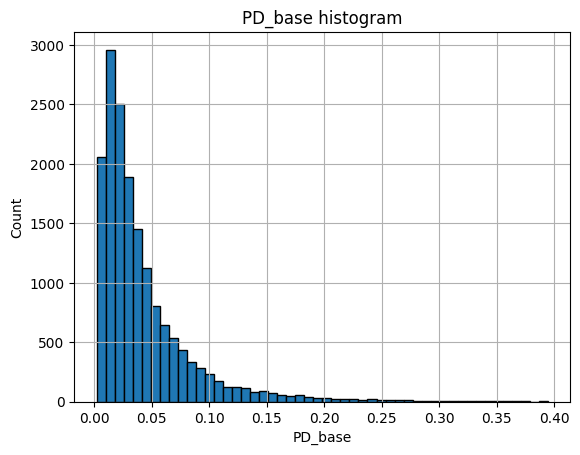

In [219]:
import pandas as pd, matplotlib.pyplot as plt
df = pd.read_csv("psid_with_target_prob.csv")        # [ID, prob]

print(df["TARGET"].describe(percentiles=[.01,.1,.25,.5,.75,.9,.99]))
df["TARGET"].hist(bins=50, edgecolor="k")
plt.xlabel("PD_base"); plt.ylabel("Count"); plt.title("PD_base histogram")
plt.show()


# 모델에 PSID 데이터셋 삽입하여 Target 값 생성

In [71]:
# ────────────────────────────────────────────────────────────
#  Home‑Credit XGB 파이프라인 + 컷오프(threshold) 불러와서
#  ① PSID 데이터에 확률 예측 → ② 0/1 TARGET 컬럼 생성 → ③ 저장
# ────────────────────────────────────────────────────────────
import joblib
import pandas as pd

# 1) 모델 패키지(pkl) 로드  ────────────────────────────────
#    - dict 구조: {"model": 파이프라인, "threshold": 0.47}
raw = joblib.load("models/xgb_HC15_weighted.pkl")   # 📦 피클 열기
mdl = raw["model"]                                  # 🎯 학습된 Pipeline
th  = raw["threshold"]                              # ✅ KS‑최대 컷오프

# 2) 예측 대상 데이터 로드  ───────────────────────────────
psid = pd.read_csv("psid_target_data.csv")          # 🗂️  전처리 완료 PSID

# 3) 모델이 학습 때 본 열(feature)만 추출  ───────────────
#    - feature_names_in_ : scikit‑learn ≥1.0 자동 저장 속성
X = psid[mdl.feature_names_in_]

# 4) 확률 예측 → 컷오프 적용  ────────────────────────────
prob = mdl.predict_proba(X)[:, 1]                   # 🔢 부실 확률 (0~1)
psid['prob'] = prob
psid["TARGET"] = (prob >= th).astype(int)           # 🏷️ 0=정상, 1=부실

# 5) 결과 저장  ──────────────────────────────────────────
psid.to_csv("psid_with_target_bin.csv", index=False)    # 💾 CSV 출력
print(f"✅ 저장 완료 → psid_with_target_bin.csv  (rows = {len(psid):,})")


AttributeError: Can't get attribute '_RemainderColsList' on <module 'sklearn.compose._column_transformer' from '/usr/local/lib/python3.11/dist-packages/sklearn/compose/_column_transformer.py'>

In [12]:
data = pd.read_csv('./psid_with_target.csv')
data['TARGET'].value_counts()

TARGET
0    15986
1      469
Name: count, dtype: int64

In [26]:
# ────────────────────────────────────────────────────────────
#  Home‑Credit XGB 파이프라인 + 컷오프(threshold) 불러와서
#  ① PSID 데이터 부실 확률 예측 → ② 확률(소수 4자리) TARGET 컬럼 생성 → ③ 저장
# ────────────────────────────────────────────────────────────
import joblib
import pandas as pd
import numpy as np                     # ← round 사용을 위해 추가

# 1) 모델 패키지(pkl) 로드 ──────────────────────────────────
raw = joblib.load("models/xgb_HC15_weighted.pkl")   # 📦 피클 열기
mdl = raw["model"]                                  # 🎯 파이프라인
th  = raw["threshold"]                              # (참고) KS‑컷오프

# 2) 예측 대상 데이터 로드 ────────────────────────────────
psid = pd.read_csv("psid_target_data.csv")          # 🗂️  전처리 완료 PSID

# 3) 학습 시 사용한 피처만 추출 ───────────────────────────
X = psid[mdl.feature_names_in_]                     # 열 순서 자동 정렬

# 4) 부실 확률 예측 → 소수 4자리로 반올림 ────────────────
prob = mdl.predict_proba(X)[:, 1]                   # 🔢 0 ~ 1 확률
psid["TARGET"] = np.round(prob, 2)                  # ✨ 0.1234 형식

# 5) 결과 저장 ───────────────────────────────────────────
psid.to_csv("psid_with_target_prob.csv", index=False)
print(f"✅ 저장 완료 → psid_with_target_prob.csv  (rows = {len(psid):,})")


✅ 저장 완료 → psid_with_target_prob.csv  (rows = 16,455)


# 전처리된 PSID 데이터셋에 Target 값 추가

In [13]:
psid = pd.read_csv('./filled_merged_clean.csv')
target = pd.read_csv('./psid_with_target_bin.csv')

psid['TARGET'] = target['TARGET']

psid = psid.drop(columns='Unnamed: 0')

In [14]:
psid.to_csv('./PSID_with_TARGET.csv')

In [89]:
psid = pd.read_csv('./filled_merged_clean.csv')
target = pd.read_csv('./psid_with_prob.csv')

psid['TARGET'] = target['prob']

psid = psid.drop(columns='Unnamed: 0')

psid.to_csv('./PSID_with_TARGET_prob.csv')

# PSID 건강정보 제외 데이터셋 생성

In [28]:
# -----------------------------------------------------------
#  PSID_with_TARGET.csv  →  건강 변수 제외  →  새 파일 저장
#  결과: PSID_with_TARGET_except_BIO.csv
# -----------------------------------------------------------
import pandas as pd
import re

IN_PATH  = "./psid_with_target_prob.csv"
OUT_PATH = "./PSID_with_TARGET_prob_except_BIO.csv"

# 1) 데이터 불러오기
df = pd.read_csv(IN_PATH, low_memory=False)

# 2) 건강 변수 prefix 패턴 정의  -------------------------------
#    (필요하면 추가 패턴을 덧붙이세요)
bio_prefixes = [
    r"CCON_",         # Chronic conditions
    r"COVID_",        # Covid‑19
    r"DMNT_",         # Dementia
    r"DEPR_",         # Depression
    r"DISA_",         # Disability
    r"ADL_", r"IADL_",# 일상/수단 ADL
    r"GHLTH_", r"NHLTH_",  # General & neonatal health
    r"BODY_",         # 키·몸무게 등 신체지표 제거
    r"BMI$"
    
]

# 3) 제거 대상 컬럼 집계 --------------------------------------
regex = re.compile(rf"^({'|'.join(bio_prefixes)})")
bio_cols = [c for c in df.columns if regex.match(c)]

print(f"제거할 건강 변수: {len(bio_cols):,}개")

# 4) 건강 변수 제외하고 저장 ----------------------------------
df.drop(columns=bio_cols).to_csv(OUT_PATH, index=False)
print(f"✅ '{OUT_PATH}' 저장 완료 (rows={len(df):,}, cols={df.shape[1]-len(bio_cols)})")


제거할 건강 변수: 52개
✅ './PSID_with_TARGET_prob_except_BIO.csv' 저장 완료 (rows=16,455, cols=286)


### 모델 생성 전처리

In [30]:
import gc
import numpy as np
import pandas as pd
import joblib

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping as KerasEarlyStopping

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.base import clone

# 데이터 로드
DATA_PATH = r'D:/fintech/data/PSID_with_TARGET_except_BIO.csv'
df = pd.read_csv(DATA_PATH)
y  = df.pop('TARGET')
cat_cols = df.select_dtypes('object').columns
num_df   = df.drop(columns=cat_cols)

# 전처리
num_imp = SimpleImputer(strategy='median')
X_num   = num_imp.fit_transform(num_df).astype(np.float32)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat = ohe.fit_transform(df[cat_cols]).astype(np.float32)

X = np.hstack([X_num, X_cat])
feature_names = list(num_df.columns) + list(ohe.get_feature_names_out(cat_cols))

kf = KFold(n_splits=5, shuffle=True, random_state=42)


## 1. 로지스틱회귀

In [31]:
###########################################################################################################
print("▶ LogisticRegression 시작")

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver='lbfgs', max_iter=5000, random_state=42)
)

oof = np.zeros(len(y), dtype=np.float32)

for tr_idx, val_idx in kf.split(X):
    clf = clone(model)
    clf.fit(X[tr_idx], y.iloc[tr_idx])
    preds = clf.predict_proba(X[val_idx])[:, 1]
    oof[val_idx] = preds
    gc.collect()

auc = roc_auc_score(y, oof)
print(f"LogisticRegression CV AUC = {auc:.5f}")

# 전체 학습 후 저장
model.fit(X, y)
joblib.dump(model, 'PSID_model_LogisticRegression.pkl')

# 중요도 저장
coef = model.named_steps['logisticregression'].coef_[0]
imps = np.abs(coef)

with open('feature_importance_LogisticRegression.txt', 'w', encoding='utf-8') as f:
    for feat, val in zip(feature_names, imps):
        f.write(f"{feat}: {val}\n")


▶ LogisticRegression 시작
LogisticRegression CV AUC = 0.87655


## 2. 랜덤포레스트

In [32]:
###########################################################################################################
print("▶ RandomForest 시작")

model = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1,
    random_state=42
)

oof = np.zeros(len(y), dtype=np.float32)

for tr_idx, val_idx in kf.split(X):
    clf = clone(model)
    clf.fit(X[tr_idx], y.iloc[tr_idx])
    preds = clf.predict_proba(X[val_idx])[:, 1]
    oof[val_idx] = preds
    gc.collect()

auc = roc_auc_score(y, oof)
print(f"RandomForest       CV AUC = {auc:.5f}")

# 전체 학습 후 저장
model.fit(X, y)
joblib.dump(model, 'PSID_model_RandomForest.pkl')
print("모델 저장 완료")


# 중요도 저장
imps = model.feature_importances_

with open('feature_importance_RandomForest.txt', 'w', encoding='utf-8') as f:
    for feat, val in zip(feature_names, imps):
        f.write(f"{feat}: {val}\n")
print("중요도 저장 완료")

▶ RandomForest 시작
RandomForest       CV AUC = 0.92002
모델 저장 완료
중요도 저장 완료


## 3. XGBoost

In [33]:
import xgboost as xgb
import numpy as np
import gc
from sklearn.metrics import roc_auc_score

print("▶ XGBoost 시작")

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'learning_rate': 0.05,
    'max_depth': 6,
    'random_state': 42
}

oof = np.zeros(len(y), dtype=np.float32)

for fold, (tr_idx, val_idx) in enumerate(kf.split(X), 1):
    # feature_names=feature_names 반드시 명시!
    dtrain = xgb.DMatrix(X[tr_idx], label=y.iloc[tr_idx].to_numpy(), feature_names=feature_names)
    dval   = xgb.DMatrix(X[val_idx], label=y.iloc[val_idx].to_numpy(), feature_names=feature_names)
    
    evals = [(dtrain, 'train'), (dval, 'valid')]
    
    booster = xgb.train(
        params,
        dtrain,
        num_boost_round=2000,
        evals=evals,
        early_stopping_rounds=100,
        verbose_eval=False
    )
    preds = booster.predict(dval, iteration_range=(0, booster.best_iteration + 1))
    oof[val_idx] = preds
    gc.collect()

auc = roc_auc_score(y, oof)
print(f"XGBoost(DMatrix)   CV AUC = {auc:.5f}")

# 전체 데이터로 학습 (feature_names 명시!)
dtrain_full = xgb.DMatrix(X, label=y.to_numpy(), feature_names=feature_names)
final_booster = xgb.train(
    params,
    dtrain_full,
    num_boost_round=booster.best_iteration + 1
)
final_booster.save_model('PSID_model_XGBoost.json')
print("모델 저장 완료 !")

# 중요도 저장 (이제 feature_names 기준으로 0이 아닌 값이 제대로 나올 것)
importances = final_booster.get_score(importance_type='weight')
print("중요도 예시 (상위 10개):", sorted(importances.items(), key=lambda x: x[1], reverse=True)[:10])

with open('feature_importance_XGBoost.txt', 'w', encoding='utf-8') as f:
    for feat in feature_names:
        imp = importances.get(feat, 0)
        f.write(f"{feat}: {imp}\n")
print("중요도 저장 완료!")

▶ XGBoost 시작
XGBoost(DMatrix)   CV AUC = 0.95298
모델 저장 완료 !
중요도 예시 (상위 10개): [('EDU_LEVEL', 670.0), ('GEO_REGION', 611.0), ('DEMO_AGE_GEN', 607.0), ('OCC_2010C_1M', 434.0), ('DEMO_BIRTH_YEAR', 397.0), ('EMP_STAT_1M', 359.0), ('FUID', 318.0), ('DEMO_AGE_REP', 306.0), ('IW', 284.0), ('TIME_LEIS', 265.0)]
중요도 저장 완료!


## 4. LightGBM

In [34]:
#########################################################################################################
print("▶ LightGBM 시작")

from lightgbm import LGBMClassifier

oof = np.zeros(len(y), dtype=np.float32)

for tr_idx, val_idx in kf.split(X):
    clf = LGBMClassifier(
        n_estimators=2000,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X[tr_idx], y.iloc[tr_idx])
    preds = clf.predict_proba(X[val_idx])[:, 1]
    oof[val_idx] = preds
    gc.collect()

auc = roc_auc_score(y, oof)
print(f"LightGBM           CV AUC = {auc:.5f}")

# 전체 학습 후 저장
final_model = LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X, y)
joblib.dump(final_model, 'PSID_model_LightGBM.pkl')
print("모델 저장 완료 !")

# 중요도 저장
imps = final_model.feature_importances_
print("중요도 저장 완료!")

with open('feature_importance_LightGBM.txt', 'w', encoding='utf-8') as f:
    for feat, val in zip(feature_names, imps):
        f.write(f"{feat}: {val}\n")


▶ LightGBM 시작
[LightGBM] [Info] Number of positive: 247, number of negative: 12917
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.048924 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 50312
[LightGBM] [Info] Number of data points in the train set: 13164, number of used features: 277
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018763 -> initscore=-3.956911
[LightGBM] [Info] Start training from score -3.956911
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

## 5. DNN

In [35]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping as KerasEarlyStopping
import numpy as np
import gc
from sklearn.metrics import roc_auc_score

print("▶ DNN 시작")

# 1. 스케일러로 전체 데이터 fit (train set에서만 fit해도 됨)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

def build_dnn(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),  # 최신 Keras는 input_shape 대신 shape!
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    return model

oof = np.zeros(len(y), dtype=np.float32)

for tr_idx, val_idx in kf.split(X_scaled):
    model = build_dnn(X_scaled.shape[1])
    es = KerasEarlyStopping(
        monitor='val_auc', mode='max',
        patience=5, restore_best_weights=True, verbose=0
    )
    model.fit(
        X_scaled[tr_idx], y.iloc[tr_idx],
        validation_data=(X_scaled[val_idx], y.iloc[val_idx]),
        epochs=50, batch_size=256,
        callbacks=[es], verbose=0
    )
    preds = model.predict(X_scaled[val_idx]).ravel()
    oof[val_idx] = preds
    gc.collect()

auc = roc_auc_score(y, oof)
print(f"DNN                CV AUC = {auc:.5f}")

# 전체 학습 후 저장 (스케일링된 데이터로!)
final_model = build_dnn(X_scaled.shape[1])
final_model.fit(X_scaled, y, epochs=50, batch_size=256, verbose=0)
final_model.save('PSID_model_DNN.h5')
print("모델 저장 완료!")

print("DNN은 feature importance를 지원하지 않음 (스킵)")

▶ DNN 시작
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
DNN                CV AUC = 0.87088


모델 저장 완료!
DNN은 feature importance를 지원하지 않음 (스킵)


# 건강데이터 포함 모델

In [36]:
import gc
import numpy as np
import pandas as pd
import joblib

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping as KerasEarlyStopping

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.base import clone

# 데이터 로드
DATA_PATH = r'D:/fintech/data/PSID_with_TARGET.csv'
df = pd.read_csv(DATA_PATH)
y  = df.pop('TARGET')
cat_cols = df.select_dtypes('object').columns
num_df   = df.drop(columns=cat_cols)

# 전처리
num_imp = SimpleImputer(strategy='median')
X_num   = num_imp.fit_transform(num_df).astype(np.float32)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat = ohe.fit_transform(df[cat_cols]).astype(np.float32)

X = np.hstack([X_num, X_cat])
feature_names = list(num_df.columns) + list(ohe.get_feature_names_out(cat_cols))

kf = KFold(n_splits=5, shuffle=True, random_state=42)


In [37]:
import xgboost as xgb
import numpy as np
import gc
from sklearn.metrics import roc_auc_score

print("▶ XGBoost 시작")

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'learning_rate': 0.05,
    'max_depth': 6,
    'random_state': 42
}

oof = np.zeros(len(y), dtype=np.float32)

for fold, (tr_idx, val_idx) in enumerate(kf.split(X), 1):
    # feature_names=feature_names 반드시 명시!
    dtrain = xgb.DMatrix(X[tr_idx], label=y.iloc[tr_idx].to_numpy(), feature_names=feature_names)
    dval   = xgb.DMatrix(X[val_idx], label=y.iloc[val_idx].to_numpy(), feature_names=feature_names)
    
    evals = [(dtrain, 'train'), (dval, 'valid')]
    
    booster = xgb.train(
        params,
        dtrain,
        num_boost_round=2000,
        evals=evals,
        early_stopping_rounds=100,
        verbose_eval=False
    )
    preds = booster.predict(dval, iteration_range=(0, booster.best_iteration + 1))
    oof[val_idx] = preds
    gc.collect()

auc = roc_auc_score(y, oof)
print(f"XGBoost(DMatrix)   CV AUC = {auc:.5f}")

# 전체 데이터로 학습 (feature_names 명시!)
dtrain_full = xgb.DMatrix(X, label=y.to_numpy(), feature_names=feature_names)
final_booster = xgb.train(
    params,
    dtrain_full,
    num_boost_round=booster.best_iteration + 1
)
final_booster.save_model('PSID_model_XGBoost.json')
print("모델 저장 완료 !")

# 중요도 저장 (이제 feature_names 기준으로 0이 아닌 값이 제대로 나올 것)
importances = final_booster.get_score(importance_type='weight')
print("중요도 예시 (상위 10개):", sorted(importances.items(), key=lambda x: x[1], reverse=True)[:10])

with open('feature_importance_XGBoost.txt', 'w', encoding='utf-8') as f:
    for feat in feature_names:
        imp = importances.get(feat, 0)
        f.write(f"{feat}: {imp}\n")
print("중요도 저장 완료!")

▶ XGBoost 시작
XGBoost(DMatrix)   CV AUC = 0.96250
모델 저장 완료 !
중요도 예시 (상위 10개): [('EDU_LEVEL', 539.0), ('GEO_REGION', 515.0), ('DEMO_AGE_GEN', 460.0), ('OCC_2010C_1M', 372.0), ('DEMO_BIRTH_YEAR', 362.0), ('EMP_STAT_1M', 312.0), ('BMI', 262.0), ('DEMO_AGE_REP', 256.0), ('IW', 251.0), ('DEMO_SEX', 207.0)]
중요도 저장 완료!


# 모델 비교

   risk_target  approval_rate_fin  approval_rate_aug  approval_gain_pp
0        0.015           0.000000           0.203829         20.382862
1        0.016           0.000486           0.242783         24.229717
2        0.017           0.014221           0.278578         26.435734
{
  "n": 16455,
  "features_fin": [
    "FINC_TOT_RDF",
    "WLTH_TOT_NET_RDF",
    "WLTH_TOT_DEB_RDF",
    "EXPN_TOT_RDF",
    "EXPN_HLTH_TOT_RDF"
  ],
  "features_health": [
    "GHLTH_STAT",
    "HOSP_ANY",
    "HOSP_NUM",
    "DEP_SCORE_TOT",
    "ADL_SUM_TOT",
    "IADL_SUM_TOT",
    "BMI",
    "HLTH_COST_RATIO",
    "HEALTH_INDEX",
    "ADL_FLAG",
    "IADL_FLAG",
    "HX_AGE",
    "HOSP_AGE",
    "HCR_AGE"
  ],
  "metrics": [
    {
      "model": "Baseline(fin - EN)",
      "R2": -0.0504,
      "MAE": 0.0255,
      "RMSE": 0.0429,
      "Pearson": 0.2315,
      "Spearman": 0.3871,
      "AUC": 0.707,
      "PR_AUC": 0.3474
    },
    {
      "model": "Augmented(fin+health - CatBoost)",
      "R2": 0.

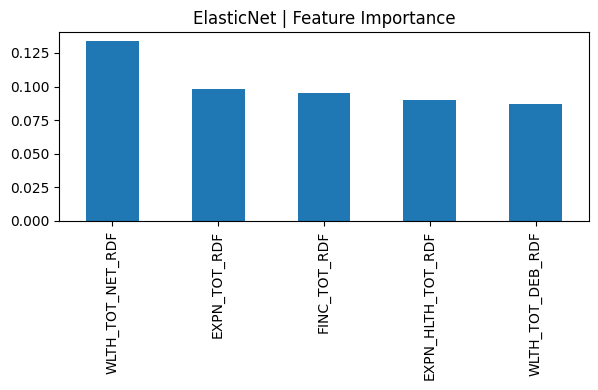

=== CatBoost Feature Importance ===
HX_AGE               18.467367
WLTH_TOT_DEB_RDF     14.624965
WLTH_TOT_NET_RDF     14.203793
FINC_TOT_RDF         11.454305
HEALTH_INDEX          8.495442
EXPN_TOT_RDF          7.197128
BMI                   6.225462
HCR_AGE               4.332135
EXPN_HLTH_TOT_RDF     2.827998
HLTH_COST_RATIO       2.310610
DEP_SCORE_TOT         2.001314
ADL_SUM_TOT           1.700091
GHLTH_STAT            1.638051
HOSP_AGE              1.564968
IADL_FLAG             1.058456
HOSP_NUM              0.721042
IADL_SUM_TOT          0.703319
ADL_FLAG              0.385214
HOSP_ANY              0.088339
dtype: float64


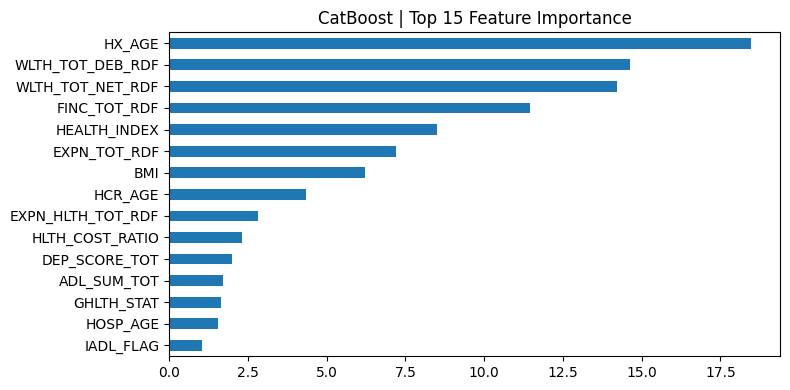

In [221]:
# improved_health_model.py
import pandas as pd, numpy as np, os, re, json, warnings
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, roc_auc_score, average_precision_score
from sklearn.decomposition import PCA
from catboost import CatBoostRegressor, Pool
warnings.filterwarnings("ignore")

DATA_PATH = "./psid_with_target_prob.csv"
OUT_DIR   = "./health_model_outputs_v2"
os.makedirs(OUT_DIR, exist_ok=True)

def logit(p): p=np.clip(p,1e-6,1-1e-6); return np.log(p/(1-p))
def sigmoid(z): z=np.clip(z,-40,40); return 1/(1+np.exp(-z))

# ── 1) 로드 (compact 컬럼 + 건강 상세 파생 위해 원본도 허용) ──
df = pd.read_csv(DATA_PATH, low_memory=True)

# 필수
assert "TARGET" in df.columns, "TARGET 열이 필요합니다."
y = df["TARGET"].astype(float).values

AGE_COL = "DEMO_AGE_GEN" if "DEMO_AGE_GEN" in df.columns else ("DEMO_AGE_REP" if "DEMO_AGE_REP" in df.columns else None)
age = df[AGE_COL].astype(float).values if AGE_COL else np.full(len(df), 0)

# 핵심 재무
fin_cols = [c for c in ["FINC_TOT_RDF","WLTH_TOT_NET_RDF","WLTH_TOT_DEB_RDF","EXPN_TOT_RDF","EXPN_HLTH_TOT_RDF"] if c in df.columns]
# 핵심 건강
health_cols_base = [c for c in ["GHLTH_STAT","HOSP_ANY","HOSP_NUM","DEP_SCORE_TOT","ADL_SUM_TOT","IADL_SUM_TOT","BMI"] if c in df.columns]

# ── 2) 파생변수 ─────────────────────────────────────────────
# 의료비 부담률
if ("EXPN_HLTH_TOT_RDF" in df.columns) and ("FINC_TOT_RDF" in df.columns):
    df["HLTH_COST_RATIO"] = df["EXPN_HLTH_TOT_RDF"] / (df["FINC_TOT_RDF"].abs() + 1.0)
else:
    df["HLTH_COST_RATIO"] = np.nan

# ADL/IADL 플래그
if "ADL_SUM_TOT" in df.columns:
    df["ADL_FLAG"] = (df["ADL_SUM_TOT"].fillna(0) > 0).astype(int)
if "IADL_SUM_TOT" in df.columns:
    df["IADL_FLAG"] = (df["IADL_SUM_TOT"].fillna(0) > 0).astype(int)

# HEALTH_INDEX (개선: 질병/입원/기능지표에 가중)
health_cols = health_cols_base.copy()
if "HLTH_COST_RATIO" in df.columns: health_cols.append("HLTH_COST_RATIO")

imp_h = SimpleImputer(strategy="median")
H = imp_h.fit_transform(df[health_cols])
sc  = StandardScaler(with_mean=True, with_std=True)
H_std = sc.fit_transform(H)
pca = PCA(n_components=1, random_state=42).fit(H_std)
h_score = pca.transform(H_std).ravel()
healthy = sigmoid((h_score - h_score.mean())/(h_score.std()+1e-9))
health_risk = 1.0 - healthy
df["HEALTH_INDEX"] = health_risk

# 상호작용
df["HX_AGE"] = df["HEALTH_INDEX"] * age
if "HOSP_ANY" in df.columns:
    df["HOSP_AGE"] = df["HOSP_ANY"].fillna(0) * age
if "HLTH_COST_RATIO" in df.columns:
    df["HCR_AGE"] = df["HLTH_COST_RATIO"].fillna(0) * age

# 최종 피처 세트
features_fin = fin_cols
features_hlth = health_cols_base + ["HLTH_COST_RATIO","HEALTH_INDEX","ADL_FLAG","IADL_FLAG","HX_AGE","HOSP_AGE","HCR_AGE"]
features_hlth = [c for c in features_hlth if c in df.columns]

# ── 3) 재무만(EN) vs 재무+건강(CatBoost) 비교 ────────────────
# 재무만: ElasticNetCV (로짓 회귀)
from sklearn.linear_model import ElasticNetCV
Xf = df[features_fin].copy()
imp_f = SimpleImputer(strategy="median")
Xf_mat = imp_f.fit_transform(Xf)
scf = StandardScaler(with_mean=True, with_std=True)
Xf_mat = scf.fit_transform(Xf_mat)

y_log = logit(y)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_fin = np.zeros(len(df))

for tr, va in kf.split(Xf_mat):
    en = ElasticNetCV(l1_ratio=[0.1,0.3,0.5,0.7,0.9,1.0],
                      alphas=np.logspace(-4,0,40),
                      cv=5, max_iter=20000, tol=1e-5, n_jobs=1, random_state=42)
    en.fit(Xf_mat[tr], y_log[tr])
    oof_fin[va] = en.predict(Xf_mat[va])

p_fin = sigmoid(oof_fin)

# 재무+건강: CatBoostRegressor (로짓 예측)
features_all = features_fin + features_hlth
X_all = df[features_all]
imp_all = SimpleImputer(strategy="median")
X_all_mat = imp_all.fit_transform(X_all)

oof_aug = np.zeros(len(df))
for tr, va in kf.split(X_all_mat):
    train_pool = Pool(X_all_mat[tr], y_log[tr])
    valid_pool = Pool(X_all_mat[va], y_log[va])
    cb = CatBoostRegressor(
        depth=6, learning_rate=0.06, loss_function="RMSE",
        iterations=2000, l2_leaf_reg=6,
        random_seed=42, verbose=False
    )
    cb.fit(train_pool, eval_set=valid_pool)
    oof_aug[va] = cb.predict(X_all_mat[va])

p_aug = sigmoid(oof_aug)

# ── 4) 지표 계산 ─────────────────────────────────────────────
def cont_metrics(y, p):
    return dict(
        R2=r2_score(y,p),
        MAE=mean_absolute_error(y,p),
        RMSE=float(np.sqrt(mean_squared_error(y,p))),
        Pearson=float(np.corrcoef(y,p)[0,1]),
        Spearman=float(pd.Series(y).corr(pd.Series(p), method="spearman"))
    )

from sklearn.metrics import mean_squared_error
res_fin = cont_metrics(y, p_fin)
res_aug = cont_metrics(y, p_aug)

thr = np.quantile(y, 0.80)
y_bin = (y >= thr).astype(int)
auc_fin = roc_auc_score(y_bin, p_fin); auc_aug = roc_auc_score(y_bin, p_aug)
pr_fin  = average_precision_score(y_bin, p_fin); pr_aug  = average_precision_score(y_bin, p_aug)

summary_tbl = pd.DataFrame([
    {"model":"Baseline(fin - EN)", **res_fin, "AUC":auc_fin, "PR_AUC":pr_fin},
    {"model":"Augmented(fin+health - CatBoost)", **res_aug, "AUC":auc_aug, "PR_AUC":pr_aug},
]).round(4)

# 승인곡선 (동일 승인율)
def approval_curve(y_true, p_pred, rates=(0.3,0.4,0.5,0.6,0.7)):
    order = np.argsort(p_pred); y_sorted = y_true[order]; rows=[]
    n=len(y_true)
    for r in rates:
        k = max(1, min(int(n*r), n))
        rows.append({"approval_rate": r, "avg_risk": float(y_sorted[:k].mean())})
    return pd.DataFrame(rows)

ac_fin = approval_curve(y, p_fin)
ac_aug = approval_curve(y, p_aug)
ac = ac_fin.merge(ac_aug, on="approval_rate", suffixes=("_fin","_aug"))
ac["risk_delta"] = ac["avg_risk_fin"] - ac["avg_risk_aug"]

# 동일 위험에서 승인률 비교
def approval_at_target_risk(y_true, p_pred, risk_targets=(0.015, 0.016, 0.017)):
    """
    예측확률 p_pred가 낮은 순으로 정렬했을 때,
    누적 평균 위험이 risk_target 이하가 되는 최대 승인비율을 계산.
    """
    order = np.argsort(p_pred)
    y_sorted = y_true[order].astype(float)
    n = len(y_sorted)
    # 누적평균: cumsum / (1..n)
    cum_mean = np.cumsum(y_sorted) / np.arange(1, n + 1)

    out = []
    for rt in risk_targets:
        # 누적평균이 목표 위험 이하인 마지막 인덱스
        idx = np.where(cum_mean <= rt)[0]
        if len(idx) == 0:
            appr = 0.0
        else:
            k = idx[-1] + 1  # 승인 고객 수
            appr = k / n
        out.append({"risk_target": float(rt), "approval_rate": float(appr)})
    return pd.DataFrame(out)

risk_targets = (0.015, 0.016, 0.017)  # 평균 위험(≈0.017) 근처로 설정
same_risk_fin = approval_at_target_risk(y, p_fin, risk_targets)
same_risk_aug = approval_at_target_risk(y, p_aug, risk_targets)
same_risk = same_risk_fin.merge(same_risk_aug, on="risk_target",
                                suffixes=("_fin","_aug"))
same_risk["approval_gain_pp"] = 100 * (same_risk["approval_rate_aug"] - same_risk["approval_rate_fin"])
same_risk.to_csv(os.path.join(OUT_DIR, "approval_rate_at_same_risk.csv"), index=False)
print(same_risk)

# ── 5) 서브그룹(Seniors, ARIP) ─────────────────────────────
def subgroup_stats(mask, label):
    idx = np.where(mask)[0]
    if len(idx) < 50:
        return {"group":label, "n":int(len(idx))}
    yg = y[idx]; pf=p_fin[idx]; pa=p_aug[idx]; yb = y_bin[idx]
    return {
        "group": label, "n": int(len(idx)),
        "R2_fin": r2_score(yg,pf), "R2_aug": r2_score(yg,pa),
        "AUC_fin": roc_auc_score(yb,pf), "AUC_aug": roc_auc_score(yb,pa),
        "PR_fin": average_precision_score(yb,pf), "PR_aug": average_precision_score(yb,pa)
    }

seniors = (age >= 50)
# ARIP: 자산 상위40 & 소득 하위40
wealth = df["WLTH_TOT_NET_RDF"].astype(float) if "WLTH_TOT_NET_RDF" in df.columns else pd.Series(np.nan, index=df.index)
income = df["FINC_TOT_RDF"].astype(float) if "FINC_TOT_RDF" in df.columns else pd.Series(np.nan, index=df.index)
w_rank = wealth.rank(method="average")/(len(df)+1)
i_rank = income.rank(method="average")/(len(df)+1)
arip = (w_rank >= 0.6) & (i_rank <= 0.4)

subs = []
subs.append(subgroup_stats(np.array([True]*len(df)), "All"))
subs.append(subgroup_stats(seniors, "Seniors(50+)"))
subs.append(subgroup_stats(arip, "ARIP"))
subs.append(subgroup_stats(seniors & arip, "Seniors∩ARIP"))
sub_df = pd.DataFrame(subs).round(4)

# ── 6) 저장 ────────────────────────────────────────────────
summary_tbl.to_csv(os.path.join(OUT_DIR, "summary_metrics.csv"), index=False)
ac.to_csv(os.path.join(OUT_DIR, "approval_curve_same_rate.csv"), index=False)
same_risk.to_csv(os.path.join(OUT_DIR, "approval_rate_at_same_risk.csv"), index=False)
sub_df.to_csv(os.path.join(OUT_DIR, "subgroup_metrics.csv"), index=False)

report = {
    "n": int(len(df)),
    "features_fin": features_fin,
    "features_health": features_hlth,
    "metrics": summary_tbl.to_dict(orient="records"),
    "approval_same_rate": ac.to_dict(orient="records"),
    "approval_same_risk": same_risk.to_dict(orient="records"),
    "subgroups": sub_df.to_dict(orient="records")
}
with open(os.path.join(OUT_DIR, "report.json"), "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print(json.dumps(report, ensure_ascii=False, indent=2))
print(f"Saved → {OUT_DIR}")

# ── 7) Feature Importance 출력 ─────────────────────────────────────────────

import matplotlib.pyplot as plt

# 1) ElasticNet 계수 기반 중요도
# 전체 데이터를 이용해 한 번 더 재학습하여 coef_를 뽑습니다.
en_full = ElasticNetCV(
    l1_ratio=[0.1,0.3,0.5,0.7,0.9,1.0],
    alphas=np.logspace(-4,0,40),
    cv=5, max_iter=20000, tol=1e-5, n_jobs=1, random_state=42
)
en_full.fit(Xf_mat, y_log)
coef = en_full.coef_

feat_imp_en = pd.Series(np.abs(coef), index=features_fin)
feat_imp_en = feat_imp_en.sort_values(ascending=False)

print("=== ElasticNet Feature Importance (절대계수 기준) ===")
print(feat_imp_en)

# (옵션) 시각화
plt.figure(figsize=(6,4))
feat_imp_en.plot.bar()
plt.title("ElasticNet | Feature Importance")
plt.tight_layout()
plt.show()


# 2) CatBoost 기반 중요도
# 전체 데이터를 이용해 CatBoost를 한 번 더 학습
train_pool_full = Pool(X_all_mat, y_log)
cb_full = CatBoostRegressor(
    depth=6, learning_rate=0.06, loss_function="RMSE",
    iterations=2000, l2_leaf_reg=6,
    random_seed=42, verbose=False
)
cb_full.fit(train_pool_full)

imp_cb = cb_full.get_feature_importance(train_pool_full, type="FeatureImportance")
feat_imp_cb = pd.Series(imp_cb, index=features_all)
feat_imp_cb = feat_imp_cb.sort_values(ascending=False)

print("=== CatBoost Feature Importance ===")
print(feat_imp_cb)

# (옵션) 시각화
plt.figure(figsize=(8,4))
feat_imp_cb.head(15).plot.barh()
plt.gca().invert_yaxis()
plt.title("CatBoost | Top 15 Feature Importance")
plt.tight_layout()
plt.show()


# 상관 분석

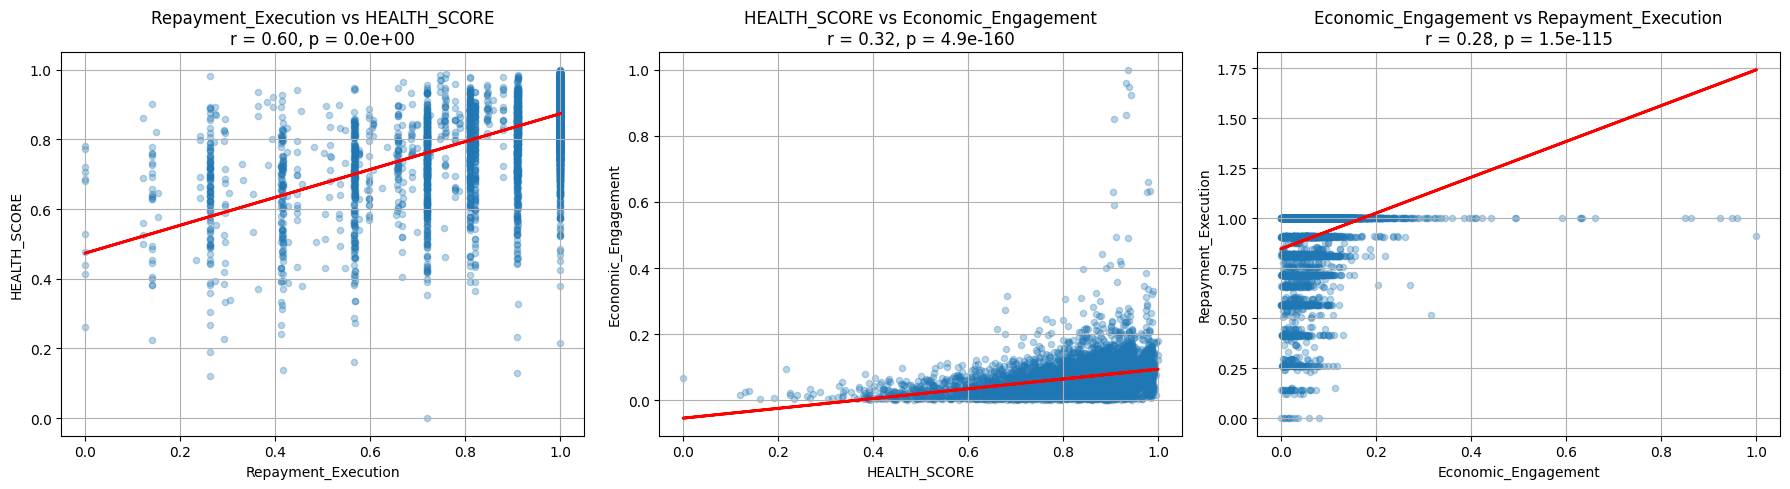

In [185]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 0) 데이터 로드 & 병합
df_main   = pd.read_csv("./psid_with_target_prob.csv")
df_tenure = pd.read_csv("./psid_with_total_tenure.csv")
df = pd.merge(df_main,
              df_tenure[['ID','YEAR','total_tenure_years']],
              on=['ID','YEAR'], how='left')

# 1) 고령자(50세 이상)만 필터링
df = df[df["DEMO_AGE_GEN"] >= 50].copy()

# 2) HEALTH_SCORE 생성 ------------------------------------------------
df["HLTH_COST_RATIO"] = np.where(
    df["FINC_TOT_RDF"].abs()>0,
    df["EXPN_HLTH_TOT_RDF"]/(df["FINC_TOT_RDF"].abs()+1),
    np.nan
)
for src, dst in [
    ("CCON_ARTH_DEGR","Arthritis_deg_good"),
    ("CCON_ASTH_DEGR","Asthma_deg_good"),
    ("CCON_DIAB_DEGR","Diabetes_deg_good")
]:
    if src in df.columns:
        med, mx = df[src].median(), df[src].max()
        df[dst] = mx - df[src].fillna(med)

health_cols = [
    "GHLTH_STAT","DEP_SCORE_TOT","BMI",
    "HOSP_NUM","HLTH_COST_RATIO",
    "Arthritis_deg_good","Asthma_deg_good","Diabetes_deg_good"
]
H  = SimpleImputer(strategy="median").fit_transform(df[health_cols])
Hs = StandardScaler().fit_transform(H)
h_idx = PCA(n_components=1, random_state=42).fit_transform(Hs).ravel()
h_idx = (h_idx - h_idx.min())/(h_idx.max()-h_idx.min())
df["HEALTH_SCORE"] = h_idx  # 값↑일수록 건강↑

# 3) Economic_Engagement 생성 ----------------------------------------
econ_cols = [
    "FINC_TOT_RDF","WLTH_TOT_NET_RDF","WLTH_TOT_DEB_RDF",
    "total_tenure_years","TIME_WORK"
]
E  = SimpleImputer(strategy="median").fit_transform(df[econ_cols])
Es = StandardScaler().fit_transform(E)
e_idx = PCA(n_components=1, random_state=42).fit_transform(Es).ravel()
# 소득과 양의 상관 유지
if pearsonr(e_idx, df["FINC_TOT_RDF"].fillna(0))[0] < 0:
    e_idx *= -1
df["Economic_Engagement"] = (e_idx - e_idx.min())/(e_idx.max()-e_idx.min())

# 4) Repayment_Execution 생성 ----------------------------------------
# ADL/IADL '어려움 없음' 플래그
df["ADL_any_good"]  = 1 - df["ADL_SUM_ANY"].fillna(0)
df["IADL_any_good"] = 1 - df["IADL_SUM_ANY"].fillna(0)
# 세부 IADL 자립 여부
for i in range(1,7):
    src = f"IADL_Q{i}_ANY"
    dst = f"IADL_Q{i}_independent"
    if src in df.columns:
        df[dst] = (df[src].fillna(0)==0).astype(int)

rep_cols = ["ADL_any_good","IADL_any_good"] + \
           [c for c in df.columns if c.endswith("_independent")]
R  = SimpleImputer(strategy="median").fit_transform(df[rep_cols])
Rs = StandardScaler().fit_transform(R)
r_idx = PCA(n_components=1, random_state=42).fit_transform(Rs).ravel()
# ‘어려움 없음’과 양의 상관 유지
if pearsonr(r_idx, df["ADL_any_good"])[0] < 0:
    r_idx *= -1
df["Repayment_Execution"] = (r_idx - r_idx.min())/(r_idx.max()-r_idx.min())

# 5) 상관분석 & 산점도 시각화 ------------------------------------------
pairs = [
    ("Repayment_Execution","HEALTH_SCORE"),
    ("HEALTH_SCORE","Economic_Engagement"),
    ("Economic_Engagement","Repayment_Execution"),
]

fig, axes = plt.subplots(1,3, figsize=(18,5))
for ax,(x,y) in zip(axes,pairs):
    mask = df[[x,y]].notna().all(axis=1)
    xs, ys = df.loc[mask,x], df.loc[mask,y]
    r, p = pearsonr(xs, ys)
    ax.scatter(xs, ys, alpha=0.3, s=20)
    m, b = np.polyfit(xs, ys, 1)
    ax.plot(xs, m*xs + b, 'r-', lw=2)
    ax.set_title(f"{x} vs {y}\nr = {r:.2f}, p = {p:.1e}")
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.grid(True)

plt.tight_layout()
plt.show()


In [166]:
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 3.2 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.1.2 -> 25.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


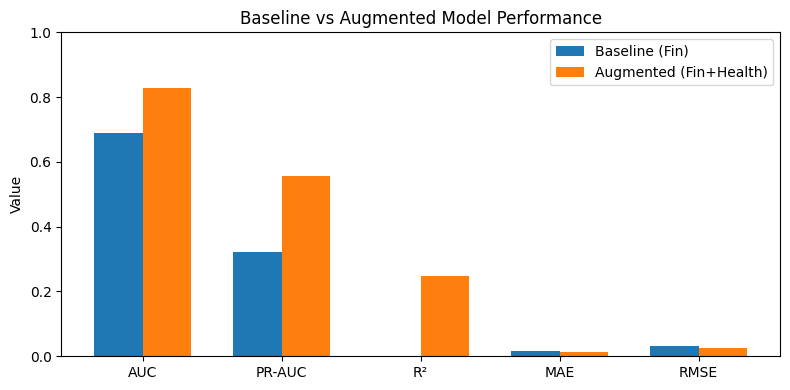

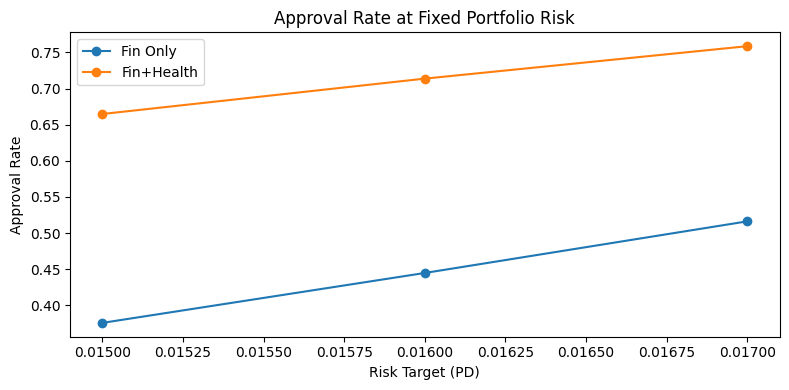

In [220]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics comparison
labels = ['AUC', 'PR-AUC', 'R\u00b2', 'MAE', 'RMSE']
baseline = [0.688, 0.3225, -0.1005, 0.0173, 0.0320]
augmented = [0.8274, 0.557, 0.2491, 0.0141, 0.0265]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, baseline, width)
ax.bar(x + width/2, augmented, width)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_ylabel('Value')
ax.set_title('Baseline vs Augmented Model Performance')
ax.legend(['Baseline (Fin)', 'Augmented (Fin+Health)'])
plt.tight_layout()
plt.show()

# Approval rate at target risks
risk_targets = [0.015, 0.016, 0.017]
approval_fin = [0.375691, 0.444789, 0.516256]
approval_aug = [0.664783, 0.713765, 0.758675]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(risk_targets, approval_fin, marker='o', label='Fin Only')
ax.plot(risk_targets, approval_aug, marker='o', label='Fin+Health')
ax.set_xlabel('Risk Target (PD)')
ax.set_ylabel('Approval Rate')
ax.set_title('Approval Rate at Fixed Portfolio Risk')
ax.legend()
plt.tight_layout()
plt.show()


# 향상 검증 시각화

In [222]:
# ── CatBoost 전체 학습 & 중요도 저장 ─────────────────────────────
from catboost import CatBoostRegressor, Pool

# (1) 전체 데이터로 학습
train_pool_full = Pool(X_all_mat, y_log)
cb_full = CatBoostRegressor(
    depth=6,
    learning_rate=0.06,
    loss_function="RMSE",
    iterations=2000,
    l2_leaf_reg=6,
    random_seed=42,
    verbose=False
)
cb_full.fit(train_pool_full)

# (2) Importance 추출
imp_cb = cb_full.get_feature_importance(train_pool_full, type="FeatureImportance")
feat_imp_cb = pd.Series(imp_cb, index=features_all).sort_values(ascending=False)

# (3) CSV로 저장
out_csv = os.path.join(OUT_DIR, "feature_importance.csv")
feat_imp_cb.to_csv(out_csv, header=["importance"])
print(f"Saved feature importances → {out_csv}")


Saved feature importances → ./health_model_outputs_v2/feature_importance.csv


In [224]:
# ── 예측값 저장 (시각화용) ─────────────────────────────────────────────
import numpy as np

# y, p_fin, p_aug는 이미 스크립트 상단에서 정의된 배열입니다.
np.savez(
    os.path.join(OUT_DIR, "model_preds.npz"),
    y_true=y,
    p_fin=p_fin,
    p_aug=p_aug
)
print(f"Saved predictions → {os.path.join(OUT_DIR, 'model_preds.npz')}")

Saved predictions → ./health_model_outputs_v2/model_preds.npz


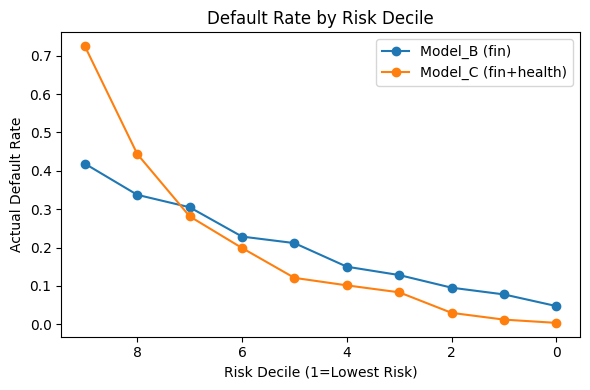

TypeError: read_csv() got an unexpected keyword argument 'squeeze'

In [229]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load predictions and true labels
#    Adjust the path if needed to where your model outputs are saved.
#    Here, it's assumed you have saved y_true, p_fin, p_aug as numpy arrays in a .npz file:
#    np.savez('model_preds.npz', y_true=y, p_fin=p_fin, p_aug=p_aug)
data = np.load('./health_model_outputs_v2/model_preds.npz')
y_true = data['y_true']
p_fin = data['p_fin']
p_aug = data['p_aug']

# Convert true target to binary (default if above threshold)
# If y_true is continuous PD, threshold at your PD quantile (e.g., top 20%)
thr = np.quantile(y_true, 0.80)
y_bin = (y_true >= thr).astype(int)

# 2) Compute actual default rate by decile for both models
df = pd.DataFrame({
    'y': y_bin,
    'p_fin': p_fin,
    'p_aug': p_aug
})
df['decile_fin'] = pd.qcut(df['p_fin'], 10, labels=False) + 1
df['decile_aug'] = pd.qcut(df['p_aug'], 10, labels=False) + 1

# Group and calculate default rates
default_rate_fin = df.groupby('decile_fin')['y'].mean()
default_rate_aug = df.groupby('decile_aug')['y'].mean()

# 3) Plot default rate curves (low risk decile on left)
plt.figure(figsize=(6,4))
plt.plot(default_rate_fin.values, marker='o', label='Model_B (fin)')
plt.plot(default_rate_aug.values, marker='o', label='Model_C (fin+health)')
plt.gca().invert_xaxis()
plt.xlabel('Risk Decile (1=Lowest Risk)')
plt.ylabel('Actual Default Rate')
plt.title('Default Rate by Risk Decile')
plt.legend()
plt.tight_layout()
plt.show()

# 4) Feature Importance Visualization
#    Load CatBoost feature importances from a JSON or CSV produced earlier:
#    Here, assume it's saved as CSV: OUT_DIR/feature_importance.csv
feat_imp = pd.read_csv('health_model_outputs_v2/feature_importance.csv', index_col=0, squeeze=True)
features_fin = ["FINC_TOT_RDF","WLTH_TOT_NET_RDF","WLTH_TOT_DEB_RDF","EXPN_TOT_RDF","EXPN_HLTH_TOT_RDF"]
# Identify top 10
top10 = feat_imp.sort_values(ascending=False).head(10)
# Color coding: financial vs health
colors = ['tab:blue' if f in features_fin else 'tab:green' for f in top10.index]

plt.figure(figsize=(6,4))
top10.plot.barh(color=colors)
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.title('Top 10 Feature Importances (Blue: Financial, Green: Health)')
plt.tight_layout()
plt.show()


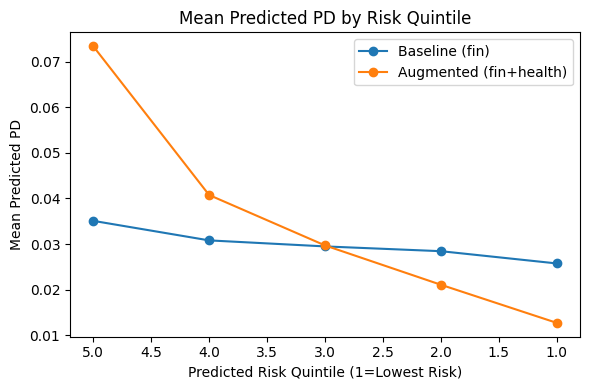

In [230]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load saved predictions
data = np.load('health_model_outputs_v2/model_preds.npz')
y_true = data['y_true']
p_fin = data['p_fin']
p_aug = data['p_aug']

# Create DataFrame
df = pd.DataFrame({
    'PD_fin': p_fin,
    'PD_aug': p_aug
})

# Assign quintile bins (1=lowest predicted risk)
df['quintile_fin'] = pd.qcut(df['PD_fin'], 5, labels=False) + 1
df['quintile_aug'] = pd.qcut(df['PD_aug'], 5, labels=False) + 1

# Compute mean PD per quintile
mean_pd_fin = df.groupby('quintile_fin')['PD_fin'].mean()
mean_pd_aug = df.groupby('quintile_aug')['PD_aug'].mean()

# Plot lift chart (mean PD by quintile)
plt.figure(figsize=(6,4))
plt.plot(mean_pd_fin.index, mean_pd_fin.values, marker='o', label='Baseline (fin)')
plt.plot(mean_pd_aug.index, mean_pd_aug.values, marker='o', label='Augmented (fin+health)')
plt.gca().invert_xaxis()
plt.xlabel('Predicted Risk Quintile (1=Lowest Risk)')
plt.ylabel('Mean Predicted PD')
plt.title('Mean Predicted PD by Risk Quintile')
plt.legend()
plt.tight_layout()
plt.show()


In [231]:
import pandas as pd
import numpy as np

# 1) 원본 로드 + 전처리 파이프라인 그대로 수행
df = pd.read_csv("psid_with_target_prob.csv", low_memory=True)
# (여기에 improved_health_model.py에서 하신 전처리 코드를 그대로 적용하세요)
# 예: AGE_COL, fin_cols, health_cols, 파생변수, 스케일링 등

# 2) p_fin, p_aug 배열 불러오기
data = np.load("health_model_outputs_v2/model_preds.npz")
df["PD_fin"] = data["p_fin"]
df["PD_aug"] = data["p_aug"]

# 3) 페르소나 A 필터링
persona_A = df[
    (df[AGE_COL] == 68) &
    (df["AMT_INCOME_TOTAL"] == 24000000) &
    (np.isclose(df["WLTH_TOT_NET_RDF"], 0.40, atol=1e-3)) &
    (np.isclose(df["WLTH_TOT_DEB_RDF"], 0.10, atol=1e-3))
]
print("페르소나 A 인덱스:", persona_A.index.tolist())

# 4) 페르소나 B 필터링 (ARIP이므로 추가 조건)
# ARIP 정의에 맞게 wealth·income rank로도 지정 가능
persona_B = df[
    (df[AGE_COL] == 72) &
    (df["AMT_INCOME_TOTAL"] == 18000000) &
    (np.isclose(df["WLTH_TOT_NET_RDF"], 0.48, atol=1e-3)) &
    (np.isclose(df["WLTH_TOT_DEB_RDF"], 0.05, atol=1e-3))
]
print("페르소나 B 인덱스:", persona_B.index.tolist())


KeyError: 'AMT_INCOME_TOTAL'

# 페르소나

In [246]:
import numpy as np
import pandas as pd

# 1) 원본 데이터 로드
df = pd.read_csv("psid_with_target_prob.csv")

# 2) 모델 예측값 로드 (improved_health_model.py 실행 후 생성된 파일)
data = np.load("health_model_outputs_v2/model_preds.npz")
df["PD_fin"] = data["p_fin"]
df["PD_aug"] = data["p_aug"]

# 3) 컷오프 기준 설정
cutoff = 0.15

# 4) PD_fin < cutoff < PD_aug 조건을 만족하는 행 찾기
mask = (df["PD_fin"] < cutoff) & (df["PD_aug"] > cutoff)
crossover = df[mask]

# 5) 결과 확인
print(f"총 {len(crossover)}건 발견")
print(crossover[["PD_fin", "PD_aug"]].head(50))

df.to_csv('./psid_with_target_PD.csv')

총 43건 발견
         PD_fin    PD_aug
362    0.030918  0.175295
745    0.036617  0.181020
784    0.035669  0.169294
982    0.036882  0.164616
1379   0.030506  0.157990
1699   0.030575  0.155228
1942   0.035272  0.157343
2102   0.033840  0.154657
3485   0.035171  0.161505
3930   0.032131  0.176811
3931   0.036012  0.170693
4247   0.033901  0.159007
4451   0.035017  0.155294
4523   0.033676  0.164505
4732   0.032824  0.156910
5017   0.034915  0.158150
5018   0.040099  0.153834
5318   0.038450  0.155995
6176   0.046876  0.289196
6339   0.033975  0.153182
6688   0.036147  0.154958
6722   0.032354  0.168824
7330   0.034564  0.160983
7976   0.035522  0.152801
8284   0.034165  0.153154
8300   0.038931  0.229435
8489   0.036160  0.161103
9366   0.035541  0.167668
9838   0.033599  0.160425
9868   0.034135  0.150573
10553  0.034390  0.170083
10585  0.039293  0.152063
11400  0.034316  0.154180
12162  0.035796  0.171109
13170  0.031943  0.165819
13183  0.033826  0.160079
13856  0.036364  0.211488
140

In [245]:
import numpy as np
import pandas as pd

# 1) 원본 데이터 로드
df = pd.read_csv("psid_with_target_prob.csv")

# 2) 모델 예측값 로드 (improved_health_model.py 실행 후 생성된 파일)
data = np.load("health_model_outputs_v2/model_preds.npz")
df["PD_fin"] = data["p_fin"]
df["PD_aug"] = data["p_aug"]


# 3) 컷오프 기준 설정
cutoff = 0.15

# 4) PD_fin > cutoff > PD_aug 조건을 만족하는 행 찾기
mask = (df["PD_fin"] > cutoff) & (df["PD_aug"] < cutoff)
crossover = df[mask]

# 5) 결과 확인
print(f"총 {len(crossover)}건 발견")
print(crossover[["PD_fin", "PD_aug"]].head(50))

총 1건 발견
       PD_fin    PD_aug
328  0.154302  0.047686


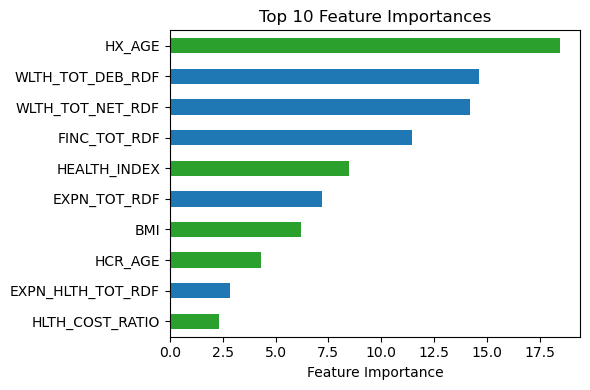

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 경로와 재무 피처 목록만 수정하세요 ------------------------------
feat_csv = "health_model_outputs_v2/feature_importance.csv"
features_fin = ["FINC_TOT_RDF","WLTH_TOT_NET_RDF","WLTH_TOT_DEB_RDF",
                "EXPN_TOT_RDF","EXPN_HLTH_TOT_RDF"]
# -----------------------------------------------------------------

# 1) 중요도 로드 → 첫 번째 컬럼만 Series 로 추출
imp_df = pd.read_csv(feat_csv, index_col=0)
imp = imp_df.iloc[:, 0]            # Series

top10 = imp.sort_values(ascending=False).head(10)

# 2) 색상 매핑
colors = ['tab:blue' if f in features_fin else 'tab:green'
          for f in top10.index]

# 3) 그래프
plt.figure(figsize=(6,4))
top10.plot.barh(color=colors)
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()
